
MAIN OBJECTIVE:

To integrate UAE-connected OpenSky flight data with ERA5 upper-atmospheric reanalysis data to reconstruct spatiotemporal flight paths, identify contrail-susceptible atmospheric conditions, analyse flight-path exposure, and develop an explainable machine-learning framework for contrail-susceptibility classification.

SPECIFIC OBJECTIVES:
Reconstruct UAE-connected flight paths from OpenSky endpoint data using great-circle spatial interpolation and interpolated timestamps.
Integrate reconstructed flight-path waypoints with ERA5 atmospheric data across six pressure levels.
Identify cold ice-supersaturated atmospheric conditions using temperature and ice-relative humidity (RHi).
Analyse temporal, spatial, pressure-level, route, aircraft-type, and flight-level susceptibility patterns.
Develop and validate machine-learning models using leakage-controlled training, temporal validation, and an untouched final test period.
Apply statistical validation, permutation importance, and SHAP explainability.
Develop a Gradio research dashboard for visualization, prediction, and research-question-based analysis.
DATA SOURCES:

ERA5 Reanalysis - ECMWF Copernicus Climate Data Store
Website: https://cds.climate.copernicus.eu
Period: January 2022
Region: 10–40°N, 30–70°E
Resolution: 0.25° × 0.25°, 4-hourly
Pressure Levels: 150, 200, 225, 250, 300, 350 hPa
Variables: Temperature, relative humidity, specific humidity, cloud ice, cloud cover, wind components, geopotential

OpenSky / Zenodo Flight Dataset
Website: https://zenodo.org/records/7923702
DOI: https://doi.org/10.5281/zenodo.7923702
OpenSky Website: https://opensky-network.org
Period: January 2022
Global Flight Records: approximately 2.41 million
UAE-Connected Records Examined: 32,560
Final Reconstruction-Eligible International Flights: 27,505
Flights Represented in Final ERA5 Analysis: 27,437

VARIABLES ANALYSED:

Atmospheric Variables:
Temperature, relative humidity, specific humidity, RHi, cloud ice water content, cloud cover, wind components, wind speed, geopotential height

Flight Variables:
Callsign, aircraft type, origin, destination, firstseen, lastseen, start/end coordinates, route distance, flight duration, flight direction

Derived Variables:
Reconstructed waypoint latitude/longitude, interpolated timestamp, ERA5 matching keys, RHi, ice-supersaturation flag, contrail-susceptibility flag, waypoint exposure, flight exposure, route exposure, aircraft-type exposure

METHODOLOGY:

Phase A: OpenSky and ERA5 data quality control and preprocessing
Phase B: Reconstructed spatiotemporal flight-path generation
Phase C: Multi-pressure-level ERA5 integration and contrail-susceptibility classification
Phase D: Target construction, univariate, bivariate, and multivariate EDA
Phase E: Statistical validation and temporal/spatial/flight exposure analysis
Phase F: Leakage-controlled modelling with separate temporal training, validation, and untouched test periods
Phase G: Learning curve, permutation importance, and SHAP explainability
Phase H: Final output saving and Gradio research dashboard


In [1]:
# MOUNT GOOGLE DRIVE

from google.colab import drive

drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully.")
print("Drive location: /content/drive/MyDrive")

Mounted at /content/drive

Google Drive mounted successfully.
Drive location: /content/drive/MyDrive


In [2]:
# Install all required libraries
# INSTALL ALL REQUIRED LIBRARIES

!pip install -q \
    pyspark \
    openap \
    airportsdata \
    shap \
    gradio \
    netCDF4 \
    xarray \
    pyarrow \
    xgboost \
    joblib

print("ALL REQUIRED LIBRARIES INSTALLED SUCCESSFULLY")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.7 MB/s eta 0:00:00
ALL REQUIRED LIBRARIES INSTALLED SUCCESSFULLY


In [4]:
import sys
import pandas
import numpy
import scipy
import sklearn
import xgboost
import shap
import xarray

!pip install netCDF4
import netCDF4

print("Python:", sys.version)
print("pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)
print("xarray:", xarray.__version__)
print("netCDF4:", netCDF4.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.6 MB/s eta 0:00:00
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
pandas: 2.2.3
NumPy: 2.1.3
SciPy: 1.16.3
scikit-learn: 1.6.1
XGBoost: 3.4.1
SHAP: 0.52.0
xarray: 2025.12.0
netCDF4: 1.7.4


In [13]:
# Import all libraries

# IMPORT ALL REQUIRED LIBRARIES

# Python built-in libraries
import gc
import json
import os
import platform
import sys
import warnings
import zipfile

# Core data-processing libraries
import numpy as np
import pandas as pd
import xarray as xr
import pyarrow.parquet as pq

# Google Colab
from google.colab import drive

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Statistical analysis
from scipy.stats import (
    chi2_contingency,
    kruskal,
    kurtosis,
    mannwhitneyu,
    skew
)

# Scikit-learn data preparation
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    GridSearchCV,
    GroupShuffleSplit,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Scikit-learn models
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import (
    MLPClassifier,
    MLPRegressor
)

# Scikit-learn evaluation
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# XGBoost
from xgboost import XGBClassifier

# TensorFlow and Keras
import tensorflow as tf

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    MaxPooling2D
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType
)

# Explainable AI
import shap

# Dashboard
import gradio as gr

# Aviation-specific libraries
import airportsdata
import openap

# Notebook configuration
warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

np.random.seed(42)

print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")

ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY


In [14]:
# Install all required libraries
# INSTALL ALL REQUIRED LIBRARIES

!pip install -q \
    pyspark \
    openap \
    airportsdata \
    shap \
    gradio \
    netCDF4 \
    xarray \
    pyarrow \
    xgboost \
    joblib

print("ALL REQUIRED LIBRARIES INSTALLED SUCCESSFULLY")

ALL REQUIRED LIBRARIES INSTALLED SUCCESSFULLY


**PROJECT SETUP AND DATA PATHS**

In [15]:
#Mounting Google Drive

drive.mount('/content/drive')

# ------------------------------------------------------------
# Main project directory
# ------------------------------------------------------------
PROJECT_DIR = "/content/drive/MyDrive/Green aviation -Research"

# ------------------------------------------------------------
# Raw source files
# ------------------------------------------------------------
OPEN_SKY_FILE = os.path.join(
    PROJECT_DIR,
    "OpenSky_Jan2022.csv.gz"
)

ERA5_ZIP_FILE = os.path.join(
    PROJECT_DIR,
    "ERA5_Jan2022.zip"
)

# ------------------------------------------------------------
# Analysis folders
# ------------------------------------------------------------
ERA5_EXTRACT_DIR = os.path.join(PROJECT_DIR, "ERA5_Extracted")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "Processed_Data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "Figures")
MODELS_DIR = os.path.join(PROJECT_DIR, "Models")

for folder in [
    ERA5_EXTRACT_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    MODELS_DIR
]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------------------
# Verify project directory
# ------------------------------------------------------------
if not os.path.exists(PROJECT_DIR):
    raise FileNotFoundError(
        f"Project directory not found: {PROJECT_DIR}"
    )

print("=" * 90)
print("GREEN AVIATION & CONTRAIL AVOIDANCE - UAE AIRSPACE")
print("SECTION 1 - PROJECT SETUP")
print("=" * 90)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nOutput folders created successfully.")

print("\nSECTION 1 COMPLETED SUCCESSFULLY.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GREEN AVIATION & CONTRAIL AVOIDANCE - UAE AIRSPACE
SECTION 1 - PROJECT SETUP

Project directory:
/content/drive/MyDrive/Green aviation -Research

Output folders created successfully.

SECTION 1 COMPLETED SUCCESSFULLY.


In [16]:
# RAW DATA VERIFICATION



print("RAW DATA VERIFICATION")


source_files = {
    "OpenSky January 2022": OPEN_SKY_FILE,
    "ERA5 January 2022": ERA5_ZIP_FILE
}

for dataset_name, filepath in source_files.items():

    print("\n" + "-" * 90)
    print(dataset_name)
    print("-" * 90)

    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"{dataset_name} file not found:\n{filepath}"
        )

    file_size_mb = os.path.getsize(filepath) / (1024 ** 2)

    print("File name :", os.path.basename(filepath))
    print("Full path :", filepath)
    print("Size      :", f"{file_size_mb:.2f} MB")
    print("Status    : AVAILABLE")

print("\n" + "=" * 90)
print("SECTION 2 COMPLETED SUCCESSFULLY")
print("=" * 90)

RAW DATA VERIFICATION

------------------------------------------------------------------------------------------
OpenSky January 2022
------------------------------------------------------------------------------------------
File name : OpenSky_Jan2022.csv.gz
Full path : /content/drive/MyDrive/Green aviation -Research/OpenSky_Jan2022.csv.gz
Size      : 159.27 MB
Status    : AVAILABLE

------------------------------------------------------------------------------------------
ERA5 January 2022
------------------------------------------------------------------------------------------
File name : ERA5_Jan2022.zip
Full path : /content/drive/MyDrive/Green aviation -Research/ERA5_Jan2022.zip
Size      : 234.96 MB
Status    : AVAILABLE

SECTION 2 COMPLETED SUCCESSFULLY


In [17]:
# ERA5 ARCHIVE INSPECTION


print("ERA5 ARCHIVE INSPECTION")


# Verify ERA5 ZIP file

if not os.path.exists(ERA5_ZIP_FILE):
    raise FileNotFoundError(
        f"ERA5 ZIP file not found:\n{ERA5_ZIP_FILE}"
    )

# Inspect ZIP archive


with zipfile.ZipFile(ERA5_ZIP_FILE, "r") as zip_ref:

    archive_contents = zip_ref.infolist()

    print(f"\nERA5 ZIP file:")
    print(os.path.basename(ERA5_ZIP_FILE))

    print(f"\nCompressed archive size:")
    print(
        f"{os.path.getsize(ERA5_ZIP_FILE) / (1024 ** 2):.2f} MB"
    )

    print(f"\nNumber of files inside archive:")
    print(len(archive_contents))

    print("\n" + "-" * 90)
    print("ARCHIVE CONTENTS")
    print("-" * 90)

    total_uncompressed_size = 0

    for i, file_info in enumerate(archive_contents, start=1):

        size_mb = file_info.file_size / (1024 ** 2)

        total_uncompressed_size += file_info.file_size

        print(
            f"{i:02d}. "
            f"{file_info.filename:<60} "
            f"{size_mb:>10.2f} MB"
        )


# Summary

print("\n" + "-" * 90)
print("ARCHIVE SUMMARY")
print("-" * 90)

print(
    "Total uncompressed size:",
    f"{total_uncompressed_size / (1024 ** 2):.2f} MB"
)

print("\n" + "=" * 90)
print("SECTION 3 COMPLETED SUCCESSFULLY")
print("=" * 90)

ERA5 ARCHIVE INSPECTION

ERA5 ZIP file:
ERA5_Jan2022.zip

Compressed archive size:
234.96 MB

Number of files inside archive:
1

------------------------------------------------------------------------------------------
ARCHIVE CONTENTS
------------------------------------------------------------------------------------------
01. data_stream-oper_stepType-instant.nc                             234.92 MB

------------------------------------------------------------------------------------------
ARCHIVE SUMMARY
------------------------------------------------------------------------------------------
Total uncompressed size: 234.92 MB

SECTION 3 COMPLETED SUCCESSFULLY


In [18]:
# ERA5 DATA EXTRACTION

print(" ERA5 DATA EXTRACTION")


# Extract ERA5 ZIP


with zipfile.ZipFile(ERA5_ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(ERA5_EXTRACT_DIR)

print("\nExtraction completed successfully.")

print("\nERA5 extraction directory:")
print(ERA5_EXTRACT_DIR)

# List extracted files


print("\n" + "-" * 90)
print("EXTRACTED FILES")
print("-" * 90)

extracted_files = []

for root, dirs, files in os.walk(ERA5_EXTRACT_DIR):

    for filename in sorted(files):

        filepath = os.path.join(root, filename)
        size_mb = os.path.getsize(filepath) / (1024 ** 2)

        extracted_files.append(filepath)

        print(
            f"{filename:<60}"
            f"{size_mb:>15.2f} MB"
        )


# Validate expected NetCDF file

netcdf_files = [
    f for f in extracted_files
    if f.lower().endswith(".nc")
]

if len(netcdf_files) == 0:
    raise FileNotFoundError(
        "No NetCDF (.nc) file was found after ERA5 extraction."
    )

if len(netcdf_files) > 1:
    print(
        f"\nWARNING: {len(netcdf_files)} NetCDF files were found."
    )

# Main ERA5 file
ERA5_NC_FILE = netcdf_files[0]


# Final summary

print("\n" + "-" * 90)
print("ERA5 NETCDF FILE")
print("-" * 90)

print("File name :", os.path.basename(ERA5_NC_FILE))
print("Full path :", ERA5_NC_FILE)

print(
    "File size :",
    f"{os.path.getsize(ERA5_NC_FILE) / (1024 ** 2):.2f} MB"
)

print("\n" + "=" * 90)
print("SECTION 4 COMPLETED SUCCESSFULLY")
print("=" * 90)

 ERA5 DATA EXTRACTION

Extraction completed successfully.

ERA5 extraction directory:
/content/drive/MyDrive/Green aviation -Research/ERA5_Extracted

------------------------------------------------------------------------------------------
EXTRACTED FILES
------------------------------------------------------------------------------------------
data_stream-oper_stepType-instant.nc                                 234.92 MB

------------------------------------------------------------------------------------------
ERA5 NETCDF FILE
------------------------------------------------------------------------------------------
File name : data_stream-oper_stepType-instant.nc
Full path : /content/drive/MyDrive/Green aviation -Research/ERA5_Extracted/data_stream-oper_stepType-instant.nc
File size : 234.92 MB

SECTION 4 COMPLETED SUCCESSFULLY


In [19]:
# ERA5 DATASET STRUCTURE AUDIT

print("SECTION 5A - ERA5 DATASET STRUCTURE AUDIT")


# 1. Verify NetCDF file


if not os.path.exists(ERA5_NC_FILE):
    raise FileNotFoundError(
        f"ERA5 NetCDF file not found:\n{ERA5_NC_FILE}"
    )

# 2. Open ERA5 NetCDF dataset


ds = xr.open_dataset(ERA5_NC_FILE)

print("\nERA5 NetCDF file:")
print(os.path.basename(ERA5_NC_FILE))

print(
    "\nApproximate dataset size in memory:",
    f"{ds.nbytes / (1024 ** 2):.2f} MB"
)

# 3. Dataset dimensions


print("\n" + "-" * 100)
print("DATASET DIMENSIONS")
print("-" * 100)

for dim_name, dim_size in ds.sizes.items():
    print(f"{dim_name:<25} : {dim_size:,}")


# 4. Coordinate variables



print("COORDINATES")


for coord_name in ds.coords:

    coord = ds.coords[coord_name]

    print(
        f"{coord_name:<25} "
        f"shape={str(coord.shape):<18} "
        f"dtype={coord.dtype}"
    )

# 5. Identify expected coordinate names


time_candidates = [
    "valid_time",
    "time"
]

level_candidates = [
    "pressure_level",
    "level",
    "isobaricInhPa"
]

lat_candidates = [
    "latitude",
    "lat"
]

lon_candidates = [
    "longitude",
    "lon"
]


def find_coordinate(candidates, dataset):

    for name in candidates:
        if name in dataset.coords:
            return name

    return None


TIME_COORD = find_coordinate(time_candidates, ds)
LEVEL_COORD = find_coordinate(level_candidates, ds)
LAT_COORD = find_coordinate(lat_candidates, ds)
LON_COORD = find_coordinate(lon_candidates, ds)

print("\n" + "-" * 100)
print("DETECTED PRIMARY COORDINATES")
print("-" * 100)

print("Time coordinate      :", TIME_COORD)
print("Pressure coordinate  :", LEVEL_COORD)
print("Latitude coordinate  :", LAT_COORD)
print("Longitude coordinate :", LON_COORD)


# 6. Time coverage

print("TEMPORAL COVERAGE")


if TIME_COORD is not None:

    time_values = pd.to_datetime(ds[TIME_COORD].values)

    print("First timestamp :", time_values.min())
    print("Last timestamp  :", time_values.max())
    print("Time steps      :", len(time_values))

    if len(time_values) > 1:

        time_differences = pd.Series(time_values).sort_values().diff().dropna()

        print("\nTime-step frequency:")
        print(time_differences.value_counts().sort_index())

else:
    print("No recognized time coordinate found.")

# 7. Pressure levels


print("\n" + "-" * 100)
print("PRESSURE LEVELS")
print("-" * 100)

if LEVEL_COORD is not None:

    pressure_levels = ds[LEVEL_COORD].values

    print("Number of pressure levels :", len(pressure_levels))
    print("Pressure levels (hPa)     :", pressure_levels)

else:
    print("No recognized pressure-level coordinate found.")


# 8. Geographic coverage


print("GEOGRAPHIC COVERAGE")


if LAT_COORD is not None:

    lat_values = ds[LAT_COORD].values

    print(
        f"Latitude  : "
        f"{np.nanmin(lat_values):.4f} to "
        f"{np.nanmax(lat_values):.4f}"
    )

    print("Latitude points :", len(lat_values))

else:
    print("Latitude coordinate not identified.")


if LON_COORD is not None:

    lon_values = ds[LON_COORD].values

    print(
        f"Longitude : "
        f"{np.nanmin(lon_values):.4f} to "
        f"{np.nanmax(lon_values):.4f}"
    )

    print("Longitude points:", len(lon_values))

else:
    print("Longitude coordinate not identified.")

# ------------------------------------------------------------
# 9. Data variables
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("ERA5 DATA VARIABLES")
print("-" * 100)

expected_variables = {
    "t":    "Temperature",
    "r":    "Relative Humidity",
    "u":    "U-component of Wind",
    "v":    "V-component of Wind",
    "z":    "Geopotential",
    "q":    "Specific Humidity",
    "ciwc": "Cloud Ice Water Content",
    "cc":   "Cloud Cover"
}

for i, var_name in enumerate(ds.data_vars, start=1):

    variable = ds[var_name]

    long_name = variable.attrs.get(
        "long_name",
        expected_variables.get(var_name, "Not specified")
    )

    units = variable.attrs.get(
        "units",
        "Not specified"
    )

    print(f"\n{i:02d}. Variable : {var_name}")
    print(f"    Description : {long_name}")
    print(f"    Units       : {units}")
    print(f"    Dimensions  : {variable.dims}")
    print(f"    Shape       : {variable.shape}")
    print(f"    Data type   : {variable.dtype}")

# ------------------------------------------------------------
# 10. Verify expected variables
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("EXPECTED VARIABLE VERIFICATION")
print("-" * 100)

available_variables = set(ds.data_vars)

for var_name, description in expected_variables.items():

    if var_name in available_variables:
        status = "AVAILABLE"
    else:
        status = "NOT FOUND"

    print(
        f"{var_name:<8} "
        f"{description:<35} "
        f"{status}"
    )

# ------------------------------------------------------------
# 11. Atmospheric grid size
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("ATMOSPHERIC GRID SUMMARY")
print("-" * 100)

required_coords = [
    TIME_COORD,
    LEVEL_COORD,
    LAT_COORD,
    LON_COORD
]

if all(coord is not None for coord in required_coords):

    n_time = ds.sizes[TIME_COORD]
    n_level = ds.sizes[LEVEL_COORD]
    n_lat = ds.sizes[LAT_COORD]
    n_lon = ds.sizes[LON_COORD]

    atmospheric_records = (
        n_time
        * n_level
        * n_lat
        * n_lon
    )

    print(f"Time steps       : {n_time:,}")
    print(f"Pressure levels  : {n_level:,}")
    print(f"Latitude points  : {n_lat:,}")
    print(f"Longitude points : {n_lon:,}")

    print(
        f"\nPotential spatiotemporal atmospheric records: "
        f"{atmospheric_records:,}"
    )

else:

    print(
        "Atmospheric record count could not be calculated "
        "because one or more coordinates were not identified."
    )

print("\n" + "=" * 100)
print("SECTION 5A COMPLETED SUCCESSFULLY")
print("=" * 100)

SECTION 5A - ERA5 DATASET STRUCTURE AUDIT

ERA5 NetCDF file:
data_stream-oper_stepType-instant.nc

Approximate dataset size in memory: 663.48 MB

----------------------------------------------------------------------------------------------------
DATASET DIMENSIONS
----------------------------------------------------------------------------------------------------
valid_time                : 186
pressure_level            : 6
latitude                  : 121
longitude                 : 161
COORDINATES
number                    shape=()                 dtype=int64
valid_time                shape=(186,)             dtype=datetime64[ns]
pressure_level            shape=(6,)               dtype=float64
latitude                  shape=(121,)             dtype=float64
longitude                 shape=(161,)             dtype=float64
expver                    shape=(186,)             dtype=<U4

----------------------------------------------------------------------------------------------------
DE

In [20]:
# ERA5 VARIABLE QUALITY AUDIT



print("SECTION 5B - ERA5 VARIABLE QUALITY AUDIT")


audit_rows = []

for var_name in ds.data_vars:

    da = ds[var_name]

    # --------------------------------------------------------
    # Core counts
    # --------------------------------------------------------
    total_count = int(da.size)

    valid_count = int(
        da.count().compute().item()
    )

    missing_count = total_count - valid_count

    missing_pct = (
        missing_count / total_count * 100
        if total_count > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Descriptive statistics
    # --------------------------------------------------------
    min_value = float(
        da.min(skipna=True).compute().item()
    )

    mean_value = float(
        da.mean(skipna=True).compute().item()
    )

    max_value = float(
        da.max(skipna=True).compute().item()
    )

    std_value = float(
        da.std(skipna=True).compute().item()
    )

    units = da.attrs.get(
        "units",
        "Not specified"
    )

    description = da.attrs.get(
        "long_name",
        var_name
    )

    audit_rows.append({
        "Variable": var_name,
        "Description": description,
        "Units": units,
        "Total_Values": total_count,
        "Missing": missing_count,
        "Missing_%": missing_pct,
        "Minimum": min_value,
        "Mean": mean_value,
        "Maximum": max_value,
        "Std_Dev": std_value
    })

# ------------------------------------------------------------
# Create audit table
# ------------------------------------------------------------

era5_audit = pd.DataFrame(audit_rows)

print("\n" + "-" * 100)
print("DESCRIPTIVE STATISTICS AND MISSING DATA")
print("-" * 100)

display(
    era5_audit[
        [
            "Variable",
            "Description",
            "Units",
            "Total_Values",
            "Missing",
            "Missing_%",
            "Minimum",
            "Mean",
            "Maximum",
            "Std_Dev"
        ]
    ]
)

# ------------------------------------------------------------
# Selected physical-range checks
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("SELECTED PHYSICAL RANGE CHECKS")
print("-" * 100)

range_checks = {}

# Temperature must be positive in Kelvin
if "t" in ds:
    range_checks["Temperature <= 0 K"] = int(
        (ds["t"] <= 0).sum().compute().item()
    )

# Relative humidity values outside a broad plausible range
if "r" in ds:
    range_checks["Relative humidity < 0%"] = int(
        (ds["r"] < 0).sum().compute().item()
    )

    range_checks["Relative humidity > 100%"] = int(
        (ds["r"] > 100).sum().compute().item()
    )

# Cloud cover nominal range = 0 to 1
if "cc" in ds:
    range_checks["Cloud cover < 0"] = int(
        (ds["cc"] < 0).sum().compute().item()
    )

    range_checks["Cloud cover > 1"] = int(
        (ds["cc"] > 1).sum().compute().item()
    )

# Specific humidity should normally be non-negative
if "q" in ds:
    range_checks["Specific humidity < 0"] = int(
        (ds["q"] < 0).sum().compute().item()
    )

# Cloud ice water content should normally be non-negative
if "ciwc" in ds:
    range_checks["Cloud ice water content < 0"] = int(
        (ds["ciwc"] < 0).sum().compute().item()
    )

for check_name, count in range_checks.items():

    status = "OK" if count == 0 else "REVIEW"

    print(
        f"{check_name:<45} "
        f"{count:>12,}   "
        f"{status}"
    )

# ------------------------------------------------------------
# Overall missing-data summary
# ------------------------------------------------------------

variables_with_missing = int(
    (era5_audit["Missing"] > 0).sum()
)

print("\n" + "-" * 100)
print("AUDIT SUMMARY")
print("-" * 100)

print(
    "ERA5 variables audited        :",
    len(era5_audit)
)

print(
    "Variables containing missing data:",
    variables_with_missing
)

print("\n" + "=" * 100)
print("SECTION 5B COMPLETED SUCCESSFULLY")
print("=" * 100)

SECTION 5B - ERA5 VARIABLE QUALITY AUDIT

----------------------------------------------------------------------------------------------------
DESCRIPTIVE STATISTICS AND MISSING DATA
----------------------------------------------------------------------------------------------------


,Variable,Description,Units,Total_Values,Missing,Missing_%,Minimum,Mean,Maximum,Std_Dev
0,cc,Fraction of cloud cover,(0 - 1),21740796,0,0.0,0.000000e+00,2.270181e-02,1.000000,0.118002
1,z,Geopotential,m**2 s**-2,21740796,0,0.0,7.509012e+04,1.076310e+05,139892.812500,17497.212891
2,r,Relative humidity,%,21740796,0,0.0,-6.628559e+00,2.293319e+01,146.268051,23.408928
3,ciwc,Specific cloud ice water content,kg kg**-1,21740796,0,0.0,0.000000e+00,7.617585e-07,0.001335,0.000007
4,q,Specific humidity,kg kg**-1,21740796,0,0.0,-1.428050e-08,5.113496e-05,0.001340,0.000082
5,t,Temperature,K,21740796,0,0.0,2.019176e+02,1.975534e+02,256.184052,31.117912
6,u,U component of wind,m s**-1,21740796,0,0.0,-3.949272e+01,3.118986e+01,100.149353,20.630131
7,v,V component of wind,m s**-1,21740796,0,0.0,-5.647588e+01,3.807590e+00,54.074829,11.585756



----------------------------------------------------------------------------------------------------
SELECTED PHYSICAL RANGE CHECKS
----------------------------------------------------------------------------------------------------
Temperature <= 0 K                                       0   OK
Relative humidity < 0%                                 199   REVIEW
Relative humidity > 100%                           467,646   REVIEW
Cloud cover < 0                                          0   OK
Cloud cover > 1                                          0   OK
Specific humidity < 0                                    1   REVIEW
Cloud ice water content < 0                              0   OK

----------------------------------------------------------------------------------------------------
AUDIT SUMMARY
----------------------------------------------------------------------------------------------------
ERA5 variables audited        : 8
Variables containing missing data: 0

SECTION 5B COMPLE

In [21]:
# VERIFY ERA5 TEMPERATURE STATISTICS


print("SECTION 5B.1 - TEMPERATURE STATISTICS VERIFICATION")


t_da = ds["t"]

print("\nTemperature variable:")
print(t_da)

print("\nDirect statistics in Kelvin:")
print("Minimum :", float(t_da.min().values))
print("Mean    :", float(t_da.mean().values))
print("Maximum :", float(t_da.max().values))
print("Std Dev :", float(t_da.std().values))

print("\nDirect statistics in Celsius:")
print("Minimum :", float(t_da.min().values) - 273.15)
print("Mean    :", float(t_da.mean().values) - 273.15)
print("Maximum :", float(t_da.max().values) - 273.15)

SECTION 5B.1 - TEMPERATURE STATISTICS VERIFICATION

Temperature variable:
<xarray.DataArray 't' (valid_time: 186, pressure_level: 6, latitude: 121,
                       longitude: 161)> Size: 87MB
array([[[[232.68687, ..., 231.46812],
         ...,
         [249.05992, ..., 250.69371]],

        ...,

        [[215.62666, ..., 213.2878 ],
         ...,
         [205.80244, ..., 207.81319]]],


       ...,


       [[[230.8283 , ..., 226.51677],
         ...,
         [249.45525, ..., 250.75993]],

        ...,

        [[216.6999 , ..., 217.88838],
         ...,
         [204.55733, ..., 205.76826]]]], dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1kB 2022-01-01 ... 2022-01-31...
  * pressure_level  (pressure_level) float64 48B 350.0 300.0 ... 200.0 150.0
  * latitude        (latitude) float64 968B 40.0 39.75 39.5 ... 10.5 10.25 10.0
  * longitude       (longitude) float64 1kB 30.0 30.25 30.5 ... 69.5 69.75 70.0
    number          int64 8B ...
    expve

In [22]:
# ROBUST TEMPERATURE STATISTICS VERIFICATION



print(" ROBUST TEMPERATURE STATISTICS VERIFICATION")


# 1. Load temperature explicitly as float64


t_array = np.asarray(ds["t"].values, dtype=np.float64)

print("\nArray shape :", t_array.shape)
print("Data type   :", t_array.dtype)
print("Total values:", f"{t_array.size:,}")

# 2. Check NaN and infinite values


nan_count = np.isnan(t_array).sum()
inf_count = np.isinf(t_array).sum()
finite_count = np.isfinite(t_array).sum()

print("\nDATA VALIDITY")
print("-" * 100)

print("Finite values :", f"{finite_count:,}")
print("NaN values    :", f"{nan_count:,}")
print("Infinite      :", f"{inf_count:,}")


# 3. Robust overall statistics


t_min = np.nanmin(t_array)
t_mean = np.nanmean(t_array)
t_median = np.nanmedian(t_array)
t_max = np.nanmax(t_array)
t_std = np.nanstd(t_array)

print("\nROBUST TEMPERATURE STATISTICS - KELVIN")
print("-" * 100)

print(f"Minimum : {t_min:.4f} K")
print(f"Mean    : {t_mean:.4f} K")
print(f"Median  : {t_median:.4f} K")
print(f"Maximum : {t_max:.4f} K")
print(f"Std Dev : {t_std:.4f} K")

print("\nROBUST TEMPERATURE STATISTICS - CELSIUS")
print("-" * 100)

print(f"Minimum : {t_min - 273.15:.4f} °C")
print(f"Mean    : {t_mean - 273.15:.4f} °C")
print(f"Median  : {t_median - 273.15:.4f} °C")
print(f"Maximum : {t_max - 273.15:.4f} °C")
print(f"Std Dev : {t_std:.4f} °C")


# 4. Quantiles


quantiles = np.nanpercentile(
    t_array,
    [1, 5, 25, 50, 75, 95, 99]
)

print("\nTEMPERATURE QUANTILES")
print("-" * 100)

for q, value in zip(
    [1, 5, 25, 50, 75, 95, 99],
    quantiles
):
    print(
        f"{q:>2}th percentile : "
        f"{value:.4f} K  "
        f"({value - 273.15:.4f} °C)"
    )

# 5. Statistics by pressure level


print("\nTEMPERATURE BY PRESSURE LEVEL")
print("-" * 100)

level_results = []

for level in ds["pressure_level"].values:

    level_values = np.asarray(
        ds["t"].sel(pressure_level=level).values,
        dtype=np.float64
    )

    level_results.append({
        "Pressure_hPa": int(level),
        "Minimum_K": np.nanmin(level_values),
        "Mean_K": np.nanmean(level_values),
        "Maximum_K": np.nanmax(level_values),
        "Mean_C": np.nanmean(level_values) - 273.15
    })

level_df = pd.DataFrame(level_results)

display(level_df)


# 6. Mathematical consistency check


print("\n" + "-" * 100)
print("MATHEMATICAL CONSISTENCY CHECK")
print("-" * 100)

if t_min <= t_mean <= t_max:
    print("PASS: Minimum <= Mean <= Maximum")
else:
    print("FAIL: Temperature statistics remain inconsistent.")


print("SECTION 5B.2 COMPLETED")


 ROBUST TEMPERATURE STATISTICS VERIFICATION

Array shape : (186, 6, 121, 161)
Data type   : float64
Total values: 21,740,796

DATA VALIDITY
----------------------------------------------------------------------------------------------------
Finite values : 21,740,796
NaN values    : 0
Infinite      : 0

ROBUST TEMPERATURE STATISTICS - KELVIN
----------------------------------------------------------------------------------------------------
Minimum : 201.9176 K
Mean    : 227.1223 K
Median  : 226.3047 K
Maximum : 256.1841 K
Std Dev : 11.9087 K

ROBUST TEMPERATURE STATISTICS - CELSIUS
----------------------------------------------------------------------------------------------------
Minimum : -71.2324 °C
Mean    : -46.0277 °C
Median  : -46.8453 °C
Maximum : -16.9659 °C
Std Dev : 11.9087 °C

TEMPERATURE QUANTILES
----------------------------------------------------------------------------------------------------
 1th percentile : 204.3055 K  (-68.8445 °C)
 5th percentile : 207.0398 K  (-

,Pressure_hPa,Minimum_K,Mean_K,Maximum_K,Mean_C
0,350,220.299850,242.830605,256.184052,-30.319395
1,300,215.612701,235.917144,249.100769,-37.232856
2,250,207.946381,228.555327,239.689728,-44.594673
3,225,205.101425,224.625661,235.839294,-48.524339
4,200,205.824173,220.345429,232.354965,-52.804571
5,150,201.917603,210.459486,226.648575,-62.690514



----------------------------------------------------------------------------------------------------
MATHEMATICAL CONSISTENCY CHECK
----------------------------------------------------------------------------------------------------
PASS: Minimum <= Mean <= Maximum
SECTION 5B.2 COMPLETED


In [23]:
# ROBUST ERA5 VARIABLE AUDIT
# Float64 descriptive statistics for all meteorological fields




print("ROBUST ERA5 VARIABLE AUDIT")


audit_results = []

# Audit every ERA5 variable independently


for var_name in ds.data_vars:

    da = ds[var_name]

    # Convert one variable at a time to float64
    # to avoid holding all variables in memory simultaneously
    values = np.asarray(da.values, dtype=np.float64)

    total_values = values.size
    finite_values = np.isfinite(values).sum()
    missing_values = np.isnan(values).sum()
    infinite_values = np.isinf(values).sum()

    audit_results.append({

        "Variable": var_name,

        "Description": da.attrs.get(
            "long_name",
            var_name
        ),

        "Units": da.attrs.get(
            "units",
            "Not specified"
        ),

        "Total_Values": total_values,

        "Missing": missing_values,

        "Infinite": infinite_values,

        "Minimum": np.nanmin(values),

        "Mean": np.nanmean(values),

        "Median": np.nanmedian(values),

        "Maximum": np.nanmax(values),

        "Std_Dev": np.nanstd(values),

        "P01": np.nanpercentile(values, 1),

        "P99": np.nanpercentile(values, 99)
    })

    # Release memory before processing next variable
    del values
    gc.collect()


# Create final audit table


era5_robust_audit = pd.DataFrame(audit_results)

print("\n" + "-" * 100)
print("ROBUST DESCRIPTIVE STATISTICS")
print("-" * 100)

display(
    era5_robust_audit[
        [
            "Variable",
            "Description",
            "Units",
            "Total_Values",
            "Missing",
            "Infinite",
            "Minimum",
            "Mean",
            "Median",
            "Maximum",
            "Std_Dev",
            "P01",
            "P99"
        ]
    ]
)


# Mathematical consistency check


print("STATISTICAL CONSISTENCY CHECK")


for _, row in era5_robust_audit.iterrows():

    consistent = (
        row["Minimum"]
        <= row["Mean"]
        <= row["Maximum"]
    )

    status = "PASS" if consistent else "FAIL"

    print(
        f"{row['Variable']:<8} "
        f"Min <= Mean <= Max : {status}"
    )


# Selected range / anomaly checks


print("\n" + "-" * 100)
print("SELECTED RANGE CHECKS")
print("-" * 100)

# Relative humidity
r_values = np.asarray(ds["r"].values, dtype=np.float64)

rh_below_zero = np.sum(r_values < 0)
rh_above_100 = np.sum(r_values > 100)

print(
    f"Relative humidity < 0%   : "
    f"{rh_below_zero:,} "
    f"({rh_below_zero / r_values.size * 100:.6f}%)"
)

print(
    f"Relative humidity > 100% : "
    f"{rh_above_100:,} "
    f"({rh_above_100 / r_values.size * 100:.4f}%)"
)

del r_values
gc.collect()

# Specific humidity
q_values = np.asarray(ds["q"].values, dtype=np.float64)

q_negative = np.sum(q_values < 0)

print(
    f"Specific humidity < 0    : "
    f"{q_negative:,} "
    f"({q_negative / q_values.size * 100:.8f}%)"
)

del q_values
gc.collect()

# Cloud ice
ciwc_values = np.asarray(
    ds["ciwc"].values,
    dtype=np.float64
)

ciwc_negative = np.sum(ciwc_values < 0)

print(
    f"Cloud ice content < 0    : "
    f"{ciwc_negative:,}"
)

del ciwc_values
gc.collect()

# Cloud cover
cc_values = np.asarray(
    ds["cc"].values,
    dtype=np.float64
)

cc_below_zero = np.sum(cc_values < 0)
cc_above_one = np.sum(cc_values > 1)

print(
    f"Cloud cover < 0          : "
    f"{cc_below_zero:,}"
)

print(
    f"Cloud cover > 1          : "
    f"{cc_above_one:,}"
)

del cc_values
gc.collect()

print("\n" + "=" * 100)
print("SECTION 5B.3 COMPLETED SUCCESSFULLY")
print("=" * 100)

ROBUST ERA5 VARIABLE AUDIT

----------------------------------------------------------------------------------------------------
ROBUST DESCRIPTIVE STATISTICS
----------------------------------------------------------------------------------------------------


,Variable,Description,Units,Total_Values,Missing,Infinite,Minimum,Mean,Median,Maximum,Std_Dev,P01,P99
0,cc,Fraction of cloud cover,(0 - 1),21740796,0,0,0.000000e+00,2.275400e-02,0.000000,1.000000,0.120003,0.000000,0.820312
1,z,Geopotential,m**2 s**-2,21740796,0,0,7.509012e+04,1.078325e+05,107410.187500,139892.812500,17943.064953,78590.687500,139459.437500
2,r,Relative humidity,%,21740796,0,0,-6.628559e+00,2.461332e+01,15.319771,146.268051,24.783429,1.849714,103.718964
3,ciwc,Specific cloud ice water content,kg kg**-1,21740796,0,0,0.000000e+00,7.644542e-07,0.000000,0.001335,0.000007,0.000000,0.000022
4,q,Specific humidity,kg kg**-1,21740796,0,0,-1.428050e-08,5.480106e-05,0.000021,0.001340,0.000087,0.000003,0.000443
5,t,Temperature,K,21740796,0,0,2.019176e+02,2.271223e+02,226.304672,256.184052,11.908708,204.305450,251.545715
6,u,U component of wind,m s**-1,21740796,0,0,-3.949272e+01,3.114613e+01,30.606461,100.149353,20.929429,-9.584687,75.951356
7,v,V component of wind,m s**-1,21740796,0,0,-5.647588e+01,3.808613e+00,4.297211,54.074829,11.886972,-26.315965,31.303865


STATISTICAL CONSISTENCY CHECK
cc       Min <= Mean <= Max : PASS
z        Min <= Mean <= Max : PASS
r        Min <= Mean <= Max : PASS
ciwc     Min <= Mean <= Max : PASS
q        Min <= Mean <= Max : PASS
t        Min <= Mean <= Max : PASS
u        Min <= Mean <= Max : PASS
v        Min <= Mean <= Max : PASS

----------------------------------------------------------------------------------------------------
SELECTED RANGE CHECKS
----------------------------------------------------------------------------------------------------
Relative humidity < 0%   : 199 (0.000915%)
Relative humidity > 100% : 467,646 (2.1510%)
Specific humidity < 0    : 1 (0.00000460%)
Cloud ice content < 0    : 0
Cloud cover < 0          : 0
Cloud cover > 1          : 0

SECTION 5B.3 COMPLETED SUCCESSFULLY


In [24]:
# ERA5 VARIABLE AUDIT BY PRESSURE LEVEL


print(" ERA5 VARIABLE AUDIT BY PRESSURE LEVEL")


variables_to_check = [
    "t",
    "r",
    "q",
    "ciwc",
    "cc",
    "u",
    "v",
    "z"
]

level_results = []

for level in ds["pressure_level"].values:

    for var_name in variables_to_check:

        values = np.asarray(
            ds[var_name]
            .sel(pressure_level=level)
            .values,
            dtype=np.float64
        )

        level_results.append({
            "Pressure_hPa": int(level),
            "Variable": var_name,
            "Minimum": np.nanmin(values),
            "Mean": np.nanmean(values),
            "Median": np.nanmedian(values),
            "Maximum": np.nanmax(values),
            "Std_Dev": np.nanstd(values),
            "P01": np.nanpercentile(values, 1),
            "P99": np.nanpercentile(values, 99)
        })

        del values
        gc.collect()

level_audit = pd.DataFrame(level_results)

print("\n" + "-" * 100)
print("TEMPERATURE BY PRESSURE LEVEL")
print("-" * 100)

temp_table = level_audit[
    level_audit["Variable"] == "t"
].copy()

temp_table["Mean_C"] = temp_table["Mean"] - 273.15
temp_table["Min_C"] = temp_table["Minimum"] - 273.15
temp_table["Max_C"] = temp_table["Maximum"] - 273.15

display(
    temp_table[
        [
            "Pressure_hPa",
            "Min_C",
            "Mean_C",
            "Max_C",
            "Std_Dev"
        ]
    ]
)

print("\n" + "-" * 100)
print("RELATIVE HUMIDITY BY PRESSURE LEVEL")
print("-" * 100)

display(
    level_audit[
        level_audit["Variable"] == "r"
    ][
        [
            "Pressure_hPa",
            "Minimum",
            "Mean",
            "Median",
            "Maximum",
            "P01",
            "P99"
        ]
    ]
)

print("\n" + "-" * 100)
print("SPECIFIC HUMIDITY BY PRESSURE LEVEL")
print("-" * 100)

display(
    level_audit[
        level_audit["Variable"] == "q"
    ][
        [
            "Pressure_hPa",
            "Minimum",
            "Mean",
            "Median",
            "Maximum"
        ]
    ]
)

print("\n" + "-" * 100)
print("CLOUD ICE WATER CONTENT BY PRESSURE LEVEL")
print("-" * 100)

display(
    level_audit[
        level_audit["Variable"] == "ciwc"
    ][
        [
            "Pressure_hPa",
            "Minimum",
            "Mean",
            "Median",
            "Maximum"
        ]
    ]
)

print("\n" + "-" * 100)
print("CLOUD COVER BY PRESSURE LEVEL")
print("-" * 100)

display(
    level_audit[
        level_audit["Variable"] == "cc"
    ][
        [
            "Pressure_hPa",
            "Minimum",
            "Mean",
            "Median",
            "Maximum"
        ]
    ]
)

print("\n" + "-" * 100)
print("WIND COMPONENTS BY PRESSURE LEVEL")
print("-" * 100)

display(
    level_audit[
        level_audit["Variable"].isin(["u", "v"])
    ][
        [
            "Pressure_hPa",
            "Variable",
            "Minimum",
            "Mean",
            "Maximum",
            "Std_Dev"
        ]
    ]
)

print("\n" + "-" * 100)
print("GEOPOTENTIAL BY PRESSURE LEVEL")
print("-" * 100)

display(
    level_audit[
        level_audit["Variable"] == "z"
    ][
        [
            "Pressure_hPa",
            "Minimum",
            "Mean",
            "Maximum"
        ]
    ]
)

print("\n" + "=" * 100)
print("SECTION 5B.4 COMPLETED SUCCESSFULLY")
print("=" * 100)

 ERA5 VARIABLE AUDIT BY PRESSURE LEVEL

----------------------------------------------------------------------------------------------------
TEMPERATURE BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


,Pressure_hPa,Min_C,Mean_C,Max_C,Std_Dev
0,350,-52.850150,-30.319395,-16.965948,7.545385
8,300,-57.537299,-37.232856,-24.049231,7.116327
16,250,-65.203619,-44.594673,-33.460272,5.720318
24,225,-68.048575,-48.524339,-37.310706,4.434941
32,200,-67.325827,-52.804571,-40.795035,3.283065
40,150,-71.232397,-62.690514,-46.501425,4.919101



----------------------------------------------------------------------------------------------------
RELATIVE HUMIDITY BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


,Pressure_hPa,Minimum,Mean,Median,Maximum,P01,P99
1,350,-6.628559,27.400908,15.908898,138.212128,1.887175,104.602276
9,300,-2.884000,25.797169,14.939114,130.543854,1.706172,104.633732
17,250,-0.181882,22.308171,14.631382,137.301804,1.815132,101.883009
25,225,-0.395161,22.054348,14.961429,135.155899,1.931755,100.954205
33,200,0.851830,22.723060,15.242348,128.637772,1.913206,99.877943
41,150,1.076409,27.396263,16.667942,146.268051,1.845555,108.617356



----------------------------------------------------------------------------------------------------
SPECIFIC HUMIDITY BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
WIND COMPONENTS BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


,Pressure_hPa,Variable,Minimum,Mean,Maximum,Std_Dev
5,350,u,-33.779007,25.028584,76.667923,15.987660
6,350,v,-52.687851,1.876023,49.061981,10.568677
13,300,u,-39.492722,28.806831,91.181610,18.343431
14,300,v,-56.475876,3.447661,54.074829,11.450753
21,250,u,-31.586746,32.720822,98.427521,21.107090
22,250,v,-54.400116,4.200490,51.318680,12.434507
29,225,u,-22.783112,34.344394,100.149353,22.429059
30,225,v,-49.806412,4.212526,51.614532,12.812834
37,200,u,-17.715683,35.011803,96.661591,23.067129
38,200,v,-46.473190,4.169115,50.817810,12.805769



----------------------------------------------------------------------------------------------------
GEOPOTENTIAL BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


,Pressure_hPa,Minimum,Mean,Maximum
7,350,75090.1250,82008.648740,84455.3750
15,300,85096.6250,92600.086514,95386.5000
23,250,96986.1250,104751.392347,107855.0000
31,225,103878.3750,111603.356642,114793.0625
39,200,111646.2500,119125.014014,122341.2500
47,150,130254.6875,136906.446825,139892.8125



SECTION 5B.4 COMPLETED SUCCESSFULLY


In [25]:
#  ERA5 HUMIDITY METADATA VERIFICATION


print("ERA5 HUMIDITY METADATA VERIFICATION")


variables_to_check = ["r", "q", "t"]

for var_name in variables_to_check:

    print("\n" + "-" * 100)
    print(f"VARIABLE: {var_name}")
    print("-" * 100)

    da = ds[var_name]

    print("Long name     :", da.attrs.get("long_name", "Not specified"))
    print("Standard name :", da.attrs.get("standard_name", "Not specified"))
    print("Units         :", da.attrs.get("units", "Not specified"))
    print("GRIB paramId  :", da.attrs.get("GRIB_paramId", "Not specified"))
    print("GRIB shortName:", da.attrs.get("GRIB_shortName", "Not specified"))
    print("Level type    :", da.attrs.get("GRIB_typeOfLevel", "Not specified"))
    print("Step type     :", da.attrs.get("GRIB_stepType", "Not specified"))

print("SECTION 5B.5 COMPLETED")


ERA5 HUMIDITY METADATA VERIFICATION

----------------------------------------------------------------------------------------------------
VARIABLE: r
----------------------------------------------------------------------------------------------------
Long name     : Relative humidity
Standard name : relative_humidity
Units         : %
GRIB paramId  : 157
GRIB shortName: r
Level type    : isobaricInhPa
Step type     : instant

----------------------------------------------------------------------------------------------------
VARIABLE: q
----------------------------------------------------------------------------------------------------
Long name     : Specific humidity
Standard name : specific_humidity
Units         : kg kg**-1
GRIB paramId  : 133
GRIB shortName: q
Level type    : isobaricInhPa
Step type     : instant

----------------------------------------------------------------------------------------------------
VARIABLE: t
--------------------------------------------------------

Derived Meteorological Variables and Conservative Cleaning

Scientifically interpretable meteorological features are derived from the verified ERA5 variables while preserving the original measurements. Temperature is converted from Kelvin to degrees Celsius, horizontal wind speed is calculated from the zonal and meridional wind components, and geopotential is converted to geopotential height.

Very small negative values in relative humidity and specific humidity are treated as numerical artifacts and corrected to zero. Relative humidity values above 100% are retained because they may represent supersaturated upper-atmospheric conditions relevant to contrail persistence.

In [26]:
# DERIVED METEOROLOGICAL VARIABLES

print("DERIVED METEOROLOGICAL VARIABLES")


# ------------------------------------------------------------
# 1. Preserve original ERA5 variables
# ------------------------------------------------------------

era5_processed = ds.copy()

# ------------------------------------------------------------
# 2. Conservative correction of numerical artifacts
# ------------------------------------------------------------

rh_negative_before = int(
    (era5_processed["r"] < 0).sum().values
)

q_negative_before = int(
    (era5_processed["q"] < 0).sum().values
)

# Only negative numerical artifacts are corrected.
# Values above 100% RH are deliberately preserved.

era5_processed["relative_humidity_percent"] = xr.where(
    era5_processed["r"] < 0,
    0,
    era5_processed["r"]
)

era5_processed["specific_humidity_clean"] = xr.where(
    era5_processed["q"] < 0,
    0,
    era5_processed["q"]
)

# Metadata
era5_processed["relative_humidity_percent"].attrs = {
    "long_name": "Relative humidity with negative numerical artifacts corrected",
    "units": "%"
}

era5_processed["specific_humidity_clean"].attrs = {
    "long_name": "Specific humidity with negative numerical artifacts corrected",
    "units": "kg kg**-1"
}

# ------------------------------------------------------------
# 3. Temperature conversion: Kelvin -> Celsius
# ------------------------------------------------------------

era5_processed["temperature_C"] = (
    era5_processed["t"] - 273.15
)

era5_processed["temperature_C"].attrs = {
    "long_name": "Air temperature",
    "units": "degree_Celsius"
}

# ------------------------------------------------------------
# 4. Horizontal wind speed
# ------------------------------------------------------------

era5_processed["wind_speed_ms"] = np.sqrt(
    era5_processed["u"] ** 2
    + era5_processed["v"] ** 2
)

era5_processed["wind_speed_ms"].attrs = {
    "long_name": "Horizontal wind speed",
    "units": "m s**-1"
}

# ------------------------------------------------------------
# 5. Geopotential -> geopotential height
# ------------------------------------------------------------

STANDARD_GRAVITY = 9.80665

era5_processed["geopotential_height_m"] = (
    era5_processed["z"] / STANDARD_GRAVITY
)

era5_processed["geopotential_height_m"].attrs = {
    "long_name": "Geopotential height",
    "units": "m"
}

# ------------------------------------------------------------
# 6. Ice-supersaturation indicator
# ------------------------------------------------------------

era5_processed["ice_supersaturated"] = (
    era5_processed["relative_humidity_percent"] >= 100
).astype("int8")

era5_processed["ice_supersaturated"].attrs = {
    "long_name": "Relative humidity greater than or equal to 100 percent",
    "units": "binary"
}

# ------------------------------------------------------------
# 7. Verify artifact correction
# ------------------------------------------------------------

rh_negative_after = int(
    (
        era5_processed["relative_humidity_percent"] < 0
    ).sum().values
)

q_negative_after = int(
    (
        era5_processed["specific_humidity_clean"] < 0
    ).sum().values
)

print("\n" + "-" * 100)
print("NUMERICAL ARTIFACT CORRECTION")
print("-" * 100)

print(
    f"Negative RH values before correction : "
    f"{rh_negative_before:,}"
)

print(
    f"Negative RH values after correction  : "
    f"{rh_negative_after:,}"
)

print(
    f"Negative q values before correction  : "
    f"{q_negative_before:,}"
)

print(
    f"Negative q values after correction   : "
    f"{q_negative_after:,}"
)

# ------------------------------------------------------------
# 8. Overall derived-variable audit
# ------------------------------------------------------------

derived_variables = [
    "temperature_C",
    "relative_humidity_percent",
    "specific_humidity_clean",
    "wind_speed_ms",
    "geopotential_height_m",
    "ice_supersaturated"
]

derived_results = []

for var_name in derived_variables:

    values = np.asarray(
        era5_processed[var_name].values,
        dtype=np.float64
    )

    derived_results.append({
        "Variable": var_name,
        "Minimum": np.nanmin(values),
        "Mean": np.nanmean(values),
        "Median": np.nanmedian(values),
        "Maximum": np.nanmax(values),
        "Std_Dev": np.nanstd(values)
    })

derived_audit = pd.DataFrame(derived_results)

print("\n" + "-" * 100)
print("DERIVED VARIABLE SUMMARY")
print("-" * 100)

display(derived_audit)

# ------------------------------------------------------------
# 9. Ice supersaturation by pressure level
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("ICE-SUPERSATURATED CONDITIONS BY PRESSURE LEVEL")
print("-" * 100)

iss_results = []

for level in era5_processed["pressure_level"].values:

    level_flag = np.asarray(
        era5_processed["ice_supersaturated"]
        .sel(pressure_level=level)
        .values
    )

    total = level_flag.size
    positive = int(level_flag.sum())

    iss_results.append({
        "Pressure_hPa": int(level),
        "Total_Records": total,
        "Ice_Supersaturated": positive,
        "Ice_Supersaturated_%": (
            positive / total * 100
        )
    })

iss_by_level = pd.DataFrame(iss_results)

display(iss_by_level)

# ------------------------------------------------------------
# 10. Geopotential height by pressure level
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("MEAN GEOPOTENTIAL HEIGHT BY PRESSURE LEVEL")
print("-" * 100)

height_results = []

for level in era5_processed["pressure_level"].values:

    height_values = np.asarray(
        era5_processed["geopotential_height_m"]
        .sel(pressure_level=level)
        .values,
        dtype=np.float64
    )

    height_results.append({
        "Pressure_hPa": int(level),
        "Minimum_m": np.nanmin(height_values),
        "Mean_m": np.nanmean(height_values),
        "Maximum_m": np.nanmax(height_values)
    })

height_by_level = pd.DataFrame(height_results)

display(height_by_level)

print("\n" + "=" * 100)
print("SECTION 5C COMPLETED SUCCESSFULLY")
print("=" * 100)

DERIVED METEOROLOGICAL VARIABLES

----------------------------------------------------------------------------------------------------
NUMERICAL ARTIFACT CORRECTION
----------------------------------------------------------------------------------------------------
Negative RH values before correction : 199
Negative RH values after correction  : 0
Negative q values before correction  : 1
Negative q values after correction   : 0

----------------------------------------------------------------------------------------------------
DERIVED VARIABLE SUMMARY
----------------------------------------------------------------------------------------------------


,Variable,Minimum,Mean,Median,Maximum,Std_Dev
0,temperature_C,-71.232391,-46.027719,-46.845322,-16.965942,11.908708
1,relative_humidity_percent,0.000000,24.613324,15.319771,146.268051,24.783424
2,specific_humidity_clean,0.000000,0.000055,0.000021,0.001340,0.000087
3,wind_speed_ms,0.005385,34.517276,32.721128,100.400146,19.299884
4,geopotential_height_m,7657.061523,10995.853739,10952.791016,14265.096680,1829.683394
5,ice_supersaturated,0.000000,0.021510,0.000000,1.000000,0.145077



----------------------------------------------------------------------------------------------------
ICE-SUPERSATURATED CONDITIONS BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


,Pressure_hPa,Total_Records,Ice_Supersaturated,Ice_Supersaturated_%
0,350,3623466,133120,3.673831
1,300,3623466,109636,3.025722
2,250,3623466,50466,1.392755
3,225,3623466,42989,1.186406
4,200,3623466,35117,0.969155
5,150,3623466,96319,2.658201



----------------------------------------------------------------------------------------------------
MEAN GEOPOTENTIAL HEIGHT BY PRESSURE LEVEL
----------------------------------------------------------------------------------------------------


,Pressure_hPa,Minimum_m,Mean_m,Maximum_m
0,350,7657.061523,8362.554734,8612.051758
1,300,8677.440430,9442.580798,9726.715820
2,250,9889.832031,10681.669135,10998.149414
3,225,10592.646484,11380.375031,11705.634766
4,200,11384.749023,12147.370616,12475.334961
5,150,13282.281250,13960.572118,14265.096680



SECTION 5C COMPLETED SUCCESSFULLY


OpenSky Raw Dataset Structure Audit

In [27]:
# OPENSKY RAW DATASET STRUCTURE AUDIT



print("OPENSKY RAW DATASET STRUCTURE AUDIT")


# ------------------------------------------------------------
# 1. Verify source file
# ------------------------------------------------------------

if not os.path.exists(OPEN_SKY_FILE):
    raise FileNotFoundError(
        f"OpenSky source file not found:\n{OPEN_SKY_FILE}"
    )

print("\nSource file:")
print(os.path.basename(OPEN_SKY_FILE))

print(
    "Compressed size:",
    f"{os.path.getsize(OPEN_SKY_FILE) / (1024 ** 2):.2f} MB"
)

# ------------------------------------------------------------
# 2. Read header and sample only
# ------------------------------------------------------------

sample_df = pd.read_csv(
    OPEN_SKY_FILE,
    compression="gzip",
    nrows=10
)

print("\n" + "-" * 100)
print("DATASET COLUMNS")
print("-" * 100)

print(f"Number of columns: {len(sample_df.columns)}\n")

for i, column in enumerate(sample_df.columns, start=1):
    print(f"{i:02d}. {column}")

# ------------------------------------------------------------
# 3. Data types inferred from sample
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("SAMPLE DATA TYPES")
print("-" * 100)

for column, dtype in sample_df.dtypes.items():
    print(f"{column:<25} : {dtype}")

# ------------------------------------------------------------
# 4. Display first records
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("FIRST 10 RAW RECORDS")
print("-" * 100)

display(sample_df)

# ------------------------------------------------------------
# 5. Check expected flight-level fields
# ------------------------------------------------------------

expected_fields = [
    "icao24",
    "callsign",
    "registration",
    "typecode",
    "origin",
    "destination",
    "firstseen",
    "lastseen",
    "day"
]

print("\n" + "-" * 100)
print("EXPECTED FIELD VERIFICATION")
print("-" * 100)

for field in expected_fields:

    if field in sample_df.columns:
        status = "AVAILABLE"
    else:
        status = "NOT FOUND"

    print(f"{field:<20} : {status}")

# ------------------------------------------------------------
# 6. Identify coordinate / altitude fields
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("LOCATION AND ALTITUDE FIELDS")
print("-" * 100)

location_keywords = [
    "lat",
    "lon",
    "latitude",
    "longitude",
    "altitude"
]

location_fields = [
    column
    for column in sample_df.columns
    if any(
        keyword in column.lower()
        for keyword in location_keywords
    )
]

if location_fields:

    for field in location_fields:
        print(field)

else:
    print("No location/altitude fields detected.")

print("\n" + "=" * 100)
print("SECTION 6A COMPLETED SUCCESSFULLY")
print("=" * 100)

OPENSKY RAW DATASET STRUCTURE AUDIT

Source file:
OpenSky_Jan2022.csv.gz
Compressed size: 159.27 MB

----------------------------------------------------------------------------------------------------
DATASET COLUMNS
----------------------------------------------------------------------------------------------------
Number of columns: 16

01. callsign
02. number
03. icao24
04. registration
05. typecode
06. origin
07. destination
08. firstseen
09. lastseen
10. day
11. latitude_1
12. longitude_1
13. altitude_1
14. latitude_2
15. longitude_2
16. altitude_2

----------------------------------------------------------------------------------------------------
SAMPLE DATA TYPES
----------------------------------------------------------------------------------------------------
callsign                  : object
number                    : object
icao24                    : object
registration              : object
typecode                  : object
origin                    : object
destinat

,callsign,number,icao24,registration,typecode,origin,destination,firstseen,lastseen,day,latitude_1,longitude_1,altitude_1,latitude_2,longitude_2,altitude_2
0,QTR859,QR859,06a13c,A7-BAZ,B77W,OTHH,OTHH,2021-12-31 00:11:49+00:00,2022-01-01 02:10:29+00:00,2022-01-01 00:00:00+00:00,25.289062,51.612142,0.0,25.249096,51.629575,15.24
1,CAO1023,NaN,780bb7,B-2096,B77L,KORD,EHAM,2021-12-31 01:29:29+00:00,2022-01-01 13:23:35+00:00,2022-01-01 00:00:00+00:00,41.969030,-87.929524,304.8,52.351669,4.710938,-99.06
2,ETH724,NaN,040141,NaN,NaN,KEWR,LOWW,2021-12-31 03:26:20+00:00,2022-01-01 04:47:19+00:00,2022-01-01 00:00:00+00:00,40.688141,-74.171326,0.0,48.113159,16.563126,99.06
3,SEJ241,NaN,800d1a,NaN,NaN,VECC,VECC,2021-12-31 04:27:41+00:00,2022-01-01 03:03:58+00:00,2022-01-01 00:00:00+00:00,22.709764,88.453217,304.8,22.588852,88.440091,259.08
4,QFA7550,NaN,abb6dc,N854GT,B748,KORD,YSSY,2021-12-31 04:34:40+00:00,2022-01-01 01:30:28+00:00,2022-01-01 00:00:00+00:00,41.984067,-87.942682,304.8,-33.965630,151.181087,22.86
5,QFA1,NaN,7c8065,NaN,NaN,YSSY,EGLL,2021-12-31 05:56:29+00:00,2022-01-01 05:03:18+00:00,2022-01-01 00:00:00+00:00,-33.927246,151.171146,0.0,51.464942,-0.445557,-30.48
6,ACA7289,NaN,c023bd,C-FNNW,B77W,CYYZ,VHHH,2021-12-31 06:55:33+00:00,2022-01-01 00:49:18+00:00,2022-01-01 00:00:00+00:00,43.675053,-79.611822,0.0,22.154388,113.999634,1440.18
7,FJI911,FJ911,c8809d,NaN,NaN,KLAX,YSSY,2021-12-31 07:18:37+00:00,2022-01-01 01:47:05+00:00,2022-01-01 00:00:00+00:00,33.938676,-118.391132,0.0,-33.972061,151.182693,68.58
8,GLO1403,G31403,e494bc,NaN,NaN,SBMO,SBMT,2021-12-31 08:16:16+00:00,2022-01-01 15:43:46+00:00,2022-01-01 00:00:00+00:00,-9.513648,-35.777025,0.0,-23.475130,-46.622060,1501.14
9,THY6525,NaN,4ba88f,TC-JDO,A332,NaN,LTBA,2021-12-31 08:24:14+00:00,2022-01-01 07:49:28+00:00,2022-01-01 00:00:00+00:00,43.197963,74.870387,3048.0,40.971817,28.823364,-38.10



----------------------------------------------------------------------------------------------------
EXPECTED FIELD VERIFICATION
----------------------------------------------------------------------------------------------------
icao24               : AVAILABLE
callsign             : AVAILABLE
registration         : AVAILABLE
typecode             : AVAILABLE
origin               : AVAILABLE
destination          : AVAILABLE
firstseen            : AVAILABLE
lastseen             : AVAILABLE
day                  : AVAILABLE

----------------------------------------------------------------------------------------------------
LOCATION AND ALTITUDE FIELDS
----------------------------------------------------------------------------------------------------
latitude_1
longitude_1
altitude_1
latitude_2
longitude_2
altitude_2

SECTION 6A COMPLETED SUCCESSFULLY


 OpenSky Global Data Quality Audit

In [28]:
# OPENSKY GLOBAL DATA QUALITY AUDIT


print("OPENSKY GLOBAL DATA QUALITY AUDIT")


CHUNK_SIZE = 200_000

total_rows = 0

missing_counts = {
    col: 0 for col in sample_df.columns
}

unique_icao24 = set()
unique_callsigns = set()
unique_typecodes = set()
unique_origins = set()
unique_destinations = set()

firstseen_min = None
firstseen_max = None
lastseen_min = None
lastseen_max = None
day_min = None
day_max = None

chunk_number = 0

# ------------------------------------------------------------
# Process global dataset in chunks
# ------------------------------------------------------------

for chunk in pd.read_csv(
    OPEN_SKY_FILE,
    compression="gzip",
    chunksize=CHUNK_SIZE,
    low_memory=False
):

    chunk_number += 1
    total_rows += len(chunk)

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    for col in chunk.columns:
        missing_counts[col] += int(chunk[col].isna().sum())

    # --------------------------------------------------------
    # Unique identifiers
    # --------------------------------------------------------

    unique_icao24.update(
        chunk["icao24"].dropna().astype(str).unique()
    )

    unique_callsigns.update(
        chunk["callsign"].dropna().astype(str).unique()
    )

    unique_typecodes.update(
        chunk["typecode"].dropna().astype(str).unique()
    )

    unique_origins.update(
        chunk["origin"].dropna().astype(str).unique()
    )

    unique_destinations.update(
        chunk["destination"].dropna().astype(str).unique()
    )

    # --------------------------------------------------------
    # Temporal fields
    # --------------------------------------------------------

    firstseen = pd.to_datetime(
        chunk["firstseen"],
        errors="coerce",
        utc=True
    )

    lastseen = pd.to_datetime(
        chunk["lastseen"],
        errors="coerce",
        utc=True
    )

    day_values = pd.to_datetime(
        chunk["day"],
        errors="coerce",
        utc=True
    )

    if firstseen.notna().any():

        chunk_min = firstseen.min()
        chunk_max = firstseen.max()

        firstseen_min = (
            chunk_min
            if firstseen_min is None
            else min(firstseen_min, chunk_min)
        )

        firstseen_max = (
            chunk_max
            if firstseen_max is None
            else max(firstseen_max, chunk_max)
        )

    if lastseen.notna().any():

        chunk_min = lastseen.min()
        chunk_max = lastseen.max()

        lastseen_min = (
            chunk_min
            if lastseen_min is None
            else min(lastseen_min, chunk_min)
        )

        lastseen_max = (
            chunk_max
            if lastseen_max is None
            else max(lastseen_max, chunk_max)
        )

    if day_values.notna().any():

        chunk_min = day_values.min()
        chunk_max = day_values.max()

        day_min = (
            chunk_min
            if day_min is None
            else min(day_min, chunk_min)
        )

        day_max = (
            chunk_max
            if day_max is None
            else max(day_max, chunk_max)
        )

print("\n" + "-" * 100)
print("GLOBAL DATASET SIZE")
print("-" * 100)

print(f"Chunks processed : {chunk_number:,}")
print(f"Total records    : {total_rows:,}")

print("\n" + "-" * 100)
print("TEMPORAL COVERAGE")
print("-" * 100)

print("Day coverage       :", day_min, "to", day_max)
print("Firstseen coverage :", firstseen_min, "to", firstseen_max)
print("Lastseen coverage  :", lastseen_min, "to", lastseen_max)

print("\n" + "-" * 100)
print("IDENTIFIER COVERAGE")
print("-" * 100)

print(f"Unique ICAO24 aircraft : {len(unique_icao24):,}")
print(f"Unique callsigns       : {len(unique_callsigns):,}")
print(f"Unique aircraft types  : {len(unique_typecodes):,}")
print(f"Unique origin airports : {len(unique_origins):,}")
print(f"Unique destinations    : {len(unique_destinations):,}")

# ------------------------------------------------------------
# Missing-value table
# ------------------------------------------------------------

missing_table = pd.DataFrame({
    "Column": list(missing_counts.keys()),
    "Missing": list(missing_counts.values())
})

missing_table["Missing_%"] = (
    missing_table["Missing"] / total_rows * 100
)

missing_table = missing_table.sort_values(
    "Missing_%",
    ascending=False
).reset_index(drop=True)

print("\n" + "-" * 100)
print("MISSING DATA")
print("-" * 100)

display(missing_table)

print("\n" + "=" * 100)
print("SECTION 6B COMPLETED SUCCESSFULLY")
print("=" * 100)

OPENSKY GLOBAL DATA QUALITY AUDIT

----------------------------------------------------------------------------------------------------
GLOBAL DATASET SIZE
----------------------------------------------------------------------------------------------------
Chunks processed : 13
Total records    : 2,410,564

----------------------------------------------------------------------------------------------------
TEMPORAL COVERAGE
----------------------------------------------------------------------------------------------------
Day coverage       : 2022-01-01 00:00:00+00:00 to 2022-01-31 00:00:00+00:00
Firstseen coverage : 2021-12-31 00:11:49+00:00 to 2022-01-31 23:48:37+00:00
Lastseen coverage  : 2022-01-01 00:00:04+00:00 to 2022-01-31 23:59:58+00:00

----------------------------------------------------------------------------------------------------
IDENTIFIER COVERAGE
----------------------------------------------------------------------------------------------------
Unique ICAO24 aircra

,Column,Missing,Missing_%
0,number,1689469,70.086046
1,typecode,1009863,41.893225
2,origin,592034,24.559978
3,registration,583749,24.216283
4,destination,424996,17.630563
5,altitude_2,29322,1.216396
6,latitude_2,55,0.002282
7,longitude_2,55,0.002282
8,icao24,5,0.000207
9,callsign,0,0.000000



SECTION 6B COMPLETED SUCCESSFULLY


6C - OpenSky Logical and Physical Validity Audit

In [29]:
#OPENSKY LOGICAL AND PHYSICAL VALIDITY AUDIT


print(" OPENSKY LOGICAL AND PHYSICAL VALIDITY AUDIT")


CHUNK_SIZE = 200_000

total_rows = 0

# Temporal checks
invalid_firstseen = 0
invalid_lastseen = 0
negative_duration = 0
zero_duration = 0
duration_over_18h = 0
duration_over_24h = 0

duration_min = None
duration_max = None

# Coordinate checks
invalid_lat1 = 0
invalid_lon1 = 0
invalid_lat2 = 0
invalid_lon2 = 0

# Altitude checks
negative_alt1 = 0
negative_alt2 = 0
extreme_low_alt1 = 0
extreme_low_alt2 = 0
extreme_high_alt1 = 0
extreme_high_alt2 = 0

alt1_min = None
alt1_max = None
alt2_min = None
alt2_max = None

# Duplicate hashes
row_hashes = []
flight_key_hashes = []

for chunk in pd.read_csv(
    OPEN_SKY_FILE,
    compression="gzip",
    chunksize=CHUNK_SIZE,
    low_memory=False
):

    total_rows += len(chunk)

    # --------------------------------------------------------
    # 1. Exact row duplication
    # --------------------------------------------------------

    row_hash = pd.util.hash_pandas_object(
        chunk,
        index=False
    ).to_numpy(dtype=np.uint64)

    row_hashes.append(row_hash)

    # --------------------------------------------------------
    # 2. Potential duplicate flight key
    # --------------------------------------------------------

    flight_key = chunk[
        ["icao24", "firstseen", "lastseen"]
    ]

    key_hash = pd.util.hash_pandas_object(
        flight_key,
        index=False
    ).to_numpy(dtype=np.uint64)

    flight_key_hashes.append(key_hash)

    # --------------------------------------------------------
    # 3. Temporal validity
    # --------------------------------------------------------

    firstseen = pd.to_datetime(
        chunk["firstseen"],
        errors="coerce",
        utc=True
    )

    lastseen = pd.to_datetime(
        chunk["lastseen"],
        errors="coerce",
        utc=True
    )

    invalid_firstseen += int(firstseen.isna().sum())
    invalid_lastseen += int(lastseen.isna().sum())

    duration_hours = (
        lastseen - firstseen
    ).dt.total_seconds() / 3600

    valid_duration = duration_hours.dropna()

    negative_duration += int(
        (valid_duration < 0).sum()
    )

    zero_duration += int(
        (valid_duration == 0).sum()
    )

    duration_over_18h += int(
        (valid_duration > 18).sum()
    )

    duration_over_24h += int(
        (valid_duration > 24).sum()
    )

    if len(valid_duration) > 0:

        current_min = valid_duration.min()
        current_max = valid_duration.max()

        duration_min = (
            current_min
            if duration_min is None
            else min(duration_min, current_min)
        )

        duration_max = (
            current_max
            if duration_max is None
            else max(duration_max, current_max)
        )

    # --------------------------------------------------------
    # 4. Coordinate validity
    # --------------------------------------------------------

    lat1 = pd.to_numeric(
        chunk["latitude_1"],
        errors="coerce"
    )

    lon1 = pd.to_numeric(
        chunk["longitude_1"],
        errors="coerce"
    )

    lat2 = pd.to_numeric(
        chunk["latitude_2"],
        errors="coerce"
    )

    lon2 = pd.to_numeric(
        chunk["longitude_2"],
        errors="coerce"
    )

    invalid_lat1 += int(
        ((lat1 < -90) | (lat1 > 90)).sum()
    )

    invalid_lon1 += int(
        ((lon1 < -180) | (lon1 > 180)).sum()
    )

    invalid_lat2 += int(
        ((lat2 < -90) | (lat2 > 90)).sum()
    )

    invalid_lon2 += int(
        ((lon2 < -180) | (lon2 > 180)).sum()
    )

    # --------------------------------------------------------
    # 5. Altitude validity
    # --------------------------------------------------------

    alt1 = pd.to_numeric(
        chunk["altitude_1"],
        errors="coerce"
    )

    alt2 = pd.to_numeric(
        chunk["altitude_2"],
        errors="coerce"
    )

    negative_alt1 += int(
        (alt1 < 0).sum()
    )

    negative_alt2 += int(
        (alt2 < 0).sum()
    )

    # Values below -500 m are treated as suspicious
    extreme_low_alt1 += int(
        (alt1 < -500).sum()
    )

    extreme_low_alt2 += int(
        (alt2 < -500).sum()
    )

    # Values above 20 km exceed normal civil-flight operating levels
    extreme_high_alt1 += int(
        (alt1 > 20_000).sum()
    )

    extreme_high_alt2 += int(
        (alt2 > 20_000).sum()
    )

    if alt1.notna().any():

        current_min = alt1.min()
        current_max = alt1.max()

        alt1_min = (
            current_min
            if alt1_min is None
            else min(alt1_min, current_min)
        )

        alt1_max = (
            current_max
            if alt1_max is None
            else max(alt1_max, current_max)
        )

    if alt2.notna().any():

        current_min = alt2.min()
        current_max = alt2.max()

        alt2_min = (
            current_min
            if alt2_min is None
            else min(alt2_min, current_min)
        )

        alt2_max = (
            current_max
            if alt2_max is None
            else max(alt2_max, current_max)
        )

# ------------------------------------------------------------
# 6. Exact duplicate counts
# ------------------------------------------------------------

all_row_hashes = np.concatenate(row_hashes)

exact_duplicate_rows = int(
    pd.Series(all_row_hashes)
    .duplicated()
    .sum()
)

all_key_hashes = np.concatenate(flight_key_hashes)

duplicate_flight_keys = int(
    pd.Series(all_key_hashes)
    .duplicated()
    .sum()
)

# ------------------------------------------------------------
# 7. Print results
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("DUPLICATE RECORD CHECK")
print("-" * 100)

print(f"Total records                : {total_rows:,}")
print(f"Exact duplicate rows         : {exact_duplicate_rows:,}")
print(
    f"Duplicate ICAO24/time keys   : "
    f"{duplicate_flight_keys:,}"
)

print("\n" + "-" * 100)
print("TEMPORAL VALIDITY")
print("-" * 100)

print(f"Unparseable firstseen        : {invalid_firstseen:,}")
print(f"Unparseable lastseen         : {invalid_lastseen:,}")
print(f"Negative-duration flights    : {negative_duration:,}")
print(f"Zero-duration flights        : {zero_duration:,}")
print(f"Duration > 18 hours          : {duration_over_18h:,}")
print(f"Duration > 24 hours          : {duration_over_24h:,}")

print(
    f"Observed duration range      : "
    f"{duration_min:.3f} to {duration_max:.3f} hours"
)

print("\n" + "-" * 100)
print("COORDINATE VALIDITY")
print("-" * 100)

print(f"Invalid latitude_1           : {invalid_lat1:,}")
print(f"Invalid longitude_1          : {invalid_lon1:,}")
print(f"Invalid latitude_2           : {invalid_lat2:,}")
print(f"Invalid longitude_2          : {invalid_lon2:,}")

print("\n" + "-" * 100)
print("ALTITUDE AUDIT")
print("-" * 100)

print(
    f"Altitude_1 range             : "
    f"{alt1_min:.2f} to {alt1_max:.2f} m"
)

print(
    f"Altitude_2 range             : "
    f"{alt2_min:.2f} to {alt2_max:.2f} m"
)

print(f"Altitude_1 < 0 m             : {negative_alt1:,}")
print(f"Altitude_2 < 0 m             : {negative_alt2:,}")

print(f"Altitude_1 < -500 m          : {extreme_low_alt1:,}")
print(f"Altitude_2 < -500 m          : {extreme_low_alt2:,}")

print(f"Altitude_1 > 20,000 m        : {extreme_high_alt1:,}")
print(f"Altitude_2 > 20,000 m        : {extreme_high_alt2:,}")

print("\n" + "=" * 100)
print("SECTION 6C COMPLETED SUCCESSFULLY")
print("=" * 100)

 OPENSKY LOGICAL AND PHYSICAL VALIDITY AUDIT

----------------------------------------------------------------------------------------------------
DUPLICATE RECORD CHECK
----------------------------------------------------------------------------------------------------
Total records                : 2,410,564
Exact duplicate rows         : 0
Duplicate ICAO24/time keys   : 343

----------------------------------------------------------------------------------------------------
TEMPORAL VALIDITY
----------------------------------------------------------------------------------------------------
Unparseable firstseen        : 0
Unparseable lastseen         : 0
Negative-duration flights    : 0
Zero-duration flights        : 0
Duration > 18 hours          : 1,858
Duration > 24 hours          : 575
Observed duration range      : 0.167 to 43.825 hours

----------------------------------------------------------------------------------------------------
COORDINATE VALIDITY
--------------------

UAE-Connected Flight Filtering

In [30]:
# UAE-CONNECTED FLIGHT FILTERING


print("UAE-CONNECTED FLIGHT FILTERING")


# ------------------------------------------------------------
# 1. Selected major UAE civil airports
# ------------------------------------------------------------

uae_airports = {
    "OMDB": "Dubai International",
    "OMAA": "Abu Dhabi / Zayed International",
    "OMSJ": "Sharjah International",
    "OMDW": "Al Maktoum International",
    "OMAD": "Al Bateen Executive Airport",
    "OMRK": "Ras Al Khaimah International",
    "OMFJ": "Fujairah International",
    "OMAL": "Al Ain International"
}

uae_codes = set(uae_airports.keys())

print("\nSelected UAE airports:")

for code, name in uae_airports.items():
    print(f"{code:<6} {name}")

# ------------------------------------------------------------
# 2. Filter global OpenSky file in chunks
# ------------------------------------------------------------

CHUNK_SIZE = 200_000

uae_chunks = []

global_records = 0

for chunk in pd.read_csv(
    OPEN_SKY_FILE,
    compression="gzip",
    chunksize=CHUNK_SIZE,
    low_memory=False
):

    global_records += len(chunk)

    origin_match = chunk["origin"].isin(uae_codes)
    destination_match = chunk["destination"].isin(uae_codes)

    filtered_chunk = chunk[
        origin_match | destination_match
    ].copy()

    if len(filtered_chunk) > 0:
        uae_chunks.append(filtered_chunk)

# Combine UAE-connected records
uae_flights = pd.concat(
    uae_chunks,
    ignore_index=True
)

# ------------------------------------------------------------
# 3. Summary
# ------------------------------------------------------------

uae_records = len(uae_flights)

uae_percentage = (
    uae_records / global_records * 100
)

print("\n" + "-" * 100)
print("FILTERING SUMMARY")
print("-" * 100)

print(f"Global records       : {global_records:,}")
print(f"UAE-connected records: {uae_records:,}")
print(f"Percentage of global : {uae_percentage:.4f}%")

# ------------------------------------------------------------
# 4. Departure / arrival classification
# ------------------------------------------------------------

uae_flights["uae_departure"] = (
    uae_flights["origin"].isin(uae_codes)
)

uae_flights["uae_arrival"] = (
    uae_flights["destination"].isin(uae_codes)
)

departures = int(
    uae_flights["uae_departure"].sum()
)

arrivals = int(
    uae_flights["uae_arrival"].sum()
)

domestic = int(
    (
        uae_flights["uae_departure"]
        & uae_flights["uae_arrival"]
    ).sum()
)

international_connection = int(
    (
        uae_flights["uae_departure"]
        ^ uae_flights["uae_arrival"]
    ).sum()
)

print("\n" + "-" * 100)
print("UAE FLIGHT CONNECTION TYPE")
print("-" * 100)

print(f"Departure records       : {departures:,}")
print(f"Arrival records         : {arrivals:,}")
print(f"UAE-to-UAE records      : {domestic:,}")
print(f"UAE-international       : {international_connection:,}")

# ------------------------------------------------------------
# 5. Airport-level breakdown
# ------------------------------------------------------------

airport_results = []

for code, name in uae_airports.items():

    dep = int(
        (uae_flights["origin"] == code).sum()
    )

    arr = int(
        (uae_flights["destination"] == code).sum()
    )

    airport_results.append({
        "ICAO": code,
        "Airport": name,
        "Departures": dep,
        "Arrivals": arr,
        "Total_Endpoints": dep + arr
    })

airport_summary = pd.DataFrame(
    airport_results
).sort_values(
    "Total_Endpoints",
    ascending=False
).reset_index(drop=True)

print("\n" + "-" * 100)
print("UAE AIRPORT BREAKDOWN")
print("-" * 100)

display(airport_summary)

# ------------------------------------------------------------
# 6. Key field coverage in UAE subset
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("UAE SUBSET FIELD COVERAGE")
print("-" * 100)

fields_to_check = [
    "icao24",
    "callsign",
    "registration",
    "typecode",
    "origin",
    "destination",
    "latitude_1",
    "longitude_1",
    "altitude_1",
    "latitude_2",
    "longitude_2",
    "altitude_2"
]

coverage_results = []

for field in fields_to_check:

    missing = int(
        uae_flights[field].isna().sum()
    )

    coverage_results.append({
        "Field": field,
        "Available": uae_records - missing,
        "Missing": missing,
        "Missing_%": (
            missing / uae_records * 100
        )
    })

coverage_table = pd.DataFrame(
    coverage_results
)

display(coverage_table)

# ------------------------------------------------------------
# 7. Save uncleaned UAE subset
# ------------------------------------------------------------

UAE_RAW_FILE = os.path.join(
    PROCESSED_DIR,
    "OpenSky_UAE_Connected_Jan2022_Raw.csv"
)

uae_flights.to_csv(
    UAE_RAW_FILE,
    index=False
)

print("\n" + "-" * 100)
print("OUTPUT FILE")
print("-" * 100)

print("Saved to :", UAE_RAW_FILE)

print(
    "File size:",
    f"{os.path.getsize(UAE_RAW_FILE)/(1024**2):.2f} MB"
)

print("\n" + "=" * 100)
print("SECTION 7A COMPLETED SUCCESSFULLY")
print("=" * 100)

UAE-CONNECTED FLIGHT FILTERING

Selected UAE airports:
OMDB   Dubai International
OMAA   Abu Dhabi / Zayed International
OMSJ   Sharjah International
OMDW   Al Maktoum International
OMAD   Al Bateen Executive Airport
OMRK   Ras Al Khaimah International
OMFJ   Fujairah International
OMAL   Al Ain International

----------------------------------------------------------------------------------------------------
FILTERING SUMMARY
----------------------------------------------------------------------------------------------------
Global records       : 2,410,564
UAE-connected records: 32,560
Percentage of global : 1.3507%

----------------------------------------------------------------------------------------------------
UAE FLIGHT CONNECTION TYPE
----------------------------------------------------------------------------------------------------
Departure records       : 15,845
Arrival records         : 17,710
UAE-to-UAE records      : 995
UAE-international       : 31,565

--------------

,ICAO,Airport,Departures,Arrivals,Total_Endpoints
0,OMDB,Dubai International,9847,10915,20762
1,OMSJ,Sharjah International,2891,3074,5965
2,OMDW,Al Maktoum International,1560,1726,3286
3,OMAA,Abu Dhabi / Zayed International,1340,1434,2774
4,OMRK,Ras Al Khaimah International,127,225,352
5,OMAL,Al Ain International,41,183,224
6,OMAD,Al Bateen Executive Airport,36,145,181
7,OMFJ,Fujairah International,3,8,11



----------------------------------------------------------------------------------------------------
UAE SUBSET FIELD COVERAGE
----------------------------------------------------------------------------------------------------


,Field,Available,Missing,Missing_%
0,icao24,32559,1,0.003071
1,callsign,32560,0,0.000000
2,registration,20352,12208,37.493857
3,typecode,20261,12299,37.773342
4,origin,23761,8799,27.023956
5,destination,26145,6415,19.702088
6,latitude_1,32560,0,0.000000
7,longitude_1,32560,0,0.000000
8,altitude_1,32560,0,0.000000
9,latitude_2,32559,1,0.003071



----------------------------------------------------------------------------------------------------
OUTPUT FILE
----------------------------------------------------------------------------------------------------
Saved to : /content/drive/MyDrive/Green aviation -Research/Processed_Data/OpenSky_UAE_Connected_Jan2022_Raw.csv
File size: 6.41 MB

SECTION 7A COMPLETED SUCCESSFULLY


In [31]:
# UAE SUBSET QUALITY-CONTROL

print("UAE SUBSET QUALITY-CONTROL AUDIT")


# Work from the raw UAE-connected subset
df_uae = uae_flights.copy()

# ------------------------------------------------------------
# 1. Parse temporal fields
# ------------------------------------------------------------

df_uae["firstseen_dt"] = pd.to_datetime(
    df_uae["firstseen"],
    errors="coerce",
    utc=True
)

df_uae["lastseen_dt"] = pd.to_datetime(
    df_uae["lastseen"],
    errors="coerce",
    utc=True
)

df_uae["day_dt"] = pd.to_datetime(
    df_uae["day"],
    errors="coerce",
    utc=True
)

df_uae["duration_hours"] = (
    df_uae["lastseen_dt"] - df_uae["firstseen_dt"]
).dt.total_seconds() / 3600

# ------------------------------------------------------------
# 2. Duplicate audit
# ------------------------------------------------------------

exact_duplicates = int(
    df_uae.duplicated(
        subset=[
            col for col in sample_df.columns
            if col in df_uae.columns
        ]
    ).sum()
)

duplicate_flight_keys = int(
    df_uae.duplicated(
        subset=[
            "icao24",
            "firstseen",
            "lastseen"
        ]
    ).sum()
)

print("\n" + "-" * 100)
print("DUPLICATE CHECK")
print("-" * 100)

print(f"UAE records                : {len(df_uae):,}")
print(f"Exact duplicate records    : {exact_duplicates:,}")
print(f"Duplicate ICAO24/time keys : {duplicate_flight_keys:,}")

# ------------------------------------------------------------
# 3. Duration distribution
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("FLIGHT DURATION AUDIT")
print("-" * 100)

duration = df_uae["duration_hours"]

print(f"Minimum duration : {duration.min():.3f} hours")
print(f"Median duration  : {duration.median():.3f} hours")
print(f"Mean duration    : {duration.mean():.3f} hours")
print(f"Maximum duration : {duration.max():.3f} hours")

print("\nDuration thresholds:")
print(f"< 10 minutes     : {(duration < (10/60)).sum():,}")
print(f"> 12 hours       : {(duration > 12).sum():,}")
print(f"> 18 hours       : {(duration > 18).sum():,}")
print(f"> 24 hours       : {(duration > 24).sum():,}")

# ------------------------------------------------------------
# 4. Aircraft identification coverage
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("AIRCRAFT IDENTIFICATION COVERAGE")
print("-" * 100)

identification_fields = [
    "icao24",
    "registration",
    "typecode"
]

for field in identification_fields:

    available = int(
        df_uae[field].notna().sum()
    )

    missing = int(
        df_uae[field].isna().sum()
    )

    print(
        f"{field:<15} "
        f"available={available:>7,}   "
        f"missing={missing:>7,}   "
        f"coverage={available/len(df_uae)*100:6.2f}%"
    )

# ------------------------------------------------------------
# 5. Endpoint completeness
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("POSITION ENDPOINT COMPLETENESS")
print("-" * 100)

endpoint_fields = [
    "latitude_1",
    "longitude_1",
    "altitude_1",
    "latitude_2",
    "longitude_2",
    "altitude_2"
]

for field in endpoint_fields:

    missing = int(
        df_uae[field].isna().sum()
    )

    print(
        f"{field:<15} missing={missing:>6,} "
        f"({missing/len(df_uae)*100:.3f}%)"
    )

# ------------------------------------------------------------
# 6. Altitude endpoint audit
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("ENDPOINT ALTITUDE AUDIT")
print("-" * 100)

for field in ["altitude_1", "altitude_2"]:

    values = pd.to_numeric(
        df_uae[field],
        errors="coerce"
    )

    print(f"\n{field}")
    print(f"  Minimum       : {values.min():.2f} m")
    print(f"  Median        : {values.median():.2f} m")
    print(f"  Maximum       : {values.max():.2f} m")
    print(f"  < 0 m         : {(values < 0).sum():,}")
    print(f"  < -500 m      : {(values < -500).sum():,}")
    print(f"  > 20,000 m    : {(values > 20000).sum():,}")

# ------------------------------------------------------------
# 7. Daily flight counts
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("DAILY UAE-CONNECTED FLIGHT COUNTS")
print("-" * 100)

daily_counts = (
    df_uae
    .groupby(df_uae["day_dt"].dt.date)
    .size()
    .reset_index(name="Flight_Records")
)

print(
    f"Days represented : {len(daily_counts)}"
)

print(
    f"Minimum/day      : "
    f"{daily_counts['Flight_Records'].min():,}"
)

print(
    f"Mean/day         : "
    f"{daily_counts['Flight_Records'].mean():.1f}"
)

print(
    f"Maximum/day      : "
    f"{daily_counts['Flight_Records'].max():,}"
)

display(daily_counts)

# ------------------------------------------------------------
# 8. Typecode frequency
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("MOST COMMON AIRCRAFT TYPES")
print("-" * 100)

typecode_counts = (
    df_uae["typecode"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("Typecode")
    .reset_index(name="Records")
)

display(typecode_counts)

print("\n" + "=" * 100)
print("SECTION 7B COMPLETED SUCCESSFULLY")
print("=" * 100)

UAE SUBSET QUALITY-CONTROL AUDIT

----------------------------------------------------------------------------------------------------
DUPLICATE CHECK
----------------------------------------------------------------------------------------------------
UAE records                : 32,560
Exact duplicate records    : 0
Duplicate ICAO24/time keys : 1

----------------------------------------------------------------------------------------------------
FLIGHT DURATION AUDIT
----------------------------------------------------------------------------------------------------
Minimum duration : 0.167 hours
Median duration  : 3.217 hours
Mean duration    : 3.646 hours
Maximum duration : 41.753 hours

Duration thresholds:
< 10 minutes     : 0
> 12 hours       : 1,167
> 18 hours       : 68
> 24 hours       : 20

----------------------------------------------------------------------------------------------------
AIRCRAFT IDENTIFICATION COVERAGE
-----------------------------------------------------

,day_dt,Flight_Records
0,2022-01-01,904
1,2022-01-02,230
2,2022-01-03,897
3,2022-01-04,1206
4,2022-01-05,1171
5,2022-01-06,1195
6,2022-01-07,1252
7,2022-01-08,1287
8,2022-01-09,1220
9,2022-01-10,1194



----------------------------------------------------------------------------------------------------
MOST COMMON AIRCRAFT TYPES
----------------------------------------------------------------------------------------------------


,Typecode,Records
0,NaN,12299
1,B77W,5372
2,B738,4236
3,A320,3536
4,A388,1505
5,B77L,927
6,A321,569
7,B789,499
8,A333,498
9,B744,353



SECTION 7B COMPLETED SUCCESSFULLY


## Quality-Control Impact and Daily Coverage Assessment

Candidate quality-control criteria are evaluated independently before records are removed. This enables the effect of each criterion on sample size to be quantified and prevents the final analytical sample from being selected solely to reproduce a previously reported record count.

Daily flight-record coverage is also examined to identify dates with unusually low representation that may reflect source-data incompleteness.

In [32]:
# QC IMPACT AND DAILY COVERAGE ASSESSMENT



print("QC IMPACT AND DAILY COVERAGE ASSESSMENT")


df_qc = df_uae.copy()

TOTAL = len(df_qc)

# ------------------------------------------------------------
# 1. Define candidate validity flags
# ------------------------------------------------------------

df_qc["valid_icao24"] = (
    df_qc["icao24"].notna()
)

df_qc["has_registration"] = (
    df_qc["registration"].notna()
)

df_qc["has_typecode"] = (
    df_qc["typecode"].notna()
)

df_qc["valid_duration_24h"] = (
    df_qc["duration_hours"].notna()
    & (df_qc["duration_hours"] > 0)
    & (df_qc["duration_hours"] <= 24)
)

df_qc["complete_start_position"] = (
    df_qc[
        [
            "latitude_1",
            "longitude_1",
            "altitude_1"
        ]
    ]
    .notna()
    .all(axis=1)
)

df_qc["complete_end_position"] = (
    df_qc[
        [
            "latitude_2",
            "longitude_2",
            "altitude_2"
        ]
    ]
    .notna()
    .all(axis=1)
)

df_qc["complete_endpoints"] = (
    df_qc["complete_start_position"]
    & df_qc["complete_end_position"]
)

# Broad endpoint-altitude plausibility flag
# Do not reject ordinary negative airport/barometric values.
df_qc["plausible_endpoint_altitude"] = (
    df_qc["altitude_1"].between(-500, 20_000)
    & df_qc["altitude_2"].between(-500, 20_000)
)

# ------------------------------------------------------------
# 2. Candidate QC rule impact
# ------------------------------------------------------------

qc_rules = {
    "Valid ICAO24":
        df_qc["valid_icao24"],

    "Registration available":
        df_qc["has_registration"],

    "Typecode available":
        df_qc["has_typecode"],

    "Duration >0 and <=24 h":
        df_qc["valid_duration_24h"],

    "Complete endpoint positions":
        df_qc["complete_endpoints"],

    "Plausible endpoint altitude":
        df_qc["plausible_endpoint_altitude"],

    "Typecode + valid duration":
        (
            df_qc["has_typecode"]
            & df_qc["valid_duration_24h"]
        ),

    "Typecode + complete endpoints":
        (
            df_qc["has_typecode"]
            & df_qc["complete_endpoints"]
        ),

    "Typecode + duration + endpoints":
        (
            df_qc["has_typecode"]
            & df_qc["valid_duration_24h"]
            & df_qc["complete_endpoints"]
        ),

    "Typecode + registration":
        (
            df_qc["has_typecode"]
            & df_qc["has_registration"]
        ),

    "Typecode + registration + duration + endpoints":
        (
            df_qc["has_typecode"]
            & df_qc["has_registration"]
            & df_qc["valid_duration_24h"]
            & df_qc["complete_endpoints"]
        )
}

qc_results = []

for rule_name, mask in qc_rules.items():

    retained = int(mask.sum())
    removed = TOTAL - retained

    qc_results.append({
        "QC_Criterion": rule_name,
        "Retained": retained,
        "Removed": removed,
        "Retained_%": retained / TOTAL * 100
    })

qc_impact = pd.DataFrame(qc_results)

print("\n" + "-" * 100)
print("CANDIDATE QC IMPACT")
print("-" * 100)

display(qc_impact)

# ------------------------------------------------------------
# 3. Daily coverage assessment
# ------------------------------------------------------------

daily_qc = (
    df_qc
    .groupby(df_qc["day_dt"].dt.date)
    .agg(
        Total_Records=("callsign", "size"),
        Typecode_Available=("has_typecode", "sum"),
        Registration_Available=("has_registration", "sum"),
        Valid_Duration=("valid_duration_24h", "sum"),
        Complete_Endpoints=("complete_endpoints", "sum")
    )
    .reset_index()
)

daily_qc["Typecode_Coverage_%"] = (
    daily_qc["Typecode_Available"]
    / daily_qc["Total_Records"]
    * 100
)

daily_qc["Endpoint_Coverage_%"] = (
    daily_qc["Complete_Endpoints"]
    / daily_qc["Total_Records"]
    * 100
)

# ------------------------------------------------------------
# 4. Identify unusually low-volume days
# ------------------------------------------------------------

median_daily = daily_qc["Total_Records"].median()

LOW_COVERAGE_THRESHOLD = 0.50 * median_daily

daily_qc["Low_Volume_Flag"] = (
    daily_qc["Total_Records"]
    < LOW_COVERAGE_THRESHOLD
)

print("\n" + "-" * 100)
print("DAILY COVERAGE SUMMARY")
print("-" * 100)

print(
    f"Median daily records        : "
    f"{median_daily:.0f}"
)

print(
    f"Low-volume threshold (50%)  : "
    f"{LOW_COVERAGE_THRESHOLD:.0f}"
)

print(
    f"Flagged low-volume days     : "
    f"{daily_qc['Low_Volume_Flag'].sum()}"
)

display(daily_qc)

# ------------------------------------------------------------
# 5. Show flagged dates separately
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("LOW-VOLUME DATES REQUIRING REVIEW")
print("-" * 100)

low_volume_days = daily_qc[
    daily_qc["Low_Volume_Flag"]
].copy()

display(low_volume_days)

# ------------------------------------------------------------
# 6. Inspect repeated flight key
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("REPEATED ICAO24 / TIME KEY")
print("-" * 100)

duplicate_mask = df_qc.duplicated(
    subset=[
        "icao24",
        "firstseen",
        "lastseen"
    ],
    keep=False
)

duplicate_key_records = df_qc[
    duplicate_mask
].copy()

print(
    f"Records involved in repeated key: "
    f"{len(duplicate_key_records):,}"
)

if len(duplicate_key_records) > 0:
    display(
        duplicate_key_records[
            [
                "callsign",
                "icao24",
                "registration",
                "typecode",
                "origin",
                "destination",
                "firstseen",
                "lastseen",
                "latitude_1",
                "longitude_1",
                "latitude_2",
                "longitude_2"
            ]
        ]
    )

print("\n" + "=" * 100)
print("SECTION 7C COMPLETED SUCCESSFULLY")
print("=" * 100)

QC IMPACT AND DAILY COVERAGE ASSESSMENT

----------------------------------------------------------------------------------------------------
CANDIDATE QC IMPACT
----------------------------------------------------------------------------------------------------


,QC_Criterion,Retained,Removed,Retained_%
0,Valid ICAO24,32559,1,99.996929
1,Registration available,20352,12208,62.506143
2,Typecode available,20261,12299,62.226658
3,Duration >0 and <=24 h,32540,20,99.938575
4,Complete endpoint positions,32289,271,99.167690
5,Plausible endpoint altitude,32285,275,99.155405
6,Typecode + valid duration,20243,12317,62.171376
7,Typecode + complete endpoints,20078,12482,61.664619
8,Typecode + duration + endpoints,20062,12498,61.615479
9,Typecode + registration,20261,12299,62.226658



----------------------------------------------------------------------------------------------------
DAILY COVERAGE SUMMARY
----------------------------------------------------------------------------------------------------
Median daily records        : 1122
Low-volume threshold (50%)  : 561
Flagged low-volume days     : 3


,day_dt,Total_Records,Typecode_Available,Registration_Available,Valid_Duration,Complete_Endpoints,Typecode_Coverage_%,Endpoint_Coverage_%,Low_Volume_Flag
0,2022-01-01,904,578,580,904,895,63.938053,99.004425,False
1,2022-01-02,230,133,134,229,224,57.826087,97.391304,True
2,2022-01-03,897,569,571,897,894,63.433668,99.665552,False
3,2022-01-04,1206,751,757,1206,1195,62.271973,99.087894,False
4,2022-01-05,1171,724,725,1171,1161,61.827498,99.146029,False
5,2022-01-06,1195,723,726,1195,1186,60.502092,99.246862,False
6,2022-01-07,1252,770,772,1252,1247,61.501597,99.600639,False
7,2022-01-08,1287,821,823,1285,1271,63.791764,98.756799,False
8,2022-01-09,1220,782,784,1219,1209,64.098361,99.098361,False
9,2022-01-10,1194,742,743,1194,1185,62.144054,99.246231,False



----------------------------------------------------------------------------------------------------
LOW-VOLUME DATES REQUIRING REVIEW
----------------------------------------------------------------------------------------------------


,day_dt,Total_Records,Typecode_Available,Registration_Available,Valid_Duration,Complete_Endpoints,Typecode_Coverage_%,Endpoint_Coverage_%,Low_Volume_Flag
1,2022-01-02,230,133,134,229,224,57.826087,97.391304,True
29,2022-01-30,131,86,87,130,129,65.648855,98.473282,True
30,2022-01-31,461,284,285,461,460,61.605206,99.783080,True



----------------------------------------------------------------------------------------------------
REPEATED ICAO24 / TIME KEY
----------------------------------------------------------------------------------------------------
Records involved in repeated key: 2


,callsign,icao24,registration,typecode,origin,destination,firstseen,lastseen,latitude_1,longitude_1,latitude_2,longitude_2
11682,KLM431,484445,PH-AOF,A332,OBBI,OMDB,2022-01-11 20:57:11+00:00,2022-01-11 21:50:14+00:00,26.288132,50.729940,25.241959,55.383962
11683,KLM431,484445,PH-AOF,A332,OBBI,OMDB,2022-01-11 20:57:11+00:00,2022-01-11 21:50:14+00:00,26.288589,50.730458,25.241959,55.383962



SECTION 7C COMPLETED SUCCESSFULLY


In [33]:
# SECTION 7D - GLOBAL VS UAE DAILY COVERAGE VERIFICATION

import pandas as pd
import numpy as np

print("=" * 100)
print("SECTION 7D - GLOBAL VS UAE DAILY COVERAGE VERIFICATION")
print("=" * 100)

CHUNK_SIZE = 200_000

global_daily_counts = {}

# ------------------------------------------------------------
# 1. Count global records by reporting day
# ------------------------------------------------------------

for chunk in pd.read_csv(
    OPEN_SKY_FILE,
    compression="gzip",
    usecols=["day"],
    chunksize=CHUNK_SIZE,
    low_memory=False
):

    day_values = pd.to_datetime(
        chunk["day"],
        errors="coerce",
        utc=True
    ).dt.date

    chunk_counts = day_values.value_counts()

    for day_value, count in chunk_counts.items():

        global_daily_counts[day_value] = (
            global_daily_counts.get(day_value, 0)
            + int(count)
        )

# ------------------------------------------------------------
# 2. Build global daily table
# ------------------------------------------------------------

global_daily = (
    pd.DataFrame(
        list(global_daily_counts.items()),
        columns=["Date", "Global_Records"]
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. UAE daily counts
# ------------------------------------------------------------

uae_daily = (
    df_qc
    .groupby(df_qc["day_dt"].dt.date)
    .size()
    .reset_index(name="UAE_Records")
)

uae_daily.columns = [
    "Date",
    "UAE_Records"
]

# ------------------------------------------------------------
# 4. Merge global and UAE daily counts
# ------------------------------------------------------------

daily_comparison = global_daily.merge(
    uae_daily,
    on="Date",
    how="left"
)

daily_comparison["UAE_Records"] = (
    daily_comparison["UAE_Records"]
    .fillna(0)
    .astype(int)
)

daily_comparison["UAE_%_of_Global"] = (
    daily_comparison["UAE_Records"]
    / daily_comparison["Global_Records"]
    * 100
)

# ------------------------------------------------------------
# 5. Daily volume relative to median
# ------------------------------------------------------------

global_median = (
    daily_comparison["Global_Records"].median()
)

uae_median = (
    daily_comparison["UAE_Records"].median()
)

daily_comparison["Global_vs_Median_%"] = (
    daily_comparison["Global_Records"]
    / global_median
    * 100
)

daily_comparison["UAE_vs_Median_%"] = (
    daily_comparison["UAE_Records"]
    / uae_median
    * 100
)

# ------------------------------------------------------------
# 6. Flag low-volume days
# ------------------------------------------------------------

daily_comparison["Global_Low_Flag"] = (
    daily_comparison["Global_Records"]
    < 0.50 * global_median
)

daily_comparison["UAE_Low_Flag"] = (
    daily_comparison["UAE_Records"]
    < 0.50 * uae_median
)

# ------------------------------------------------------------
# 7. Summary
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("DAILY COVERAGE BASELINES")
print("-" * 100)

print(
    f"Median global records/day : "
    f"{global_median:,.0f}"
)

print(
    f"Median UAE records/day    : "
    f"{uae_median:,.0f}"
)

print(
    f"Global low-volume days    : "
    f"{daily_comparison['Global_Low_Flag'].sum()}"
)

print(
    f"UAE low-volume days       : "
    f"{daily_comparison['UAE_Low_Flag'].sum()}"
)

# ------------------------------------------------------------
# 8. Full daily comparison
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("GLOBAL VS UAE DAILY RECORD COUNTS")
print("-" * 100)

display(
    daily_comparison[
        [
            "Date",
            "Global_Records",
            "UAE_Records",
            "UAE_%_of_Global",
            "Global_vs_Median_%",
            "UAE_vs_Median_%",
            "Global_Low_Flag",
            "UAE_Low_Flag"
        ]
    ]
)

# ------------------------------------------------------------
# 9. Focus on suspicious dates
# ------------------------------------------------------------

suspect_dates = [
    pd.Timestamp("2022-01-02").date(),
    pd.Timestamp("2022-01-30").date(),
    pd.Timestamp("2022-01-31").date()
]

suspect_table = daily_comparison[
    daily_comparison["Date"].isin(
        suspect_dates
    )
].copy()

print("\n" + "-" * 100)
print("SUSPECT DATES")
print("-" * 100)

display(suspect_table)

# ------------------------------------------------------------
# 10. Interpretation aid
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("COVERAGE INTERPRETATION")
print("-" * 100)

both_low = daily_comparison[
    daily_comparison["Global_Low_Flag"]
    & daily_comparison["UAE_Low_Flag"]
]

uae_only_low = daily_comparison[
    (~daily_comparison["Global_Low_Flag"])
    & daily_comparison["UAE_Low_Flag"]
]

print(
    "Dates low in BOTH global and UAE data:",
    len(both_low)
)

if len(both_low) > 0:
    print(
        list(both_low["Date"])
    )

print(
    "\nDates low ONLY in UAE data:",
    len(uae_only_low)
)

if len(uae_only_low) > 0:
    print(
        list(uae_only_low["Date"])
    )

print("\n" + "=" * 100)
print("SECTION 7D COMPLETED SUCCESSFULLY")
print("=" * 100)

SECTION 7D - GLOBAL VS UAE DAILY COVERAGE VERIFICATION

----------------------------------------------------------------------------------------------------
DAILY COVERAGE BASELINES
----------------------------------------------------------------------------------------------------
Median global records/day : 78,365
Median UAE records/day    : 1,122
Global low-volume days    : 0
UAE low-volume days       : 3

----------------------------------------------------------------------------------------------------
GLOBAL VS UAE DAILY RECORD COUNTS
----------------------------------------------------------------------------------------------------


,Date,Global_Records,UAE_Records,UAE_%_of_Global,Global_vs_Median_%,UAE_vs_Median_%,Global_Low_Flag,UAE_Low_Flag
0,2022-01-01,57515,904,1.571764,73.393734,80.570410,False,False
1,2022-01-02,75922,230,0.302942,96.882537,20.499109,False,True
2,2022-01-03,82149,897,1.091918,104.828686,79.946524,False,False
3,2022-01-04,82418,1206,1.463273,105.171952,107.486631,False,False
4,2022-01-05,77496,1171,1.511046,98.891087,104.367201,False,False
5,2022-01-06,78365,1195,1.524915,100.000000,106.506239,False,False
6,2022-01-07,79270,1252,1.579412,101.154852,111.586453,False,False
7,2022-01-08,76862,1287,1.674429,98.082052,114.705882,False,False
8,2022-01-09,76741,1220,1.589763,97.927646,108.734403,False,False
9,2022-01-10,79833,1194,1.495622,101.873285,106.417112,False,False



----------------------------------------------------------------------------------------------------
SUSPECT DATES
----------------------------------------------------------------------------------------------------


,Date,Global_Records,UAE_Records,UAE_%_of_Global,Global_vs_Median_%,UAE_vs_Median_%,Global_Low_Flag,UAE_Low_Flag
1,2022-01-02,75922,230,0.302942,96.882537,20.499109,False,True
29,2022-01-30,74776,131,0.175190,95.420149,11.675579,False,True
30,2022-01-31,79443,461,0.580290,101.375614,41.087344,False,True



----------------------------------------------------------------------------------------------------
COVERAGE INTERPRETATION
----------------------------------------------------------------------------------------------------
Dates low in BOTH global and UAE data: 0

Dates low ONLY in UAE data: 3
[datetime.date(2022, 1, 2), datetime.date(2022, 1, 30), datetime.date(2022, 1, 31)]

SECTION 7D COMPLETED SUCCESSFULLY


In [34]:
# UAE AIRPORT-METADATA COVERAGE INVESTIGATION


print("UAE AIRPORT-METADATA COVERAGE INVESTIGATION")


CHUNK_SIZE = 200_000

daily_metadata_parts = []
daily_airport_parts = []

# ------------------------------------------------------------
# 1. Process required columns only
# ------------------------------------------------------------

for chunk in pd.read_csv(
    OPEN_SKY_FILE,
    compression="gzip",
    usecols=[
        "day",
        "origin",
        "destination"
    ],
    chunksize=CHUNK_SIZE,
    low_memory=False
):

    chunk["Date"] = pd.to_datetime(
        chunk["day"],
        errors="coerce",
        utc=True
    ).dt.date

    # --------------------------------------------------------
    # Global airport metadata completeness
    # --------------------------------------------------------

    chunk["Origin_Missing"] = chunk["origin"].isna()
    chunk["Destination_Missing"] = chunk["destination"].isna()

    chunk["Both_Missing"] = (
        chunk["origin"].isna()
        & chunk["destination"].isna()
    )

    chunk["At_Least_One_Missing"] = (
        chunk["origin"].isna()
        | chunk["destination"].isna()
    )

    metadata_summary = (
        chunk
        .groupby("Date")
        .agg(
            Global_Records=("day", "size"),
            Origin_Missing=("Origin_Missing", "sum"),
            Destination_Missing=("Destination_Missing", "sum"),
            Both_Missing=("Both_Missing", "sum"),
            At_Least_One_Missing=("At_Least_One_Missing", "sum")
        )
        .reset_index()
    )

    daily_metadata_parts.append(metadata_summary)

    # --------------------------------------------------------
    # UAE airport endpoint counts
    # --------------------------------------------------------

    for code in sorted(uae_codes):

        mask_origin = chunk["origin"] == code
        mask_destination = chunk["destination"] == code

        temp = (
            chunk.loc[
                mask_origin | mask_destination,
                ["Date", "origin", "destination"]
            ]
            .copy()
        )

        if len(temp) == 0:
            continue

        temp["ICAO"] = code

        temp["Departure"] = (
            temp["origin"] == code
        ).astype(int)

        temp["Arrival"] = (
            temp["destination"] == code
        ).astype(int)

        airport_summary_chunk = (
            temp
            .groupby(
                ["Date", "ICAO"]
            )
            .agg(
                Departures=("Departure", "sum"),
                Arrivals=("Arrival", "sum")
            )
            .reset_index()
        )

        daily_airport_parts.append(
            airport_summary_chunk
        )

# ------------------------------------------------------------
# 2. Combine global metadata summaries
# ------------------------------------------------------------

daily_metadata = (
    pd.concat(
        daily_metadata_parts,
        ignore_index=True
    )
    .groupby("Date", as_index=False)
    .sum()
    .sort_values("Date")
)

daily_metadata["Origin_Missing_%"] = (
    daily_metadata["Origin_Missing"]
    / daily_metadata["Global_Records"]
    * 100
)

daily_metadata["Destination_Missing_%"] = (
    daily_metadata["Destination_Missing"]
    / daily_metadata["Global_Records"]
    * 100
)

daily_metadata["Both_Missing_%"] = (
    daily_metadata["Both_Missing"]
    / daily_metadata["Global_Records"]
    * 100
)

daily_metadata["At_Least_One_Missing_%"] = (
    daily_metadata["At_Least_One_Missing"]
    / daily_metadata["Global_Records"]
    * 100
)

# ------------------------------------------------------------
# 3. Combine UAE airport daily counts
# ------------------------------------------------------------

daily_airports = (
    pd.concat(
        daily_airport_parts,
        ignore_index=True
    )
    .groupby(
        ["Date", "ICAO"],
        as_index=False
    )
    .sum()
)

daily_airports["Total_Endpoints"] = (
    daily_airports["Departures"]
    + daily_airports["Arrivals"]
)

# Add airport name
daily_airports["Airport"] = (
    daily_airports["ICAO"]
    .map(uae_airports)
)

# ------------------------------------------------------------
# 4. Global airport metadata table
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("GLOBAL AIRPORT-METADATA COMPLETENESS BY DAY")
print("-" * 100)

display(
    daily_metadata[
        [
            "Date",
            "Global_Records",
            "Origin_Missing_%",
            "Destination_Missing_%",
            "Both_Missing_%",
            "At_Least_One_Missing_%"
        ]
    ]
)

# ------------------------------------------------------------
# 5. Focus on suspect dates
# ------------------------------------------------------------

suspect_dates = [
    pd.Timestamp("2022-01-02").date(),
    pd.Timestamp("2022-01-30").date(),
    pd.Timestamp("2022-01-31").date()
]

print("\n" + "-" * 100)
print("AIRPORT METADATA - SUSPECT DATES")
print("-" * 100)

suspect_metadata = daily_metadata[
    daily_metadata["Date"].isin(
        suspect_dates
    )
]

display(
    suspect_metadata[
        [
            "Date",
            "Global_Records",
            "Origin_Missing",
            "Origin_Missing_%",
            "Destination_Missing",
            "Destination_Missing_%",
            "Both_Missing",
            "Both_Missing_%"
        ]
    ]
)

# ------------------------------------------------------------
# 6. UAE airport counts by day
# ------------------------------------------------------------

airport_pivot = (
    daily_airports
    .pivot_table(
        index="Date",
        columns="ICAO",
        values="Total_Endpoints",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

print("\n" + "-" * 100)
print("DAILY UAE AIRPORT ENDPOINT COUNTS")
print("-" * 100)

display(airport_pivot)

# ------------------------------------------------------------
# 7. Suspect-date UAE airport breakdown
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("UAE AIRPORT BREAKDOWN - SUSPECT DATES")
print("-" * 100)

suspect_airports = daily_airports[
    daily_airports["Date"].isin(
        suspect_dates
    )
].copy()

display(
    suspect_airports[
        [
            "Date",
            "ICAO",
            "Airport",
            "Departures",
            "Arrivals",
            "Total_Endpoints"
        ]
    ].sort_values(
        ["Date", "Total_Endpoints"],
        ascending=[True, False]
    )
)

# ------------------------------------------------------------
# 8. Compare suspect dates with normal daily medians
# ------------------------------------------------------------

airport_daily_medians = (
    daily_airports
    .groupby("ICAO")["Total_Endpoints"]
    .median()
    .rename("Median_Daily_Endpoints")
    .reset_index()
)

suspect_comparison = suspect_airports.merge(
    airport_daily_medians,
    on="ICAO",
    how="left"
)

suspect_comparison["Percent_of_Median"] = (
    suspect_comparison["Total_Endpoints"]
    / suspect_comparison["Median_Daily_Endpoints"]
    * 100
)

print("\n" + "-" * 100)
print("SUSPECT DATE PERFORMANCE VS AIRPORT MEDIAN")
print("-" * 100)

display(
    suspect_comparison[
        [
            "Date",
            "ICAO",
            "Airport",
            "Total_Endpoints",
            "Median_Daily_Endpoints",
            "Percent_of_Median"
        ]
    ].sort_values(
        ["Date", "Percent_of_Median"]
    )
)

print("\n" + "=" * 100)
print("SECTION 7E COMPLETED SUCCESSFULLY")
print("=" * 100)

UAE AIRPORT-METADATA COVERAGE INVESTIGATION

----------------------------------------------------------------------------------------------------
GLOBAL AIRPORT-METADATA COMPLETENESS BY DAY
----------------------------------------------------------------------------------------------------


,Date,Global_Records,Origin_Missing_%,Destination_Missing_%,Both_Missing_%,At_Least_One_Missing_%
0,2022-01-01,57515,27.224202,22.675824,6.003651,43.896375
1,2022-01-02,75922,27.264824,20.934643,5.455599,42.743869
2,2022-01-03,82149,25.973536,19.376986,5.040840,40.309681
3,2022-01-04,82418,24.358757,18.657332,4.746536,38.269553
4,2022-01-05,77496,25.437442,19.384226,5.179622,39.642046
5,2022-01-06,78365,25.193645,19.688637,5.367192,39.515090
6,2022-01-07,79270,25.766368,18.797780,4.964047,39.600101
7,2022-01-08,76862,24.339726,18.011501,4.803414,37.547813
8,2022-01-09,76741,25.206865,18.632804,4.728893,39.110775
9,2022-01-10,79833,24.160435,17.641827,4.707327,37.094936



----------------------------------------------------------------------------------------------------
AIRPORT METADATA - SUSPECT DATES
----------------------------------------------------------------------------------------------------


,Date,Global_Records,Origin_Missing,Origin_Missing_%,Destination_Missing,Destination_Missing_%,Both_Missing,Both_Missing_%
1,2022-01-02,75922,20700,27.264824,15894,20.934643,4142,5.455599
29,2022-01-30,74776,17471,23.364448,10346,13.835990,2898,3.875575
30,2022-01-31,79443,21364,26.892237,12989,16.350087,3916,4.929320



----------------------------------------------------------------------------------------------------
DAILY UAE AIRPORT ENDPOINT COUNTS
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
UAE AIRPORT BREAKDOWN - SUSPECT DATES
----------------------------------------------------------------------------------------------------


,Date,ICAO,Airport,Departures,Arrivals,Total_Endpoints
7,2022-01-02,OMAA,Abu Dhabi / Zayed International,87,27,114
11,2022-01-02,OMDW,Al Maktoum International,38,51,89
8,2022-01-02,OMAD,Al Bateen Executive Airport,2,27,29
10,2022-01-02,OMDB,Dubai International,2,0,2
9,2022-01-02,OMAL,Al Ain International,0,1,1
12,2022-01-02,OMSJ,Sharjah International,0,1,1
199,2022-01-30,OMAA,Abu Dhabi / Zayed International,28,51,79
201,2022-01-30,OMDW,Al Maktoum International,18,23,41
200,2022-01-30,OMDB,Dubai International,6,2,8
203,2022-01-30,OMSJ,Sharjah International,1,3,4



----------------------------------------------------------------------------------------------------
SUSPECT DATE PERFORMANCE VS AIRPORT MEDIAN
----------------------------------------------------------------------------------------------------


,Date,ICAO,Airport,Total_Endpoints,Median_Daily_Endpoints,Percent_of_Median
3,2022-01-02,OMDB,Dubai International,2,733.0,0.272851
5,2022-01-02,OMSJ,Sharjah International,1,212.0,0.471698
2,2022-01-02,OMAL,Al Ain International,1,11.0,9.090909
4,2022-01-02,OMDW,Al Maktoum International,89,111.0,80.180180
0,2022-01-02,OMAA,Abu Dhabi / Zayed International,114,88.0,129.545455
1,2022-01-02,OMAD,Al Bateen Executive Airport,29,3.0,966.666667
7,2022-01-30,OMDB,Dubai International,8,733.0,1.091405
10,2022-01-30,OMSJ,Sharjah International,4,212.0,1.886792
9,2022-01-30,OMRK,Ras Al Khaimah International,2,12.5,16.000000
8,2022-01-30,OMDW,Al Maktoum International,41,111.0,36.936937



SECTION 7E COMPLETED SUCCESSFULLY


In [35]:
# SEARCH FOR TRUE ADS-B TRAJECTORY / STATE-VECTOR FILES
# Green aviation -Research
#
# PURPOSE
# -------
# Search the project folder for files containing genuine timestamped aircraft positions,
# ideally:
#
#     timestamp/time + latitude + longitude + aircraft identifier
#
# and preferably:
#
#     altitude
#
# This script DOES NOT modify or delete any files.
# It reads only headers / tiny samples wherever possible.

import os
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")


# 1. PROJECT FOLDER

PROJECT_FOLDER = "/content/drive/MyDrive/Green aviation -Research"


print("=" * 110)
print("SEARCH FOR TRUE ADS-B TRAJECTORY / STATE-VECTOR DATA")
print("=" * 110)

print(f"\nProject folder:\n{PROJECT_FOLDER}")


if not os.path.exists(PROJECT_FOLDER):
    raise FileNotFoundError(
        f"\nProject folder was not found:\n{PROJECT_FOLDER}"
    )


# 2. COLUMN GROUPS

TIME_COLUMNS = {
    "time",
    "timestamp",
    "datetime",
    "date_time",
    "timestamp_utc",
    "time_utc",
    "datetime_utc",
    "unix_time",
    "epoch",
    "valid_time"
}

LAT_COLUMNS = {
    "latitude",
    "lat"
}

LON_COLUMNS = {
    "longitude",
    "lon",
    "lng",
    "long"
}

ALT_COLUMNS = {
    "altitude",
    "geoaltitude",
    "geo_altitude",
    "baroaltitude",
    "baro_altitude",
    "altitude_ft",
    "alt",
    "geometric_altitude",
    "barometric_altitude"
}

AIRCRAFT_ID_COLUMNS = {
    "icao24",
    "icao_24",
    "callsign",
    "call_sign",
    "flight_id",
    "flightid",
    "trajectory_id",
    "trajectoryid",
    "track_id",
    "trackid",
    "aircraft_id",
    "aircraftid",
    "hex"
}

ENDPOINT_COLUMNS = {
    "latitude_1",
    "longitude_1",
    "altitude_1",
    "latitude_2",
    "longitude_2",
    "altitude_2",
    "firstseen",
    "lastseen"
}

MET_COLUMNS = {
    "temperature",
    "t",
    "t2m",
    "r",
    "rh",
    "relative_humidity",
    "specific_humidity",
    "q",
    "u",
    "v",
    "w",
    "cc",
    "cloud_cover",
    "pressure",
    "geopotential"
}


# 3. HELPER FUNCTIONS

def normalize_columns(columns):
    """
    Lower-case and strip column names.
    """
    return {
        str(col).strip().lower()
        for col in columns
    }


def file_size_gb(path):
    try:
        return os.path.getsize(path) / (1024 ** 3)
    except:
        return np.nan


def inspect_csv_columns(path):
    """
    Read only a few rows so large CSV/CSV.GZ files are not loaded into memory.
    """
    sample = pd.read_csv(
        path,
        nrows=5,
        low_memory=False,
        compression="infer"
    )

    return list(sample.columns)


def inspect_parquet_columns(path):
    """
    Retrieve parquet schema without loading full dataset where possible.
    """
    try:
        import pyarrow.parquet as pq

        parquet_file = pq.ParquetFile(path)

        return parquet_file.schema.names

    except Exception:

        sample = pd.read_parquet(path)

        return list(sample.columns)


def classify_schema(columns):

    cols = normalize_columns(columns)

    has_time = bool(cols & TIME_COLUMNS)
    has_lat = bool(cols & LAT_COLUMNS)
    has_lon = bool(cols & LON_COLUMNS)
    has_alt = bool(cols & ALT_COLUMNS)
    has_aircraft_id = bool(cols & AIRCRAFT_ID_COLUMNS)

    endpoint_matches = len(cols & ENDPOINT_COLUMNS)
    met_matches = len(cols & MET_COLUMNS)

    # ----------------------------------------------------------------------
    # OpenSky flight-list dataset
    # ----------------------------------------------------------------------

    if endpoint_matches >= 4:

        return (
            "FLIGHTLIST / ENDPOINT DATA",
            has_time,
            has_lat,
            has_lon,
            has_alt,
            has_aircraft_id
        )

    # ----------------------------------------------------------------------
    # Strong genuine ADS-B trajectory candidate
    # ----------------------------------------------------------------------

    if (
        has_time
        and has_lat
        and has_lon
        and has_aircraft_id
        and has_alt
    ):

        return (
            "STRONG ADS-B TRAJECTORY CANDIDATE",
            has_time,
            has_lat,
            has_lon,
            has_alt,
            has_aircraft_id
        )

    # ----------------------------------------------------------------------
    # Possible trajectory - missing explicit altitude
    # ----------------------------------------------------------------------

    if (
        has_time
        and has_lat
        and has_lon
        and has_aircraft_id
    ):

        return (
            "POSSIBLE ADS-B TRAJECTORY - NO ALTITUDE DETECTED",
            has_time,
            has_lat,
            has_lon,
            has_alt,
            has_aircraft_id
        )

    # ----------------------------------------------------------------------
    # Likely ERA5 / meteorological grid
    # ----------------------------------------------------------------------

    if (
        has_time
        and has_lat
        and has_lon
        and not has_aircraft_id
        and met_matches >= 1
    ):

        return (
            "LIKELY METEOROLOGICAL / ERA5 DATA",
            has_time,
            has_lat,
            has_lon,
            has_alt,
            has_aircraft_id
        )

    # ----------------------------------------------------------------------
    # Generic spatial-temporal file
    # ----------------------------------------------------------------------

    if has_time and has_lat and has_lon:

        return (
            "SPATIOTEMPORAL DATA - NOT CONFIRMED AS ADS-B",
            has_time,
            has_lat,
            has_lon,
            has_alt,
            has_aircraft_id
        )

    return (
        "NOT TRAJECTORY DATA",
        has_time,
        has_lat,
        has_lon,
        has_alt,
        has_aircraft_id
    )


# 4. FIND ALL POTENTIALLY RELEVANT DATA FILES

supported_extensions = (
    ".csv",
    ".csv.gz",
    ".parquet"
)

all_files = []


for root, dirs, files in os.walk(PROJECT_FOLDER):

    for filename in files:

        lower_name = filename.lower()

        if (
            lower_name.endswith(".csv")
            or lower_name.endswith(".csv.gz")
            or lower_name.endswith(".parquet")
        ):

            full_path = os.path.join(
                root,
                filename
            )

            all_files.append(full_path)


print("\n" + "-" * 110)
print("FILES DISCOVERED")
print("-" * 110)

print(f"\nPotential data files found: {len(all_files):,}")


if len(all_files) == 0:

    raise RuntimeError(
        "No CSV, CSV.GZ, or Parquet files were found in the project folder."
    )


# 5. INSPECT FILE SCHEMAS

results = []


for i, path in enumerate(all_files, start=1):

    filename = os.path.basename(path)

    print(
        f"\rInspecting file {i}/{len(all_files)}: {filename[:65]}",
        end=""
    )

    try:

        lower_path = path.lower()

        if (
            lower_path.endswith(".csv")
            or lower_path.endswith(".csv.gz")
        ):

            columns = inspect_csv_columns(path)

        elif lower_path.endswith(".parquet"):

            columns = inspect_parquet_columns(path)

        else:

            continue


        (
            classification,
            has_time,
            has_lat,
            has_lon,
            has_alt,
            has_aircraft_id
        ) = classify_schema(columns)


        results.append(
            {
                "File": filename,
                "Size_GB": file_size_gb(path),
                "Classification": classification,
                "Time": has_time,
                "Latitude": has_lat,
                "Longitude": has_lon,
                "Altitude": has_alt,
                "Aircraft_ID": has_aircraft_id,
                "N_Columns": len(columns),
                "Full_Path": path,
                "Columns": ", ".join(map(str, columns))
            }
        )


    except Exception as e:

        results.append(
            {
                "File": filename,
                "Size_GB": file_size_gb(path),
                "Classification": "COULD NOT INSPECT",
                "Time": False,
                "Latitude": False,
                "Longitude": False,
                "Altitude": False,
                "Aircraft_ID": False,
                "N_Columns": np.nan,
                "Full_Path": path,
                "Columns": f"ERROR: {str(e)[:250]}"
            }
        )


print("\n")


# 6. RESULTS TABLE

results_df = pd.DataFrame(results)


priority_order = {
    "STRONG ADS-B TRAJECTORY CANDIDATE": 1,
    "POSSIBLE ADS-B TRAJECTORY - NO ALTITUDE DETECTED": 2,
    "SPATIOTEMPORAL DATA - NOT CONFIRMED AS ADS-B": 3,
    "FLIGHTLIST / ENDPOINT DATA": 4,
    "LIKELY METEOROLOGICAL / ERA5 DATA": 5,
    "NOT TRAJECTORY DATA": 6,
    "COULD NOT INSPECT": 7
}


results_df["Priority"] = (
    results_df["Classification"]
    .map(priority_order)
    .fillna(99)
)


results_df = (
    results_df
    .sort_values(
        ["Priority", "Size_GB"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


print("=" * 110)
print("FILE CLASSIFICATION RESULTS")
print("=" * 110)


display_columns = [
    "File",
    "Size_GB",
    "Classification",
    "Time",
    "Latitude",
    "Longitude",
    "Altitude",
    "Aircraft_ID",
    "N_Columns"
]


print(
    results_df[display_columns]
    .round({"Size_GB": 3})
    .to_string(index=False)
)


# 7. SHOW ONLY TRUE/POSSIBLE ADS-B CANDIDATES

candidate_classes = [
    "STRONG ADS-B TRAJECTORY CANDIDATE",
    "POSSIBLE ADS-B TRAJECTORY - NO ALTITUDE DETECTED"
]


trajectory_candidates = results_df[
    results_df["Classification"].isin(
        candidate_classes
    )
].copy()


print("\n" + "=" * 110)
print("TRUE / POSSIBLE ADS-B TRAJECTORY FILES")
print("=" * 110)


if len(trajectory_candidates) == 0:

    print(
        "\nNO genuine timestamped ADS-B trajectory/state-vector file "
        "was detected in this project folder."
    )

else:

    print(
        trajectory_candidates[
            [
                "File",
                "Size_GB",
                "Classification",
                "Full_Path"
            ]
        ]
        .round({"Size_GB": 3})
        .to_string(index=False)
    )


# 8. SHOW FLIGHTLIST FILES SEPARATELY

flightlist_files = results_df[
    results_df["Classification"]
    ==
    "FLIGHTLIST / ENDPOINT DATA"
].copy()


print("\n" + "=" * 110)
print("FLIGHTLIST / ENDPOINT FILES")
print("=" * 110)


if len(flightlist_files) == 0:

    print("\nNo endpoint-style flightlist files detected.")

else:

    print(
        flightlist_files[
            [
                "File",
                "Size_GB",
                "Full_Path"
            ]
        ]
        .round({"Size_GB": 3})
        .to_string(index=False)
    )


# 9. PRINT COLUMNS FOR EACH TRAJECTORY CANDIDATE

if len(trajectory_candidates) > 0:

    print("\n" + "=" * 110)
    print("TRAJECTORY CANDIDATE SCHEMAS")
    print("=" * 110)

    for _, row in trajectory_candidates.iterrows():

        print("\n" + "-" * 110)

        print(f"FILE:")
        print(row["Full_Path"])

        print("\nCLASSIFICATION:")
        print(row["Classification"])

        print("\nCOLUMNS:")
        print(row["Columns"])


# 10. SAVE SCHEMA AUDIT

OUTPUT_FILE = os.path.join(
    PROJECT_FOLDER,
    "ADS_B_Trajectory_File_Schema_Audit.csv"
)


results_df.drop(
    columns=["Priority"]
).to_csv(
    OUTPUT_FILE,
    index=False
)


print("\n" + "=" * 110)
print("SEARCH COMPLETE")
print("=" * 110)

print(f"\nSchema audit saved to:\n{OUTPUT_FILE}")


# 11. FINAL DECISION MESSAGE

if len(trajectory_candidates) > 0:

    print(
        "\nRESULT:"
        "\nAt least one possible genuine ADS-B trajectory/state-vector "
        "dataset was found."
        "\n"
        "\nNEXT STEP:"
        "\nDo NOT delete any suspect January dates."
        "\nSend the 'TRUE / POSSIBLE ADS-B TRAJECTORY FILES' output "
        "and the candidate schema(s) for validation."
    )

else:

    print(
        "\nRESULT:"
        "\nNo genuine timestamped ADS-B trajectory/state-vector dataset "
        "was found in the project folder."
        "\n"
        "\nIMPORTANT METHODOLOGICAL CONSEQUENCE:"
        "\nOpenSky_Jan2022.csv.gz is a flight-level endpoint dataset, "
        "not a full ADS-B trajectory dataset."
        "\n"
        "\nTherefore Jan 2, Jan 30, and Jan 31 must NOT yet be deleted "
        "based on a trajectory-completeness argument."
    )

SEARCH FOR TRUE ADS-B TRAJECTORY / STATE-VECTOR DATA

Project folder:
/content/drive/MyDrive/Green aviation -Research

--------------------------------------------------------------------------------------------------------------
FILES DISCOVERED
--------------------------------------------------------------------------------------------------------------

Potential data files found: 27
Inspecting file 27/27: Hourly_Susceptibility.csv

FILE CLASSIFICATION RESULTS
                                                    File  Size_GB                    Classification  Time  Latitude  Longitude  Altitude  Aircraft_ID  N_Columns
                  ADS_B_Trajectory_File_Schema_Audit.csv    0.000 STRONG ADS-B TRAJECTORY CANDIDATE  True      True       True      True         True         11
                                  OpenSky_Jan2022.csv.gz    0.156        FLIGHTLIST / ENDPOINT DATA False     False      False     False         True         16
                   OpenSky_UAE_Connected_Jan2022_

In [36]:
# PREPARE FINAL OPENSKY AVIATION VARIABLES


PROJECT_DIR = "/content/drive/MyDrive/Green aviation -Research"

UAE_FLIGHT_FILE = os.path.join(
    PROJECT_DIR,
    "Processed_Data",
    "OpenSky_UAE_Connected_Jan2022_Raw.csv"
)

# Variables retained for the final integration pipeline
OPENSKY_KEEP = [
    "icao24",
    "callsign",
    "registration",
    "typecode",
    "origin",
    "destination",
    "firstseen",
    "lastseen",
    "latitude_1",
    "longitude_1",
    "altitude_1",
    "latitude_2",
    "longitude_2",
    "altitude_2",
    "uae_departure",
    "uae_arrival"
]

flights_final = pd.read_csv(
    UAE_FLIGHT_FILE,
    usecols=OPENSKY_KEEP
)

# Permanent internal flight identifier
flights_final.insert(
    0,
    "flight_id",
    np.arange(1, len(flights_final) + 1)
)

print("=" * 100)
print("SECTION 8A - FINAL OPENSKY AVIATION DATA")
print("=" * 100)

print(f"\nRows    : {len(flights_final):,}")
print(f"Columns : {flights_final.shape[1]}")

print("\nFINAL OPENSKY VARIABLES")
for i, col in enumerate(flights_final.columns, 1):
    print(f"{i:>2}. {col}")

print("\nFIRST 5 ROWS")
display(flights_final.head())

SECTION 8A - FINAL OPENSKY AVIATION DATA

Rows    : 32,560
Columns : 17

FINAL OPENSKY VARIABLES
 1. flight_id
 2. callsign
 3. icao24
 4. registration
 5. typecode
 6. origin
 7. destination
 8. firstseen
 9. lastseen
10. latitude_1
11. longitude_1
12. altitude_1
13. latitude_2
14. longitude_2
15. altitude_2
16. uae_departure
17. uae_arrival

FIRST 5 ROWS


,flight_id,callsign,icao24,registration,typecode,origin,destination,firstseen,lastseen,latitude_1,longitude_1,altitude_1,latitude_2,longitude_2,altitude_2,uae_departure,uae_arrival
0,1,FDX8,ab8b7f,N843FD,B77L,NaN,OMDB,2021-12-31 10:46:35+00:00,2022-01-01 00:04:56+00:00,35.941167,-88.304891,8534.4,25.275604,55.330658,106.68,False,True
1,2,SEJ702,800d71,NaN,NaN,OMDB,VOCI,2021-12-31 11:17:56+00:00,2022-01-01 00:33:45+00:00,25.266553,55.347204,0.0,10.155883,76.528157,640.08,True,False
2,3,ETH602,04004c,ET-AOV,B788,FAOR,OMDB,2021-12-31 12:25:57+00:00,2022-01-01 11:07:05+00:00,-26.084015,28.254659,2133.6,25.240949,55.385811,-22.86,False,True
3,4,ETH552,040198,NaN,NaN,OMDB,EIDW,2021-12-31 13:28:03+00:00,2022-01-01 04:12:56+00:00,25.253128,55.371246,-304.8,53.422256,-6.286612,160.02,True,False
4,5,UAE319,8964a3,NaN,NaN,RJAA,OMDB,2021-12-31 13:37:39+00:00,2022-01-01 01:29:47+00:00,35.824321,140.331992,914.4,25.241226,55.385335,-53.34,False,True


**Clean and validate time, coordinates, and altitude**

In [37]:
# OPENSKY TIME AND POSITION QUALITY CONTROL

# Convert timestamps
flights_final["firstseen"] = pd.to_datetime(
    flights_final["firstseen"],
    utc=True,
    errors="coerce"
)

flights_final["lastseen"] = pd.to_datetime(
    flights_final["lastseen"],
    utc=True,
    errors="coerce"
)

# Flight duration
flights_final["flight_duration_min"] = (
    flights_final["lastseen"] - flights_final["firstseen"]
).dt.total_seconds() / 60

# ------------------------------------------------------------
# Coordinate validity checks
# ------------------------------------------------------------

flights_final["start_position_valid"] = (
    flights_final["latitude_1"].between(-90, 90)
    & flights_final["longitude_1"].between(-180, 180)
)

flights_final["end_position_valid"] = (
    flights_final["latitude_2"].between(-90, 90)
    & flights_final["longitude_2"].between(-180, 180)
)

# ------------------------------------------------------------
# Time validity
# ------------------------------------------------------------

flights_final["time_valid"] = (
    flights_final["firstseen"].notna()
    & flights_final["lastseen"].notna()
    & (flights_final["lastseen"] >= flights_final["firstseen"])
)

print("=" * 100)
print("SECTION 8B - OPENSKY TIME AND POSITION QUALITY CONTROL")
print("=" * 100)

print(f"\nTotal flights                : {len(flights_final):,}")
print(f"Valid timestamps             : {flights_final['time_valid'].sum():,}")
print(f"Valid start positions        : {flights_final['start_position_valid'].sum():,}")
print(f"Valid end positions          : {flights_final['end_position_valid'].sum():,}")

print("\nFLIGHT DURATION - MINUTES")
display(
    flights_final["flight_duration_min"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .to_frame()
)

print("\nALTITUDE_1 - METRES")
display(
    flights_final["altitude_1"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .to_frame()
)

print("\nALTITUDE_2 - METRES")
display(
    flights_final["altitude_2"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .to_frame()
)

print("\nDATE COVERAGE")
print("Earliest firstseen :", flights_final["firstseen"].min())
print("Latest firstseen   :", flights_final["firstseen"].max())
print("Earliest lastseen  :", flights_final["lastseen"].min())
print("Latest lastseen    :", flights_final["lastseen"].max())

SECTION 8B - OPENSKY TIME AND POSITION QUALITY CONTROL

Total flights                : 32,560
Valid timestamps             : 32,560
Valid start positions        : 32,560
Valid end positions          : 32,559

FLIGHT DURATION - MINUTES


,flight_duration_min
count,32560.000000
mean,218.766351
std,200.599368
min,10.016667
1%,10.726500
5%,12.983333
50%,193.033333
95%,562.678333
99%,891.591000
max,2505.166667



ALTITUDE_1 - METRES


,altitude_1
count,32560.000000
mean,1962.814644
std,3750.611492
min,-304.800000
1%,-304.800000
5%,-304.800000
50%,0.000000
95%,11277.600000
99%,12496.800000
max,13716.000000



ALTITUDE_2 - METRES


,altitude_2
count,32289.000000
mean,1835.053361
std,3503.534103
min,-259.080000
1%,-106.680000
5%,-45.720000
50%,83.820000
95%,10668.000000
99%,11894.820000
max,37124.640000



DATE COVERAGE
Earliest firstseen : 2021-12-31 10:46:35+00:00
Latest firstseen   : 2022-01-31 23:21:31+00:00
Earliest lastseen  : 2022-01-01 00:00:29+00:00
Latest lastseen    : 2022-01-31 23:58:36+00:00


**Audit UAE flight direction**

In [38]:
# UAE FLIGHT-DIRECTION AUDIT

# Classify each record according to its connection with the UAE
conditions = [
    flights_final["uae_departure"] & ~flights_final["uae_arrival"],
    ~flights_final["uae_departure"] & flights_final["uae_arrival"],
    flights_final["uae_departure"] & flights_final["uae_arrival"]
]

labels = [
    "UAE_DEPARTURE",
    "UAE_ARRIVAL",
    "UAE_DOMESTIC"
]

flights_final["uae_flight_direction"] = np.select(
    conditions,
    labels,
    default="UNCLASSIFIED"
)

print("=" * 100)
print("SECTION 8C - UAE FLIGHT-DIRECTION AUDIT")
print("=" * 100)

direction_counts = (
    flights_final["uae_flight_direction"]
    .value_counts(dropna=False)
    .rename_axis("Flight_Direction")
    .reset_index(name="Flights")
)

direction_counts["Percent"] = (
    direction_counts["Flights"] / len(flights_final) * 100
).round(2)

display(direction_counts)

print("\nORIGIN / DESTINATION MISSINGNESS BY DIRECTION")

direction_missing = (
    flights_final
    .groupby("uae_flight_direction")
    .agg(
        Flights=("flight_id", "count"),
        Origin_Missing=("origin", lambda x: x.isna().sum()),
        Destination_Missing=("destination", lambda x: x.isna().sum())
    )
    .reset_index()
)

direction_missing["Origin_Missing_%"] = (
    direction_missing["Origin_Missing"]
    / direction_missing["Flights"] * 100
).round(2)

direction_missing["Destination_Missing_%"] = (
    direction_missing["Destination_Missing"]
    / direction_missing["Flights"] * 100
).round(2)

display(direction_missing)

print("\nFLAG CONSISTENCY CHECK")
print(
    "Unclassified flights :",
    (flights_final["uae_flight_direction"] == "UNCLASSIFIED").sum()
)

print(
    "UAE domestic flights :",
    (flights_final["uae_flight_direction"] == "UAE_DOMESTIC").sum()
)

SECTION 8C - UAE FLIGHT-DIRECTION AUDIT


,Flight_Direction,Flights,Percent
0,UAE_ARRIVAL,16715,51.34
1,UAE_DEPARTURE,14850,45.61
2,UAE_DOMESTIC,995,3.06



ORIGIN / DESTINATION MISSINGNESS BY DIRECTION


,uae_flight_direction,Flights,Origin_Missing,Destination_Missing,Origin_Missing_%,Destination_Missing_%
0,UAE_ARRIVAL,16715,8799,0,52.64,0.0
1,UAE_DEPARTURE,14850,0,6415,0.00,43.2
2,UAE_DOMESTIC,995,0,0,0.00,0.0



FLAG CONSISTENCY CHECK
Unclassified flights : 0
UAE domestic flights : 995


In [39]:
# PREPARE FLIGHT ROUTE GEOMETRY

# Work from the validated flight table
flights_geometry = flights_final.copy()

# ------------------------------------------------------------
# 1. Endpoint completeness
# ------------------------------------------------------------

flights_geometry["start_complete"] = (
    flights_geometry["firstseen"].notna()
    & flights_geometry["latitude_1"].notna()
    & flights_geometry["longitude_1"].notna()
)

flights_geometry["end_complete"] = (
    flights_geometry["lastseen"].notna()
    & flights_geometry["latitude_2"].notna()
    & flights_geometry["longitude_2"].notna()
)

# ------------------------------------------------------------
# 2. Route usable for spatial-temporal reconstruction
# ------------------------------------------------------------

flights_geometry["route_geometry_valid"] = (
    flights_geometry["time_valid"]
    & flights_geometry["start_position_valid"]
    & flights_geometry["end_position_valid"]
    & flights_geometry["start_complete"]
    & flights_geometry["end_complete"]
)

# ------------------------------------------------------------
# 3. Altitude availability
# ------------------------------------------------------------

flights_geometry["both_altitudes_available"] = (
    flights_geometry["altitude_1"].notna()
    & flights_geometry["altitude_2"].notna()
)

# ------------------------------------------------------------
# 4. Duration in hours
# ------------------------------------------------------------

flights_geometry["flight_duration_hr"] = (
    flights_geometry["flight_duration_min"] / 60
)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("=" * 100)
print("SECTION 8D - FLIGHT ROUTE GEOMETRY READINESS")
print("=" * 100)

print(f"\nTotal flights                     : {len(flights_geometry):,}")
print(
    f"Valid start endpoint              : "
    f"{flights_geometry['start_complete'].sum():,}"
)
print(
    f"Valid end endpoint                : "
    f"{flights_geometry['end_complete'].sum():,}"
)
print(
    f"Valid route geometry              : "
    f"{flights_geometry['route_geometry_valid'].sum():,}"
)
print(
    f"Both endpoint altitudes available : "
    f"{flights_geometry['both_altitudes_available'].sum():,}"
)

print("\nROUTE GEOMETRY VALIDITY BY FLIGHT DIRECTION")

geometry_by_direction = (
    flights_geometry
    .groupby("uae_flight_direction")
    .agg(
        Flights=("flight_id", "count"),
        Valid_Route_Geometry=("route_geometry_valid", "sum"),
        Both_Altitudes=("both_altitudes_available", "sum")
    )
    .reset_index()
)

geometry_by_direction["Valid_Route_%"] = (
    geometry_by_direction["Valid_Route_Geometry"]
    / geometry_by_direction["Flights"] * 100
).round(2)

geometry_by_direction["Both_Altitudes_%"] = (
    geometry_by_direction["Both_Altitudes"]
    / geometry_by_direction["Flights"] * 100
).round(2)

display(geometry_by_direction)

print("\nINVALID ROUTE GEOMETRY")
print(
    flights_geometry.loc[
        ~flights_geometry["route_geometry_valid"]
    ].shape[0]
)

SECTION 8D - FLIGHT ROUTE GEOMETRY READINESS

Total flights                     : 32,560
Valid start endpoint              : 32,560
Valid end endpoint                : 32,559
Valid route geometry              : 32,559
Both endpoint altitudes available : 32,289

ROUTE GEOMETRY VALIDITY BY FLIGHT DIRECTION


,uae_flight_direction,Flights,Valid_Route_Geometry,Both_Altitudes,Valid_Route_%,Both_Altitudes_%
0,UAE_ARRIVAL,16715,16715,16690,100.00,99.85
1,UAE_DEPARTURE,14850,14849,14606,99.99,98.36
2,UAE_DOMESTIC,995,995,993,100.00,99.80



INVALID ROUTE GEOMETRY
1


**Route distance and implied-speed audit**

In [40]:
# ROUTE DISTANCE AND IMPLIED-SPEED AUDIT


# ------------------------------------------------------------
# 1. Haversine great-circle distance
# ------------------------------------------------------------

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between two geographic points.
    Coordinates are supplied in decimal degrees.
    """

    R = 6371.0088  # Mean Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c


# ------------------------------------------------------------
# 2. Calculate endpoint-to-endpoint distance
# ------------------------------------------------------------

flights_geometry["route_distance_km"] = haversine_km(
    flights_geometry["latitude_1"],
    flights_geometry["longitude_1"],
    flights_geometry["latitude_2"],
    flights_geometry["longitude_2"]
)


# ------------------------------------------------------------
# 3. Calculate implied average speed
# ------------------------------------------------------------

flights_geometry["implied_speed_kmh"] = (
    flights_geometry["route_distance_km"]
    / flights_geometry["flight_duration_hr"]
)


# ------------------------------------------------------------
# 4. Summary statistics
# ------------------------------------------------------------

print("=" * 100)
print("SECTION 8E - ROUTE DISTANCE AND IMPLIED-SPEED AUDIT")
print("=" * 100)

print("\nROUTE DISTANCE - KM")

display(
    flights_geometry["route_distance_km"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)


print("\nIMPLIED AVERAGE SPEED - KM/H")

display(
    flights_geometry["implied_speed_kmh"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)


# ------------------------------------------------------------
# 5. Diagnostic counts only - DO NOT FILTER
# ------------------------------------------------------------

print("\nDIAGNOSTIC COUNTS - NO RECORDS REMOVED")

print(
    "Route distance < 50 km       :",
    (flights_geometry["route_distance_km"] < 50).sum()
)

print(
    "Route distance > 15,000 km   :",
    (flights_geometry["route_distance_km"] > 15000).sum()
)

print(
    "Implied speed < 100 km/h     :",
    (flights_geometry["implied_speed_kmh"] < 100).sum()
)

print(
    "Implied speed > 1,200 km/h   :",
    (flights_geometry["implied_speed_kmh"] > 1200).sum()
)


# ------------------------------------------------------------
# 6. Distance by UAE flight direction
# ------------------------------------------------------------

print("\nROUTE DISTANCE BY UAE FLIGHT DIRECTION")

distance_direction = (
    flights_geometry
    .groupby("uae_flight_direction")
    ["route_distance_km"]
    .agg(
        Flights="count",
        Mean_km="mean",
        Median_km="median",
        Min_km="min",
        Max_km="max"
    )
    .round(2)
    .reset_index()
)

display(distance_direction)

SECTION 8E - ROUTE DISTANCE AND IMPLIED-SPEED AUDIT

ROUTE DISTANCE - KM


,route_distance_km
count,32559.000000
mean,2629.460513
std,2587.098206
min,0.002927
1%,1.789661
5%,54.529141
25%,525.295202
50%,2180.348374
75%,4158.248026
95%,6540.557128



IMPLIED AVERAGE SPEED - KM/H


,implied_speed_kmh
count,32559.000000
mean,653.436113
std,218.144229
min,0.000667
1%,0.836871
5%,182.570967
25%,569.839452
50%,700.481611
75%,805.007794
95%,914.712701



DIAGNOSTIC COUNTS - NO RECORDS REMOVED
Route distance < 50 km       : 1392
Route distance > 15,000 km   : 0
Implied speed < 100 km/h     : 1212
Implied speed > 1,200 km/h   : 0

ROUTE DISTANCE BY UAE FLIGHT DIRECTION


,uae_flight_direction,Flights,Mean_km,Median_km,Min_km,Max_km
0,UAE_ARRIVAL,16715,2597.02,2164.95,0.08,13413.20
1,UAE_DEPARTURE,14849,2840.75,2654.41,0.06,13400.42
2,UAE_DOMESTIC,995,21.22,3.02,0.00,186.41


**Audit suspicious short/low-speed records**

In [41]:
# SHORT-DISTANCE AND LOW-SPEED RECORD AUDIT

# Diagnostic flags only
flights_geometry["short_route_flag"] = (
    flights_geometry["route_distance_km"] < 50
)

flights_geometry["low_speed_flag"] = (
    flights_geometry["implied_speed_kmh"] < 100
)

flights_geometry["very_long_duration_flag"] = (
    flights_geometry["flight_duration_hr"] > 15
)

print("=" * 100)
print("SECTION 8F - SHORT-DISTANCE AND LOW-SPEED RECORD AUDIT")
print("=" * 100)

# ------------------------------------------------------------
# 1. Flag combinations
# ------------------------------------------------------------

flag_summary = (
    flights_geometry
    .groupby(
        [
            "short_route_flag",
            "low_speed_flag",
            "very_long_duration_flag"
        ]
    )
    .size()
    .reset_index(name="Flights")
    .sort_values("Flights", ascending=False)
)

display(flag_summary)


# ------------------------------------------------------------
# 2. Low-speed records by flight direction
# ------------------------------------------------------------

print("\nLOW-SPEED RECORDS BY UAE FLIGHT DIRECTION")

low_speed_direction = (
    flights_geometry[
        flights_geometry["low_speed_flag"]
    ]
    .groupby("uae_flight_direction")
    .size()
    .reset_index(name="Flights")
)

display(low_speed_direction)


# ------------------------------------------------------------
# 3. Short-route records by flight direction
# ------------------------------------------------------------

print("\nSHORT-ROUTE RECORDS BY UAE FLIGHT DIRECTION")

short_route_direction = (
    flights_geometry[
        flights_geometry["short_route_flag"]
    ]
    .groupby("uae_flight_direction")
    .size()
    .reset_index(name="Flights")
)

display(short_route_direction)


# ------------------------------------------------------------
# 4. Inspect extreme low-speed records
# ------------------------------------------------------------

print("\n20 LOWEST IMPLIED-SPEED RECORDS")

columns_to_show = [
    "flight_id",
    "callsign",
    "typecode",
    "origin",
    "destination",
    "uae_flight_direction",
    "firstseen",
    "lastseen",
    "flight_duration_hr",
    "route_distance_km",
    "implied_speed_kmh"
]

display(
    flights_geometry[
        columns_to_show
    ]
    .sort_values("implied_speed_kmh")
    .head(20)
)


# ------------------------------------------------------------
# 5. Inspect longest-duration records
# ------------------------------------------------------------

print("\n20 LONGEST-DURATION RECORDS")

display(
    flights_geometry[
        columns_to_show
    ]
    .sort_values(
        "flight_duration_hr",
        ascending=False
    )
    .head(20)
)

SECTION 8F - SHORT-DISTANCE AND LOW-SPEED RECORD AUDIT


,short_route_flag,low_speed_flag,very_long_duration_flag,Flights
0,False,False,False,30808
5,True,True,False,1056
4,True,False,False,294
1,False,False,True,246
2,False,True,False,99
6,True,True,True,42
3,False,True,True,15



LOW-SPEED RECORDS BY UAE FLIGHT DIRECTION


,uae_flight_direction,Flights
0,UAE_ARRIVAL,306
1,UAE_DEPARTURE,99
2,UAE_DOMESTIC,807



SHORT-ROUTE RECORDS BY UAE FLIGHT DIRECTION


,uae_flight_direction,Flights
0,UAE_ARRIVAL,435
1,UAE_DEPARTURE,113
2,UAE_DOMESTIC,844



20 LOWEST IMPLIED-SPEED RECORDS


,flight_id,callsign,typecode,origin,destination,uae_flight_direction,firstseen,lastseen,flight_duration_hr,route_distance_km,implied_speed_kmh
11450,11451,ABY488,A320,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-11 15:13:45+00:00,2022-01-11 23:12:30+00:00,7.979167,0.005323,0.000667
20175,20176,EFC42I,NaN,OMDW,OMDW,UAE_DOMESTIC,2022-01-19 04:56:33+00:00,2022-01-19 07:27:01+00:00,2.507778,0.002927,0.001167
4371,4372,ABY436,A320,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-05 19:11:26+00:00,2022-01-06 02:07:57+00:00,6.941944,0.012327,0.001776
9713,9714,AXB183,B738,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-10 04:16:06+00:00,2022-01-10 15:06:57+00:00,10.847500,0.023262,0.002144
11090,11091,AXB183,B738,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-11 09:19:33+00:00,2022-01-11 17:49:51+00:00,8.505000,0.028025,0.003295
4719,4720,AXB183,B738,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-06 04:08:07+00:00,2022-01-06 15:00:50+00:00,10.878611,0.042771,0.003932
2314,2315,ABY292,A320,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-04 03:35:54+00:00,2022-01-04 10:21:03+00:00,6.752500,0.027665,0.004097
6981,6982,GOW1507,NaN,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-07 23:14:08+00:00,2022-01-08 22:25:52+00:00,23.195556,0.266772,0.011501
14307,14308,ABY531,A320,OMSJ,OMSJ,UAE_DOMESTIC,2022-01-14 01:22:06+00:00,2022-01-14 11:30:36+00:00,10.141667,0.126108,0.012435
2348,2349,FDB8782,NaN,OMDB,OMDB,UAE_DOMESTIC,2022-01-04 04:12:33+00:00,2022-01-04 11:11:59+00:00,6.990556,0.103457,0.014800



20 LONGEST-DURATION RECORDS


,flight_id,callsign,typecode,origin,destination,uae_flight_direction,firstseen,lastseen,flight_duration_hr,route_distance_km,implied_speed_kmh
18825,18826,ETH506,B788,OMDB,SBMT,UAE_DEPARTURE,2022-01-18 00:42:56+00:00,2022-01-19 18:28:06+00:00,41.752778,12229.967704,292.913870
22190,22191,UAE214,B77W,NaN,OMDB,UAE_ARRIVAL,2022-01-21 00:00:22+00:00,2022-01-22 15:15:58+00:00,39.260000,131.769390,3.356327
10757,10758,TAX420,A333,OMDW,OMDB,UAE_DOMESTIC,2022-01-11 03:01:45+00:00,2022-01-12 11:05:29+00:00,32.062222,44.492309,1.387686
21226,21227,AXB345,B738,NaN,OMDB,UAE_ARRIVAL,2022-01-20 04:42:29+00:00,2022-01-21 11:46:29+00:00,31.066667,2557.631519,82.327195
7135,7136,SXI2163,AT76,WMSA,OMAL,UAE_ARRIVAL,2022-01-08 03:00:57+00:00,2022-01-09 08:35:26+00:00,29.574722,5452.300160,184.356767
30530,30531,UPS62,B748,OMDB,VHHH,UAE_DEPARTURE,2022-01-28 11:59:16+00:00,2022-01-29 17:11:14+00:00,29.199444,5919.376446,202.722228
20502,20503,UPS11,NaN,OMDB,EDDK,UAE_DEPARTURE,2022-01-19 11:28:13+00:00,2022-01-20 16:11:59+00:00,28.729444,4968.809475,172.951812
839,840,ETH909,B788,OMDB,GOBD,UAE_DEPARTURE,2022-01-01 13:55:27+00:00,2022-01-02 17:52:03+00:00,27.943333,7579.820975,271.256864
28471,28472,PIA789,B77L,OMDB,CYYZ,UAE_DEPARTURE,2022-01-26 15:00:04+00:00,2022-01-27 18:40:55+00:00,27.680833,11077.470729,400.185594
20700,20701,PIA789,B77L,OMDB,CYYZ,UAE_DEPARTURE,2022-01-19 15:00:04+00:00,2022-01-20 18:16:29+00:00,27.273611,11081.980488,406.326117


**Determine which flights are suitable for reconstructed 4D paths**


In [42]:
# FLIGHT RECONSTRUCTION ELIGIBILITY AUDIT


# 1. Same-airport flag


flights_geometry["same_airport_flag"] = (
    flights_geometry["origin"].notna()
    & flights_geometry["destination"].notna()
    & (flights_geometry["origin"] == flights_geometry["destination"])
)


# 2. Conservative reconstruction criteria


flights_geometry["distance_eligible"] = (
    flights_geometry["route_distance_km"] >= 100
)

flights_geometry["duration_eligible"] = (
    flights_geometry["flight_duration_hr"].between(0.25, 20)
)

flights_geometry["speed_eligible"] = (
    flights_geometry["implied_speed_kmh"].between(150, 1100)
)


# 3. Combined eligibility

flights_geometry["reconstruction_eligible"] = (
    flights_geometry["route_geometry_valid"]
    & flights_geometry["distance_eligible"]
    & flights_geometry["duration_eligible"]
    & flights_geometry["speed_eligible"]
    & ~flights_geometry["same_airport_flag"]
)


# OUTPUT


print("=" * 100)
print("SECTION 8G - FLIGHT RECONSTRUCTION ELIGIBILITY AUDIT")
print("=" * 100)

print(f"\nTotal records                 : {len(flights_geometry):,}")
print(
    f"Same origin/destination       : "
    f"{flights_geometry['same_airport_flag'].sum():,}"
)
print(
    f"Distance >= 100 km            : "
    f"{flights_geometry['distance_eligible'].sum():,}"
)
print(
    f"Duration 0.25–20 hours        : "
    f"{flights_geometry['duration_eligible'].sum():,}"
)
print(
    f"Speed 150–1100 km/h           : "
    f"{flights_geometry['speed_eligible'].sum():,}"
)
print(
    f"Reconstruction eligible       : "
    f"{flights_geometry['reconstruction_eligible'].sum():,}"
)

print(
    f"Reconstruction ineligible     : "
    f"{(~flights_geometry['reconstruction_eligible']).sum():,}"
)

# ------------------------------------------------------------
# 4. Eligibility percentage
# ------------------------------------------------------------

eligible_pct = (
    flights_geometry["reconstruction_eligible"].mean() * 100
)

print(
    f"\nEligible percentage           : "
    f"{eligible_pct:.2f}%"
)

# ------------------------------------------------------------
# 5. Eligibility by flight direction
# ------------------------------------------------------------

print("\nELIGIBILITY BY UAE FLIGHT DIRECTION")

eligibility_direction = (
    flights_geometry
    .groupby("uae_flight_direction")
    .agg(
        Total_Flights=("flight_id", "count"),
        Eligible_Flights=("reconstruction_eligible", "sum")
    )
    .reset_index()
)

eligibility_direction["Eligible_%"] = (
    eligibility_direction["Eligible_Flights"]
    / eligibility_direction["Total_Flights"]
    * 100
).round(2)

display(eligibility_direction)

# ------------------------------------------------------------
# 6. Reasons for failing eligibility
# ------------------------------------------------------------

print("\nINDIVIDUAL EXCLUSION FLAGS")

exclusion_summary = pd.DataFrame({
    "Criterion": [
        "Invalid route geometry",
        "Route distance < 100 km",
        "Duration outside 0.25–20 h",
        "Speed outside 150–1100 km/h",
        "Same origin and destination"
    ],
    "Records": [
        (~flights_geometry["route_geometry_valid"]).sum(),
        (~flights_geometry["distance_eligible"]).sum(),
        (~flights_geometry["duration_eligible"]).sum(),
        (~flights_geometry["speed_eligible"]).sum(),
        flights_geometry["same_airport_flag"].sum()
    ]
})

display(exclusion_summary)

SECTION 8G - FLIGHT RECONSTRUCTION ELIGIBILITY AUDIT

Total records                 : 32,560
Same origin/destination       : 772
Distance >= 100 km            : 28,653
Duration 0.25–20 hours        : 29,744
Speed 150–1100 km/h           : 31,160
Reconstruction eligible       : 27,570
Reconstruction ineligible     : 4,990

Eligible percentage           : 84.67%

ELIGIBILITY BY UAE FLIGHT DIRECTION


,uae_flight_direction,Total_Flights,Eligible_Flights,Eligible_%
0,UAE_ARRIVAL,16715,14263,85.33
1,UAE_DEPARTURE,14850,13242,89.17
2,UAE_DOMESTIC,995,65,6.53



INDIVIDUAL EXCLUSION FLAGS


,Criterion,Records
0,Invalid route geometry,1
1,Route distance < 100 km,3907
2,Duration outside 0.25–20 h,2816
3,Speed outside 150–1100 km/h,1400
4,Same origin and destination,772


In [43]:
# FREEZE FINAL INTERNATIONAL RECONSTRUCTION COHORT


# 1. Retain only eligible international UAE-connected flights


reconstruction_flights = flights_geometry[
    flights_geometry["reconstruction_eligible"]
    & flights_geometry["uae_flight_direction"].isin(
        ["UAE_ARRIVAL", "UAE_DEPARTURE"]
    )
].copy()


# 2. Sort and reset index


reconstruction_flights = (
    reconstruction_flights
    .sort_values(["firstseen", "flight_id"])
    .reset_index(drop=True)
)


# 3. Final cohort summary



print("SECTION 8H - FINAL INTERNATIONAL RECONSTRUCTION COHORT")


print(f"\nOriginal UAE-connected records : {len(flights_geometry):,}")
print(f"Final reconstruction flights   : {len(reconstruction_flights):,}")

print(
    f"Retained percentage            : "
    f"{len(reconstruction_flights) / len(flights_geometry) * 100:.2f}%"
)

print("\nFLIGHT DIRECTION")

final_direction = (
    reconstruction_flights["uae_flight_direction"]
    .value_counts()
    .rename_axis("Flight_Direction")
    .reset_index(name="Flights")
)

display(final_direction)

print("\nROUTE DISTANCE - KM")

display(
    reconstruction_flights["route_distance_km"]
    .describe(
        percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
    )
    .to_frame()
)

print("\nFLIGHT DURATION - HOURS")

display(
    reconstruction_flights["flight_duration_hr"]
    .describe(
        percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
    )
    .to_frame()
)

print("\nIMPLIED SPEED - KM/H")

display(
    reconstruction_flights["implied_speed_kmh"]
    .describe(
        percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
    )
    .to_frame()
)

print("\nDATE COVERAGE")
print(
    "Earliest firstseen :",
    reconstruction_flights["firstseen"].min()
)
print(
    "Latest lastseen    :",
    reconstruction_flights["lastseen"].max()
)

SECTION 8H - FINAL INTERNATIONAL RECONSTRUCTION COHORT

Original UAE-connected records : 32,560
Final reconstruction flights   : 27,505
Retained percentage            : 84.47%

FLIGHT DIRECTION


,Flight_Direction,Flights
0,UAE_ARRIVAL,14263
1,UAE_DEPARTURE,13242



ROUTE DISTANCE - KM


,route_distance_km
count,27505.000000
mean,3091.156910
std,2546.547319
min,100.030880
1%,117.552513
5%,378.640383
50%,2788.633169
95%,6902.550701
99%,12232.403790
max,13413.202958



FLIGHT DURATION - HOURS


,flight_duration_hr
count,27505.000000
mean,4.081634
std,3.126801
min,0.250000
1%,0.282789
5%,0.705056
50%,3.638611
95%,9.738778
99%,14.537211
max,19.437500



IMPLIED SPEED - KM/H


,implied_speed_kmh
count,27505.000000
mean,722.491865
std,137.758493
min,155.363511
1%,310.439648
5%,476.937676
50%,731.829131
95%,922.273025
99%,968.464867
max,1056.147630



DATE COVERAGE
Earliest firstseen : 2021-12-31 10:46:35+00:00
Latest lastseen    : 2022-01-31 23:58:36+00:00


Determine adaptive waypoint counts

In [44]:
# ADAPTIVE RECONSTRUCTED-WAYPOINT COUNT

# Sampling targets
TARGET_DISTANCE_KM = 200
TARGET_TIME_HR = 0.5      # 30 minutes

# ------------------------------------------------------------
# 1. Number of segments required by route distance
# ------------------------------------------------------------

reconstruction_flights["segments_by_distance"] = np.ceil(
    reconstruction_flights["route_distance_km"]
    / TARGET_DISTANCE_KM
).astype(int)

# ------------------------------------------------------------
# 2. Number of segments required by flight duration
# ------------------------------------------------------------

reconstruction_flights["segments_by_time"] = np.ceil(
    reconstruction_flights["flight_duration_hr"]
    / TARGET_TIME_HR
).astype(int)

# ------------------------------------------------------------
# 3. Use the more detailed requirement
# ------------------------------------------------------------

reconstruction_flights["n_segments"] = (
    reconstruction_flights[
        ["segments_by_distance", "segments_by_time"]
    ]
    .max(axis=1)
    .clip(lower=1)
)

# Number of reconstructed observations includes
# both start and end points
reconstruction_flights["n_waypoints"] = (
    reconstruction_flights["n_segments"] + 1
)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("=" * 100)
print("SECTION 8I - ADAPTIVE RECONSTRUCTED-WAYPOINT COUNT")
print("=" * 100)

print(f"\nFlights                     : {len(reconstruction_flights):,}")
print(f"Distance sampling target    : {TARGET_DISTANCE_KM} km")
print(f"Temporal sampling target    : {TARGET_TIME_HR * 60:.0f} minutes")

print("\nWAYPOINTS PER FLIGHT")

display(
    reconstruction_flights["n_waypoints"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)

print(
    "\nEstimated total reconstructed waypoints :",
    f"{reconstruction_flights['n_waypoints'].sum():,}"
)

print(
    "Minimum waypoints per flight             :",
    reconstruction_flights["n_waypoints"].min()
)

print(
    "Maximum waypoints per flight             :",
    reconstruction_flights["n_waypoints"].max()
)

print("\nSAMPLING DRIVER")

distance_driven = (
    reconstruction_flights["segments_by_distance"]
    >= reconstruction_flights["segments_by_time"]
).sum()

time_driven = (
    reconstruction_flights["segments_by_time"]
    > reconstruction_flights["segments_by_distance"]
).sum()

print(f"Distance-driven / equal : {distance_driven:,}")
print(f"Time-driven             : {time_driven:,}")

SECTION 8I - ADAPTIVE RECONSTRUCTED-WAYPOINT COUNT

Flights                     : 27,505
Distance sampling target    : 200 km
Temporal sampling target    : 30 minutes

WAYPOINTS PER FLIGHT


,n_waypoints
count,27505.000000
mean,16.974659
std,12.781043
min,2.000000
1%,2.000000
5%,3.000000
25%,5.000000
50%,15.000000
75%,25.000000
95%,36.000000



Estimated total reconstructed waypoints : 466,888
Minimum waypoints per flight             : 2
Maximum waypoints per flight             : 69

SAMPLING DRIVER
Distance-driven / equal : 27,181
Time-driven             : 324


In [45]:
#  GENERATE RECONSTRUCTED SPATIOTEMPORAL WAYPOINTS


# 1. Great-circle interpolation function


def great_circle_points(lat1, lon1, lat2, lon2, n_points):
    """
    Generate n_points along the great-circle path
    between two geographic coordinates.
    """

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    delta = np.arccos(
        np.clip(
            np.sin(lat1_rad) * np.sin(lat2_rad)
            + np.cos(lat1_rad) * np.cos(lat2_rad)
            * np.cos(lon2_rad - lon1_rad),
            -1,
            1
        )
    )

    fractions = np.linspace(0, 1, n_points)

    if delta < 1e-10:
        return (
            np.full(n_points, lat1),
            np.full(n_points, lon1)
        )

    lats = []
    lons = []

    for f in fractions:

        a = np.sin((1 - f) * delta) / np.sin(delta)
        b = np.sin(f * delta) / np.sin(delta)

        x = (
            a * np.cos(lat1_rad) * np.cos(lon1_rad)
            + b * np.cos(lat2_rad) * np.cos(lon2_rad)
        )

        y = (
            a * np.cos(lat1_rad) * np.sin(lon1_rad)
            + b * np.cos(lat2_rad) * np.sin(lon2_rad)
        )

        z = (
            a * np.sin(lat1_rad)
            + b * np.sin(lat2_rad)
        )

        lat = np.degrees(
            np.arctan2(
                z,
                np.sqrt(x**2 + y**2)
            )
        )

        lon = np.degrees(
            np.arctan2(y, x)
        )

        lats.append(lat)
        lons.append(lon)

    return np.array(lats), np.array(lons)



# 2. Generate reconstructed waypoints


waypoint_rows = []

for _, row in reconstruction_flights.iterrows():

    n_points = int(row["n_waypoints"])

    lats, lons = great_circle_points(
        row["latitude_1"],
        row["longitude_1"],
        row["latitude_2"],
        row["longitude_2"],
        n_points
    )

    timestamps = pd.date_range(
        start=row["firstseen"],
        end=row["lastseen"],
        periods=n_points
    )

    for waypoint_number in range(n_points):

        waypoint_rows.append({
            "flight_id": row["flight_id"],
            "waypoint_number": waypoint_number,
            "waypoint_fraction": (
                waypoint_number / (n_points - 1)
                if n_points > 1 else 0
            ),
            "timestamp_utc": timestamps[waypoint_number],
            "latitude": lats[waypoint_number],
            "longitude": lons[waypoint_number]
        })


# 3. Create reconstructed waypoint dataframe


waypoints_spatiotemporal = pd.DataFrame(
    waypoint_rows
)


# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("=" * 100)
print("SECTION 8J - RECONSTRUCTED SPATIOTEMPORAL WAYPOINTS")
print("=" * 100)

print(
    f"\nFlights represented   : "
    f"{waypoints_spatiotemporal['flight_id'].nunique():,}"
)

print(
    f"Total waypoints       : "
    f"{len(waypoints_spatiotemporal):,}"
)

print("\nWAYPOINT VARIABLES")

for i, col in enumerate(
    waypoints_spatiotemporal.columns,
    1
):
    print(f"{i:>2}. {col}")

print("\nFIRST 10 WAYPOINTS")

display(
    waypoints_spatiotemporal.head(10)
)

print("\nTIME COVERAGE")

print(
    "Earliest waypoint :",
    waypoints_spatiotemporal["timestamp_utc"].min()
)

print(
    "Latest waypoint   :",
    waypoints_spatiotemporal["timestamp_utc"].max()
)

SECTION 8J - RECONSTRUCTED SPATIOTEMPORAL WAYPOINTS

Flights represented   : 27,505
Total waypoints       : 466,888

WAYPOINT VARIABLES
 1. flight_id
 2. waypoint_number
 3. waypoint_fraction
 4. timestamp_utc
 5. latitude
 6. longitude

FIRST 10 WAYPOINTS


,flight_id,waypoint_number,waypoint_fraction,timestamp_utc,latitude,longitude
0,1,0,0.000000,2021-12-31 10:46:35+00:00,35.941167,-88.304891
1,1,1,0.016129,2021-12-31 10:59:27.596774193+00:00,37.389922,-87.034595
2,1,2,0.032258,2021-12-31 11:12:20.193548387+00:00,38.824556,-85.714476
3,1,3,0.048387,2021-12-31 11:25:12.790322580+00:00,40.243724,-84.340356
4,1,4,0.064516,2021-12-31 11:38:05.387096774+00:00,41.645949,-82.907741
5,1,5,0.080645,2021-12-31 11:50:57.983870967+00:00,43.029598,-81.411806
6,1,6,0.096774,2021-12-31 12:03:50.580645161+00:00,44.392870,-79.847385
7,1,7,0.112903,2021-12-31 12:16:43.177419354+00:00,45.733776,-78.208963
8,1,8,0.129032,2021-12-31 12:29:35.774193548+00:00,47.050119,-76.490680
9,1,9,0.145161,2021-12-31 12:42:28.370967741+00:00,48.339471,-74.686348



TIME COVERAGE
Earliest waypoint : 2021-12-31 10:46:35+00:00
Latest waypoint   : 2022-01-31 23:58:36+00:00


In [46]:
# FINAL-COHORT ENDPOINT ALTITUDE AUDIT


print("SECTION 8K - FINAL-COHORT ENDPOINT ALTITUDE AUDIT")



# 1. Altitude availability


print(f"\nFinal flights                  : {len(reconstruction_flights):,}")

print(
    "Start altitude available      :",
    f"{reconstruction_flights['altitude_1'].notna().sum():,}"
)

print(
    "End altitude available        :",
    f"{reconstruction_flights['altitude_2'].notna().sum():,}"
)

print(
    "Both altitudes available      :",
    f"{(
        reconstruction_flights['altitude_1'].notna()
        & reconstruction_flights['altitude_2'].notna()
    ).sum():,}"
)


# 2. Start altitude distribution


print("\nSTART ALTITUDE - METRES")

display(
    reconstruction_flights["altitude_1"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)


# 3. End altitude distribution


print("\nEND ALTITUDE - METRES")

display(
    reconstruction_flights["altitude_2"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)


# 4. Altitude characteristics by flight direction


print("\nALTITUDE BY UAE FLIGHT DIRECTION")

altitude_direction = (
    reconstruction_flights
    .groupby("uae_flight_direction")
    .agg(
        Flights=("flight_id", "count"),
        Start_Altitude_Median_m=("altitude_1", "median"),
        End_Altitude_Median_m=("altitude_2", "median"),
        Start_Altitude_Mean_m=("altitude_1", "mean"),
        End_Altitude_Mean_m=("altitude_2", "mean")
    )
    .round(2)
    .reset_index()
)

display(altitude_direction)


# 5. Useful altitude-range counts


print("\nALTITUDE RANGE COUNTS")

for col in ["altitude_1", "altitude_2"]:

    print(f"\n{col}")

    print(
        " <= 500 m     :",
        (reconstruction_flights[col] <= 500).sum()
    )

    print(
        " 500–3000 m   :",
        reconstruction_flights[col].between(
            500,
            3000,
            inclusive="right"
        ).sum()
    )

    print(
        " 3000–8000 m  :",
        reconstruction_flights[col].between(
            3000,
            8000,
            inclusive="right"
        ).sum()
    )

    print(
        " > 8000 m     :",
        (reconstruction_flights[col] > 8000).sum()
    )

SECTION 8K - FINAL-COHORT ENDPOINT ALTITUDE AUDIT

Final flights                  : 27,505
Start altitude available      : 27,505
End altitude available        : 27,241
Both altitudes available      : 27,241

START ALTITUDE - METRES


,altitude_1
count,27505.000000
mean,2055.153201
std,4003.661378
min,-304.800000
1%,-304.800000
5%,-304.800000
25%,-304.800000
50%,0.000000
75%,1524.000000
95%,11277.600000



END ALTITUDE - METRES


,altitude_2
count,27241.000000
mean,1769.730664
std,3542.338709
min,-259.080000
1%,-121.920000
5%,-53.340000
25%,-22.860000
50%,76.200000
75%,1158.240000
95%,10972.800000



ALTITUDE BY UAE FLIGHT DIRECTION


,uae_flight_direction,Flights,Start_Altitude_Median_m,End_Altitude_Median_m,Start_Altitude_Mean_m,End_Altitude_Mean_m
0,UAE_ARRIVAL,14263,914.4,-15.24,3998.58,139.54
1,UAE_DEPARTURE,13242,-304.8,952.50,-38.12,3555.28



ALTITUDE RANGE COUNTS

altitude_1
 <= 500 m     : 17726
 500–3000 m   : 4162
 3000–8000 m  : 1266
 > 8000 m     : 4351

altitude_2
 <= 500 m     : 18073
 500–3000 m   : 4811
 3000–8000 m  : 837
 > 8000 m     : 3520


In [47]:
#  ASSIGN RECONSTRUCTED CRUISE ALTITUDE


# 1. Aircraft-type cruise altitude assumptions
#    Values in metres


CRUISE_ALTITUDE_MAP_M = {

    # Very large / long-haul widebody
    "A388": 11887,   # ~FL390
    "B789": 11887,
    "B788": 11887,
    "A359": 11887,

    # Widebody
    "B77W": 11278,   # ~FL370
    "B77L": 11278,
    "B772": 11278,
    "A333": 11278,
    "A332": 11278,
    "A346": 11278,

    # Narrowbody
    "A320": 10363,   # ~FL340
    "A321": 10363,
    "A319": 10363,
    "A20N": 10363,
    "A21N": 10363,
    "B738": 10363,
    "B739": 10363,
    "B737": 10363,
    "B38M": 10363,
    "B752": 10363,

    # Older / regional jet
    "B744": 9144,    # ~FL300
    "B748": 9144,
    "B734": 9144,
    "E190": 9144,
    "CRJ9": 9144,

    # Turboprop
    "AT76": 8534,    # ~FL280
    "AT75": 8534,
    "DH8D": 8534
}

DEFAULT_CRUISE_ALTITUDE_M = 10363   # ~FL340


# 2. Assign cruise altitude


reconstruction_flights["cruise_altitude_m"] = (
    reconstruction_flights["typecode"]
    .map(CRUISE_ALTITUDE_MAP_M)
    .fillna(DEFAULT_CRUISE_ALTITUDE_M)
)

# Flag whether altitude came from aircraft type or default
reconstruction_flights["cruise_altitude_source"] = np.where(
    reconstruction_flights["typecode"].isin(
        CRUISE_ALTITUDE_MAP_M.keys()
    ),
    "AIRCRAFT_TYPE_RULE",
    "DEFAULT_FL340"
)


# OUTPUT


print("=" * 100)
print("SECTION 8L - RECONSTRUCTED CRUISE ALTITUDE")
print("=" * 100)

print(f"\nFlights : {len(reconstruction_flights):,}")

print("\nCRUISE ALTITUDE SOURCE")

source_summary = (
    reconstruction_flights["cruise_altitude_source"]
    .value_counts()
    .rename_axis("Source")
    .reset_index(name="Flights")
)

source_summary["Percent"] = (
    source_summary["Flights"]
    / len(reconstruction_flights)
    * 100
).round(2)

display(source_summary)

print("\nCRUISE ALTITUDE DISTRIBUTION - METRES")

display(
    reconstruction_flights["cruise_altitude_m"]
    .value_counts()
    .sort_index()
    .rename_axis("Cruise_Altitude_m")
    .reset_index(name="Flights")
)

print("\nMOST COMMON AIRCRAFT TYPES")

display(
    reconstruction_flights["typecode"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("Typecode")
    .reset_index(name="Flights")
)

SECTION 8L - RECONSTRUCTED CRUISE ALTITUDE

Flights : 27,505

CRUISE ALTITUDE SOURCE


,Source,Flights,Percent
0,AIRCRAFT_TYPE_RULE,16302,59.27
1,DEFAULT_FL340,11203,40.73



CRUISE ALTITUDE DISTRIBUTION - METRES


,Cruise_Altitude_m,Flights
0,8534.0,7
1,9144.0,546
2,10363.0,18439
3,11278.0,6261
4,11887.0,2252



MOST COMMON AIRCRAFT TYPES


,Typecode,Flights
0,NaN,10073
1,B77W,4682
2,B738,3406
3,A320,2885
4,A388,1477
5,B77L,836
6,A333,491
7,B789,485
8,A321,441
9,B744,346


In [48]:
# CRUISE-ALTITUDE ASSIGNMENT COVERAGE AUDIT


# 1. Classify aircraft-type information


reconstruction_flights["typecode_status"] = np.select(
    [
        reconstruction_flights["typecode"].isna(),

        reconstruction_flights["typecode"].notna()
        & reconstruction_flights["typecode"].isin(
            CRUISE_ALTITUDE_MAP_M.keys()
        ),

        reconstruction_flights["typecode"].notna()
        & ~reconstruction_flights["typecode"].isin(
            CRUISE_ALTITUDE_MAP_M.keys()
        )
    ],
    [
        "TYPECODE_MISSING",
        "TYPECODE_MAPPED",
        "TYPECODE_UNMAPPED"
    ],
    default="OTHER"
)


# 2. Overall coverage


print("=" * 100)
print("SECTION 8M - CRUISE-ALTITUDE ASSIGNMENT COVERAGE AUDIT")
print("=" * 100)

coverage = (
    reconstruction_flights["typecode_status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Flights")
)

coverage["Percent"] = (
    coverage["Flights"]
    / len(reconstruction_flights)
    * 100
).round(2)

display(coverage)


# 3. Unmapped known aircraft types


print("\nTOP UNMAPPED AIRCRAFT TYPES")

unmapped_types = (
    reconstruction_flights.loc[
        reconstruction_flights["typecode_status"]
        == "TYPECODE_UNMAPPED",
        "typecode"
    ]
    .value_counts()
    .head(30)
    .rename_axis("Typecode")
    .reset_index(name="Flights")
)

display(unmapped_types)


# 4. Coverage by flight direction


print("\nTYPECODE COVERAGE BY FLIGHT DIRECTION")

direction_coverage = pd.crosstab(
    reconstruction_flights["uae_flight_direction"],
    reconstruction_flights["typecode_status"]
)

display(direction_coverage)

SECTION 8M - CRUISE-ALTITUDE ASSIGNMENT COVERAGE AUDIT


,Status,Flights,Percent
0,TYPECODE_MAPPED,16302,59.27
1,TYPECODE_MISSING,10073,36.62
2,TYPECODE_UNMAPPED,1130,4.11



TOP UNMAPPED AIRCRAFT TYPES


,Typecode,Flights
0,E35L,140
1,CL65,103
2,GL6T,78
3,B763,68
4,MD11,60
5,G450,49
6,DH8C,48
7,B733,38
8,CL64,34
9,G650,34



TYPECODE COVERAGE BY FLIGHT DIRECTION


typecode_status,TYPECODE_MAPPED,TYPECODE_MISSING,TYPECODE_UNMAPPED
uae_flight_direction,,,
UAE_ARRIVAL,8511,5129,623
UAE_DEPARTURE,7791,4944,507


In [49]:
# FILTER RECONSTRUCTED WAYPOINTS TO ERA5 DOMAIN

ERA5_LAT_MIN = 10.0
ERA5_LAT_MAX = 40.0

ERA5_LON_MIN = 30.0
ERA5_LON_MAX = 70.0

ERA5_START = pd.Timestamp(
    "2022-01-01 00:00:00",
    tz="UTC"
)

ERA5_END = pd.Timestamp(
    "2022-01-31 20:00:00",
    tz="UTC"
)


# 1. Domain flags


waypoints_spatiotemporal["inside_era5_space"] = (
    waypoints_spatiotemporal["latitude"].between(
        ERA5_LAT_MIN,
        ERA5_LAT_MAX
    )
    &
    waypoints_spatiotemporal["longitude"].between(
        ERA5_LON_MIN,
        ERA5_LON_MAX
    )
)

waypoints_spatiotemporal["inside_era5_time"] = (
    waypoints_spatiotemporal["timestamp_utc"].between(
        ERA5_START,
        ERA5_END
    )
)

waypoints_spatiotemporal["inside_era5_domain"] = (
    waypoints_spatiotemporal["inside_era5_space"]
    &
    waypoints_spatiotemporal["inside_era5_time"]
)


# 2. Create integration-ready waypoint table


waypoints_era5_domain = (
    waypoints_spatiotemporal.loc[
        waypoints_spatiotemporal["inside_era5_domain"],
        [
            "flight_id",
            "waypoint_number",
            "waypoint_fraction",
            "timestamp_utc",
            "latitude",
            "longitude"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# OUTPUT


print("=" * 100)
print("SECTION 8N - WAYPOINTS WITHIN ERA5 DOMAIN")
print("=" * 100)

print(
    f"\nAll reconstructed waypoints : "
    f"{len(waypoints_spatiotemporal):,}"
)

print(
    f"Inside ERA5 spatial domain  : "
    f"{waypoints_spatiotemporal['inside_era5_space'].sum():,}"
)

print(
    f"Inside ERA5 temporal domain : "
    f"{waypoints_spatiotemporal['inside_era5_time'].sum():,}"
)

print(
    f"Inside complete ERA5 domain : "
    f"{len(waypoints_era5_domain):,}"
)

print(
    f"\nFlights represented         : "
    f"{waypoints_era5_domain['flight_id'].nunique():,}"
)

coverage_pct = (
    len(waypoints_era5_domain)
    / len(waypoints_spatiotemporal)
    * 100
)

print(
    f"Waypoint coverage           : "
    f"{coverage_pct:.2f}%"
)

print("\nDOMAIN TIME COVERAGE")

print(
    "Earliest retained waypoint :",
    waypoints_era5_domain["timestamp_utc"].min()
)

print(
    "Latest retained waypoint   :",
    waypoints_era5_domain["timestamp_utc"].max()
)

print("\nFIRST 10 RETAINED WAYPOINTS")

display(
    waypoints_era5_domain.head(10)
)

SECTION 8N - WAYPOINTS WITHIN ERA5 DOMAIN

All reconstructed waypoints : 466,888
Inside ERA5 spatial domain  : 240,757
Inside ERA5 temporal domain : 464,657
Inside complete ERA5 domain : 239,564

Flights represented         : 27,437
Waypoint coverage           : 51.31%

DOMAIN TIME COVERAGE
Earliest retained waypoint : 2022-01-01 00:00:06+00:00
Latest retained waypoint   : 2022-01-31 19:59:54+00:00

FIRST 10 RETAINED WAYPOINTS


,flight_id,waypoint_number,waypoint_fraction,timestamp_utc,latitude,longitude
0,1,62,1.000000,2022-01-01 00:04:56+00:00,25.275604,55.330658
1,5,35,0.875000,2022-01-01 00:00:46+00:00,29.687830,64.159284
2,5,36,0.900000,2022-01-01 00:18:34.200000+00:00,28.843759,62.346923
3,5,37,0.925000,2022-01-01 00:36:22.400000+00:00,27.975858,60.564140
4,5,38,0.950000,2022-01-01 00:54:10.600000+00:00,27.085347,58.810182
5,5,39,0.975000,2022-01-01 01:11:58.800000+00:00,26.173416,57.084215
6,5,40,1.000000,2022-01-01 01:29:47+00:00,25.241226,55.385335
7,6,34,0.894737,2022-01-01 00:12:35.105263157+00:00,28.539706,62.526371
8,6,35,0.921053,2022-01-01 00:30:09.578947368+00:00,27.749582,60.701273
9,6,36,0.947368,2022-01-01 00:47:44.052631578+00:00,26.935853,58.902854


In [50]:
#  CREATE ERA5 SPATIOTEMPORAL JOIN KEYS

# ERA5 grid properties already verified
ERA5_LAT_RES = 0.25
ERA5_LON_RES = 0.25
ERA5_TIME_HOURS = 4


# 1. Spatial nearest-grid matching


waypoints_era5_domain["era5_latitude"] = (
    np.round(
        waypoints_era5_domain["latitude"] / ERA5_LAT_RES
    ) * ERA5_LAT_RES
)

waypoints_era5_domain["era5_longitude"] = (
    np.round(
        waypoints_era5_domain["longitude"] / ERA5_LON_RES
    ) * ERA5_LON_RES
)


# 2. Nearest 4-hour ERA5 timestep


waypoints_era5_domain["era5_time"] = (
    waypoints_era5_domain["timestamp_utc"]
    .dt.round("4h")
)

# ERA5 final available timestep is 2022-01-31 20:00 UTC
ERA5_LAST_TIME = pd.Timestamp(
    "2022-01-31 20:00:00",
    tz="UTC"
)

# Remove any rounded timestamps beyond available ERA5 time
waypoints_era5_domain.loc[
    waypoints_era5_domain["era5_time"] > ERA5_LAST_TIME,
    "era5_time"
] = ERA5_LAST_TIME


# 3. Join-error diagnostics


waypoints_era5_domain["lat_match_error_deg"] = (
    waypoints_era5_domain["latitude"]
    - waypoints_era5_domain["era5_latitude"]
).abs()

waypoints_era5_domain["lon_match_error_deg"] = (
    waypoints_era5_domain["longitude"]
    - waypoints_era5_domain["era5_longitude"]
).abs()

waypoints_era5_domain["time_match_error_min"] = (
    (
        waypoints_era5_domain["timestamp_utc"]
        - waypoints_era5_domain["era5_time"]
    )
    .abs()
    .dt.total_seconds()
    / 60
)


# OUTPUT



print("ERA5 SPATIOTEMPORAL JOIN KEYS")


print(
    f"\nWaypoints prepared : "
    f"{len(waypoints_era5_domain):,}"
)

print("\nSPATIAL MATCH ERROR - DEGREES")

display(
    waypoints_era5_domain[
        [
            "lat_match_error_deg",
            "lon_match_error_deg"
        ]
    ]
    .describe()
)

print("\nTEMPORAL MATCH ERROR - MINUTES")

display(
    waypoints_era5_domain["time_match_error_min"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)

print("\nUNIQUE ERA5 GRID KEYS")

print(
    "Unique latitudes  :",
    waypoints_era5_domain["era5_latitude"].nunique()
)

print(
    "Unique longitudes :",
    waypoints_era5_domain["era5_longitude"].nunique()
)

print(
    "Unique timesteps  :",
    waypoints_era5_domain["era5_time"].nunique()
)

print("\nFIRST 10 JOIN KEYS")

display(
    waypoints_era5_domain[
        [
            "flight_id",
            "timestamp_utc",
            "latitude",
            "longitude",
            "era5_time",
            "era5_latitude",
            "era5_longitude",
            "time_match_error_min"
        ]
    ]
    .head(10)
)

ERA5 SPATIOTEMPORAL JOIN KEYS

Waypoints prepared : 239,564

SPATIAL MATCH ERROR - DEGREES


,lat_match_error_deg,lon_match_error_deg
count,2.395640e+05,2.395640e+05
mean,5.807187e-02,6.616590e-02
std,3.722111e-02,3.753431e-02
min,6.334929e-09,5.225231e-07
25%,2.408704e-02,3.285425e-02
50%,5.828713e-02,6.713043e-02
75%,8.950118e-02,1.002396e-01
max,1.250000e-01,1.249962e-01



TEMPORAL MATCH ERROR - MINUTES


,time_match_error_min
count,239564.000000
mean,60.150056
std,34.660381
min,0.000000
25%,30.111676
50%,60.190067
75%,90.283611
95%,114.066667
99%,118.787619
max,119.998333



UNIQUE ERA5 GRID KEYS
Unique latitudes  : 116
Unique longitudes : 161
Unique timesteps  : 186

FIRST 10 JOIN KEYS


,flight_id,timestamp_utc,latitude,longitude,era5_time,era5_latitude,era5_longitude,time_match_error_min
0,1,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01 00:00:00+00:00,25.25,55.25,4.933333
1,5,2022-01-01 00:00:46+00:00,29.687830,64.159284,2022-01-01 00:00:00+00:00,29.75,64.25,0.766667
2,5,2022-01-01 00:18:34.200000+00:00,28.843759,62.346923,2022-01-01 00:00:00+00:00,28.75,62.25,18.570000
3,5,2022-01-01 00:36:22.400000+00:00,27.975858,60.564140,2022-01-01 00:00:00+00:00,28.00,60.50,36.373333
4,5,2022-01-01 00:54:10.600000+00:00,27.085347,58.810182,2022-01-01 00:00:00+00:00,27.00,58.75,54.176667
5,5,2022-01-01 01:11:58.800000+00:00,26.173416,57.084215,2022-01-01 00:00:00+00:00,26.25,57.00,71.980000
6,5,2022-01-01 01:29:47+00:00,25.241226,55.385335,2022-01-01 00:00:00+00:00,25.25,55.50,89.783333
7,6,2022-01-01 00:12:35.105263157+00:00,28.539706,62.526371,2022-01-01 00:00:00+00:00,28.50,62.50,12.585088
8,6,2022-01-01 00:30:09.578947368+00:00,27.749582,60.701273,2022-01-01 00:00:00+00:00,27.75,60.75,30.159649
9,6,2022-01-01 00:47:44.052631578+00:00,26.935853,58.902854,2022-01-01 00:00:00+00:00,27.00,59.00,47.734211


In [51]:
# CREATE UNIQUE ERA5 LOOKUP KEYS


# 1. Extract unique spatiotemporal ERA5 cells


era5_lookup_keys = (
    waypoints_era5_domain[
        [
            "era5_time",
            "era5_latitude",
            "era5_longitude"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "era5_time",
            "era5_latitude",
            "era5_longitude"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Create a unique lookup identifier
# ------------------------------------------------------------

era5_lookup_keys.insert(
    0,
    "era5_key_id",
    np.arange(
        1,
        len(era5_lookup_keys) + 1
    )
)


# OUTPUT


print("=" * 100)
print("SECTION 8P - UNIQUE ERA5 LOOKUP KEYS")
print("=" * 100)

print(
    f"\nWaypoint records              : "
    f"{len(waypoints_era5_domain):,}"
)

print(
    f"Unique ERA5 space-time cells  : "
    f"{len(era5_lookup_keys):,}"
)

reuse_ratio = (
    len(waypoints_era5_domain)
    / len(era5_lookup_keys)
)

print(
    f"Average waypoint reuse/cell   : "
    f"{reuse_ratio:.2f}"
)

print("\nUNIQUE CELLS BY TIMESTEP")

cells_per_time = (
    era5_lookup_keys
    .groupby("era5_time")
    .size()
)

display(
    cells_per_time
    .describe()
    .to_frame(name="ERA5_Cells")
)

print("\nFIRST 10 LOOKUP KEYS")

display(
    era5_lookup_keys.head(10)
)

SECTION 8P - UNIQUE ERA5 LOOKUP KEYS

Waypoint records              : 239,564
Unique ERA5 space-time cells  : 123,567
Average waypoint reuse/cell   : 1.94

UNIQUE CELLS BY TIMESTEP


,ERA5_Cells
count,186.000000
mean,664.338710
std,199.618713
min,68.000000
25%,597.500000
50%,709.000000
75%,787.500000
max,1044.000000



FIRST 10 LOOKUP KEYS


,era5_key_id,era5_time,era5_latitude,era5_longitude
0,1,2022-01-01 00:00:00+00:00,13.00,68.75
1,2,2022-01-01 00:00:00+00:00,14.25,67.50
2,3,2022-01-01 00:00:00+00:00,14.50,70.00
3,4,2022-01-01 00:00:00+00:00,15.50,66.25
4,5,2022-01-01 00:00:00+00:00,15.50,68.50
5,6,2022-01-01 00:00:00+00:00,15.50,68.75
6,7,2022-01-01 00:00:00+00:00,15.50,69.00
7,8,2022-01-01 00:00:00+00:00,15.75,68.75
8,9,2022-01-01 00:00:00+00:00,15.75,69.25
9,10,2022-01-01 00:00:00+00:00,16.00,69.00


In [52]:
#  EXTRACT ERA5 VARIABLES FOR UNIQUE LOOKUP KEYS



# 1. Pressure levels and variables to retain


PRESSURE_LEVELS = [
    350.0,
    300.0,
    250.0,
    225.0,
    200.0,
    150.0
]

ERA5_VARIABLES = [
    "t",
    "r",
    "q",
    "ciwc",
    "cc",
    "u",
    "v",
    "z"
]


# 2. Prepare xarray lookup coordinates


lookup_time = (
    era5_lookup_keys["era5_time"]
    .dt.tz_localize(None)
    .to_numpy()
)

lookup_lat = (
    era5_lookup_keys["era5_latitude"]
    .to_numpy()
)

lookup_lon = (
    era5_lookup_keys["era5_longitude"]
    .to_numpy()
)

key_ids = (
    era5_lookup_keys["era5_key_id"]
    .to_numpy()
)


# 3. Vectorized ERA5 extraction


era5_selected = ds[
    ERA5_VARIABLES
].sel(
    valid_time=xr.DataArray(
        lookup_time,
        dims="lookup_key"
    ),
    latitude=xr.DataArray(
        lookup_lat,
        dims="lookup_key"
    ),
    longitude=xr.DataArray(
        lookup_lon,
        dims="lookup_key"
    ),
    pressure_level=PRESSURE_LEVELS
)

# Attach the lookup ID
era5_selected = era5_selected.assign_coords(
    era5_key_id=(
        "lookup_key",
        key_ids
    )
)


# 4. Convert selected ERA5 subset to dataframe


era5_atmospheric_lookup = (
    era5_selected
    .to_dataframe()
    .reset_index()
)


# OUTPUT



print("ERA5 ATMOSPHERIC LOOKUP TABLE")


print(
    f"\nUnique ERA5 space-time keys : "
    f"{len(era5_lookup_keys):,}"
)

print(
    f"Pressure levels             : "
    f"{len(PRESSURE_LEVELS)}"
)

print(
    f"Expected atmospheric rows   : "
    f"{len(era5_lookup_keys) * len(PRESSURE_LEVELS):,}"
)

print(
    f"Extracted atmospheric rows  : "
    f"{len(era5_atmospheric_lookup):,}"
)

print("\nPRESSURE LEVEL COUNTS")

display(
    era5_atmospheric_lookup[
        "pressure_level"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Pressure_Level_hPa")
    .reset_index(name="Rows")
)

print("\nMISSING VALUES")

display(
    era5_atmospheric_lookup[
        ERA5_VARIABLES
    ]
    .isna()
    .sum()
    .rename("Missing")
    .to_frame()
)

print("\nFIRST 10 ATMOSPHERIC RECORDS")

display(
    era5_atmospheric_lookup[
        [
            "era5_key_id",
            "valid_time",
            "pressure_level",
            "latitude",
            "longitude",
            "t",
            "r",
            "q",
            "ciwc",
            "cc",
            "u",
            "v",
            "z"
        ]
    ]
    .head(10)
)

ERA5 ATMOSPHERIC LOOKUP TABLE

Unique ERA5 space-time keys : 123,567
Pressure levels             : 6
Expected atmospheric rows   : 741,402
Extracted atmospheric rows  : 741,402

PRESSURE LEVEL COUNTS


,Pressure_Level_hPa,Rows
0,150.0,123567
1,200.0,123567
2,225.0,123567
3,250.0,123567
4,300.0,123567
5,350.0,123567



MISSING VALUES


,Missing
t,0
r,0
q,0
ciwc,0
cc,0
u,0
v,0
z,0



FIRST 10 ATMOSPHERIC RECORDS


,era5_key_id,valid_time,pressure_level,latitude,longitude,t,r,q,ciwc,cc,u,v,z
0,1,2022-01-01,350.0,13.00,68.75,249.681015,28.555138,0.000374,0.0,0.0,15.909225,-12.888031,83902.5625
1,1,2022-01-01,300.0,13.00,68.75,241.731033,15.899036,0.000108,0.0,0.0,18.678696,-3.327164,94762.3750
2,1,2022-01-01,250.0,13.00,68.75,229.979126,43.728291,0.000097,0.0,0.0,19.888702,-7.946472,107112.4375
3,1,2022-01-01,225.0,13.00,68.75,223.878769,47.514309,0.000057,0.0,0.0,20.389984,-12.646790,113973.6875
4,1,2022-01-01,200.0,13.00,68.75,218.350845,42.407688,0.000029,0.0,0.0,22.027252,-13.826752,121444.9375
5,1,2022-01-01,150.0,13.00,68.75,208.613968,23.806675,0.000006,0.0,0.0,16.560883,-10.710037,139071.1875
6,2,2022-01-01,350.0,14.25,67.50,249.390976,29.691856,0.000375,0.0,0.0,19.389694,-13.540375,83819.0625
7,2,2022-01-01,300.0,14.25,67.50,240.217361,31.957630,0.000187,0.0,0.0,21.663071,-5.049820,94637.6250
8,2,2022-01-01,250.0,14.25,67.50,229.997681,54.099384,0.000120,0.0,0.0,25.558624,-8.567566,106968.6875
9,2,2022-01-01,225.0,14.25,67.50,223.549667,90.471336,0.000104,0.0,0.0,25.341156,-14.715149,113826.9375


In [53]:
# DERIVE ATMOSPHERIC VARIABLES

G = 9.80665


# 1. Temperature in Celsius


era5_atmospheric_lookup["temperature_C"] = (
    era5_atmospheric_lookup["t"] - 273.15
)


# 2. Wind speed

era5_atmospheric_lookup["wind_speed_ms"] = np.sqrt(
    era5_atmospheric_lookup["u"] ** 2
    + era5_atmospheric_lookup["v"] ** 2
)


# 3. Geopotential height


era5_atmospheric_lookup["geopotential_height_m"] = (
    era5_atmospheric_lookup["z"] / G
)


# 4. Rename core variables for clarity


era5_atmospheric_lookup = (
    era5_atmospheric_lookup
    .rename(
        columns={
            "r": "relative_humidity_pct",
            "q": "specific_humidity_kgkg",
            "ciwc": "cloud_ice_water_kgkg",
            "cc": "cloud_cover_fraction",
            "u": "wind_u_ms",
            "v": "wind_v_ms"
        }
    )
)


# OUTPUT



print("DERIVED ATMOSPHERIC VARIABLES")


derived_columns = [
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_u_ms",
    "wind_v_ms",
    "wind_speed_ms",
    "geopotential_height_m"
]

print("\nDERIVED / CLEAN ATMOSPHERIC VARIABLES")

for i, col in enumerate(derived_columns, 1):
    print(f"{i:>2}. {col}")

print("\nDESCRIPTIVE STATISTICS")

display(
    era5_atmospheric_lookup[
        derived_columns
    ]
    .describe()
    .T
)

print("\nMISSING VALUES")

display(
    era5_atmospheric_lookup[
        derived_columns
    ]
    .isna()
    .sum()
    .rename("Missing")
    .to_frame()
)

DERIVED ATMOSPHERIC VARIABLES

DERIVED / CLEAN ATMOSPHERIC VARIABLES
 1. temperature_C
 2. relative_humidity_pct
 3. specific_humidity_kgkg
 4. cloud_ice_water_kgkg
 5. cloud_cover_fraction
 6. wind_u_ms
 7. wind_v_ms
 8. wind_speed_ms
 9. geopotential_height_m

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
temperature_C,741402.0,-4.645935e+01,10.824138,-7.032675e+01,-53.565548,-46.927818,-39.601959,-16.965942
relative_humidity_pct,741402.0,1.988378e+01,22.133308,-5.513675e+00,6.183007,11.673563,23.439641,136.782272
specific_humidity_kgkg,741402.0,4.177691e-05,0.000073,7.360921e-09,0.000008,0.000015,0.000041,0.001093
cloud_ice_water_kgkg,741402.0,8.439894e-07,0.000008,0.000000e+00,0.000000,0.000000,0.000000,0.000855
cloud_cover_fraction,741402.0,1.881531e-02,0.109107,0.000000e+00,0.000000,0.000000,0.000000,1.000000
wind_u_ms,741402.0,3.971219e+01,17.472767,-3.638335e+01,27.270294,39.684471,52.435528,100.149353
wind_v_ms,741402.0,2.087735e+00,12.778595,-5.554424e+01,-6.408699,2.547142,11.019943,52.281860
wind_speed_ms,741402.0,4.196754e+01,16.993719,1.037219e-01,29.497209,41.467512,54.272989,100.400146
geopotential_height_m,741402.0,1.091764e+04,1824.766724,7.668393e+03,9395.910400,10902.082031,12100.920898,14262.496094



MISSING VALUES


,Missing
temperature_C,0
relative_humidity_pct,0
specific_humidity_kgkg,0
cloud_ice_water_kgkg,0
cloud_cover_fraction,0
wind_u_ms,0
wind_v_ms,0
wind_speed_ms,0
geopotential_height_m,0


In [54]:
# ATTACH ERA5 LOOKUP KEY TO WAYPOINTS


# 1. Merge unique ERA5 key IDs back to waypoints


waypoints_with_key = (
    waypoints_era5_domain
    .merge(
        era5_lookup_keys,
        on=[
            "era5_time",
            "era5_latitude",
            "era5_longitude"
        ],
        how="left",
        validate="many_to_one"
    )
)


# 2. Validate key assignment


print("=" * 100)
print("SECTION 8S - WAYPOINT TO ERA5 KEY VALIDATION")
print("=" * 100)

print(
    f"\nInput waypoints          : "
    f"{len(waypoints_era5_domain):,}"
)

print(
    f"Output waypoints         : "
    f"{len(waypoints_with_key):,}"
)

print(
    f"Missing ERA5 key IDs     : "
    f"{waypoints_with_key['era5_key_id'].isna().sum():,}"
)

print(
    f"Unique flights           : "
    f"{waypoints_with_key['flight_id'].nunique():,}"
)

print(
    f"Unique ERA5 keys used    : "
    f"{waypoints_with_key['era5_key_id'].nunique():,}"
)


# 3. Duplicate check


duplicate_waypoints = (
    waypoints_with_key
    .duplicated(
        subset=[
            "flight_id",
            "waypoint_number"
        ]
    )
    .sum()
)

print(
    f"Duplicate flight-waypoint pairs : "
    f"{duplicate_waypoints:,}"
)

print("\nFIRST 10 RECORDS")

display(
    waypoints_with_key[
        [
            "flight_id",
            "waypoint_number",
            "timestamp_utc",
            "latitude",
            "longitude",
            "era5_key_id",
            "era5_time",
            "era5_latitude",
            "era5_longitude"
        ]
    ]
    .head(10)
)

SECTION 8S - WAYPOINT TO ERA5 KEY VALIDATION

Input waypoints          : 239,564
Output waypoints         : 239,564
Missing ERA5 key IDs     : 0
Unique flights           : 27,437
Unique ERA5 keys used    : 123,567
Duplicate flight-waypoint pairs : 0

FIRST 10 RECORDS


,flight_id,waypoint_number,timestamp_utc,latitude,longitude,era5_key_id,era5_time,era5_latitude,era5_longitude
0,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,125,2022-01-01 00:00:00+00:00,25.25,55.25
1,5,35,2022-01-01 00:00:46+00:00,29.687830,64.159284,239,2022-01-01 00:00:00+00:00,29.75,64.25
2,5,36,2022-01-01 00:18:34.200000+00:00,28.843759,62.346923,222,2022-01-01 00:00:00+00:00,28.75,62.25
3,5,37,2022-01-01 00:36:22.400000+00:00,27.975858,60.564140,209,2022-01-01 00:00:00+00:00,28.00,60.50
4,5,38,2022-01-01 00:54:10.600000+00:00,27.085347,58.810182,183,2022-01-01 00:00:00+00:00,27.00,58.75
5,5,39,2022-01-01 01:11:58.800000+00:00,26.173416,57.084215,158,2022-01-01 00:00:00+00:00,26.25,57.00
6,5,40,2022-01-01 01:29:47+00:00,25.241226,55.385335,126,2022-01-01 00:00:00+00:00,25.25,55.50
7,6,34,2022-01-01 00:12:35.105263157+00:00,28.539706,62.526371,217,2022-01-01 00:00:00+00:00,28.50,62.50
8,6,35,2022-01-01 00:30:09.578947368+00:00,27.749582,60.701273,201,2022-01-01 00:00:00+00:00,27.75,60.75
9,6,36,2022-01-01 00:47:44.052631578+00:00,26.935853,58.902854,184,2022-01-01 00:00:00+00:00,27.00,59.00


In [55]:
# FIX MERGED COORDINATE COLUMN NAMES

# Ensure era5_time in waypoints_with_key is timezone-naive for merging compatibility
waypoints_with_key_tz_naive = waypoints_with_key.copy()
waypoints_with_key_tz_naive['era5_time'] = waypoints_with_key_tz_naive['era5_time'].dt.tz_localize(None)

# Rename columns in era5_atmospheric_lookup to match the merge keys
era5_atmospheric_lookup_renamed = era5_atmospheric_lookup.rename(columns={
    "valid_time": "era5_time",
    "latitude": "era5_latitude",
    "longitude": "era5_longitude"
})

# Merge waypoints with atmospheric lookup table to create the 4D master dataset
master_4d = (
    waypoints_with_key_tz_naive # Use the timezone-naive DataFrame
    .merge(
        era5_atmospheric_lookup_renamed, # Use the renamed DataFrame
        on=[
            "era5_key_id",
            "era5_time",
            "era5_latitude",
            "era5_longitude"
        ],
        how="left",
        validate="many_to_many"
    )
)

print("=" * 100)
print("MERGED COLUMN CHECK")
print("=" * 100)

print("\nMASTER COLUMNS")

for i, col in enumerate(master_4d.columns, 1):
    print(f"{i:>2}. {col}")

print("\nCOORDINATE-RELATED COLUMNS")

coord_cols = [
    col for col in master_4d.columns
    if (
        "latitude" in col.lower()
        or "longitude" in col.lower()
    )
]

print(coord_cols)

MERGED COLUMN CHECK

MASTER COLUMNS
 1. flight_id
 2. waypoint_number
 3. waypoint_fraction
 4. timestamp_utc
 5. latitude
 6. longitude
 7. era5_latitude
 8. era5_longitude
 9. era5_time
10. lat_match_error_deg
11. lon_match_error_deg
12. time_match_error_min
13. era5_key_id
14. lookup_key
15. pressure_level
16. t
17. relative_humidity_pct
18. specific_humidity_kgkg
19. cloud_ice_water_kgkg
20. cloud_cover_fraction
21. wind_u_ms
22. wind_v_ms
23. z
24. number
25. expver
26. temperature_C
27. wind_speed_ms
28. geopotential_height_m

COORDINATE-RELATED COLUMNS
['latitude', 'longitude', 'era5_latitude', 'era5_longitude']


In [56]:
# CLEAN AND STANDARDIZE COORDINATE COLUMNS


print("CLEAN AND STANDARDIZE COORDINATE COLUMNS")


# Check that the master dataframe exists
if "master_4d" not in globals():
    raise NameError(
        "master_4d is not defined. Run Section 8T first."
    )

print("\nCOORDINATE COLUMNS BEFORE CLEANING")

coord_cols_before = [
    col for col in master_4d.columns
    if (
        "latitude" in col.lower()
        or "longitude" in col.lower()
    )
]

print(coord_cols_before)

# Identify the reconstructed waypoint coordinate columns
if {
    "latitude_x",
    "longitude_x"
}.issubset(master_4d.columns):

    waypoint_rename = {
        "latitude_x": "waypoint_latitude",
        "longitude_x": "waypoint_longitude"
    }

elif {
    "latitude",
    "longitude"
}.issubset(master_4d.columns):

    waypoint_rename = {
        "latitude": "waypoint_latitude",
        "longitude": "waypoint_longitude"
    }

elif {
    "waypoint_latitude",
    "waypoint_longitude"
}.issubset(master_4d.columns):

    waypoint_rename = {}

else:
    raise KeyError(
        "Reconstructed waypoint coordinate columns were not found."
    )

# Rename waypoint coordinate columns
master_4d = master_4d.rename(
    columns=waypoint_rename
)

# Remove unnecessary duplicate coordinate columns
drop_cols = [
    col for col in [
        "latitude_y",
        "longitude_y"
    ]
    if col in master_4d.columns
]

master_4d = master_4d.drop(
    columns=drop_cols,
    errors="ignore"
)

# Validate the final coordinate columns
required_coordinate_cols = [
    "waypoint_latitude",
    "waypoint_longitude",
    "era5_latitude",
    "era5_longitude"
]

missing_coordinate_cols = [
    col for col in required_coordinate_cols
    if col not in master_4d.columns
]

if missing_coordinate_cols:
    raise KeyError(
        f"Required coordinate columns are missing: "
        f"{missing_coordinate_cols}"
    )

print("\nCOORDINATE COLUMNS AFTER CLEANING")

coord_cols_after = [
    col for col in master_4d.columns
    if (
        "latitude" in col.lower()
        or "longitude" in col.lower()
    )
]

print(coord_cols_after)

print("\nCOORDINATE RANGES")

coordinate_ranges = master_4d[
    required_coordinate_cols
].agg(
    ["min", "max"]
)

display(coordinate_ranges)

print("\nFIRST 12 MASTER RECORDS")

display_columns = [
    "flight_id",
    "waypoint_number",
    "timestamp_utc",
    "waypoint_latitude",
    "waypoint_longitude",
    "era5_time",
    "era5_latitude",
    "era5_longitude",
    "pressure_level",
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms",
    "geopotential_height_m"
]

missing_display_cols = [
    col for col in display_columns
    if col not in master_4d.columns
]

if missing_display_cols:
    raise KeyError(
        f"Columns required for display are missing: "
        f"{missing_display_cols}"
    )

display(
    master_4d[
        display_columns
    ].head(12)
)

print("\COMPLETED SUCCESSFULLY")

CLEAN AND STANDARDIZE COORDINATE COLUMNS

COORDINATE COLUMNS BEFORE CLEANING
['latitude', 'longitude', 'era5_latitude', 'era5_longitude']

COORDINATE COLUMNS AFTER CLEANING
['waypoint_latitude', 'waypoint_longitude', 'era5_latitude', 'era5_longitude']

COORDINATE RANGES


,waypoint_latitude,waypoint_longitude,era5_latitude,era5_longitude
min,10.127292,30.001702,10.25,30.0
max,39.999768,69.999850,40.00,70.0



FIRST 12 MASTER RECORDS


,flight_id,waypoint_number,timestamp_utc,waypoint_latitude,waypoint_longitude,era5_time,era5_latitude,era5_longitude,pressure_level,temperature_C,relative_humidity_pct,specific_humidity_kgkg,cloud_ice_water_kgkg,cloud_cover_fraction,wind_speed_ms,geopotential_height_m
0,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01,25.25,55.25,350.0,-32.721909,74.789513,0.000378,3.004074e-05,0.187500,26.255516,8386.458008
1,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01,25.25,55.25,300.0,-39.534195,43.442005,0.000123,2.980232e-05,0.179688,36.920624,9455.050781
2,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01,25.25,55.25,250.0,-46.255829,12.790792,0.000022,2.074242e-05,0.085938,55.574787,10684.656250
3,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01,25.25,55.25,225.0,-49.565170,7.537745,0.000009,4.768372e-07,0.000000,62.309105,11379.491211
4,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01,25.25,55.25,200.0,-53.612625,12.056126,0.000009,0.000000e+00,0.000000,68.916656,12143.385742
5,1,62,2022-01-01 00:04:56+00:00,25.275604,55.330658,2022-01-01,25.25,55.25,150.0,-64.687393,22.037144,0.000005,0.000000e+00,0.000000,63.406414,13941.120117
6,5,35,2022-01-01 00:00:46+00:00,29.687830,64.159284,2022-01-01,29.75,64.25,350.0,-37.250229,36.648888,0.000113,0.000000e+00,0.000000,30.460649,8302.051758
7,5,35,2022-01-01 00:00:46+00:00,29.687830,64.159284,2022-01-01,29.75,64.25,300.0,-46.204117,67.051376,0.000087,0.000000e+00,0.000000,34.769352,9346.093750
8,5,35,2022-01-01 00:00:46+00:00,29.687830,64.159284,2022-01-01,29.75,64.25,250.0,-52.584930,40.318134,0.000028,0.000000e+00,0.000000,39.928761,10537.459961
9,5,35,2022-01-01 00:00:46+00:00,29.687830,64.159284,2022-01-01,29.75,64.25,225.0,-55.881577,33.463528,0.000017,0.000000e+00,0.000000,43.387749,11212.742188


\COMPLETED SUCCESSFULLY


In [57]:
# FINAL MASTER-TABLE INTEGRITY AUDIT

EXPECTED_PRESSURE_LEVELS = {
    150.0,
    200.0,
    225.0,
    250.0,
    300.0,
    350.0
}

# ------------------------------------------------------------
# 1. Basic dimensions
# ------------------------------------------------------------

print("=" * 100)
print("SECTION 8U - FINAL MASTER-TABLE INTEGRITY AUDIT")
print("=" * 100)

print(f"\nRows                 : {len(master_4d):,}")
print(f"Columns              : {master_4d.shape[1]:,}")
print(f"Unique flights       : {master_4d['flight_id'].nunique():,}")

unique_waypoints = (
    master_4d[
        ["flight_id", "waypoint_number"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(f"Unique waypoints     : {unique_waypoints:,}")

# ------------------------------------------------------------
# 2. Unique flight-waypoint-pressure combination
# ------------------------------------------------------------

duplicate_4d_rows = (
    master_4d
    .duplicated(
        subset=[
            "flight_id",
            "waypoint_number",
            "pressure_level"
        ]
    )
    .sum()
)

print(
    f"Duplicate waypoint-pressure rows : "
    f"{duplicate_4d_rows:,}"
)

# ------------------------------------------------------------
# 3. Verify six pressure levels per waypoint
# ------------------------------------------------------------

levels_per_waypoint = (
    master_4d
    .groupby(
        ["flight_id", "waypoint_number"]
    )["pressure_level"]
    .nunique()
)

print("\nPRESSURE LEVELS PER WAYPOINT")

display(
    levels_per_waypoint
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Levels")
    .reset_index(name="Waypoints")
)

incomplete_waypoints = (
    levels_per_waypoint != 6
).sum()

print(
    f"Incomplete waypoints : "
    f"{incomplete_waypoints:,}"
)

# ------------------------------------------------------------
# 4. Pressure-level set check
# ------------------------------------------------------------

actual_pressure_levels = set(
    master_4d["pressure_level"]
    .dropna()
    .unique()
)

print(
    "\nPressure levels found :",
    sorted(actual_pressure_levels)
)

print(
    "Pressure-level set valid :",
    actual_pressure_levels == EXPECTED_PRESSURE_LEVELS
)

# ------------------------------------------------------------
# 5. Coordinate and temporal matching limits
# ------------------------------------------------------------

print("\nMATCHING ERROR LIMITS")

print(
    "Maximum latitude error  :",
    master_4d["lat_match_error_deg"].max()
)

print(
    "Maximum longitude error :",
    master_4d["lon_match_error_deg"].max()
)

print(
    "Maximum time error min  :",
    master_4d["time_match_error_min"].max()
)

# ------------------------------------------------------------
# 6. Atmospheric missingness
# ------------------------------------------------------------

required_atmospheric_columns = [
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_u_ms",
    "wind_v_ms",
    "wind_speed_ms",
    "geopotential_height_m"
]

print("\nATMOSPHERIC MISSINGNESS")

display(
    master_4d[
        required_atmospheric_columns
    ]
    .isna()
    .sum()
    .rename("Missing")
    .to_frame()
)

# ------------------------------------------------------------
# 7. Final PASS / FAIL summary
# ------------------------------------------------------------

checks = {
    "Expected row count":
        len(master_4d) == 1437384,

    "No duplicate waypoint-pressure rows":
        duplicate_4d_rows == 0,

    "Six pressure levels per waypoint":
        incomplete_waypoints == 0,

    "Correct pressure-level set":
        actual_pressure_levels == EXPECTED_PRESSURE_LEVELS,

    "Spatial latitude error <= 0.125 deg":
        master_4d["lat_match_error_deg"].max() <= 0.1250001,

    "Spatial longitude error <= 0.125 deg":
        master_4d["lon_match_error_deg"].max() <= 0.1250001,

    "Temporal error <= 120 min":
        master_4d["time_match_error_min"].max() <= 120.0001,

    "No missing atmospheric values":
        master_4d[
            required_atmospheric_columns
        ].isna().sum().sum() == 0
}

print("\nFINAL VALIDATION")

for check_name, passed in checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASSED' if passed else 'FAILED'}"
    )

print(
    "\nOVERALL STATUS :",
    "PASSED" if all(checks.values()) else "FAILED"
)

SECTION 8U - FINAL MASTER-TABLE INTEGRITY AUDIT

Rows                 : 1,437,384
Columns              : 28
Unique flights       : 27,437
Unique waypoints     : 239,564
Duplicate waypoint-pressure rows : 0

PRESSURE LEVELS PER WAYPOINT


,Number_of_Levels,Waypoints
0,6,239564


Incomplete waypoints : 0

Pressure levels found : [np.float64(150.0), np.float64(200.0), np.float64(225.0), np.float64(250.0), np.float64(300.0), np.float64(350.0)]
Pressure-level set valid : True

MATCHING ERROR LIMITS
Maximum latitude error  : 0.125
Maximum longitude error : 0.12499618061467999
Maximum time error min  : 119.99833333333332

ATMOSPHERIC MISSINGNESS


,Missing
temperature_C,0
relative_humidity_pct,0
specific_humidity_kgkg,0
cloud_ice_water_kgkg,0
cloud_cover_fraction,0
wind_u_ms,0
wind_v_ms,0
wind_speed_ms,0
geopotential_height_m,0



FINAL VALIDATION
Expected row count                            : PASSED
No duplicate waypoint-pressure rows           : PASSED
Six pressure levels per waypoint              : PASSED
Correct pressure-level set                    : PASSED
Spatial latitude error <= 0.125 deg           : PASSED
Spatial longitude error <= 0.125 deg          : PASSED
Temporal error <= 120 min                     : PASSED
No missing atmospheric values                 : PASSED

OVERALL STATUS : PASSED


In [58]:
# SAVE FINAL INTEGRATED MASTER DATASET



OUTPUT_DIR = (
    "/content/drive/MyDrive/Green aviation -Research/"
    "Final_Modelling"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

FINAL_PARQUET = os.path.join(
    OUTPUT_DIR,
    "UAE_Contrail_4D_Master_Jan2022.parquet"
)

# ------------------------------------------------------------
# 1. Save
# ------------------------------------------------------------

master_4d.to_parquet(
    FINAL_PARQUET,
    index=False
)

# ------------------------------------------------------------
# 2. Verify saved file
# ------------------------------------------------------------

file_size_mb = (
    os.path.getsize(FINAL_PARQUET)
    / (1024 ** 2)
)

saved_check = pd.read_parquet(
    FINAL_PARQUET,
    columns=[
        "flight_id",
        "waypoint_number",
        "pressure_level"
    ]
)

print("=" * 100)
print("SECTION 8V - FINAL MASTER DATASET SAVED")
print("=" * 100)

print(f"\nSaved file : {FINAL_PARQUET}")
print(f"File size  : {file_size_mb:.2f} MB")

print(
    f"\nSaved rows : "
    f"{len(saved_check):,}"
)

print(
    f"Flights    : "
    f"{saved_check['flight_id'].nunique():,}"
)

print(
    f"Waypoints  : "
    f"{saved_check[
        ['flight_id', 'waypoint_number']
    ].drop_duplicates().shape[0]:,}"
)

print(
    f"Levels     : "
    f"{saved_check['pressure_level'].nunique()}"
)

print("\nFINAL STATUS : SAVED AND VERIFIED")

SECTION 8V - FINAL MASTER DATASET SAVED

Saved file : /content/drive/MyDrive/Green aviation -Research/Final_Modelling/UAE_Contrail_4D_Master_Jan2022.parquet
File size  : 70.82 MB

Saved rows : 1,437,384
Flights    : 27,437
Waypoints  : 239,564
Levels     : 6

FINAL STATUS : SAVED AND VERIFIED


##  Final Variable Identification and Classification


In [59]:
# FINAL VARIABLE IDENTIFICATION AND CLASSIFICATION


PARQUET_FILE = (
    "/content/drive/MyDrive/Green aviation -Research/"
    "Final_Modelling/UAE_Contrail_4D_Master_Jan2022.parquet"
)

df = pd.read_parquet(PARQUET_FILE)

print("=" * 105)
print("SECTION 9A - FINAL VARIABLE IDENTIFICATION AND CLASSIFICATION")
print("=" * 105)

print(f"\nRows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

# ------------------------------------------------------------
# VARIABLE GROUPS
# ------------------------------------------------------------

identifier_variables = [
    "flight_id",
    "waypoint_number",
    "era5_key_id"
]

spatiotemporal_variables = [
    "waypoint_fraction",
    "timestamp_utc",
    "waypoint_latitude",
    "waypoint_longitude",
    "era5_time",
    "era5_latitude",
    "era5_longitude"
]

vertical_variables = [
    "pressure_level",
    "geopotential_height_m"
]

primary_atmospheric_variables = [
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms"
]

supporting_atmospheric_variables = [
    "wind_u_ms",
    "wind_v_ms"
]

quality_variables = [
    "lat_match_error_deg",
    "lon_match_error_deg",
    "time_match_error_min"
]

raw_era5_variables = [
    "t",
    "z"
]

# ------------------------------------------------------------
# CHECK WHICH VARIABLES ACTUALLY EXIST
# ------------------------------------------------------------

variable_groups = {
    "IDENTIFIER": identifier_variables,
    "SPATIOTEMPORAL": spatiotemporal_variables,
    "VERTICAL": vertical_variables,
    "PRIMARY_ATMOSPHERIC": primary_atmospheric_variables,
    "SUPPORTING_ATMOSPHERIC": supporting_atmospheric_variables,
    "MATCH_QUALITY": quality_variables,
    "RAW_ERA5": raw_era5_variables
}

rows = []

for group, variables in variable_groups.items():
    for var in variables:
        rows.append({
            "Group": group,
            "Variable": var,
            "Present": var in df.columns,
            "Data_Type": str(df[var].dtype) if var in df.columns else "NOT FOUND",
            "Missing": int(df[var].isna().sum()) if var in df.columns else np.nan,
            "Unique_Values": int(df[var].nunique()) if var in df.columns else np.nan
        })

variable_audit = pd.DataFrame(rows)

display(variable_audit)

# ------------------------------------------------------------
# FINAL ANALYTICAL VARIABLES
# ------------------------------------------------------------

analysis_variables = [
    "pressure_level",
    "geopotential_height_m",
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms"
]

print("FINAL VARIABLES FOR ATMOSPHERIC / CONTRAIL ANALYSIS")


for i, var in enumerate(analysis_variables, 1):
    print(f"{i:>2}. {var}")

print("\nPrimary atmospheric variables :", len(primary_atmospheric_variables))
print("Final analytical variables    :", len(analysis_variables))

print("\nFINAL DATA TYPES")

display(
    df[analysis_variables]
    .dtypes
    .rename("Data_Type")
    .to_frame()
)

print("\nMISSING VALUES")

display(
    df[analysis_variables]
    .isna()
    .sum()
    .rename("Missing")
    .to_frame()
)


SECTION 9A - FINAL VARIABLE IDENTIFICATION AND CLASSIFICATION

Rows    : 1,437,384
Columns : 28


,Group,Variable,Present,Data_Type,Missing,Unique_Values
0,IDENTIFIER,flight_id,True,int64,0,27437
1,IDENTIFIER,waypoint_number,True,int64,0,69
2,IDENTIFIER,era5_key_id,True,int64,0,123567
3,SPATIOTEMPORAL,waypoint_fraction,True,float64,0,689
4,SPATIOTEMPORAL,timestamp_utc,True,"datetime64[ns, UTC]",0,238677
5,SPATIOTEMPORAL,waypoint_latitude,True,float64,0,218961
6,SPATIOTEMPORAL,waypoint_longitude,True,float64,0,219985
7,SPATIOTEMPORAL,era5_time,True,datetime64[ns],0,186
8,SPATIOTEMPORAL,era5_latitude,True,float64,0,116
9,SPATIOTEMPORAL,era5_longitude,True,float64,0,161


FINAL VARIABLES FOR ATMOSPHERIC / CONTRAIL ANALYSIS
 1. pressure_level
 2. geopotential_height_m
 3. temperature_C
 4. relative_humidity_pct
 5. specific_humidity_kgkg
 6. cloud_ice_water_kgkg
 7. cloud_cover_fraction
 8. wind_speed_ms

Primary atmospheric variables : 6
Final analytical variables    : 8

FINAL DATA TYPES


,Data_Type
pressure_level,float64
geopotential_height_m,float32
temperature_C,float32
relative_humidity_pct,float32
specific_humidity_kgkg,float32
cloud_ice_water_kgkg,float32
cloud_cover_fraction,float32
wind_speed_ms,float32



MISSING VALUES


,Missing
pressure_level,0
geopotential_height_m,0
temperature_C,0
relative_humidity_pct,0
specific_humidity_kgkg,0
cloud_ice_water_kgkg,0
cloud_cover_fraction,0
wind_speed_ms,0


## Contrail-Susceptibility Target Construction

The target represents persistent-contrail-susceptible atmospheric conditions, not observed contrails.


In [60]:
# ICE SUPERSATURATION AND CONTRAIL-SUSCEPTIBILITY TARGET




print(" ICE SUPERSATURATION AND CONTRAIL-SUSCEPTIBILITY TARGET")


# ------------------------------------------------------------
# 1. Required variables
# ------------------------------------------------------------

# Temperature in Kelvin
T_K = df["temperature_C"] + 273.15

# Pressure: hPa -> Pa
P_Pa = df["pressure_level"] * 100.0

# Specific humidity
q = df["specific_humidity_kgkg"]

# ------------------------------------------------------------
# 2. Convert specific humidity to vapour pressure
# ------------------------------------------------------------

epsilon = 0.622

vapour_pressure_Pa = (
    q * P_Pa
    /
    (
        epsilon
        + (1 - epsilon) * q
    )
)

df["vapour_pressure_Pa"] = vapour_pressure_Pa

# ------------------------------------------------------------
# 3. Saturation vapour pressure over ice
#
# Murphy & Koop-style formulation
# Valid for atmospheric ice conditions
# ------------------------------------------------------------

ln_es_ice = (
    9.550426
    - (5723.265 / T_K)
    + 3.53068 * np.log(T_K)
    - 0.00728332 * T_K
)

df["saturation_vapour_pressure_ice_Pa"] = (
    np.exp(ln_es_ice)
)

# ------------------------------------------------------------
# 4. Relative humidity with respect to ice
# ------------------------------------------------------------

df["RHi_pct"] = (
    df["vapour_pressure_Pa"]
    /
    df["saturation_vapour_pressure_ice_Pa"]
    * 100
)

# ------------------------------------------------------------
# 5. Ice supersaturation flag
# ------------------------------------------------------------

df["ice_supersaturated"] = (
    df["RHi_pct"] >= 100
).astype(int)

# ------------------------------------------------------------
# 6. Cold + ice-supersaturated atmospheric condition
#
# IMPORTANT:
# This indicates persistent-contrail-susceptible atmospheric
# conditions, NOT observed contrails.
# ------------------------------------------------------------

df["contrail_susceptible"] = (
    (df["temperature_C"] <= -40)
    &
    (df["RHi_pct"] >= 100)
).astype(int)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("\nRHi DISTRIBUTION")

display(
    df["RHi_pct"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)

print("\nICE SUPERSATURATION")

ice_summary = (
    df["ice_supersaturated"]
    .value_counts()
    .sort_index()
    .rename_axis("Ice_Supersaturated")
    .reset_index(name="Count")
)

ice_summary["Percent"] = (
    ice_summary["Count"]
    / len(df)
    * 100
)

display(ice_summary.round(3))

print("\nCONTRAIL-SUSCEPTIBLE ATMOSPHERIC CONDITIONS")

target_summary = (
    df["contrail_susceptible"]
    .value_counts()
    .sort_index()
    .rename_axis("Contrail_Susceptible")
    .reset_index(name="Count")
)

target_summary["Percent"] = (
    target_summary["Count"]
    / len(df)
    * 100
)

display(target_summary.round(3))

print("\nCONTRAIL SUSCEPTIBILITY BY PRESSURE LEVEL")

susceptibility_by_level = (
    df.groupby("pressure_level")
    ["contrail_susceptible"]
    .agg(["sum", "count", "mean"])
    .reset_index()
)

susceptibility_by_level.columns = [
    "Pressure_Level_hPa",
    "Susceptible_Count",
    "Total_Count",
    "Susceptible_Fraction"
]

susceptibility_by_level["Susceptible_Percent"] = (
    susceptibility_by_level["Susceptible_Fraction"]
    * 100
)

display(
    susceptibility_by_level[
        [
            "Pressure_Level_hPa",
            "Susceptible_Count",
            "Total_Count",
            "Susceptible_Percent"
        ]
    ].round(3)
)


 ICE SUPERSATURATION AND CONTRAIL-SUSCEPTIBILITY TARGET

RHi DISTRIBUTION


,RHi_pct
count,1.437384e+06
mean,1.892210e+01
std,2.099971e+01
min,9.860287e-03
1%,1.768426e+00
5%,2.809972e+00
25%,6.297739e+00
50%,1.143049e+01
75%,2.184999e+01
95%,6.850781e+01



ICE SUPERSATURATION


,Ice_Supersaturated,Count,Percent
0,0,1417291,98.602
1,1,20093,1.398



CONTRAIL-SUSCEPTIBLE ATMOSPHERIC CONDITIONS


,Contrail_Susceptible,Count,Percent
0,0,1424255,99.087
1,1,13129,0.913



CONTRAIL SUSCEPTIBILITY BY PRESSURE LEVEL


,Pressure_Level_hPa,Susceptible_Count,Total_Count,Susceptible_Percent
0,150.0,362,239564,0.151
1,200.0,190,239564,0.079
2,225.0,1059,239564,0.442
3,250.0,1991,239564,0.831
4,300.0,6335,239564,2.644
5,350.0,3192,239564,1.332


## Univariate Analysis


In [61]:
# UNIVARIATE ANALYSIS

print(" UNIVARIATE ANALYSIS")


continuous_vars = [
    "geopotential_height_m",
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms"
]

# ------------------------------------------------------------
# 1. Pressure-level distribution
# ------------------------------------------------------------

print("\nPRESSURE-LEVEL DISTRIBUTION")

pressure_summary = (
    df["pressure_level"]
    .value_counts()
    .sort_index()
    .rename_axis("Pressure_Level_hPa")
    .reset_index(name="Count")
)

pressure_summary["Percent"] = (
    pressure_summary["Count"] / len(df) * 100
).round(2)

display(pressure_summary)

# ------------------------------------------------------------
# 2. Descriptive statistics
# ------------------------------------------------------------

print("\nDESCRIPTIVE STATISTICS")

univariate_stats = (
    df[continuous_vars]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

display(univariate_stats)

# ------------------------------------------------------------
# 3. Distribution shape
# ------------------------------------------------------------

shape_rows = []

for var in continuous_vars:

    values = df[var].dropna()

    shape_rows.append({
        "Variable": var,
        "Skewness": skew(values),
        "Kurtosis": kurtosis(values),
        "Zero_Count": int((values == 0).sum()),
        "Zero_Percent": round(
            (values == 0).mean() * 100,
            2
        )
    })

distribution_shape = pd.DataFrame(shape_rows)

print("\nDISTRIBUTION SHAPE")

display(distribution_shape)

# ------------------------------------------------------------
# 4. Important physical-range diagnostics
# ------------------------------------------------------------

print("\nPHYSICAL-RANGE DIAGNOSTICS")

diagnostics = pd.DataFrame({

    "Diagnostic": [
        "Temperature < -40 C",
        "Relative humidity < 0%",
        "Relative humidity > 100%",
        "Cloud ice water > 0",
        "Cloud cover > 0",
        "Cloud cover = 1"
    ],

    "Count": [
        int((df["temperature_C"] < -40).sum()),
        int((df["relative_humidity_pct"] < 0).sum()),
        int((df["relative_humidity_pct"] > 100).sum()),
        int((df["cloud_ice_water_kgkg"] > 0).sum()),
        int((df["cloud_cover_fraction"] > 0).sum()),
        int((df["cloud_cover_fraction"] == 1).sum())
    ]
})

diagnostics["Percent"] = (
    diagnostics["Count"]
    / len(df)
    * 100
).round(2)

display(diagnostics)


 UNIVARIATE ANALYSIS

PRESSURE-LEVEL DISTRIBUTION


,Pressure_Level_hPa,Count,Percent
0,150.0,239564,16.67
1,200.0,239564,16.67
2,225.0,239564,16.67
3,250.0,239564,16.67
4,300.0,239564,16.67
5,350.0,239564,16.67



DESCRIPTIVE STATISTICS


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
geopotential_height_m,1437384.0,1.095278e+04,1826.750854,7.668393e+03,7998.341797,8270.509766,9436.855469,10904.854492,12162.766602,1.409568e+04,14189.057617,14262.496094
temperature_C,1437384.0,-4.597488e+01,11.108349,-7.032675e+01,-66.843414,-64.410531,-53.137333,-46.318146,-38.795410,-2.698021e+01,-21.338529,-16.965942
relative_humidity_pct,1437384.0,1.894809e+01,20.983767,-5.513675e+00,1.770667,2.814859,6.309831,11.457913,21.895124,6.857378e+01,101.051361,136.782272
specific_humidity_kgkg,1437384.0,4.342134e-05,0.000076,7.360921e-09,0.000003,0.000003,0.000008,0.000016,0.000043,1.821011e-04,0.000416,0.001093
cloud_ice_water_kgkg,1437384.0,7.950055e-07,0.000008,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2.384186e-07,0.000022,0.000855
cloud_cover_fraction,1437384.0,1.640165e-02,0.100223,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,7.812500e-03,0.703125,1.000000
wind_speed_ms,1437384.0,4.296578e+01,16.122522,1.037219e-01,7.937218,16.477538,31.609009,42.537277,54.717587,6.921096e+01,79.381673,100.400146



DISTRIBUTION SHAPE


,Variable,Skewness,Kurtosis,Zero_Count,Zero_Percent
0,geopotential_height_m,0.164758,-0.927276,0,0.00
1,temperature_C,0.138593,-0.579045,0,0.00
2,relative_humidity_pct,2.344954,5.549559,0,0.00
3,specific_humidity_kgkg,3.916958,19.137325,0,0.00
4,cloud_ice_water_kgkg,28.174957,1529.486572,1363419,94.85
5,cloud_cover_fraction,7.318776,55.908073,1357996,94.48
6,wind_speed_ms,0.046628,-0.424955,0,0.00



PHYSICAL-RANGE DIAGNOSTICS


,Diagnostic,Count,Percent
0,Temperature < -40 C,1023262,71.19
1,Relative humidity < 0%,26,0.00
2,Relative humidity > 100%,19421,1.35
3,Cloud ice water > 0,73965,5.15
4,Cloud cover > 0,79388,5.52
5,Cloud cover = 1,654,0.05


##  Univariate Visualizations


UNIVARIATE EDA VISUALIZATIONS


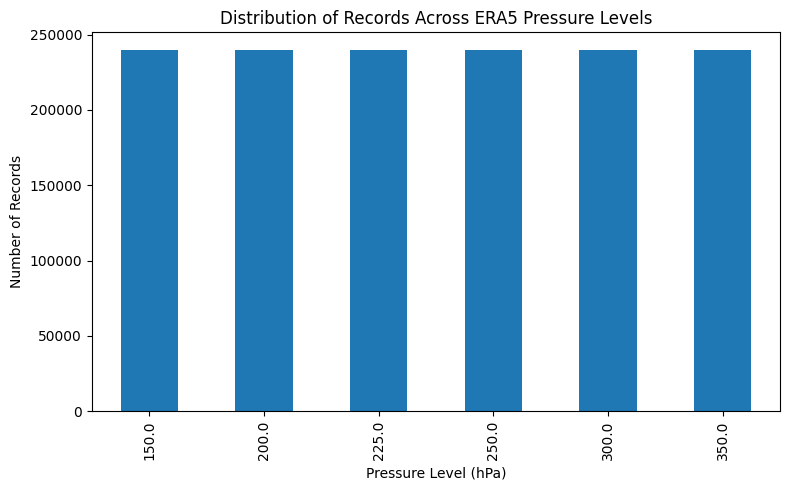

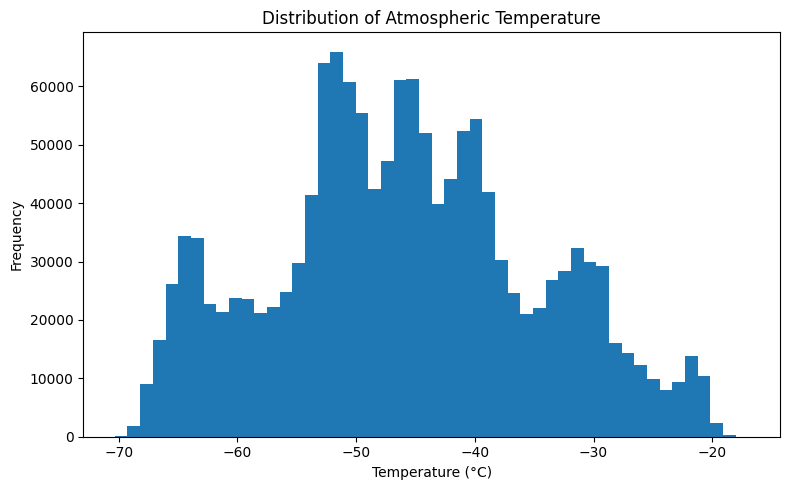

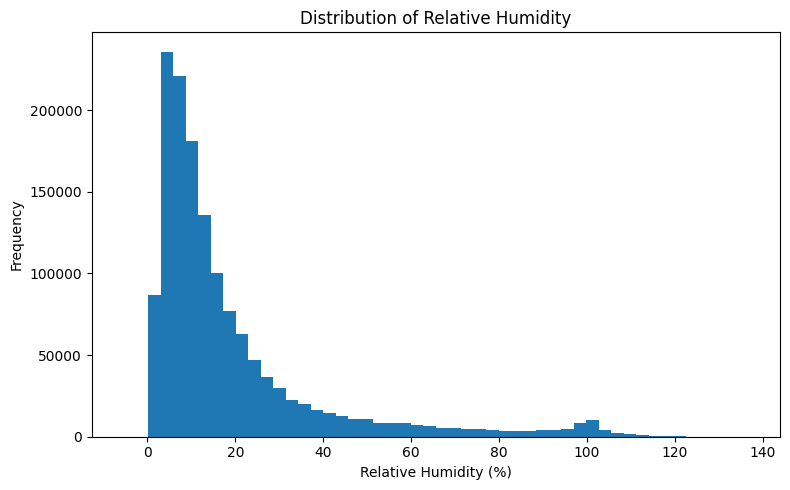

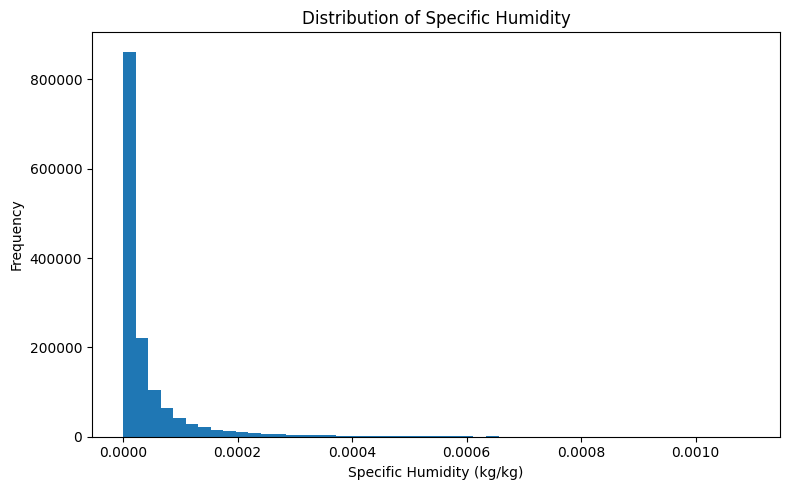

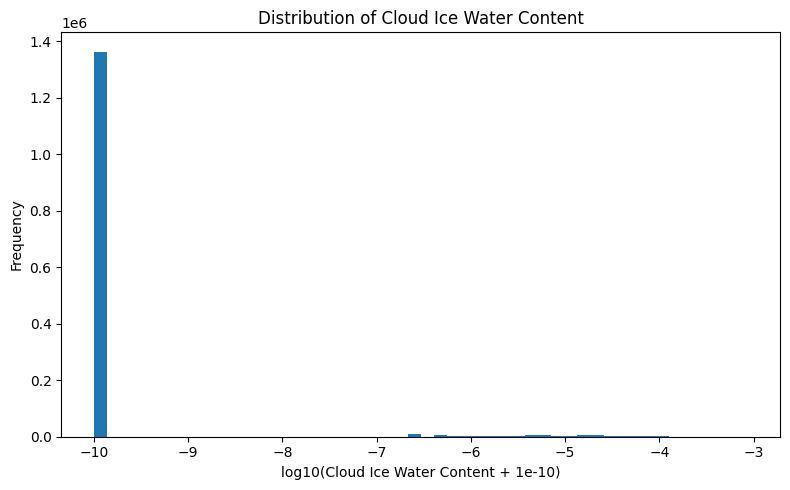

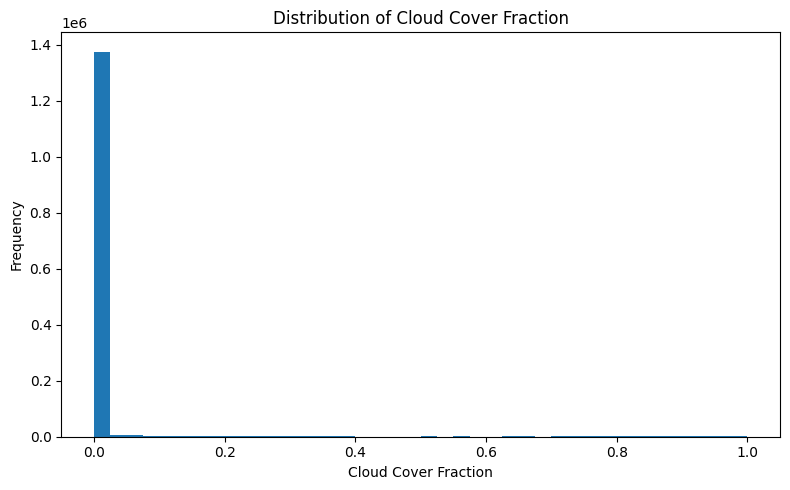

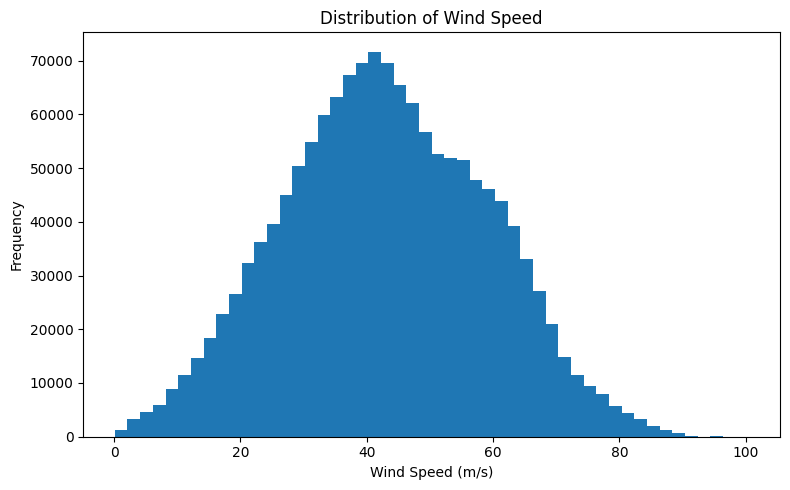

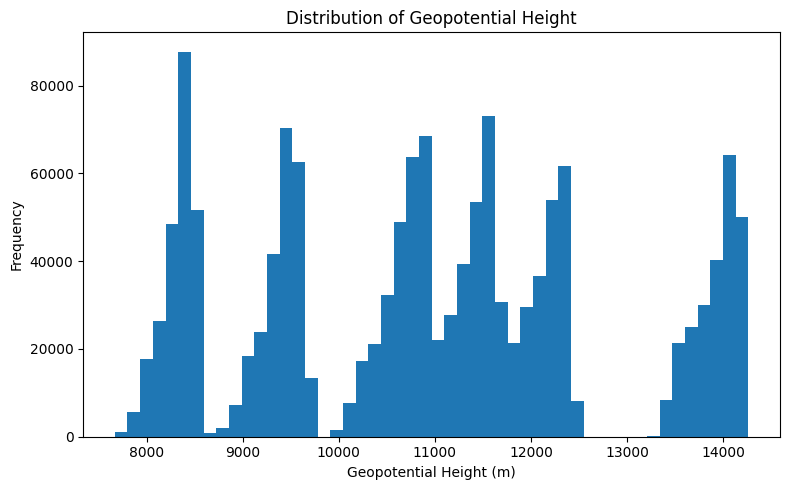

In [62]:
# UNIVARIATE EDA VISUALIZATIONS




print("UNIVARIATE EDA VISUALIZATIONS")


# ------------------------------------------------------------
# 1. Pressure-level distribution
# ------------------------------------------------------------

pressure_counts = (
    df["pressure_level"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
pressure_counts.plot(kind="bar")
plt.title("Distribution of Records Across ERA5 Pressure Levels")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Temperature distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(
    df["temperature_C"],
    bins=50
)
plt.title("Distribution of Atmospheric Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Relative humidity distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(
    df["relative_humidity_pct"],
    bins=50
)
plt.title("Distribution of Relative Humidity")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Specific humidity distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(
    df["specific_humidity_kgkg"],
    bins=50
)
plt.title("Distribution of Specific Humidity")
plt.xlabel("Specific Humidity (kg/kg)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Cloud ice water distribution
#    Log-transform because of extreme zero inflation/skewness
# ------------------------------------------------------------

cloud_ice_log = np.log10(
    df["cloud_ice_water_kgkg"] + 1e-10
)

plt.figure(figsize=(8, 5))
plt.hist(
    cloud_ice_log,
    bins=50
)
plt.title("Distribution of Cloud Ice Water Content")
plt.xlabel("log10(Cloud Ice Water Content + 1e-10)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Cloud cover distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(
    df["cloud_cover_fraction"],
    bins=40
)
plt.title("Distribution of Cloud Cover Fraction")
plt.xlabel("Cloud Cover Fraction")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Wind-speed distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(
    df["wind_speed_ms"],
    bins=50
)
plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Geopotential-height distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(
    df["geopotential_height_m"],
    bins=50
)
plt.title("Distribution of Geopotential Height")
plt.xlabel("Geopotential Height (m)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Bivariate Analysis


BIVARIATE ANALYSIS


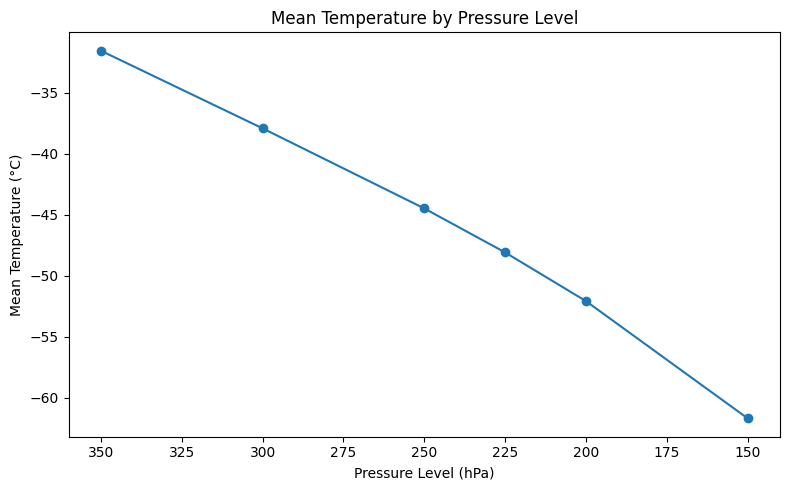

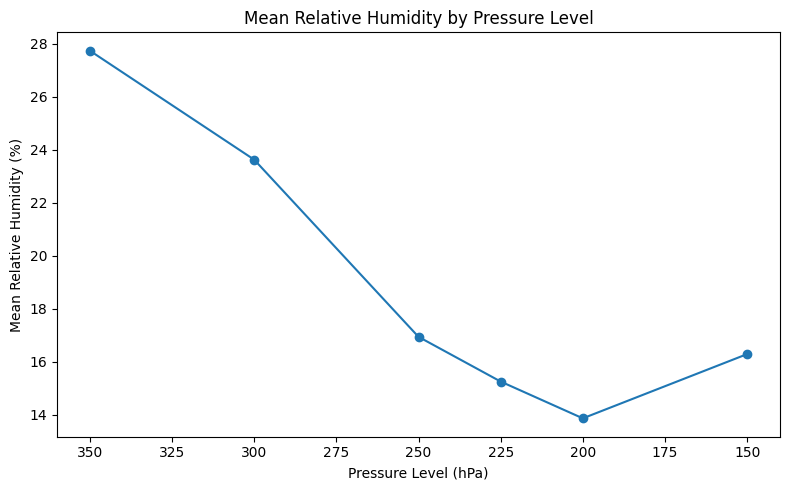

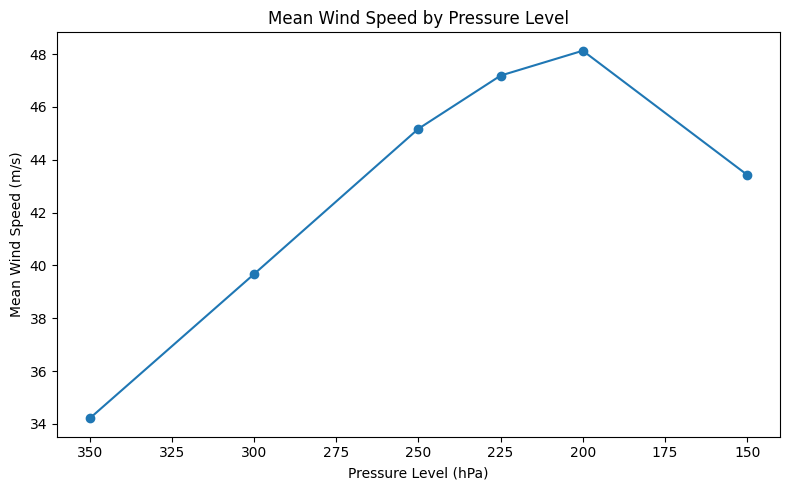

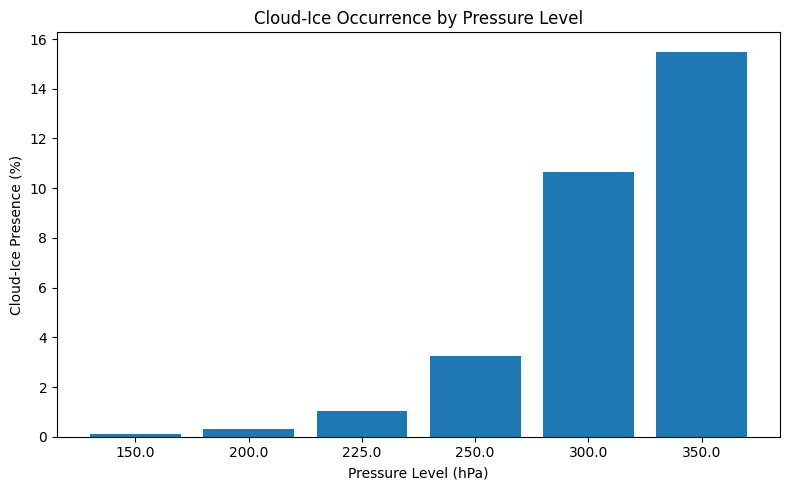

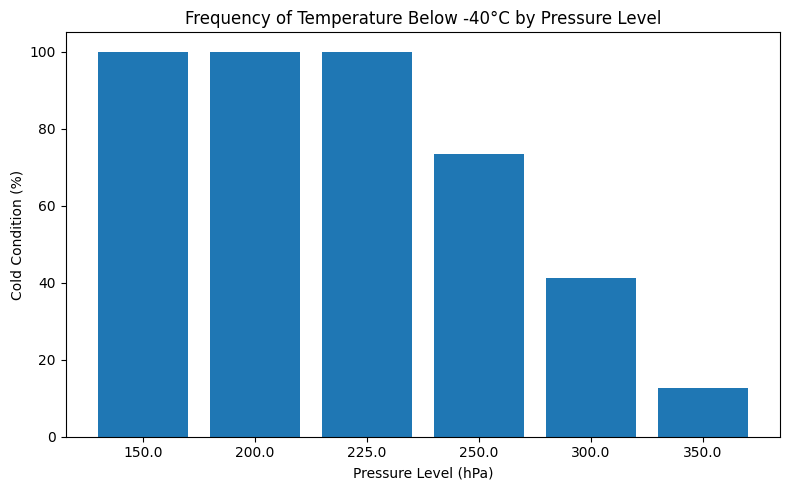

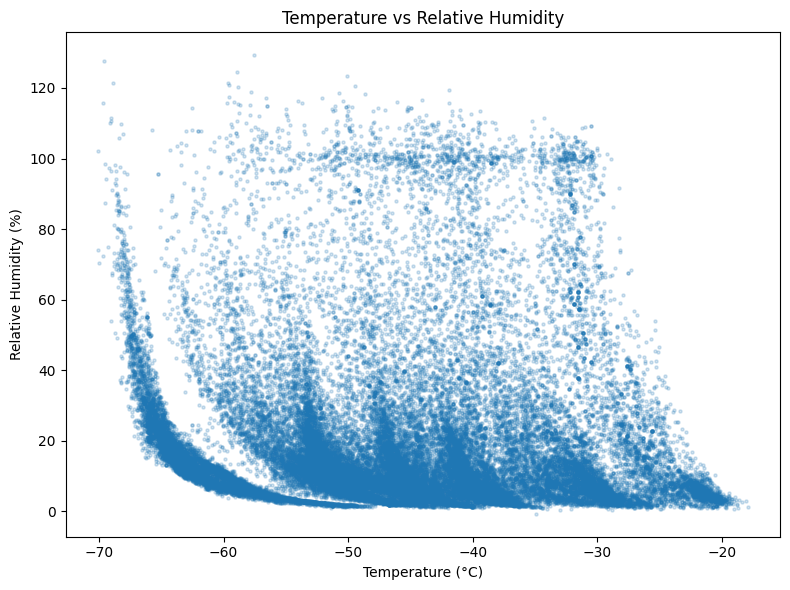

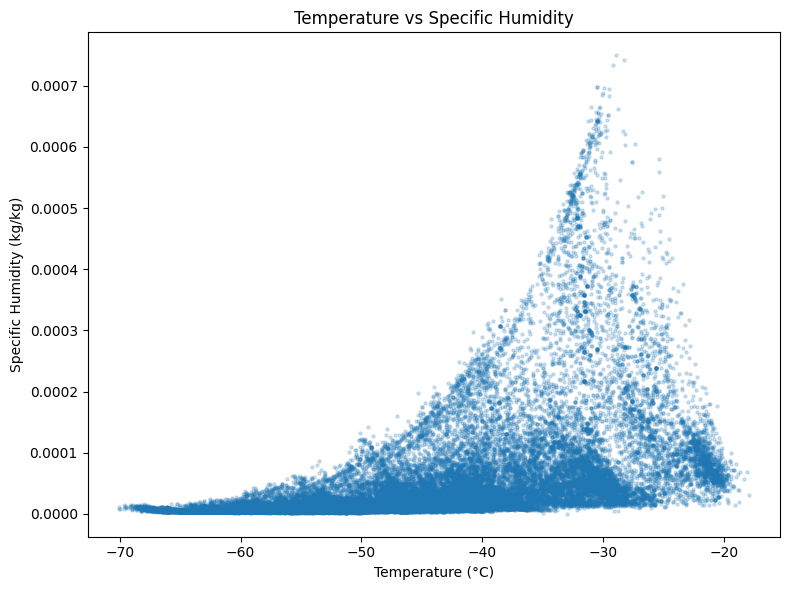


NUMERICAL SPEARMAN CORRELATION MATRIX


,pressure_level,geopotential_height_m,temperature_C,relative_humidity_pct,specific_humidity_kgkg,cloud_ice_water_kgkg,cloud_cover_fraction,wind_speed_ms
pressure_level,1.000,-0.985,0.871,0.088,0.841,0.244,0.242,-0.229
geopotential_height_m,-0.985,1.000,-0.816,-0.081,-0.783,-0.260,-0.259,0.207
temperature_C,0.871,-0.816,1.000,-0.231,0.748,0.119,0.103,-0.029
relative_humidity_pct,0.088,-0.081,-0.231,1.000,0.426,0.325,0.346,-0.303
specific_humidity_kgkg,0.841,-0.783,0.748,0.426,1.000,0.309,0.314,-0.219
cloud_ice_water_kgkg,0.244,-0.260,0.119,0.325,0.309,1.000,0.899,-0.091
cloud_cover_fraction,0.242,-0.259,0.103,0.346,0.314,0.899,1.000,-0.106
wind_speed_ms,-0.229,0.207,-0.029,-0.303,-0.219,-0.091,-0.106,1.000


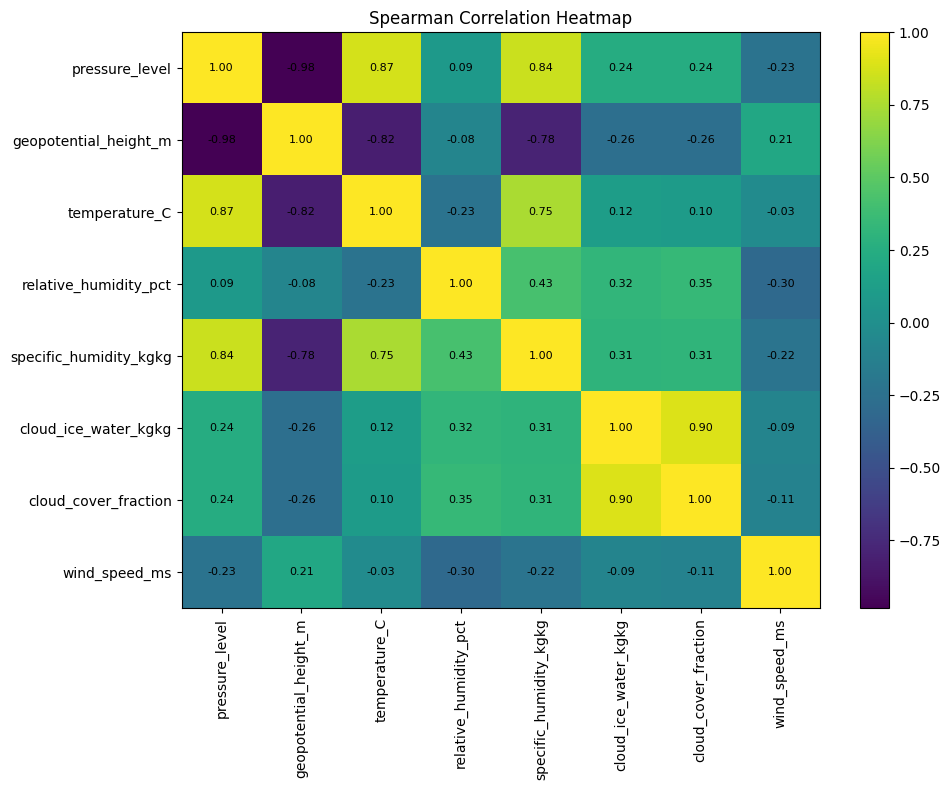

In [63]:
# BIVARIATE ANALYSIS


print("BIVARIATE ANALYSIS")


# ------------------------------------------------------------
# 1. Pressure level vs mean temperature
# ------------------------------------------------------------

temp_by_level = (
    df.groupby("pressure_level")["temperature_C"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    temp_by_level.index,
    temp_by_level.values,
    marker="o"
)
plt.title("Mean Temperature by Pressure Level")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Mean Temperature (°C)")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Pressure level vs mean relative humidity
# ------------------------------------------------------------

rh_by_level = (
    df.groupby("pressure_level")["relative_humidity_pct"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    rh_by_level.index,
    rh_by_level.values,
    marker="o"
)
plt.title("Mean Relative Humidity by Pressure Level")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Mean Relative Humidity (%)")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Pressure level vs mean wind speed
# ------------------------------------------------------------

wind_by_level = (
    df.groupby("pressure_level")["wind_speed_ms"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    wind_by_level.index,
    wind_by_level.values,
    marker="o"
)
plt.title("Mean Wind Speed by Pressure Level")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Mean Wind Speed (m/s)")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Cloud-ice occurrence by pressure level
# ------------------------------------------------------------

cloud_ice_by_level = (
    df.assign(
        cloud_ice_present=
        df["cloud_ice_water_kgkg"] > 0
    )
    .groupby("pressure_level")["cloud_ice_present"]
    .mean()
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    cloud_ice_by_level.index.astype(str),
    cloud_ice_by_level.values
)
plt.title("Cloud-Ice Occurrence by Pressure Level")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Cloud-Ice Presence (%)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Cold-condition frequency by pressure level
# ------------------------------------------------------------

cold_by_level = (
    df.assign(
        cold_condition=
        df["temperature_C"] < -40
    )
    .groupby("pressure_level")["cold_condition"]
    .mean()
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    cold_by_level.index.astype(str),
    cold_by_level.values
)
plt.title("Frequency of Temperature Below -40°C by Pressure Level")
plt.xlabel("Pressure Level (hPa)")
plt.ylabel("Cold Condition (%)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Temperature vs relative humidity
#    Use sample because full dataset has 1.4M rows
# ------------------------------------------------------------

scatter_sample = df[
    [
        "temperature_C",
        "relative_humidity_pct"
    ]
].sample(
    n=min(50000, len(df)),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_sample["temperature_C"],
    scatter_sample["relative_humidity_pct"],
    s=5,
    alpha=0.2
)
plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Temperature vs specific humidity
# ------------------------------------------------------------

scatter_sample2 = df[
    [
        "temperature_C",
        "specific_humidity_kgkg"
    ]
].sample(
    n=min(50000, len(df)),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_sample2["temperature_C"],
    scatter_sample2["specific_humidity_kgkg"],
    s=5,
    alpha=0.2
)
plt.title("Temperature vs Specific Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Specific Humidity (kg/kg)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Correlation heatmap
# ------------------------------------------------------------

corr_vars = [
    "pressure_level",
    "geopotential_height_m",
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms"
]

corr_matrix = (
    df[corr_vars]
    .corr(method="spearman")
)

print("\nNUMERICAL SPEARMAN CORRELATION MATRIX")
display(corr_matrix.round(3))

plt.figure(figsize=(10, 8))

im = plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(im)

plt.xticks(
    range(len(corr_vars)),
    corr_vars,
    rotation=90
)

plt.yticks(
    range(len(corr_vars)),
    corr_vars
)

plt.title("Spearman Correlation Heatmap")

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()


## Multivariate Analysis


MULTIVARIATE EDA

Rows used      : 1,437,384
Variables used : 7

PCA EXPLAINED VARIANCE


,Principal_Component,Explained_Variance_Percent,Cumulative_Variance_Percent
0,PC1,40.731998,40.731998
1,PC2,24.025000,64.757004
2,PC3,14.745000,79.501999
3,PC4,9.863000,89.364998
4,PC5,5.981000,95.346001
5,PC6,3.684000,99.029999
6,PC7,0.970000,100.000000



PCA LOADINGS


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
geopotential_height_m,-0.416,-0.485,0.036,-0.039,-0.249,0.504,0.523
temperature_C,0.332,0.604,0.153,0.097,0.059,0.179,0.675
relative_humidity_pct,0.401,-0.387,-0.234,-0.482,-0.017,-0.489,0.403
specific_humidity_kgkg,0.504,0.037,0.004,-0.356,-0.525,0.492,-0.315
cloud_ice_water_kgkg,0.325,-0.315,0.407,0.633,-0.401,-0.256,0.041
cloud_cover_fraction,0.402,-0.384,0.203,0.076,0.705,0.377,-0.073
wind_speed_ms,-0.187,0.048,0.844,-0.472,0.022,-0.159,-0.034



TOP CONTRIBUTING VARIABLES - FIRST 3 PCs

 PC1


,Absolute_Loading
specific_humidity_kgkg,0.504
geopotential_height_m,0.416
cloud_cover_fraction,0.402
relative_humidity_pct,0.401
temperature_C,0.332



 PC2


,Absolute_Loading
temperature_C,0.604
geopotential_height_m,0.485
relative_humidity_pct,0.387
cloud_cover_fraction,0.384
cloud_ice_water_kgkg,0.315



 PC3


,Absolute_Loading
wind_speed_ms,0.844
cloud_ice_water_kgkg,0.407
relative_humidity_pct,0.234
cloud_cover_fraction,0.203
temperature_C,0.153


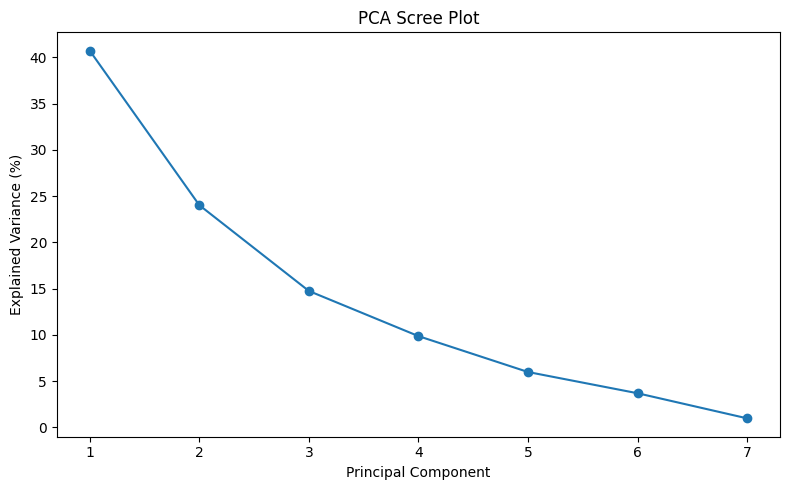

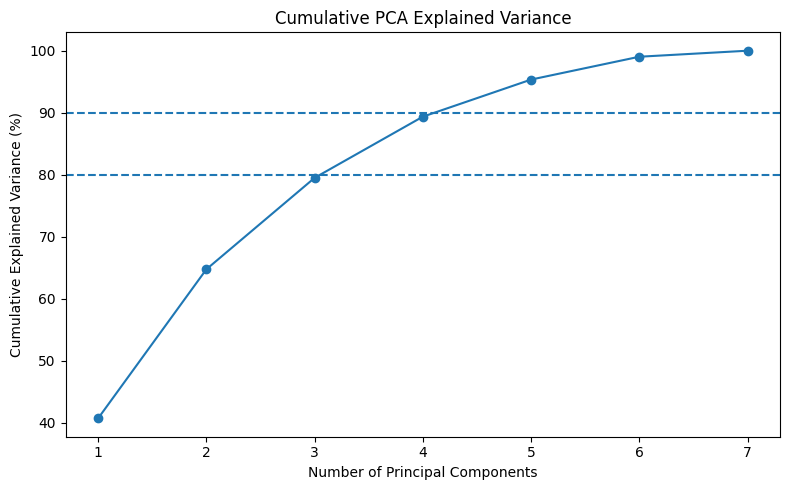

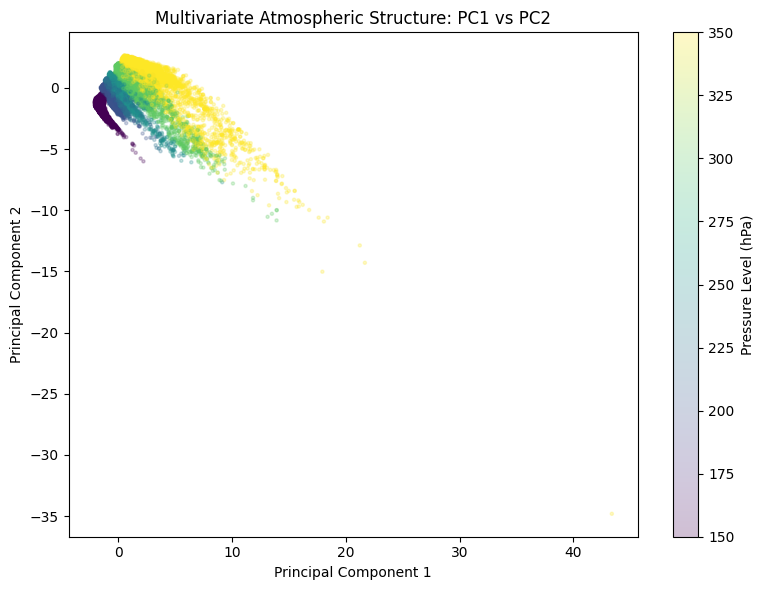


MULTIVARIATE PROFILE BY PRESSURE LEVEL


,pressure_level,Mean_Height_m,Mean_Temperature_C,Mean_RH_pct,Mean_Specific_Humidity,Mean_Cloud_Ice,Cloud_Ice_Presence_pct,Mean_Cloud_Cover,Cloud_Cover_Presence_pct,Mean_Wind_Speed_ms,Cold_Below_Minus40_pct
0,150.0,13924.321289,-61.702599,16.284901,0.0000,0.0,0.1069,0.0004,0.2066,43.428600,100.0000
1,200.0,12103.600586,-52.089001,13.859700,0.0000,0.0,0.3172,0.0005,0.4316,48.126900,100.0000
2,225.0,11334.568359,-48.096298,15.248100,0.0000,0.0,1.0327,0.0021,1.3399,47.185600,99.8180
3,250.0,10635.013672,-44.487400,16.936199,0.0000,0.0,3.2634,0.0069,3.9764,45.172798,73.4960
4,300.0,9397.418945,-37.920101,23.623199,0.0001,0.0,10.6598,0.0355,11.7054,39.672298,41.2562
5,350.0,8321.799805,-31.553801,27.736500,0.0001,0.0,15.4948,0.0529,15.4785,34.208500,12.5649



JOINT ATMOSPHERIC CONDITIONS


,Condition,Count,Percent
0,Cold only,1023262,71.189
1,Cold + RH >= 60%,58292,4.055
2,Cold + RH >= 80%,33367,2.321
3,Cold + Cloud Ice,39104,2.720
4,Cold + RH >= 60% + Cloud Ice,28363,1.973
5,Cold + RH >= 80% + Cloud Ice,24400,1.698



JOINT CONDITIONS BY PRESSURE LEVEL


,pressure_level,Cold_pct,Cold_RH60_pct,Cold_RH80_pct,Cold_CloudIce_pct
0,150.0,100.000,1.988,0.485,0.107
1,200.0,100.000,1.550,0.375,0.317
2,225.0,99.818,3.022,1.294,1.033
3,250.0,73.496,4.264,2.258,3.192
4,300.0,41.256,9.162,6.253,7.472
5,350.0,12.565,4.347,3.264,4.202


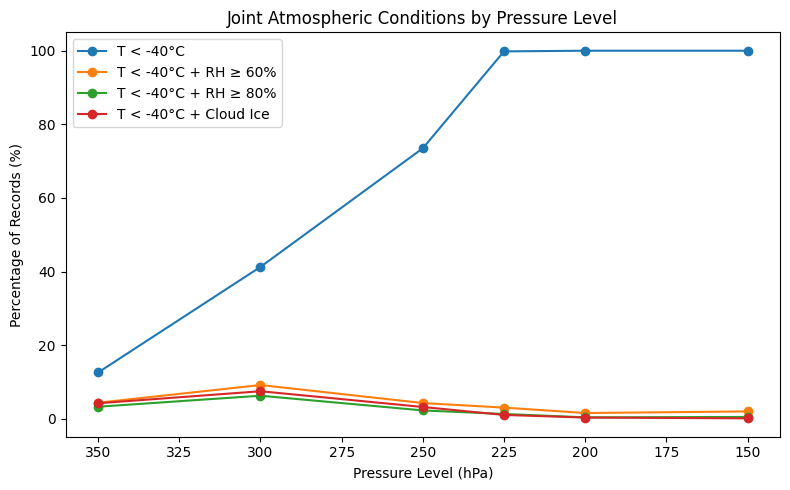

MULTIVARIATE EDA COMPLETE


In [64]:
# MULTIVARIATE EDA



print("MULTIVARIATE EDA")


# ------------------------------------------------------------
# 1. FINAL VARIABLES
# ------------------------------------------------------------

multivariate_vars = [
    # Pressure level is retained for grouping/colouring but excluded
    # from PCA to avoid duplicating vertical structure represented by height.
    "geopotential_height_m",
    "temperature_C",
    "relative_humidity_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms"
]

X = df[multivariate_vars].copy()

print(f"\nRows used      : {len(X):,}")
print(f"Variables used : {len(multivariate_vars)}")

# ------------------------------------------------------------
# 2. STANDARDIZE VARIABLES
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 3. PCA
# ------------------------------------------------------------

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = (
    pca.explained_variance_ratio_ * 100
)

cumulative_variance = np.cumsum(
    explained_variance
)

pca_variance = pd.DataFrame({
    "Principal_Component": [
        f"PC{i+1}"
        for i in range(len(multivariate_vars))
    ],
    "Explained_Variance_Percent":
        explained_variance,
    "Cumulative_Variance_Percent":
        cumulative_variance
})

print("\nPCA EXPLAINED VARIANCE")

display(
    pca_variance.round(3)
)

# ------------------------------------------------------------
# 4. PCA LOADINGS
# ------------------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=multivariate_vars,
    columns=[
        f"PC{i+1}"
        for i in range(len(multivariate_vars))
    ]
)

print("\nPCA LOADINGS")

display(
    loadings.round(3)
)

# ------------------------------------------------------------
# 5. STRONGEST VARIABLE CONTRIBUTIONS
# ------------------------------------------------------------

print("\nTOP CONTRIBUTING VARIABLES - FIRST 3 PCs")

for pc in ["PC1", "PC2", "PC3"]:

    print("\n", pc)

    contribution = (
        loadings[pc]
        .abs()
        .sort_values(
            ascending=False
        )
    )

    display(
        contribution
        .head(5)
        .rename("Absolute_Loading")
        .to_frame()
        .round(3)
    )

# ------------------------------------------------------------
# 6. SCREE PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(explained_variance) + 1
    ),
    explained_variance,
    marker="o"
)

plt.title(
    "PCA Scree Plot"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance (%)"
)

plt.xticks(
    range(
        1,
        len(explained_variance) + 1
    )
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. CUMULATIVE EXPLAINED VARIANCE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    80,
    linestyle="--"
)

plt.axhline(
    90,
    linestyle="--"
)

plt.title(
    "Cumulative PCA Explained Variance"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.xticks(
    range(
        1,
        len(cumulative_variance) + 1
    )
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. PCA SCATTER SAMPLE - PC1 VS PC2
# ------------------------------------------------------------

pca_scores = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "pressure_level":
        df["pressure_level"].values
})

pca_sample = (
    pca_scores
    .sample(
        n=min(
            50000,
            len(pca_scores)
        ),
        random_state=42
    )
)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pca_sample["PC1"],
    pca_sample["PC2"],
    c=pca_sample["pressure_level"],
    cmap="viridis",
    s=5,
    alpha=0.25
)
plt.colorbar(scatter, label="Pressure Level (hPa)")

plt.title(
    "Multivariate Atmospheric Structure: PC1 vs PC2"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. MULTIVARIATE ATMOSPHERIC SUMMARY BY PRESSURE LEVEL
# ------------------------------------------------------------

print("\nMULTIVARIATE PROFILE BY PRESSURE LEVEL")

multivariate_level_summary = (
    df.groupby("pressure_level")
    .agg(
        Mean_Height_m=(
            "geopotential_height_m",
            "mean"
        ),

        Mean_Temperature_C=(
            "temperature_C",
            "mean"
        ),

        Mean_RH_pct=(
            "relative_humidity_pct",
            "mean"
        ),

        Mean_Specific_Humidity=(
            "specific_humidity_kgkg",
            "mean"
        ),

        Mean_Cloud_Ice=(
            "cloud_ice_water_kgkg",
            "mean"
        ),

        Cloud_Ice_Presence_pct=(
            "cloud_ice_water_kgkg",
            lambda x:
            (x > 0).mean() * 100
        ),

        Mean_Cloud_Cover=(
            "cloud_cover_fraction",
            "mean"
        ),

        Cloud_Cover_Presence_pct=(
            "cloud_cover_fraction",
            lambda x:
            (x > 0).mean() * 100
        ),

        Mean_Wind_Speed_ms=(
            "wind_speed_ms",
            "mean"
        ),

        Cold_Below_Minus40_pct=(
            "temperature_C",
            lambda x:
            (x < -40).mean() * 100
        )
    )
    .reset_index()
    .sort_values(
        "pressure_level"
    )
)

display(
    multivariate_level_summary.round(4)
)

# ------------------------------------------------------------
# 10. TEMPERATURE + RH + CLOUD-ICE JOINT CONDITIONS
# ------------------------------------------------------------

df["cold_flag"] = (
    df["temperature_C"] < -40
)

df["high_rh_flag"] = (
    df["relative_humidity_pct"] >= 60
)

df["very_high_rh_flag"] = (
    df["relative_humidity_pct"] >= 80
)

df["cloud_ice_flag"] = (
    df["cloud_ice_water_kgkg"] > 0
)

joint_conditions = pd.DataFrame({

    "Condition": [
        "Cold only",
        "Cold + RH >= 60%",
        "Cold + RH >= 80%",
        "Cold + Cloud Ice",
        "Cold + RH >= 60% + Cloud Ice",
        "Cold + RH >= 80% + Cloud Ice"
    ],

    "Count": [
        df["cold_flag"].sum(),

        (
            df["cold_flag"]
            & df["high_rh_flag"]
        ).sum(),

        (
            df["cold_flag"]
            & df["very_high_rh_flag"]
        ).sum(),

        (
            df["cold_flag"]
            & df["cloud_ice_flag"]
        ).sum(),

        (
            df["cold_flag"]
            & df["high_rh_flag"]
            & df["cloud_ice_flag"]
        ).sum(),

        (
            df["cold_flag"]
            & df["very_high_rh_flag"]
            & df["cloud_ice_flag"]
        ).sum()
    ]
})

joint_conditions["Percent"] = (
    joint_conditions["Count"]
    / len(df)
    * 100
)

print("\nJOINT ATMOSPHERIC CONDITIONS")

display(
    joint_conditions.round(3)
)

# ------------------------------------------------------------
# 11. JOINT CONDITIONS BY PRESSURE LEVEL
# ------------------------------------------------------------

joint_by_level = (
    df.groupby("pressure_level")
    .apply(
        lambda g: pd.Series({

            "Cold_pct":
                (
                    g["temperature_C"]
                    < -40
                ).mean() * 100,

            "Cold_RH60_pct":
                (
                    (g["temperature_C"] < -40)
                    &
                    (
                        g[
                            "relative_humidity_pct"
                        ] >= 60
                    )
                ).mean() * 100,

            "Cold_RH80_pct":
                (
                    (g["temperature_C"] < -40)
                    &
                    (
                        g[
                            "relative_humidity_pct"
                        ] >= 80
                    )
                ).mean() * 100,

            "Cold_CloudIce_pct":
                (
                    (g["temperature_C"] < -40)
                    &
                    (
                        g[
                            "cloud_ice_water_kgkg"
                        ] > 0
                    )
                ).mean() * 100

        })
    )
    .reset_index()
)

print("\nJOINT CONDITIONS BY PRESSURE LEVEL")

display(
    joint_by_level.round(3)
)

# ------------------------------------------------------------
# 12. MULTIVARIATE PRESSURE-LEVEL GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    joint_by_level["pressure_level"],
    joint_by_level["Cold_pct"],
    marker="o",
    label="T < -40°C"
)

plt.plot(
    joint_by_level["pressure_level"],
    joint_by_level["Cold_RH60_pct"],
    marker="o",
    label="T < -40°C + RH ≥ 60%"
)

plt.plot(
    joint_by_level["pressure_level"],
    joint_by_level["Cold_RH80_pct"],
    marker="o",
    label="T < -40°C + RH ≥ 80%"
)

plt.plot(
    joint_by_level["pressure_level"],
    joint_by_level["Cold_CloudIce_pct"],
    marker="o",
    label="T < -40°C + Cloud Ice"
)

plt.gca().invert_xaxis()

plt.title(
    "Joint Atmospheric Conditions by Pressure Level"
)

plt.xlabel(
    "Pressure Level (hPa)"
)

plt.ylabel(
    "Percentage of Records (%)"
)

plt.legend()

plt.tight_layout()
plt.show()

print("MULTIVARIATE EDA COMPLETE")


## Statistical Validation

P-values are interpreted together with effect sizes because waypoint-pressure observations are clustered within flights and ERA5 environments.


In [65]:
#  STATISTICAL VALIDATION



print("STATISTICAL VALIDATION")


# 1. CHI-SQUARE:
#    PRESSURE LEVEL × CONTRAIL SUSCEPTIBILITY

print("\n1. CHI-SQUARE TEST - PRESSURE LEVEL × CONTRAIL SUSCEPTIBILITY")

contingency_table = pd.crosstab(
    df["pressure_level"],
    df["contrail_susceptible"]
)

display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

n = contingency_table.to_numpy().sum()

r, k = contingency_table.shape

cramers_v = np.sqrt(
    chi2
    /
    (
        n * min(
            r - 1,
            k - 1
        )
    )
)

print(f"\nChi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.6e}")
print(f"Cramer's V           : {cramers_v:.4f}")

if p_value < 0.05:
    print(
        "Result               : Significant association "
        "between pressure level and susceptibility."
    )
else:
    print(
        "Result               : No statistically significant association."
    )


# 2. SUSCEPTIBLE VS NON-SUSCEPTIBLE:
#    MANN-WHITNEY U

print("\n" + "=" * 105)
print("2. MANN-WHITNEY U - SUSCEPTIBLE VS NON-SUSCEPTIBLE")
print("=" * 105)

comparison_vars = [
    "temperature_C",
    "relative_humidity_pct",
    "RHi_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms",
    "geopotential_height_m"
]

mw_results = []

for var in comparison_vars:

    group0 = df.loc[
        df["contrail_susceptible"] == 0,
        var
    ].dropna()

    group1 = df.loc[
        df["contrail_susceptible"] == 1,
        var
    ].dropna()

    u_stat, p = mannwhitneyu(
        group1,
        group0,
        alternative="two-sided"
    )

    n1 = len(group1)
    n0 = len(group0)

    # Rank-biserial effect size
    rank_biserial = (
        2 * u_stat
        / (n1 * n0)
    ) - 1

    mw_results.append({
        "Variable": var,
        "NonSusceptible_N": n0,
        "Susceptible_N": n1,
        "NonSusceptible_Median": group0.median(),
        "Susceptible_Median": group1.median(),
        "U_Statistic": u_stat,
        "P_Value": p,
        "Rank_Biserial": rank_biserial
    })

mw_results_df = pd.DataFrame(
    mw_results
)

display(
    mw_results_df.round(6)
)


# 3. EFFECT SIZE INTERPRETATION

def effect_label(x):

    a = abs(x)

    if a < 0.10:
        return "Negligible"
    elif a < 0.30:
        return "Small"
    elif a < 0.50:
        return "Moderate"
    else:
        return "Large"


mw_results_df[
    "Effect_Size"
] = mw_results_df[
    "Rank_Biserial"
].apply(
    effect_label
)

print("\nEFFECT SIZE INTERPRETATION")

display(
    mw_results_df[
        [
            "Variable",
            "P_Value",
            "Rank_Biserial",
            "Effect_Size"
        ]
    ].round(6)
)


# 4. KRUSKAL-WALLIS:
#    DIFFERENCES ACROSS PRESSURE LEVELS

print("\n" + "=" * 105)
print("3. KRUSKAL-WALLIS - ATMOSPHERIC VARIABLES ACROSS PRESSURE LEVELS")
print("=" * 105)

kw_vars = [
    "temperature_C",
    "relative_humidity_pct",
    "RHi_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms",
    "geopotential_height_m"
]

pressure_levels = sorted(
    df["pressure_level"]
    .dropna()
    .unique()
)

kw_results = []

for var in kw_vars:

    groups = [
        df.loc[
            df["pressure_level"] == level,
            var
        ].dropna()
        for level in pressure_levels
    ]

    h_stat, p = kruskal(
        *groups
    )

    kw_results.append({
        "Variable": var,
        "H_Statistic": h_stat,
        "P_Value": p
    })

kw_results_df = pd.DataFrame(
    kw_results
)

display(
    kw_results_df.round(6)
)


# 5. PRESSURE-LEVEL SUSCEPTIBILITY TABLE

print("\n" + "=" * 105)
print("4. SUSCEPTIBILITY RATE BY PRESSURE LEVEL")
print("=" * 105)

pressure_validation = (
    df.groupby("pressure_level")
    ["contrail_susceptible"]
    .agg(
        Susceptible_Count="sum",
        Total_Count="count",
        Susceptible_Rate="mean"
    )
    .reset_index()
)

pressure_validation[
    "Susceptible_Percent"
] = (
    pressure_validation[
        "Susceptible_Rate"
    ]
    * 100
)

display(
    pressure_validation[
        [
            "pressure_level",
            "Susceptible_Count",
            "Total_Count",
            "Susceptible_Percent"
        ]
    ].round(4)
)


# 6. MULTIPLE-COMPARISON CORRECTION
#    BENJAMINI-HOCHBERG FOR MANN-WHITNEY TESTS

print("\n" + "=" * 105)
print("5. MULTIPLE-TEST CORRECTION - BENJAMINI-HOCHBERG")
print("=" * 105)

pvals = mw_results_df[
    "P_Value"
].to_numpy()

order = np.argsort(pvals)

ranked_p = pvals[
    order
]

m = len(pvals)

adjusted = np.empty(
    m,
    dtype=float
)

running_min = 1.0

for i in range(
    m - 1,
    -1,
    -1
):

    rank = i + 1

    value = (
        ranked_p[i]
        * m
        / rank
    )

    running_min = min(
        running_min,
        value
    )

    adjusted[i] = min(
        running_min,
        1.0
    )

adjusted_original_order = np.empty(
    m,
    dtype=float
)

adjusted_original_order[
    order
] = adjusted

mw_results_df[
    "BH_Adjusted_P"
] = adjusted_original_order

mw_results_df[
    "Significant_After_BH"
] = (
    mw_results_df[
        "BH_Adjusted_P"
    ] < 0.05
)

display(
    mw_results_df[
        [
            "Variable",
            "P_Value",
            "BH_Adjusted_P",
            "Rank_Biserial",
            "Effect_Size",
            "Significant_After_BH"
        ]
    ].round(6)
)

print("SECTION 9F COMPLETE")


STATISTICAL VALIDATION

1. CHI-SQUARE TEST - PRESSURE LEVEL × CONTRAIL SUSCEPTIBILITY


contrail_susceptible,0,1
pressure_level,,
150.0,239202,362
200.0,239374,190
225.0,238505,1059
250.0,237573,1991
300.0,233229,6335
350.0,236372,3192



Chi-square statistic : 12381.5155
Degrees of freedom   : 5
P-value              : 0.000000e+00
Cramer's V           : 0.0928
Result               : Significant association between pressure level and susceptibility.

2. MANN-WHITNEY U - SUSCEPTIBLE VS NON-SUSCEPTIBLE


,Variable,NonSusceptible_N,Susceptible_N,NonSusceptible_Median,Susceptible_Median,U_Statistic,P_Value,Rank_Biserial
0,temperature_C,1424255,13129,-46.304901,-47.618225,8.041576e+09,0.0,-0.139894
1,relative_humidity_pct,1424255,13129,11.338563,103.518112,1.866383e+10,0.0,0.996234
2,RHi_pct,1424255,13129,11.313962,103.643124,1.866794e+10,0.0,0.996674
3,specific_humidity_kgkg,1424255,13129,0.000016,0.000116,1.627552e+10,0.0,0.740786
4,cloud_ice_water_kgkg,1424255,13129,0.000000,0.000007,1.749825e+10,0.0,0.871566
5,cloud_cover_fraction,1424255,13129,0.000000,0.531250,1.814355e+10,0.0,0.940586
6,wind_speed_ms,1424255,13129,42.657421,31.924858,5.829783e+09,0.0,-0.376462
7,geopotential_height_m,1424255,13129,10918.171875,9263.408203,4.506457e+09,0.0,-0.518001



EFFECT SIZE INTERPRETATION


...


4. SUSCEPTIBILITY RATE BY PRESSURE LEVEL


,pressure_level,Susceptible_Count,Total_Count,Susceptible_Percent
0,150.0,362,239564,0.1511
1,200.0,190,239564,0.0793
2,225.0,1059,239564,0.4421
3,250.0,1991,239564,0.8311
4,300.0,6335,239564,2.6444
5,350.0,3192,239564,1.3324



5. MULTIPLE-TEST CORRECTION - BENJAMINI-HOCHBERG


,Variable,P_Value,BH_Adjusted_P,Rank_Biserial,Effect_Size,Significant_After_BH
0,temperature_C,0.0,0.0,-0.139894,Small,True
1,relative_humidity_pct,0.0,0.0,0.996234,Large,True
2,RHi_pct,0.0,0.0,0.996674,Large,True
3,specific_humidity_kgkg,0.0,0.0,0.740786,Large,True
4,cloud_ice_water_kgkg,0.0,0.0,0.871566,Large,True
5,cloud_cover_fraction,0.0,0.0,0.940586,Large,True
6,wind_speed_ms,0.0,0.0,-0.376462,Moderate,True
7,geopotential_height_m,0.0,0.0,-0.518001,Large,True


SECTION 9F COMPLETE


## Susceptible vs Non-Susceptible Atmospheric Profiles


SUSCEPTIBLE VS NON-SUSCEPTIBLE ATMOSPHERIC PROFILE

ATMOSPHERIC PROFILE BY SUSCEPTIBILITY CLASS


pressure_level                 geopotential_height_m  \
                               mean median      std                  mean   
contrail_susceptible                                                        
0                          245.3991  225.0  65.2086          10966.477539   
1                          292.9412  300.0  46.4338           9467.663086   

                                                temperature_C             \
                            median          std          mean     median   
contrail_susceptible                                                       
0                     10918.171875  1825.440430    -45.948002 -46.304901   
1                      9263.408203  1283.060059    -48.888302 -47.618198   

                              relative_humidity_pct                         \
                          std                  mean      median        std   
contrail_susceptible                                                         
0                     11.1414             18.153700   11.338600  19.381399   
1                      6.8076            105.123398  103.518097   5.307200   

                       RHi_pct                    specific_humidity_kgkg  \
                          mean    median      std                   mean   
contrail_susceptible                                                       
0                      18.1260   11.3140  19.3755                 0.0000   
1                     105.2887  103.6431   5.2145                 0.0001   

                                     cloud_ice_water_kgkg              \
                      median     std                 mean median  std   
contrail_susceptible                                                    
0                     0.0000  0.0001                  0.0    0.0  0.0   
1                     0.0001  0.0001                  0.0    0.0  0.0   

                     cloud_cover_fraction                 wind_speed_ms  \
                                     mean  median     std          mean   
contrail_susceptible                                                      
0                                  0.0119  0.0000  0.0846     43.057098   
1                                  0.5049  0.5312  0.3098     33.063000   

                                            
                         median        std  
contrail_susceptible                        
0                     42.657398  16.119699  
1                     31.924900  14.067500


CLASS COMPARISON


,Variable,NonSusceptible_Mean,Susceptible_Mean,NonSusceptible_Median,Susceptible_Median,Mean_Difference
0,pressure_level,245.39909,292.94120,225.00000,300.00000,47.54211
1,geopotential_height_m,10966.47852,9467.66309,10918.17188,9263.40820,-1498.81543
2,temperature_C,-45.94803,-48.88830,-46.30490,-47.61823,-2.94027
3,relative_humidity_pct,18.15372,105.12341,11.33856,103.51811,86.96970
4,RHi_pct,18.12596,105.28874,11.31396,103.64312,87.16278
5,specific_humidity_kgkg,0.00004,0.00012,0.00002,0.00012,0.00008
6,cloud_ice_water_kgkg,0.00000,0.00001,0.00000,0.00001,0.00001
7,cloud_cover_fraction,0.01190,0.50488,0.00000,0.53125,0.49299
8,wind_speed_ms,43.05706,33.06301,42.65742,31.92486,-9.99405



SUSCEPTIBILITY BY PRESSURE LEVEL


,pressure_level,Susceptible_Count,Total_Count,Susceptible_Percent
0,150.0,362,239564,0.151
1,200.0,190,239564,0.079
2,225.0,1059,239564,0.442
3,250.0,1991,239564,0.831
4,300.0,6335,239564,2.644
5,350.0,3192,239564,1.332


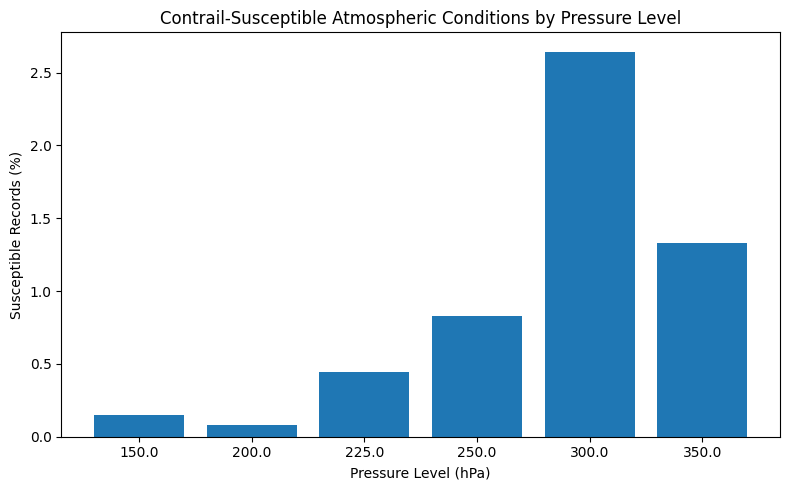

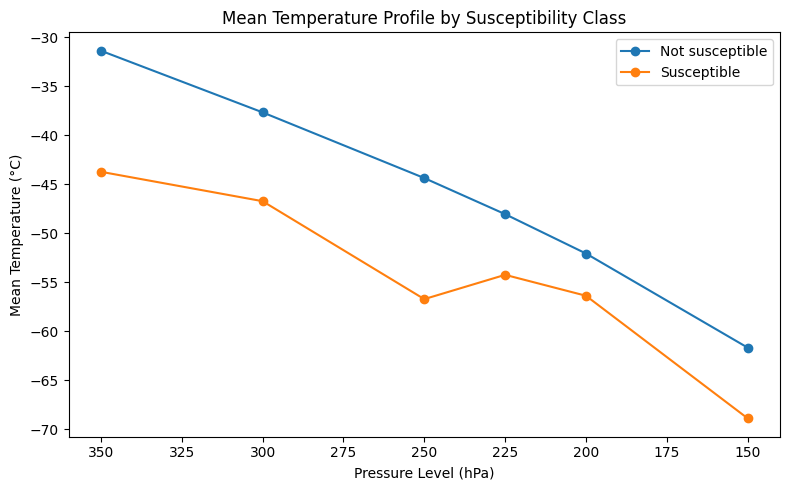

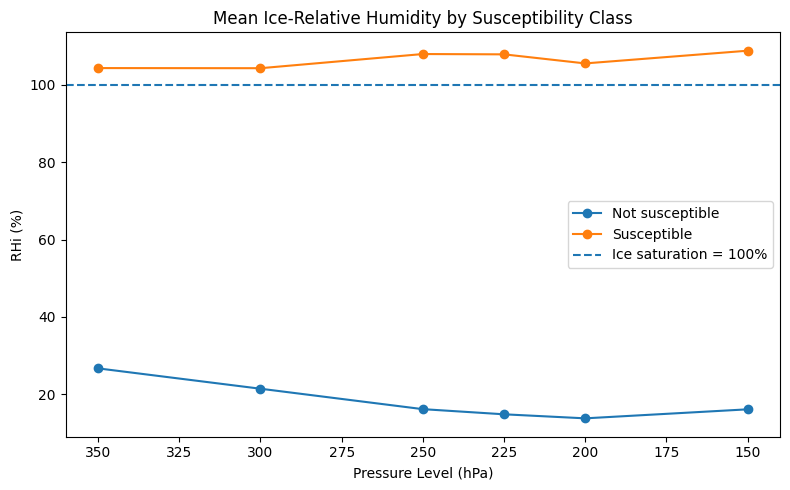

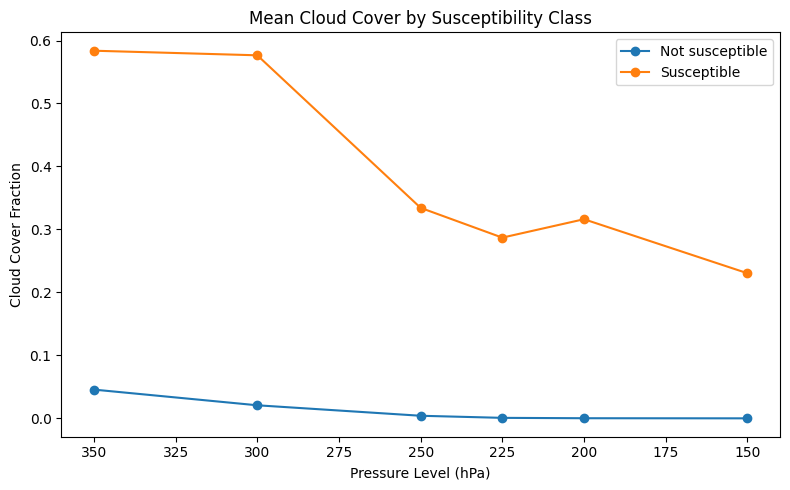

COMPLETE


In [66]:
# SECTION 9G - SUSCEPTIBLE VS NON-SUSCEPTIBLE PROFILE


print("SUSCEPTIBLE VS NON-SUSCEPTIBLE ATMOSPHERIC PROFILE")


profile_vars = [
    "pressure_level",
    "geopotential_height_m",
    "temperature_C",
    "relative_humidity_pct",
    "RHi_pct",
    "specific_humidity_kgkg",
    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",
    "wind_speed_ms"
]

# ------------------------------------------------------------
# 1. GROUP SUMMARY
# ------------------------------------------------------------

profile_summary = (
    df.groupby("contrail_susceptible")[profile_vars]
    .agg(["mean", "median", "std"])
)

print("\nATMOSPHERIC PROFILE BY SUSCEPTIBILITY CLASS")

display(
    profile_summary.round(4)
)

# ------------------------------------------------------------
# 2. CLEAN COMPARISON TABLE
# ------------------------------------------------------------

comparison_rows = []

for var in profile_vars:

    non_sus = df.loc[
        df["contrail_susceptible"] == 0,
        var
    ]

    sus = df.loc[
        df["contrail_susceptible"] == 1,
        var
    ]

    comparison_rows.append({
        "Variable": var,

        "NonSusceptible_Mean":
            non_sus.mean(),

        "Susceptible_Mean":
            sus.mean(),

        "NonSusceptible_Median":
            non_sus.median(),

        "Susceptible_Median":
            sus.median(),

        "Mean_Difference":
            sus.mean() - non_sus.mean()
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

print("\nCLASS COMPARISON")

display(
    comparison_df.round(5)
)

# ------------------------------------------------------------
# 3. SUSCEPTIBILITY RATE BY PRESSURE LEVEL
# ------------------------------------------------------------

sus_level = (
    df.groupby("pressure_level")
    ["contrail_susceptible"]
    .agg(
        Susceptible_Count="sum",
        Total_Count="count",
        Susceptible_Rate="mean"
    )
    .reset_index()
)

sus_level["Susceptible_Percent"] = (
    sus_level["Susceptible_Rate"]
    * 100
)

print("\nSUSCEPTIBILITY BY PRESSURE LEVEL")

display(
    sus_level[
        [
            "pressure_level",
            "Susceptible_Count",
            "Total_Count",
            "Susceptible_Percent"
        ]
    ].round(3)
)

# ------------------------------------------------------------
# 4. GRAPH - SUSCEPTIBILITY BY PRESSURE LEVEL
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    sus_level["pressure_level"].astype(str),
    sus_level["Susceptible_Percent"]
)

plt.title(
    "Contrail-Susceptible Atmospheric Conditions by Pressure Level"
)

plt.xlabel(
    "Pressure Level (hPa)"
)

plt.ylabel(
    "Susceptible Records (%)"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. TEMPERATURE PROFILE BY CLASS
# ------------------------------------------------------------

temperature_profile = (
    df.groupby(
        [
            "pressure_level",
            "contrail_susceptible"
        ]
    )["temperature_C"]
    .mean()
    .unstack()
)

plt.figure(figsize=(8, 5))

plt.plot(
    temperature_profile.index,
    temperature_profile[0],
    marker="o",
    label="Not susceptible"
)

plt.plot(
    temperature_profile.index,
    temperature_profile[1],
    marker="o",
    label="Susceptible"
)

plt.gca().invert_xaxis()

plt.title(
    "Mean Temperature Profile by Susceptibility Class"
)

plt.xlabel(
    "Pressure Level (hPa)"
)

plt.ylabel(
    "Mean Temperature (°C)"
)

plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. RHi PROFILE BY CLASS
# ------------------------------------------------------------

rhi_profile = (
    df.groupby(
        [
            "pressure_level",
            "contrail_susceptible"
        ]
    )["RHi_pct"]
    .mean()
    .unstack()
)

plt.figure(figsize=(8, 5))

plt.plot(
    rhi_profile.index,
    rhi_profile[0],
    marker="o",
    label="Not susceptible"
)

plt.plot(
    rhi_profile.index,
    rhi_profile[1],
    marker="o",
    label="Susceptible"
)

plt.gca().invert_xaxis()

plt.axhline(
    100,
    linestyle="--",
    label="Ice saturation = 100%"
)

plt.title(
    "Mean Ice-Relative Humidity by Susceptibility Class"
)

plt.xlabel(
    "Pressure Level (hPa)"
)

plt.ylabel(
    "RHi (%)"
)

plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. CLOUD COVER PROFILE BY CLASS
# ------------------------------------------------------------

cloud_profile = (
    df.groupby(
        [
            "pressure_level",
            "contrail_susceptible"
        ]
    )["cloud_cover_fraction"]
    .mean()
    .unstack()
)

plt.figure(figsize=(8, 5))

plt.plot(
    cloud_profile.index,
    cloud_profile[0],
    marker="o",
    label="Not susceptible"
)

plt.plot(
    cloud_profile.index,
    cloud_profile[1],
    marker="o",
    label="Susceptible"
)

plt.gca().invert_xaxis()

plt.title(
    "Mean Cloud Cover by Susceptibility Class"
)

plt.xlabel(
    "Pressure Level (hPa)"
)

plt.ylabel(
    "Cloud Cover Fraction"
)

plt.legend()

plt.tight_layout()
plt.show()

print("COMPLETE")


##  Flight-Level Exposure Analysis


FLIGHT-LEVEL CONTRAIL-SUSCEPTIBILITY EXPOSURE

Unique waypoint records : 239,564
Unique flights          : 27,437

WAYPOINT EXPOSURE


,Waypoint_Susceptible,Count,Percent
0,0,229282,95.708
1,1,10282,4.292



SUSCEPTIBLE PRESSURE LEVELS PER WAYPOINT


,Susceptible_Levels,Waypoints,Percent
0,0,229282,95.708
1,1,7960,3.323
2,2,1808,0.755
3,3,503,0.210
4,4,11,0.005



FLIGHT-LEVEL EXPOSURE SUMMARY
Total flights analysed : 27,437
Flights with >=1 susceptible waypoint : 4,958
Flight exposure rate                  : 18.07%

EXPOSURE DISTRIBUTION


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Susceptible_Waypoints,27437.0,0.375,0.966,0.000,0.000,0.000,0.000,2.000,3.000,4.000,11.000
Susceptible_Waypoint_Percent,27437.0,3.394,8.800,0.000,0.000,0.000,0.000,14.286,23.077,40.000,100.000
Maximum_RHi_pct,27437.0,64.102,33.411,8.913,31.920,61.092,99.938,106.674,110.896,119.492,136.603
Minimum_Temperature_C,27437.0,-64.840,1.821,-70.327,-66.073,-64.851,-63.761,-62.418,-61.553,-60.395,-55.451



FLIGHT EXPOSURE CATEGORIES


,Exposure_Category,Flights,Percent
0,No exposure,22479,81.930
1,Low (>0–10%),1626,5.926
2,Moderate (>10–25%),2253,8.212
3,High (>25–50%),1015,3.699
4,Very high (>50%),64,0.233


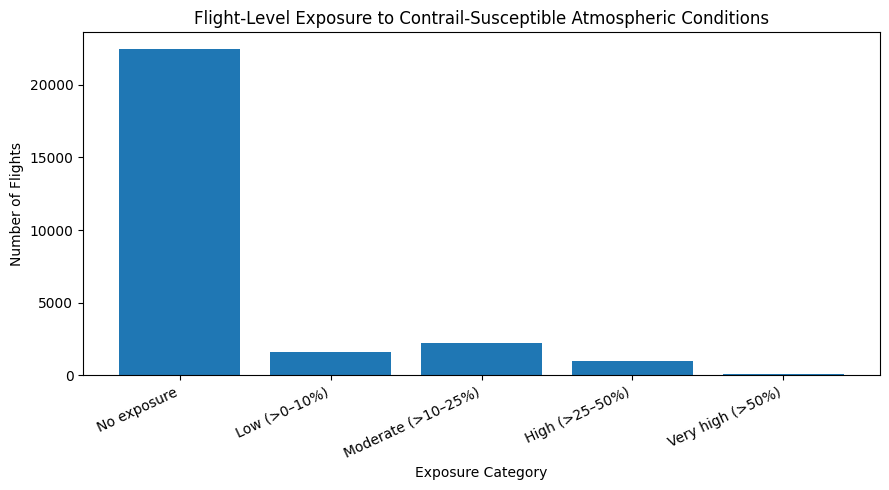


TOP 20 MOST EXPOSED FLIGHTS


,flight_id,Total_Waypoints,Susceptible_Waypoints,Susceptible_Waypoint_Percent,Maximum_Susceptible_Levels,Maximum_RHi_pct,Minimum_Temperature_C
3,7,2,2,100.000,4,103.867,-66.677002
62,87,2,2,100.000,1,108.307,-61.816002
1649,1906,5,4,80.000,1,112.381,-64.170998
1661,1919,5,4,80.000,1,112.392,-64.556000
1695,1959,5,4,80.000,1,110.255,-63.798000
1716,1984,5,4,80.000,1,115.663,-64.176003
1721,1989,5,4,80.000,1,114.902,-64.101997
1748,2021,5,4,80.000,1,117.854,-64.795998
1794,2071,5,4,80.000,1,110.650,-63.862000
1802,2079,5,4,80.000,1,110.650,-63.768002


SECTION COMPLETE


In [67]:
# FLIGHT-LEVEL CONTRAIL-SUSCEPTIBILITY EXPOSURE




print("FLIGHT-LEVEL CONTRAIL-SUSCEPTIBILITY EXPOSURE")


# ------------------------------------------------------------
# 1. COLLAPSE SIX PRESSURE LEVELS TO ONE WAYPOINT
#
# A waypoint is considered atmospherically exposed if
# ANY of the six ERA5 pressure levels is susceptible.
# ------------------------------------------------------------

waypoint_exposure = (
    df.groupby(
        [
            "flight_id",
            "waypoint_number"
        ]
    )
    .agg(
        waypoint_fraction=(
            "waypoint_fraction",
            "first"
        ),

        timestamp_utc=(
            "timestamp_utc",
            "first"
        ),

        waypoint_latitude=(
            "waypoint_latitude",
            "first"
        ),

        waypoint_longitude=(
            "waypoint_longitude",
            "first"
        ),

        susceptible_levels=(
            "contrail_susceptible",
            "sum"
        ),

        waypoint_susceptible=(
            "contrail_susceptible",
            "max"
        ),

        maximum_RHi_pct=(
            "RHi_pct",
            "max"
        ),

        minimum_temperature_C=(
            "temperature_C",
            "min"
        )
    )
    .reset_index()
)

print(
    f"\nUnique waypoint records : "
    f"{len(waypoint_exposure):,}"
)

print(
    f"Unique flights          : "
    f"{waypoint_exposure['flight_id'].nunique():,}"
)

# ------------------------------------------------------------
# 2. WAYPOINT-LEVEL EXPOSURE
# ------------------------------------------------------------

print("\nWAYPOINT EXPOSURE")

waypoint_summary = (
    waypoint_exposure[
        "waypoint_susceptible"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Waypoint_Susceptible")
    .reset_index(name="Count")
)

waypoint_summary["Percent"] = (
    waypoint_summary["Count"]
    / len(waypoint_exposure)
    * 100
)

display(
    waypoint_summary.round(3)
)

# ------------------------------------------------------------
# 3. NUMBER OF SUSCEPTIBLE PRESSURE LEVELS
# ------------------------------------------------------------

print("\nSUSCEPTIBLE PRESSURE LEVELS PER WAYPOINT")

level_exposure = (
    waypoint_exposure[
        "susceptible_levels"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Susceptible_Levels")
    .reset_index(name="Waypoints")
)

level_exposure["Percent"] = (
    level_exposure["Waypoints"]
    / len(waypoint_exposure)
    * 100
)

display(
    level_exposure.round(3)
)

# ------------------------------------------------------------
# 4. AGGREGATE TO FLIGHT LEVEL
# ------------------------------------------------------------

flight_exposure = (
    waypoint_exposure
    .groupby("flight_id")
    .agg(
        Total_Waypoints=(
            "waypoint_number",
            "size"
        ),

        Susceptible_Waypoints=(
            "waypoint_susceptible",
            "sum"
        ),

        Maximum_Susceptible_Levels=(
            "susceptible_levels",
            "max"
        ),

        Mean_Max_RHi_pct=(
            "maximum_RHi_pct",
            "mean"
        ),

        Maximum_RHi_pct=(
            "maximum_RHi_pct",
            "max"
        ),

        Minimum_Temperature_C=(
            "minimum_temperature_C",
            "min"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 5. EXPOSURE PERCENTAGE
# ------------------------------------------------------------

flight_exposure[
    "Susceptible_Waypoint_Percent"
] = (
    flight_exposure[
        "Susceptible_Waypoints"
    ]
    / flight_exposure[
        "Total_Waypoints"
    ]
    * 100
)

flight_exposure[
    "Flight_Exposed"
] = (
    flight_exposure[
        "Susceptible_Waypoints"
    ] > 0
).astype(int)

# ------------------------------------------------------------
# 6. FLIGHT-LEVEL SUMMARY
# ------------------------------------------------------------

print("\nFLIGHT-LEVEL EXPOSURE SUMMARY")

print(
    f"Total flights analysed : "
    f"{len(flight_exposure):,}"
)

exposed_flights = (
    flight_exposure[
        "Flight_Exposed"
    ].sum()
)

print(
    f"Flights with >=1 susceptible waypoint : "
    f"{exposed_flights:,}"
)

print(
    f"Flight exposure rate                  : "
    f"{exposed_flights / len(flight_exposure) * 100:.2f}%"
)

print("\nEXPOSURE DISTRIBUTION")

display(
    flight_exposure[
        [
            "Susceptible_Waypoints",
            "Susceptible_Waypoint_Percent",
            "Maximum_RHi_pct",
            "Minimum_Temperature_C"
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
    .round(3)
)

# ------------------------------------------------------------
# 7. EXPOSURE CATEGORIES
# ------------------------------------------------------------

flight_exposure["Exposure_Category"] = pd.cut(
    flight_exposure[
        "Susceptible_Waypoint_Percent"
    ],
    bins=[
        -0.001,
        0,
        10,
        25,
        50,
        100
    ],
    labels=[
        "No exposure",
        "Low (>0–10%)",
        "Moderate (>10–25%)",
        "High (>25–50%)",
        "Very high (>50%)"
    ]
)

print("\nFLIGHT EXPOSURE CATEGORIES")

exposure_categories = (
    flight_exposure[
        "Exposure_Category"
    ]
    .value_counts(
        sort=False
    )
    .rename_axis(
        "Exposure_Category"
    )
    .reset_index(
        name="Flights"
    )
)

exposure_categories[
    "Percent"
] = (
    exposure_categories["Flights"]
    / len(flight_exposure)
    * 100
)

display(
    exposure_categories.round(3)
)

# ------------------------------------------------------------
# 8. GRAPH - FLIGHT EXPOSURE CATEGORIES
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    exposure_categories[
        "Exposure_Category"
    ].astype(str),
    exposure_categories[
        "Flights"
    ]
)

plt.title(
    "Flight-Level Exposure to Contrail-Susceptible Atmospheric Conditions"
)

plt.xlabel(
    "Exposure Category"
)

plt.ylabel(
    "Number of Flights"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. TOP 20 MOST EXPOSED FLIGHTS
# ------------------------------------------------------------

print("\nTOP 20 MOST EXPOSED FLIGHTS")

top_exposed = (
    flight_exposure
    .sort_values(
        [
            "Susceptible_Waypoint_Percent",
            "Susceptible_Waypoints"
        ],
        ascending=False
    )
    .head(20)
)

display(
    top_exposed[
        [
            "flight_id",
            "Total_Waypoints",
            "Susceptible_Waypoints",
            "Susceptible_Waypoint_Percent",
            "Maximum_Susceptible_Levels",
            "Maximum_RHi_pct",
            "Minimum_Temperature_C"
        ]
    ].round(3)
)

print("SECTION COMPLETE")


## Aircraft-Type and Route Exposure Analysis


 AIRCRAFT TYPE AND ROUTE EXPOSURE ANALYSIS

Flight exposure rows : 27,437
Missing typecode     : 10,040

AIRCRAFT TYPE EXPOSURE - MINIMUM 30 FLIGHTS


,typecode,Flights,Exposed_Flights,Mean_Exposure_Percent,Median_Exposure_Percent,Flight_Exposure_Rate_pct
30,B763,68,28,11.108,0.0,41.176
31,B772,33,12,7.634,0.0,36.364
56,E35L,140,47,5.834,0.0,33.571
18,A388,1476,485,5.897,0.0,32.859
28,B752,45,14,5.235,0.0,31.111
26,B744,344,103,5.632,0.0,29.942
82,GLEX,34,10,4.951,0.0,29.412
48,CL65,103,30,5.934,0.0,29.126
25,B739,57,16,4.841,0.0,28.070
36,B789,484,130,4.682,0.0,26.860



ROUTE EXPOSURE - MINIMUM 20 FLIGHTS


,route,Flights,Exposed_Flights,Mean_Exposure_Percent,Median_Exposure_Percent,Flight_Exposure_Rate_pct
219,LSGG-OMDB,33,21,8.485,6.667,63.636
21,EDDF-OMAA,24,15,10.916,7.692,62.500
487,OMDB-LYBE,26,16,10.714,7.143,61.538
483,OMDB-LTBA,47,27,9.504,6.667,57.447
283,OMAA-EGLL,23,13,12.101,7.692,56.522
234,LTBA-OMDW,41,23,11.441,6.667,56.098
653,OMDW-LTBA,34,19,8.431,6.667,55.882
600,OMDW-ELLX,67,37,8.635,7.143,55.224
10,EBLG-OMDB,20,11,9.231,7.692,55.000
520,OMDB-UAAA,64,35,13.369,9.091,54.688



UAE FLIGHT-DIRECTION EXPOSURE


,uae_flight_direction,Flights,Exposed_Flights,Mean_Exposure_Percent,Flight_Exposure_Rate_pct
0,UAE_ARRIVAL,14228,2523,3.324,17.733
1,UAE_DEPARTURE,13209,2435,3.470,18.434


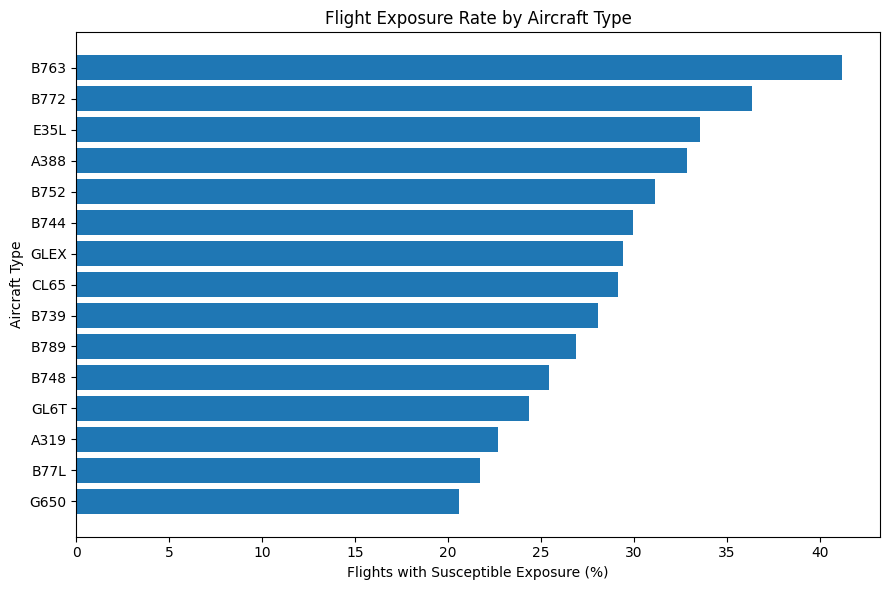

SECTION COMPLETE


In [68]:
# AIRCRAFT TYPE AND ROUTE EXPOSURE ANALYSIS



print(" AIRCRAFT TYPE AND ROUTE EXPOSURE ANALYSIS")


# ------------------------------------------------------------
# 1. FLIGHT METADATA
# ------------------------------------------------------------

flight_metadata = (
    reconstruction_flights[
        [
            "flight_id",
            "callsign",
            "registration",
            "typecode",
            "origin",
            "destination",
            "uae_flight_direction",
            "route_distance_km",
            "flight_duration_hr"
        ]
    ]
    .drop_duplicates(
        subset="flight_id"
    )
)

# ------------------------------------------------------------
# 2. MERGE WITH FLIGHT-LEVEL EXPOSURE
# ------------------------------------------------------------

flight_exposure_full = (
    flight_exposure
    .merge(
        flight_metadata,
        on="flight_id",
        how="left",
        validate="one_to_one"
    )
)

print(
    f"\nFlight exposure rows : "
    f"{len(flight_exposure_full):,}"
)

print(
    f"Missing typecode     : "
    f"{flight_exposure_full['typecode'].isna().sum():,}"
)

# ------------------------------------------------------------
# 3. AIRCRAFT-TYPE EXPOSURE
#
# Use only aircraft types with >= 30 flights
# ------------------------------------------------------------

aircraft_exposure = (
    flight_exposure_full
    .groupby("typecode")
    .agg(
        Flights=(
            "flight_id",
            "nunique"
        ),

        Exposed_Flights=(
            "Flight_Exposed",
            "sum"
        ),

        Mean_Exposure_Percent=(
            "Susceptible_Waypoint_Percent",
            "mean"
        ),

        Median_Exposure_Percent=(
            "Susceptible_Waypoint_Percent",
            "median"
        )
    )
    .reset_index()
)

aircraft_exposure[
    "Flight_Exposure_Rate_pct"
] = (
    aircraft_exposure[
        "Exposed_Flights"
    ]
    / aircraft_exposure[
        "Flights"
    ]
    * 100
)

aircraft_exposure_filtered = (
    aircraft_exposure[
        aircraft_exposure["Flights"] >= 30
    ]
    .sort_values(
        "Flight_Exposure_Rate_pct",
        ascending=False
    )
)

print("\nAIRCRAFT TYPE EXPOSURE - MINIMUM 30 FLIGHTS")

display(
    aircraft_exposure_filtered
    .head(20)
    .round(3)
)

# ------------------------------------------------------------
# 4. ROUTE VARIABLE
# ------------------------------------------------------------

flight_exposure_full["route"] = (
    flight_exposure_full["origin"]
    .fillna("UNKNOWN")
    + "-"
    + flight_exposure_full["destination"]
    .fillna("UNKNOWN")
)

# ------------------------------------------------------------
# 5. ROUTE EXPOSURE
#
# Minimum 20 flights per route
# ------------------------------------------------------------

route_exposure = (
    flight_exposure_full
    .groupby("route")
    .agg(
        Flights=(
            "flight_id",
            "nunique"
        ),

        Exposed_Flights=(
            "Flight_Exposed",
            "sum"
        ),

        Mean_Exposure_Percent=(
            "Susceptible_Waypoint_Percent",
            "mean"
        ),

        Median_Exposure_Percent=(
            "Susceptible_Waypoint_Percent",
            "median"
        )
    )
    .reset_index()
)

route_exposure[
    "Flight_Exposure_Rate_pct"
] = (
    route_exposure[
        "Exposed_Flights"
    ]
    / route_exposure[
        "Flights"
    ]
    * 100
)

route_exposure_filtered = (
    route_exposure[
        route_exposure["Flights"] >= 20
    ]
    .sort_values(
        "Flight_Exposure_Rate_pct",
        ascending=False
    )
)

print("\nROUTE EXPOSURE - MINIMUM 20 FLIGHTS")

display(
    route_exposure_filtered
    .head(20)
    .round(3)
)

# ------------------------------------------------------------
# 6. FLIGHT DIRECTION
# ------------------------------------------------------------

direction_exposure = (
    flight_exposure_full
    .groupby(
        "uae_flight_direction"
    )
    .agg(
        Flights=(
            "flight_id",
            "nunique"
        ),

        Exposed_Flights=(
            "Flight_Exposed",
            "sum"
        ),

        Mean_Exposure_Percent=(
            "Susceptible_Waypoint_Percent",
            "mean"
        )
    )
    .reset_index()
)

direction_exposure[
    "Flight_Exposure_Rate_pct"
] = (
    direction_exposure[
        "Exposed_Flights"
    ]
    / direction_exposure[
        "Flights"
    ]
    * 100
)

print("\nUAE FLIGHT-DIRECTION EXPOSURE")

display(
    direction_exposure.round(3)
)

# ------------------------------------------------------------
# 7. AIRCRAFT-TYPE GRAPH
# ------------------------------------------------------------

plot_aircraft = (
    aircraft_exposure_filtered
    .head(15)
    .sort_values(
        "Flight_Exposure_Rate_pct"
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_aircraft["typecode"],
    plot_aircraft[
        "Flight_Exposure_Rate_pct"
    ]
)

plt.title(
    "Flight Exposure Rate by Aircraft Type"
)

plt.xlabel(
    "Flights with Susceptible Exposure (%)"
)

plt.ylabel(
    "Aircraft Type"
)

plt.tight_layout()
plt.show()

print("SECTION COMPLETE")


##  Temporal and Spatial Hotspot Analysis


 TEMPORAL AND SPATIAL HOTSPOT ANALYSIS

DAILY SUSCEPTIBILITY


,date,Total_Records,Susceptible_Records,Susceptible_Percent
0,2022-01-01,38592,1073,2.780
1,2022-01-02,12684,430,3.390
2,2022-01-03,41976,640,1.525
3,2022-01-04,54180,1773,3.272
4,2022-01-05,51822,170,0.328
5,2022-01-06,52722,112,0.212
6,2022-01-07,54432,493,0.906
7,2022-01-08,59988,421,0.702
8,2022-01-09,56064,346,0.617
9,2022-01-10,52392,927,1.769


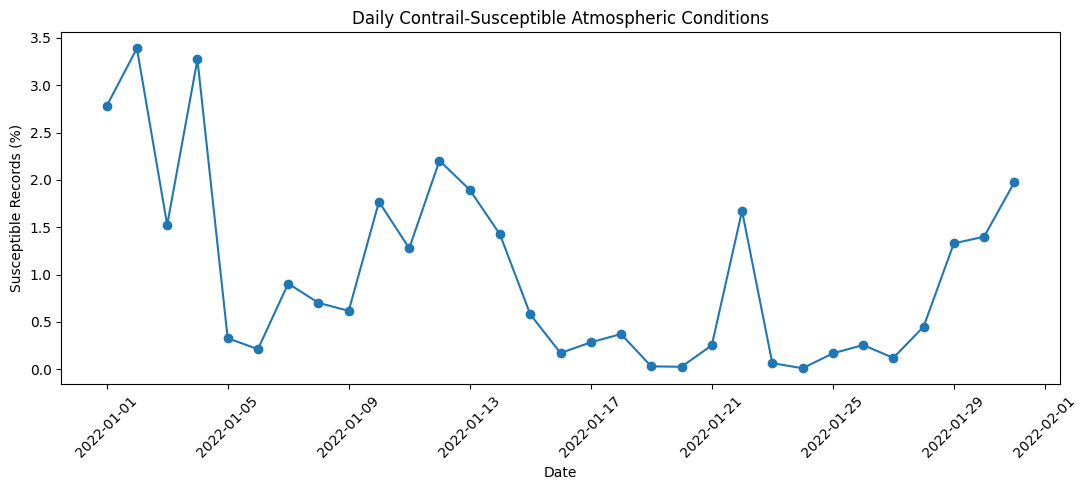


SUSCEPTIBILITY BY UTC HOUR


,hour_utc,Total_Records,Susceptible_Records,Susceptible_Percent
0,0,64854,628,0.968
1,1,64764,625,0.965
2,2,51858,489,0.943
3,3,39810,283,0.711
4,4,46218,195,0.422
5,5,56814,315,0.554
6,6,72360,625,0.864
7,7,76920,876,1.139
8,8,64290,752,1.170
9,9,55152,680,1.233


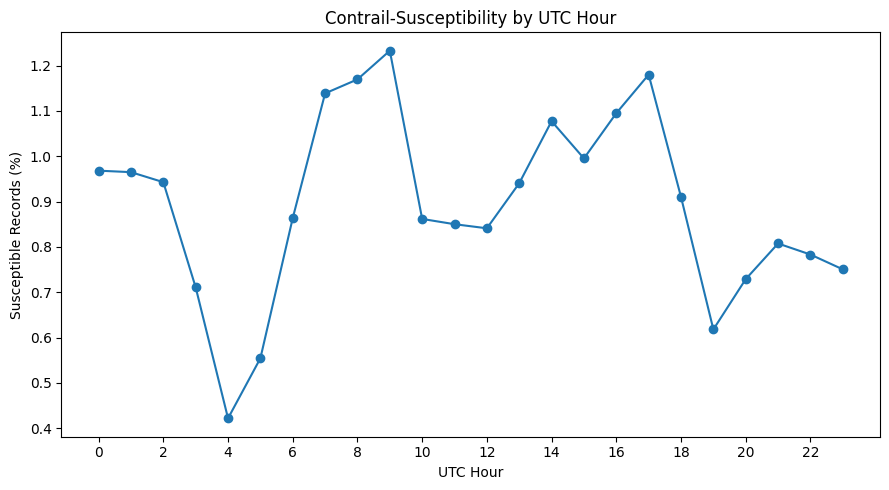


TOP 25 SPATIAL HOTSPOTS


,era5_latitude,era5_longitude,Total_Records,Susceptible_Records,Susceptible_Percent
4837,37.75,68.75,672,77,11.458
5089,39.00,34.50,162,17,10.494
5094,39.00,36.00,168,16,9.524
4538,36.50,67.25,672,62,9.226
5143,39.25,32.75,486,44,9.053
4537,36.50,67.00,144,13,9.028
5079,39.00,31.00,156,14,8.974
4836,37.75,68.50,138,12,8.696
5150,39.25,34.50,174,15,8.621
5207,39.50,36.75,582,49,8.419


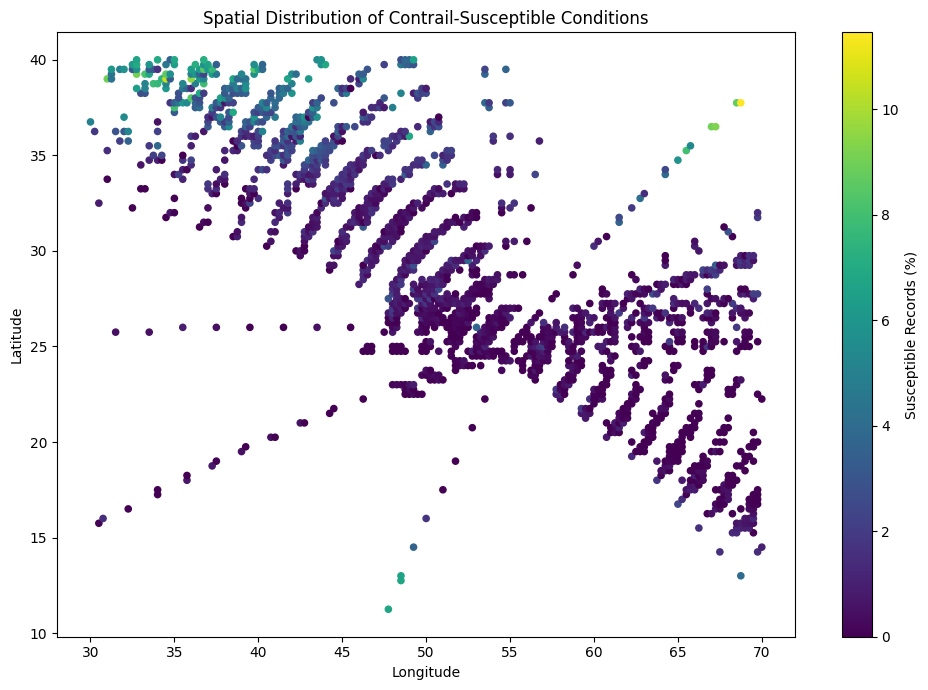


DAILY SUSCEPTIBILITY BY PRESSURE LEVEL


,date,pressure_level,Susceptible_Percent
0,2022-01-01,150.0,0.000
1,2022-01-01,200.0,0.295
2,2022-01-01,225.0,0.451
3,2022-01-01,250.0,2.270
4,2022-01-01,300.0,7.463
5,2022-01-01,350.0,6.203
6,2022-01-02,150.0,4.305
7,2022-01-02,200.0,2.554
8,2022-01-02,225.0,0.426
9,2022-01-02,250.0,1.135


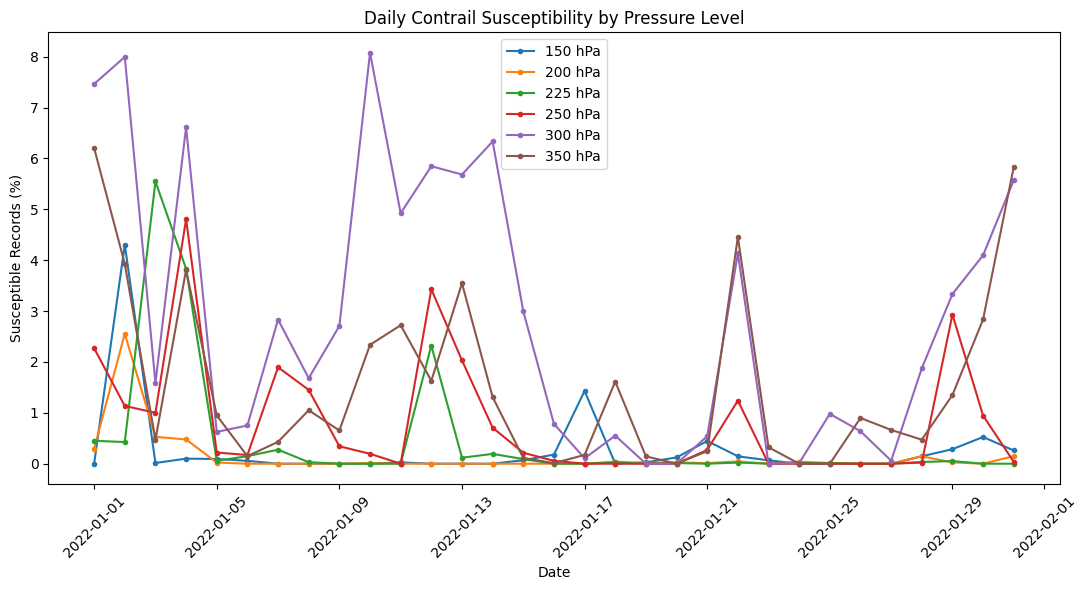

COMPLETE


In [69]:
# TEMPORAL AND SPATIAL HOTSPOT ANALYSIS




print(" TEMPORAL AND SPATIAL HOTSPOT ANALYSIS")


# ------------------------------------------------------------
# 1. CREATE TIME VARIABLES
# ------------------------------------------------------------

df["date"] = df["timestamp_utc"].dt.date
df["hour_utc"] = df["timestamp_utc"].dt.hour

# ------------------------------------------------------------
# 2. DAILY SUSCEPTIBILITY
# ------------------------------------------------------------

daily_susceptibility = (
    df.groupby("date")
    .agg(
        Total_Records=(
            "contrail_susceptible",
            "size"
        ),

        Susceptible_Records=(
            "contrail_susceptible",
            "sum"
        )
    )
    .reset_index()
)

daily_susceptibility[
    "Susceptible_Percent"
] = (
    daily_susceptibility[
        "Susceptible_Records"
    ]
    / daily_susceptibility[
        "Total_Records"
    ]
    * 100
)

print("\nDAILY SUSCEPTIBILITY")

display(
    daily_susceptibility.round(3)
)

# ------------------------------------------------------------
# 3. DAILY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    pd.to_datetime(
        daily_susceptibility["date"]
    ),
    daily_susceptibility[
        "Susceptible_Percent"
    ],
    marker="o"
)

plt.title(
    "Daily Contrail-Susceptible Atmospheric Conditions"
)

plt.xlabel("Date")
plt.ylabel("Susceptible Records (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. SUSCEPTIBILITY BY UTC HOUR
# ------------------------------------------------------------

hourly_susceptibility = (
    df.groupby("hour_utc")
    .agg(
        Total_Records=(
            "contrail_susceptible",
            "size"
        ),

        Susceptible_Records=(
            "contrail_susceptible",
            "sum"
        )
    )
    .reset_index()
)

hourly_susceptibility[
    "Susceptible_Percent"
] = (
    hourly_susceptibility[
        "Susceptible_Records"
    ]
    / hourly_susceptibility[
        "Total_Records"
    ]
    * 100
)

print("\nSUSCEPTIBILITY BY UTC HOUR")

display(
    hourly_susceptibility.round(3)
)

# ------------------------------------------------------------
# 5. HOURLY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    hourly_susceptibility["hour_utc"],
    hourly_susceptibility[
        "Susceptible_Percent"
    ],
    marker="o"
)

plt.title(
    "Contrail-Susceptibility by UTC Hour"
)

plt.xlabel("UTC Hour")
plt.ylabel("Susceptible Records (%)")

plt.xticks(
    range(0, 24, 2)
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. SPATIAL GRID HOTSPOTS
#
# Use ERA5 0.25-degree grid coordinates.
# ------------------------------------------------------------

spatial_hotspots = (
    df.groupby(
        [
            "era5_latitude",
            "era5_longitude"
        ]
    )
    .agg(
        Total_Records=(
            "contrail_susceptible",
            "size"
        ),

        Susceptible_Records=(
            "contrail_susceptible",
            "sum"
        )
    )
    .reset_index()
)

spatial_hotspots[
    "Susceptible_Percent"
] = (
    spatial_hotspots[
        "Susceptible_Records"
    ]
    / spatial_hotspots[
        "Total_Records"
    ]
    * 100
)

# Avoid unstable rates from very sparse cells
spatial_hotspots_filtered = (
    spatial_hotspots[
        spatial_hotspots[
            "Total_Records"
        ] >= 100
    ]
    .copy()
)

# ------------------------------------------------------------
# 7. TOP SPATIAL HOTSPOTS
# ------------------------------------------------------------

top_hotspots = (
    spatial_hotspots_filtered
    .sort_values(
        [
            "Susceptible_Percent",
            "Susceptible_Records"
        ],
        ascending=False
    )
    .head(25)
)

print("\nTOP 25 SPATIAL HOTSPOTS")

display(
    top_hotspots.round(3)
)

# ------------------------------------------------------------
# 8. SPATIAL SCATTER
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    spatial_hotspots_filtered[
        "era5_longitude"
    ],
    spatial_hotspots_filtered[
        "era5_latitude"
    ],
    c=spatial_hotspots_filtered[
        "Susceptible_Percent"
    ],
    s=20
)

plt.colorbar(
    scatter,
    label="Susceptible Records (%)"
)

plt.title(
    "Spatial Distribution of Contrail-Susceptible Conditions"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. PRESSURE LEVEL × DAY
# ------------------------------------------------------------

daily_level = (
    df.groupby(
        [
            "date",
            "pressure_level"
        ]
    )["contrail_susceptible"]
    .mean()
    .mul(100)
    .reset_index(
        name="Susceptible_Percent"
    )
)

print("\nDAILY SUSCEPTIBILITY BY PRESSURE LEVEL")

display(
    daily_level.head(20).round(3)
)

# ------------------------------------------------------------
# 10. PRESSURE LEVEL × DAY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

for level in sorted(
    daily_level[
        "pressure_level"
    ].unique()
):

    subset = daily_level[
        daily_level[
            "pressure_level"
        ] == level
    ]

    plt.plot(
        pd.to_datetime(
            subset["date"]
        ),
        subset[
            "Susceptible_Percent"
        ],
        marker="o",
        markersize=3,
        label=f"{int(level)} hPa"
    )

plt.title(
    "Daily Contrail Susceptibility by Pressure Level"
)

plt.xlabel("Date")
plt.ylabel("Susceptible Records (%)")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

print("COMPLETE")


## Leakage-Controlled Modelling Dataset


In [70]:
# LEAKAGE-CONTROLLED MODELLING DATASET




print("LEAKAGE-CONTROLLED MODELLING DATASET")


# ------------------------------------------------------------
# 1. TARGET
# ------------------------------------------------------------

TARGET = "contrail_susceptible"

# ------------------------------------------------------------
# 2. LEAKAGE-CONTROLLED FEATURES
#
# IMPORTANT:
# Exclude variables directly used to calculate the target:
#
# temperature_C
# specific_humidity_kgkg
# RHi_pct
# vapour_pressure_Pa
# saturation_vapour_pressure_ice_Pa
# relative_humidity_pct
#
# relative_humidity_pct is also excluded from the PRIMARY
# model because it is closely related to atmospheric moisture
# used in defining susceptibility.
# ------------------------------------------------------------

FEATURES = [
    "pressure_level",
    "geopotential_height_m",

    "cloud_ice_water_kgkg",
    "cloud_cover_fraction",

    "wind_u_ms",
    "wind_v_ms",
    "wind_speed_ms",

    "waypoint_latitude",
    "waypoint_longitude",

    "time_match_error_min"
]

# ------------------------------------------------------------
# 3. CREATE MODELLING DATASET
# ------------------------------------------------------------

model_df = (
    df[
        ["flight_id", TARGET] + FEATURES
    ]
    .dropna()
    .copy()
)

print(f"\nModelling rows       : {len(model_df):,}")
print(f"Unique flights       : {model_df['flight_id'].nunique():,}")
print(f"Predictor variables  : {len(FEATURES)}")

# ------------------------------------------------------------
# 4. TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\nTARGET DISTRIBUTION")

target_distribution = (
    model_df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Count")
)

target_distribution["Percent"] = (
    target_distribution["Count"]
    / len(model_df)
    * 100
)

display(target_distribution.round(3))

# ------------------------------------------------------------
# 5. GROUP-BASED TRAIN / TEST SPLIT
#
# Entire flights remain in either train or test.
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_df[FEATURES],
        model_df[TARGET],
        groups=model_df["flight_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

# ------------------------------------------------------------
# 6. CREATE X / y
# ------------------------------------------------------------

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

# ------------------------------------------------------------
# 7. SPLIT VALIDATION
# ------------------------------------------------------------

print("\n" + "-" * 105)
print("TRAIN / TEST SPLIT")
print("-" * 105)

print(f"Training rows    : {len(train_df):,}")
print(f"Testing rows     : {len(test_df):,}")

print(
    f"Training flights : "
    f"{train_df['flight_id'].nunique():,}"
)

print(
    f"Testing flights  : "
    f"{test_df['flight_id'].nunique():,}"
)

# Check flight leakage
train_flights = set(train_df["flight_id"])
test_flights = set(test_df["flight_id"])

overlapping_flights = (
    train_flights.intersection(test_flights)
)

print(
    f"Overlapping flights : "
    f"{len(overlapping_flights):,}"
)

# ------------------------------------------------------------
# 8. CLASS DISTRIBUTION IN TRAIN AND TEST
# ------------------------------------------------------------

def class_summary(y, name):

    summary = (
        y.value_counts()
        .sort_index()
        .rename_axis("Class")
        .reset_index(name="Count")
    )

    summary["Percent"] = (
        summary["Count"]
        / len(y)
        * 100
    )

    summary.insert(
        0,
        "Dataset",
        name
    )

    return summary


split_distribution = pd.concat(
    [
        class_summary(
            y_train,
            "TRAIN"
        ),

        class_summary(
            y_test,
            "TEST"
        )
    ],
    ignore_index=True
)

print("\nCLASS DISTRIBUTION BY SPLIT")

display(
    split_distribution.round(3)
)

# ------------------------------------------------------------
# 9. POSITIVE / NEGATIVE RATIO
# ------------------------------------------------------------

train_positive = int(y_train.sum())
train_negative = int(
    len(y_train) - train_positive
)

imbalance_ratio = (
    train_negative
    / train_positive
)

print(
    f"\nTraining positive cases : "
    f"{train_positive:,}"
)

print(
    f"Training negative cases : "
    f"{train_negative:,}"
)

print(
    f"Negative : Positive ratio : "
    f"{imbalance_ratio:.2f} : 1"
)

print("SECTION  COMPLETE")


LEAKAGE-CONTROLLED MODELLING DATASET

Modelling rows       : 1,437,384
Unique flights       : 27,437
Predictor variables  : 10

TARGET DISTRIBUTION


,Class,Count,Percent
0,0,1424255,99.087
1,1,13129,0.913



---------------------------------------------------------------------------------------------------------
TRAIN / TEST SPLIT
---------------------------------------------------------------------------------------------------------
Training rows    : 1,149,198
Testing rows     : 288,186
Training flights : 21,949
Testing flights  : 5,488
Overlapping flights : 0

CLASS DISTRIBUTION BY SPLIT


,Dataset,Class,Count,Percent
0,TRAIN,0,1138777,99.093
1,TRAIN,1,10421,0.907
2,TEST,0,285478,99.060
3,TEST,1,2708,0.940



Training positive cases : 10,421
Training negative cases : 1,138,777
Negative : Positive ratio : 109.28 : 1
SECTION  COMPLETE


## Exploratory Grouped Baseline Comparison

This grouped split is diagnostic. Final model selection and reporting use the temporal validation framework below.


In [71]:
# EXPLORATORY GROUPED BASELINE MODEL COMPARISON


print("EXPLORATORY GROUPED BASELINE MODEL COMPARISON")


# ------------------------------------------------------------
# 1. CREATE STRATIFIED TRAINING SAMPLE
# ------------------------------------------------------------

MAX_TRAIN_ROWS = 300_000

train_positive = train_df[
    train_df[TARGET] == 1
].copy()

train_negative = train_df[
    train_df[TARGET] == 0
].copy()

# Keep ALL positive examples
n_positive = len(train_positive)

# Fill remaining sample with negatives
n_negative_needed = min(
    MAX_TRAIN_ROWS - n_positive,
    len(train_negative)
)

negative_sample = train_negative.sample(
    n=n_negative_needed,
    random_state=42
)

fast_train_df = pd.concat(
    [
        train_positive,
        negative_sample
    ],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train_fast = fast_train_df[FEATURES]
y_train_fast = fast_train_df[TARGET]

print(f"\nOriginal training rows : {len(train_df):,}")
print(f"Fast training rows     : {len(fast_train_df):,}")
print(f"Positive training rows : {int(y_train_fast.sum()):,}")
print(f"Negative training rows : {int((y_train_fast == 0).sum()):,}")

# ------------------------------------------------------------
# 2. IMBALANCE RATIO FOR FAST TRAINING SET
# ------------------------------------------------------------

fast_scale_pos_weight = (
    (y_train_fast == 0).sum()
    / (y_train_fast == 1).sum()
)

print(
    f"Fast scale_pos_weight  : "
    f"{fast_scale_pos_weight:.2f}"
)

# ------------------------------------------------------------
# 3. MODELS
# ------------------------------------------------------------

models_fast = {

    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=500,
                    solver="lbfgs",
                    random_state=42
                )
            )
        ]),

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=150,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.08,
            max_depth=5,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=fast_scale_pos_weight,
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )
}

# ------------------------------------------------------------
# 4. TRAIN + EVALUATE ON FULL TEST SET
# ------------------------------------------------------------

fast_results = []
fast_fitted_models = {}

for model_name, model in models_fast.items():

    print("\n" + "-" * 105)
    print(model_name)
    print("-" * 105)

    model.fit(
        X_train_fast,
        y_train_fast
    )

    fast_fitted_models[model_name] = model

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    y_pred = (
        y_prob >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    fast_results.append({

        "Model": model_name,

        "ROC_AUC":
            roc_auc_score(
                y_test,
                y_prob
            ),

        "PR_AUC":
            average_precision_score(
                y_test,
                y_prob
            ),

        "Precision":
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_test,
                y_pred
            ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print(f"ROC-AUC           : {fast_results[-1]['ROC_AUC']:.4f}")
    print(f"PR-AUC            : {fast_results[-1]['PR_AUC']:.4f}")
    print(f"Precision         : {fast_results[-1]['Precision']:.4f}")
    print(f"Recall            : {fast_results[-1]['Recall']:.4f}")
    print(f"F1                : {fast_results[-1]['F1']:.4f}")
    print(f"Balanced Accuracy : {fast_results[-1]['Balanced_Accuracy']:.4f}")

    print(
        f"Confusion Matrix  : "
        f"TN={tn:,}, FP={fp:,}, "
        f"FN={fn:,}, TP={tp:,}"
    )

# ------------------------------------------------------------
# 5. COMPARISON TABLE
# ------------------------------------------------------------

fast_results_df = (
    pd.DataFrame(fast_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 105)
print("FAST MODEL COMPARISON")
print("=" * 105)

display(
    fast_results_df.round(4)
)

best_model_name = (
    fast_results_df.iloc[0]["Model"]
)

best_model = (
    fast_fitted_models[
        best_model_name
    ]
)

print(
    f"\nBest model by PR-AUC : "
    f"{best_model_name}"
)


EXPLORATORY GROUPED BASELINE MODEL COMPARISON

Original training rows : 1,149,198
Fast training rows     : 300,000
Positive training rows : 10,421
Negative training rows : 289,579
Fast scale_pos_weight  : 27.79

---------------------------------------------------------------------------------------------------------
Logistic Regression
---------------------------------------------------------------------------------------------------------
ROC-AUC           : 0.9688
PR-AUC            : 0.3061
Precision         : 0.2360
Recall            : 0.8733
F1                : 0.3716
Balanced Accuracy : 0.9233
Confusion Matrix  : TN=277,821, FP=7,657, FN=343, TP=2,365

---------------------------------------------------------------------------------------------------------
HistGradientBoosting
---------------------------------------------------------------------------------------------------------
ROC-AUC           : 0.9967
PR-AUC            : 0.7198
Precision         : 0.3255
Recall            : 

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Balanced_Accuracy,TN,FP,FN,TP
0,HistGradientBoosting,0.9967,0.7198,0.3255,0.9915,0.4901,0.9860,279914,5564,23,2685
1,XGBoost,0.9963,0.6965,0.3163,0.9893,0.4794,0.9845,279688,5790,29,2679
2,Logistic Regression,0.9688,0.3061,0.2360,0.8733,0.3716,0.9233,277821,7657,343,2365



Best model by PR-AUC : HistGradientBoosting


## Environmental Leakage Audit


In [72]:
# ERA5 ENVIRONMENTAL LEAKAGE AUDIT


print(" ERA5 ENVIRONMENTAL LEAKAGE AUDIT")


# ------------------------------------------------------------
# Recover ERA5 key IDs using original dataframe indices
# ------------------------------------------------------------

train_era5_keys = set(
    df.loc[
        train_df.index,
        "era5_key_id"
    ].unique()
)

test_era5_keys = set(
    df.loc[
        test_df.index,
        "era5_key_id"
    ].unique()
)

overlap_keys = (
    train_era5_keys
    .intersection(test_era5_keys)
)

print(f"\nTraining ERA5 keys : {len(train_era5_keys):,}")
print(f"Testing ERA5 keys  : {len(test_era5_keys):,}")
print(f"Overlapping keys   : {len(overlap_keys):,}")

# ------------------------------------------------------------
# Percentage of test rows whose ERA5 cell appeared in training
# ------------------------------------------------------------

test_key_series = df.loc[
    test_df.index,
    "era5_key_id"
]

test_seen_environment = (
    test_key_series.isin(
        train_era5_keys
    )
)

print(
    f"\nTest rows with ERA5 environment "
    f"already seen in training : "
    f"{test_seen_environment.sum():,}"
)

print(
    f"Percent of test rows seen : "
    f"{test_seen_environment.mean() * 100:.2f}%"
)

# ------------------------------------------------------------
# Positive-class overlap
# ------------------------------------------------------------

test_positive_indices = (
    test_df.index[
        test_df[TARGET] == 1
    ]
)

positive_test_keys = df.loc[
    test_positive_indices,
    "era5_key_id"
]

positive_seen = (
    positive_test_keys.isin(
        train_era5_keys
    )
)

print(
    f"\nPositive test rows                : "
    f"{len(positive_test_keys):,}"
)

print(
    f"Positive test rows with ERA5 key "
    f"seen during training             : "
    f"{positive_seen.sum():,}"
)

print(
    f"Positive environmental overlap   : "
    f"{positive_seen.mean() * 100:.2f}%"
)


 ERA5 ENVIRONMENTAL LEAKAGE AUDIT

Training ERA5 keys : 106,860
Testing ERA5 keys  : 36,892
Overlapping keys   : 20,185

Test rows with ERA5 environment already seen in training : 181,512
Percent of test rows seen : 62.98%

Positive test rows                : 2,708
Positive test rows with ERA5 key seen during training             : 1,329
Positive environmental overlap   : 49.08%


## ERA5-Aligned Temporal Training, Validation, and Test Split


In [73]:
# ERA5-ALIGNED TRAINING, VALIDATION, AND TEST SPLIT


print("ERA5-ALIGNED TRAINING, VALIDATION, AND TEST SPLIT")


# Ensure consistent UTC-aware datetime columns
df = df.copy()

df["era5_time"] = pd.to_datetime(
    df["era5_time"],
    errors="coerce",
    utc=True
)

df["timestamp_utc"] = pd.to_datetime(
    df["timestamp_utc"],
    errors="coerce",
    utc=True
)

# Validate datetime conversion
missing_era5_time = int(
    df["era5_time"].isna().sum()
)

missing_timestamp = int(
    df["timestamp_utc"].isna().sum()
)

print("\nDATETIME VALIDATION")

print(
    f"Missing ERA5 times       : "
    f"{missing_era5_time:,}"
)

print(
    f"Missing waypoint times   : "
    f"{missing_timestamp:,}"
)

print(
    f"ERA5 time data type      : "
    f"{df['era5_time'].dtype}"
)

print(
    f"Waypoint time data type  : "
    f"{df['timestamp_utc'].dtype}"
)

if missing_era5_time > 0:
    raise ValueError(
        "Some ERA5 time values could not be converted to UTC datetime."
    )

if missing_timestamp > 0:
    raise ValueError(
        "Some waypoint timestamps could not be converted to UTC datetime."
    )

# Define temporal boundaries
VALIDATION_CUTOFF = pd.Timestamp(
    "2022-01-21 00:00:00",
    tz="UTC"
)

TEST_CUTOFF = pd.Timestamp(
    "2022-01-25 00:00:00",
    tz="UTC"
)

print("\nTEMPORAL SPLIT BOUNDARIES")

print(
    f"Validation starts : "
    f"{VALIDATION_CUTOFF}"
)

print(
    f"Final test starts : "
    f"{TEST_CUTOFF}"
)

# Determine complete ERA5 time range for each flight
flight_era5_bounds = (
    df.groupby("flight_id")["era5_time"]
    .agg(
        first_era5_time="min",
        last_era5_time="max"
    )
    .reset_index()
)

# Training flights
# Complete ERA5 history must end before 21 January
strict_train_flights = set(
    flight_era5_bounds.loc[
        flight_era5_bounds["last_era5_time"]
        < VALIDATION_CUTOFF,
        "flight_id"
    ]
)

# Validation flights
# Complete ERA5 history must fall between 21 and 25 January
strict_val_flights = set(
    flight_era5_bounds.loc[
        (
            flight_era5_bounds["first_era5_time"]
            >= VALIDATION_CUTOFF
        )
        &
        (
            flight_era5_bounds["last_era5_time"]
            < TEST_CUTOFF
        ),
        "flight_id"
    ]
)

# Final test flights
# Complete ERA5 history must begin on or after 25 January
strict_test_flights = set(
    flight_era5_bounds.loc[
        flight_era5_bounds["first_era5_time"]
        >= TEST_CUTOFF,
        "flight_id"
    ]
)

# Flights crossing split boundaries are excluded
assigned_flights = (
    strict_train_flights
    | strict_val_flights
    | strict_test_flights
)

boundary_flights = (
    set(flight_era5_bounds["flight_id"])
    - assigned_flights
)

required_columns = [
    "flight_id",
    "era5_key_id",
    "era5_time",
    "timestamp_utc",
    TARGET
] + FEATURES

# Create training dataset
strict_train_df = (
    df.loc[
        df["flight_id"].isin(
            strict_train_flights
        ),
        required_columns
    ]
    .dropna()
    .copy()
)

# Create validation dataset
strict_val_df = (
    df.loc[
        df["flight_id"].isin(
            strict_val_flights
        ),
        required_columns
    ]
    .dropna()
    .copy()
)

# Create untouched test dataset
strict_test_df = (
    df.loc[
        df["flight_id"].isin(
            strict_test_flights
        ),
        required_columns
    ]
    .dropna()
    .copy()
)

# Predictor and target datasets
X_train_strict = strict_train_df[
    FEATURES
].copy()

y_train_strict = strict_train_df[
    TARGET
].copy()

X_val_strict = strict_val_df[
    FEATURES
].copy()

y_val_strict = strict_val_df[
    TARGET
].copy()

X_test_strict = strict_test_df[
    FEATURES
].copy()

y_test_strict = strict_test_df[
    TARGET
].copy()

# Summarize each split
def split_summary(frame, name):

    return {
        "Split": name,
        "Rows": len(frame),
        "Flights": frame["flight_id"].nunique(),
        "Positive": int(frame[TARGET].sum()),
        "Positive_Percent": (
            frame[TARGET].mean() * 100
        ),
        "Start": frame["era5_time"].min(),
        "End": frame["era5_time"].max()
    }


split_summary_df = pd.DataFrame(
    [
        split_summary(
            strict_train_df,
            "TRAIN"
        ),
        split_summary(
            strict_val_df,
            "VALIDATION"
        ),
        split_summary(
            strict_test_df,
            "TEST"
        )
    ]
)

print("\nTEMPORAL SPLIT SUMMARY")

display(
    split_summary_df.round(3)
)

# Check flight overlap
flight_overlap = (
    (
        strict_train_flights
        & strict_val_flights
    )
    |
    (
        strict_train_flights
        & strict_test_flights
    )
    |
    (
        strict_val_flights
        & strict_test_flights
    )
)

# Check ERA5 environmental-key overlap
train_keys = set(
    strict_train_df["era5_key_id"]
)

val_keys = set(
    strict_val_df["era5_key_id"]
)

test_keys = set(
    strict_test_df["era5_key_id"]
)

era5_overlap = (
    (train_keys & val_keys)
    | (train_keys & test_keys)
    | (val_keys & test_keys)
)

print("\nLEAKAGE AND BOUNDARY CHECK")

print(
    f"Boundary-crossing flights : "
    f"{len(boundary_flights):,}"
)

print(
    f"Overlapping flights       : "
    f"{len(flight_overlap):,}"
)

print(
    f"Overlapping ERA5 keys     : "
    f"{len(era5_overlap):,}"
)

# Validate non-empty datasets
if strict_train_df.empty:
    raise ValueError(
        "The training dataset is empty."
    )

if strict_val_df.empty:
    raise ValueError(
        "The validation dataset is empty."
    )

if strict_test_df.empty:
    raise ValueError(
        "The test dataset is empty."
    )

# Validate leakage control
assert len(flight_overlap) == 0, (
    "Flight leakage detected."
)

assert len(era5_overlap) == 0, (
    "ERA5 environmental leakage detected."
)

# Ensure both classes exist in every split
assert y_train_strict.nunique() == 2, (
    "Training data does not contain both target classes."
)

assert y_val_strict.nunique() == 2, (
    "Validation data does not contain both target classes."
)

assert y_test_strict.nunique() == 2, (
    "Test data does not contain both target classes."
)

print("\nSECTION 10C COMPLETED SUCCESSFULLY")
print(
    "FINAL TEST PERIOD REMAINS UNTOUCHED "
    "UNTIL SECTION 10F"
)


ERA5-ALIGNED TRAINING, VALIDATION, AND TEST SPLIT

DATETIME VALIDATION
Missing ERA5 times       : 0
Missing waypoint times   : 0
ERA5 time data type      : datetime64[ns, UTC]
Waypoint time data type  : datetime64[ns, UTC]

TEMPORAL SPLIT BOUNDARIES
Validation starts : 2022-01-21 00:00:00+00:00
Final test starts : 2022-01-25 00:00:00+00:00

TEMPORAL SPLIT SUMMARY


,Split,Rows,Flights,Positive,Positive_Percent,Start,End
0,TRAIN,963762,18373,10548,1.094,2022-01-01 00:00:00+00:00,2022-01-20 20:00:00+00:00
1,VALIDATION,201996,3819,1067,0.528,2022-01-21 00:00:00+00:00,2022-01-24 20:00:00+00:00
2,TEST,265170,5139,1509,0.569,2022-01-25 00:00:00+00:00,2022-01-31 20:00:00+00:00



LEAKAGE AND BOUNDARY CHECK
Boundary-crossing flights : 106
Overlapping flights       : 0
Overlapping ERA5 keys     : 0

SECTION 10C COMPLETED SUCCESSFULLY
FINAL TEST PERIOD REMAINS UNTOUCHED UNTIL SECTION 10F


## Temporal Validation Model Comparison


In [74]:
# TEMPORAL VALIDATION MODEL COMPARISON



print("TEMPORAL VALIDATION MODEL COMPARISON")


# ------------------------------------------------------------
# 1. USE A FAST DEVELOPMENT SAMPLE FROM STRICT TRAIN SET
# ------------------------------------------------------------

MAX_TRAIN_ROWS = 300_000

strict_pos = strict_train_df[
    strict_train_df[TARGET] == 1
].copy()

strict_neg = strict_train_df[
    strict_train_df[TARGET] == 0
].copy()

n_pos = len(strict_pos)

n_neg_needed = min(
    MAX_TRAIN_ROWS - n_pos,
    len(strict_neg)
)

strict_neg_sample = strict_neg.sample(
    n=n_neg_needed,
    random_state=42
)

strict_fast_train = pd.concat(
    [
        strict_pos,
        strict_neg_sample
    ],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train_fast_strict = strict_fast_train[FEATURES]
y_train_fast_strict = strict_fast_train[TARGET]

strict_scale_pos_weight = (
    (y_train_fast_strict == 0).sum()
    /
    (y_train_fast_strict == 1).sum()
)

print(f"\nStrict training rows sampled : {len(strict_fast_train):,}")
print(f"Positive rows retained       : {int(y_train_fast_strict.sum()):,}")
print(f"scale_pos_weight             : {strict_scale_pos_weight:.2f}")

# ------------------------------------------------------------
# 2. MODELS
# ------------------------------------------------------------

strict_models = {

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=150,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.08,
            max_depth=5,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=strict_scale_pos_weight,
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )
}

# ------------------------------------------------------------
# 3. TRAIN AND EVALUATE
# ------------------------------------------------------------

strict_results = []
strict_fitted_models = {}

for model_name, model in strict_models.items():

    print("\n" + "-" * 105)
    print(model_name)
    print("-" * 105)

    model.fit(
        X_train_fast_strict,
        y_train_fast_strict
    )

    strict_fitted_models[model_name] = model

    y_prob = model.predict_proba(
        X_val_strict
    )[:, 1]

    y_pred = (
        y_prob >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_strict,
        y_pred
    ).ravel()

    result = {
        "Model": model_name,

        "ROC_AUC":
            roc_auc_score(
                y_val_strict,
                y_prob
            ),

        "PR_AUC":
            average_precision_score(
                y_val_strict,
                y_prob
            ),

        "Precision":
            precision_score(
                y_val_strict,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_strict,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_strict,
                y_pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_strict,
                y_pred
            ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    strict_results.append(result)

    print(f"ROC-AUC           : {result['ROC_AUC']:.4f}")
    print(f"PR-AUC            : {result['PR_AUC']:.4f}")
    print(f"Precision         : {result['Precision']:.4f}")
    print(f"Recall            : {result['Recall']:.4f}")
    print(f"F1                : {result['F1']:.4f}")
    print(f"Balanced Accuracy : {result['Balanced_Accuracy']:.4f}")

    print(
        f"Confusion Matrix  : "
        f"TN={tn:,}, FP={fp:,}, "
        f"FN={fn:,}, TP={tp:,}"
    )

# ------------------------------------------------------------
# 4. VALIDATION MODEL COMPARISON
# ------------------------------------------------------------

strict_results_df = (
    pd.DataFrame(strict_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 105)
print("TEMPORAL VALIDATION MODEL COMPARISON")
print("=" * 105)

display(
    strict_results_df.round(4)
)

strict_best_model_name = (
    strict_results_df.iloc[0]["Model"]
)

strict_best_model = strict_fitted_models[
    strict_best_model_name
]

print(
    f"\nBest validation model by PR-AUC : "
    f"{strict_best_model_name}"
)


TEMPORAL VALIDATION MODEL COMPARISON

Strict training rows sampled : 300,000
Positive rows retained       : 10,548
scale_pos_weight             : 27.44

---------------------------------------------------------------------------------------------------------
HistGradientBoosting
---------------------------------------------------------------------------------------------------------
ROC-AUC           : 0.9970
PR-AUC            : 0.6618
Precision         : 0.3930
Recall            : 0.9381
F1                : 0.5540
Balanced Accuracy : 0.9652
Confusion Matrix  : TN=199,383, FP=1,546, FN=66, TP=1,001

---------------------------------------------------------------------------------------------------------
XGBoost
---------------------------------------------------------------------------------------------------------
ROC-AUC           : 0.9969
PR-AUC            : 0.6869
Precision         : 0.3877
Recall            : 0.9335
F1                : 0.5479
Balanced Accuracy : 0.9628
Confusion M

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Balanced_Accuracy,TN,FP,FN,TP
0,XGBoost,0.9969,0.6869,0.3877,0.9335,0.5479,0.9628,199356,1573,71,996
1,HistGradientBoosting,0.9970,0.6618,0.3930,0.9381,0.5540,0.9652,199383,1546,66,1001



Best validation model by PR-AUC : XGBoost


##  Validation-Only Threshold Selection


VALIDATION-ONLY XGBOOST THRESHOLD SELECTION

Best F1 threshold : 0.9380
Best F1 score     : 0.6957

VALIDATION THRESHOLD COMPARISON


,Threshold,Precision,Recall,F1,Balanced_Accuracy
Default,0.500,0.3877,0.9335,0.5479,0.9628
Optimized,0.938,0.6185,0.7948,0.6957,0.8961



VALIDATION CONFUSION MATRIX
TN = 200,406
FP = 523
FN = 219
TP = 848


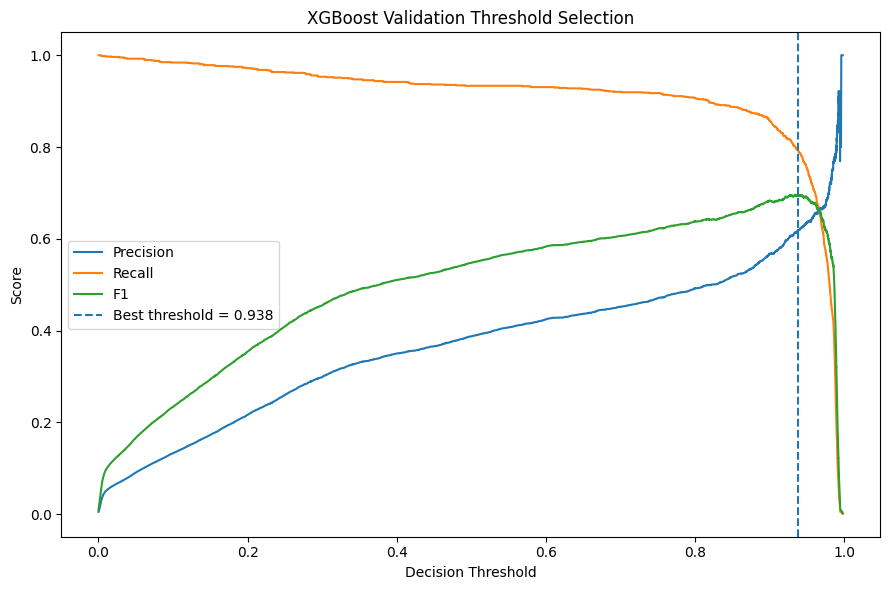

In [75]:
# VALIDATION-ONLY XGBOOST THRESHOLD SELECTION


print("VALIDATION-ONLY XGBOOST THRESHOLD SELECTION")


# ------------------------------------------------------------
# 1. GET STRICT XGBOOST MODEL
# ------------------------------------------------------------

xgb_strict = strict_fitted_models["XGBoost"]

# Predicted probabilities
y_prob_validation = xgb_strict.predict_proba(
    X_val_strict
)[:, 1]

# ------------------------------------------------------------
# 2. PRECISION-RECALL CURVE
# ------------------------------------------------------------

precision, recall, thresholds = precision_recall_curve(
    y_val_strict,
    y_prob_validation
)

# F1 for each available threshold
f1_values = (
    2 * precision[:-1] * recall[:-1]
    /
    (
        precision[:-1]
        + recall[:-1]
        + 1e-12
    )
)

best_index = np.argmax(f1_values)

best_threshold = thresholds[best_index]
best_f1 = f1_values[best_index]

print(
    f"\nBest F1 threshold : "
    f"{best_threshold:.4f}"
)

print(
    f"Best F1 score     : "
    f"{best_f1:.4f}"
)

# ------------------------------------------------------------
# 3. VALIDATION PERFORMANCE AT SELECTED THRESHOLD
# ------------------------------------------------------------

y_pred_opt = (
    y_prob_validation >= best_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_val_strict,
    y_pred_opt
).ravel()

opt_precision = precision_score(
    y_val_strict,
    y_pred_opt,
    zero_division=0
)

opt_recall = recall_score(
    y_val_strict,
    y_pred_opt,
    zero_division=0
)

opt_f1 = f1_score(
    y_val_strict,
    y_pred_opt,
    zero_division=0
)

opt_bal_acc = balanced_accuracy_score(
    y_val_strict,
    y_pred_opt
)

# ------------------------------------------------------------
# 4. COMPARE DEFAULT VS OPTIMIZED
# ------------------------------------------------------------

default_pred = (
    y_prob_validation >= 0.50
).astype(int)

comparison = pd.DataFrame({

    "Threshold": [
        0.50,
        best_threshold
    ],

    "Precision": [
        precision_score(
            y_val_strict,
            default_pred,
            zero_division=0
        ),
        opt_precision
    ],

    "Recall": [
        recall_score(
            y_val_strict,
            default_pred,
            zero_division=0
        ),
        opt_recall
    ],

    "F1": [
        f1_score(
            y_val_strict,
            default_pred,
            zero_division=0
        ),
        opt_f1
    ],

    "Balanced_Accuracy": [
        balanced_accuracy_score(
            y_val_strict,
            default_pred
        ),
        opt_bal_acc
    ]
})

comparison.index = [
    "Default",
    "Optimized"
]

print("\nVALIDATION THRESHOLD COMPARISON")

display(
    comparison.round(4)
)

print("\nVALIDATION CONFUSION MATRIX")

print(
    f"TN = {tn:,}"
)

print(
    f"FP = {fp:,}"
)

print(
    f"FN = {fn:,}"
)

print(
    f"TP = {tp:,}"
)

# ------------------------------------------------------------
# 5. PRECISION / RECALL / F1 VS THRESHOLD
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.plot(
    thresholds,
    f1_values,
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.title(
    "XGBoost Validation Threshold Selection"
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Score"
)

plt.legend()

plt.tight_layout()
plt.show()


## Final Untouched-Test Evaluation


FINAL XGBOOST FIT AND UNTOUCHED TEST EVALUATION

FINAL UNTOUCHED TEST PERFORMANCE


,Threshold_Type,Threshold,ROC_AUC,PR_AUC,Precision,Recall,F1,Balanced_Accuracy
0,Default_0.50,0.500,0.9956,0.5772,0.3722,0.9013,0.5268,0.9463
1,Validation_Selected,0.938,0.9956,0.5772,0.5258,0.7362,0.6135,0.8662


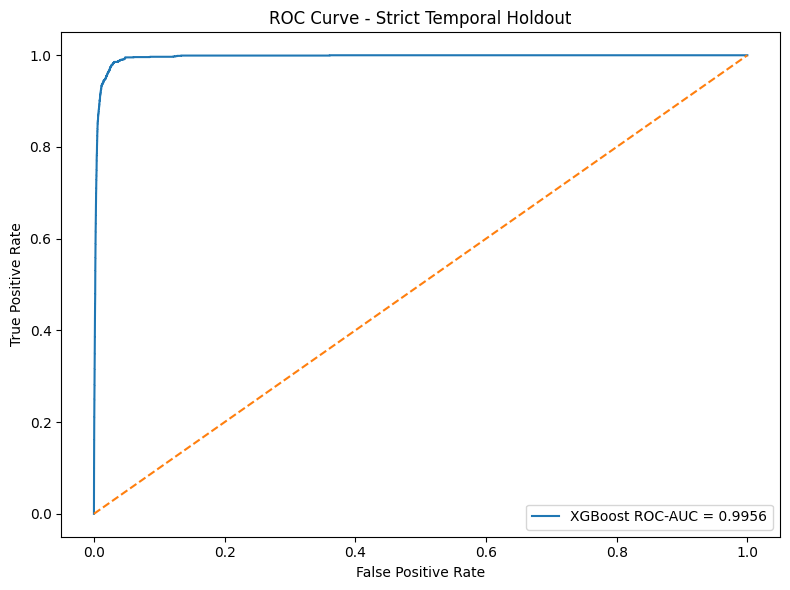

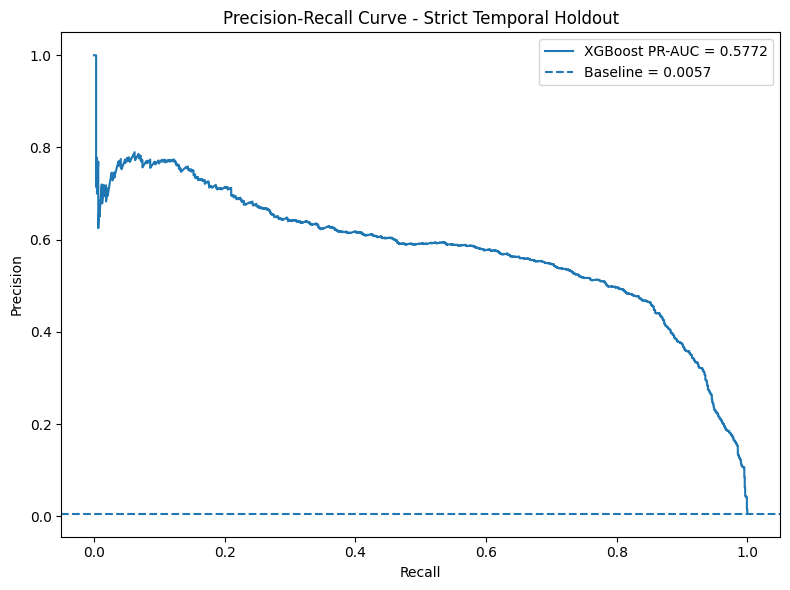

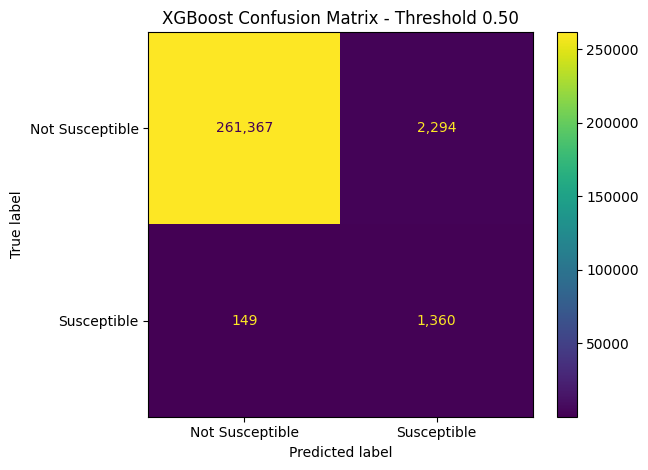

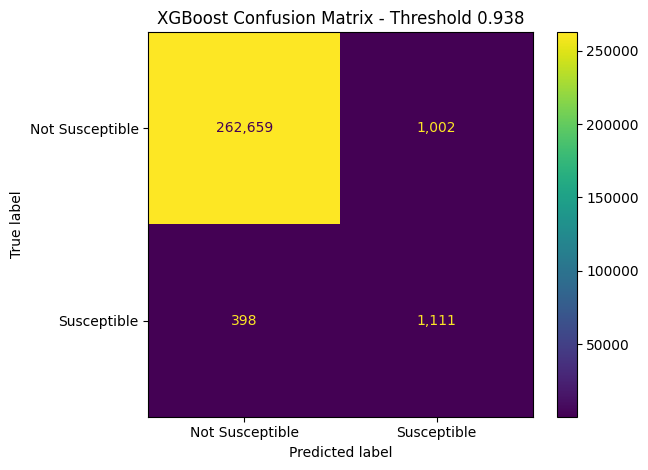


ROC-AUC : 0.9956
PR-AUC  : 0.5772
SECTION COMPLETE


In [76]:
# FINAL XGBOOST FIT AND UNTOUCHED TEST EVALUATION


print("FINAL XGBOOST FIT AND UNTOUCHED TEST EVALUATION")


# Combine training and validation only after model and threshold selection.
development_df = pd.concat(
    [strict_train_df, strict_val_df], ignore_index=True
)
development_positive = development_df[development_df[TARGET] == 1].copy()
development_negative = development_df[development_df[TARGET] == 0].copy()

MAX_FINAL_TRAIN_ROWS = 300_000
n_negative_needed = min(
    MAX_FINAL_TRAIN_ROWS - len(development_positive),
    len(development_negative)
)
development_negative_sample = development_negative.sample(
    n=n_negative_needed, random_state=42
)
final_train_df = pd.concat(
    [development_positive, development_negative_sample], ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

X_final_train = final_train_df[FEATURES]
y_final_train = final_train_df[TARGET]

xgb_strict = clone(strict_fitted_models["XGBoost"])
xgb_strict.set_params(
    scale_pos_weight=(y_final_train == 0).sum() / (y_final_train == 1).sum()
)
xgb_strict.fit(X_final_train, y_final_train)
strict_fitted_models["XGBoost"] = xgb_strict

y_prob_strict = xgb_strict.predict_proba(X_test_strict)[:, 1]
y_pred_default = (y_prob_strict >= 0.50).astype(int)
y_pred_opt = (y_prob_strict >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test_strict, y_prob_strict)
pr_auc = average_precision_score(y_test_strict, y_prob_strict)

final_test_metrics_df = pd.DataFrame([
    {
        "Threshold_Type": "Default_0.50",
        "Threshold": 0.50,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Precision": precision_score(y_test_strict, y_pred_default, zero_division=0),
        "Recall": recall_score(y_test_strict, y_pred_default, zero_division=0),
        "F1": f1_score(y_test_strict, y_pred_default, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_test_strict, y_pred_default),
    },
    {
        "Threshold_Type": "Validation_Selected",
        "Threshold": best_threshold,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Precision": precision_score(y_test_strict, y_pred_opt, zero_division=0),
        "Recall": recall_score(y_test_strict, y_pred_opt, zero_division=0),
        "F1": f1_score(y_test_strict, y_pred_opt, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_test_strict, y_pred_opt),
    },
])

print("\nFINAL UNTOUCHED TEST PERFORMANCE")
display(final_test_metrics_df.round(4))

# ------------------------------------------------------------
# 2. ROC CURVE
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test_strict,
    y_prob_strict
)

roc_auc = roc_auc_score(
    y_test_strict,
    y_prob_strict
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve - Strict Temporal Holdout"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. PRECISION-RECALL CURVE
# ------------------------------------------------------------

precision, recall, _ = precision_recall_curve(
    y_test_strict,
    y_prob_strict
)

pr_auc = average_precision_score(
    y_test_strict,
    y_prob_strict
)

baseline = (
    y_test_strict.mean()
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost PR-AUC = {pr_auc:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.title(
    "Precision-Recall Curve - Strict Temporal Holdout"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. CONFUSION MATRIX AT DEFAULT THRESHOLD
# ------------------------------------------------------------

y_pred_default = (
    y_prob_strict >= 0.50
).astype(int)

cm_default = confusion_matrix(
    y_test_strict,
    y_pred_default
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=[
        "Not Susceptible",
        "Susceptible"
    ]
)

disp.plot(
    values_format=",d"
)

plt.title(
    "XGBoost Confusion Matrix - Threshold 0.50"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. CONFUSION MATRIX AT OPTIMIZED THRESHOLD
#    Uses best_threshold from Section 10E
# ------------------------------------------------------------

y_pred_opt = (
    y_prob_strict >= best_threshold
).astype(int)

cm_opt = confusion_matrix(
    y_test_strict,
    y_pred_opt
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=[
        "Not Susceptible",
        "Susceptible"
    ]
)

disp.plot(
    values_format=",d"
)

plt.title(
    f"XGBoost Confusion Matrix - Threshold {best_threshold:.3f}"
)

plt.tight_layout()
plt.show()

print("\nROC-AUC :", round(roc_auc, 4))
print("PR-AUC  :", round(pr_auc, 4))

print("SECTION COMPLETE")


## XGBoost Feature Importance


XGBOOST FEATURE IMPORTANCE

FEATURE IMPORTANCE


,Feature,Importance,Percent
0,cloud_cover_fraction,0.6967,69.672501
1,cloud_ice_water_kgkg,0.1467,14.673500
2,pressure_level,0.0502,5.021100
3,geopotential_height_m,0.0271,2.706000
4,waypoint_latitude,0.0262,2.624200
5,wind_u_ms,0.0157,1.573600
6,wind_speed_ms,0.0117,1.172800
7,waypoint_longitude,0.0111,1.112600
8,wind_v_ms,0.0104,1.039700
9,time_match_error_min,0.0040,0.404000


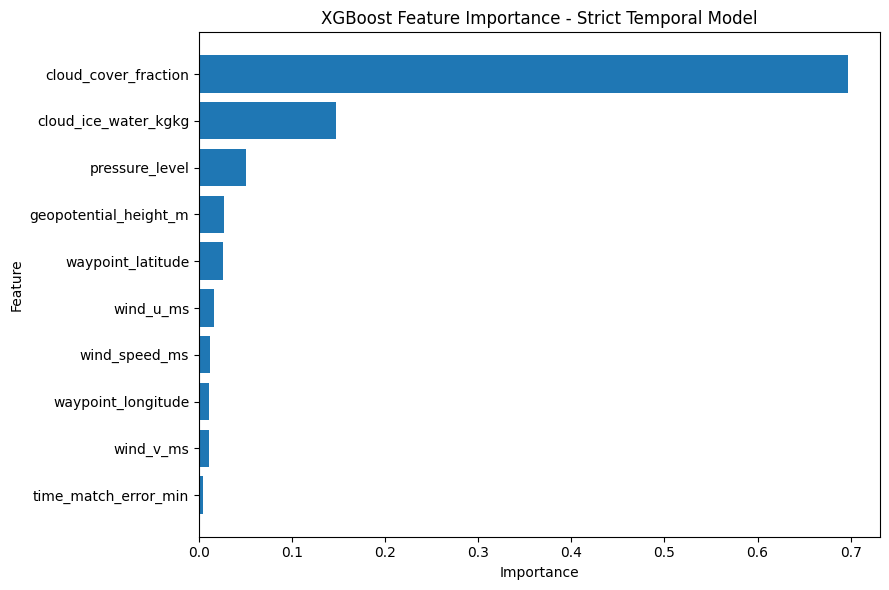


CUMULATIVE FEATURE IMPORTANCE


,Feature,Importance,Percent,Cumulative_Percent
0,cloud_cover_fraction,0.697,69.672997,69.672997
1,cloud_ice_water_kgkg,0.147,14.674000,84.346001
2,pressure_level,0.050,5.021000,89.366997
3,geopotential_height_m,0.027,2.706000,92.072998
4,waypoint_latitude,0.026,2.624000,94.696999
5,wind_u_ms,0.016,1.574000,96.271004
6,wind_speed_ms,0.012,1.173000,97.444000
7,waypoint_longitude,0.011,1.113000,98.556000
8,wind_v_ms,0.010,1.040000,99.596001
9,time_match_error_min,0.004,0.404000,100.000000



SECTION 10G COMPLETE


In [77]:
# XGBOOST FEATURE IMPORTANCE


print("XGBOOST FEATURE IMPORTANCE")


# ------------------------------------------------------------
# 1. GET STRICT XGBOOST MODEL
# ------------------------------------------------------------

xgb_strict = strict_fitted_models["XGBoost"]

# ------------------------------------------------------------
# 2. BUILT-IN FEATURE IMPORTANCE
# ------------------------------------------------------------

importance_values = xgb_strict.feature_importances_

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importance_values
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df["Percent"] = (
    importance_df["Importance"]
    / importance_df["Importance"].sum()
    * 100
)

print("\nFEATURE IMPORTANCE")

display(
    importance_df.round(4)
)

# ------------------------------------------------------------
# 3. FEATURE-IMPORTANCE GRAPH
# ------------------------------------------------------------

plot_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"]
)

plt.title(
    "XGBoost Feature Importance - Strict Temporal Model"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. CUMULATIVE IMPORTANCE
# ------------------------------------------------------------

importance_df["Cumulative_Percent"] = (
    importance_df["Percent"]
    .cumsum()
)

print("\nCUMULATIVE FEATURE IMPORTANCE")

display(
    importance_df[
        [
            "Feature",
            "Importance",
            "Percent",
            "Cumulative_Percent"
        ]
    ].round(3)
)

print("\nSECTION 10G COMPLETE")


## Permutation Importance


PERMUTATION IMPORTANCE

Permutation test rows : 50,000
Baseline PR-AUC on permutation sample : 0.5570

PERMUTATION IMPORTANCE - PR-AUC DROP


,Feature,Importance_Mean,Importance_Std
0,cloud_cover_fraction,0.51052,0.00279
1,waypoint_latitude,0.17789,0.01670
2,geopotential_height_m,0.07908,0.01655
3,pressure_level,0.04247,0.01496
4,cloud_ice_water_kgkg,0.03961,0.00531
5,wind_speed_ms,0.02967,0.00687
6,wind_u_ms,0.02778,0.01015
7,wind_v_ms,-0.00016,0.01055
8,time_match_error_min,-0.00621,0.00093
9,waypoint_longitude,-0.01689,0.00458


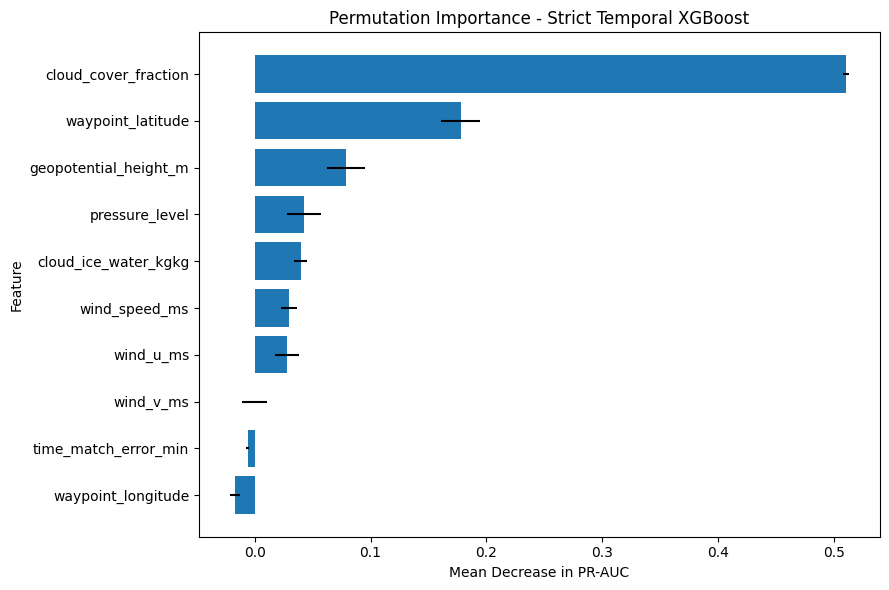


BUILT-IN VS PERMUTATION IMPORTANCE


,Feature,Importance,Percent,Importance_Mean,Importance_Std
0,cloud_cover_fraction,0.69673,69.672523,0.51052,0.00279
4,waypoint_latitude,0.02624,2.624180,0.17789,0.01670
3,geopotential_height_m,0.02706,2.705980,0.07908,0.01655
2,pressure_level,0.05021,5.021100,0.04247,0.01496
1,cloud_ice_water_kgkg,0.14673,14.673500,0.03961,0.00531
6,wind_speed_ms,0.01173,1.172800,0.02967,0.00687
5,wind_u_ms,0.01574,1.573560,0.02778,0.01015
8,wind_v_ms,0.01040,1.039730,-0.00016,0.01055
9,time_match_error_min,0.00404,0.404010,-0.00621,0.00093
7,waypoint_longitude,0.01113,1.112630,-0.01689,0.00458


SECTION  COMPLETE


In [78]:
# PERMUTATION IMPORTANCE

print("PERMUTATION IMPORTANCE")


# ------------------------------------------------------------
# 1. USE STRICT XGBOOST MODEL
# ------------------------------------------------------------

xgb_strict = strict_fitted_models["XGBoost"]

# ------------------------------------------------------------
# 2. SAMPLE TEST DATA FOR SPEED
# ------------------------------------------------------------

MAX_PERMUTATION_ROWS = 50_000

if len(X_test_strict) > MAX_PERMUTATION_ROWS:

    rng = np.random.RandomState(42)

    sample_idx = rng.choice(
        len(X_test_strict),
        size=MAX_PERMUTATION_ROWS,
        replace=False
    )

    X_perm = X_test_strict.iloc[sample_idx].copy()
    y_perm = y_test_strict.iloc[sample_idx].copy()

else:

    X_perm = X_test_strict.copy()
    y_perm = y_test_strict.copy()

print(f"\nPermutation test rows : {len(X_perm):,}")

# ------------------------------------------------------------
# 3. BASELINE PR-AUC
# ------------------------------------------------------------

baseline_prob = xgb_strict.predict_proba(
    X_perm
)[:, 1]

baseline_pr_auc = average_precision_score(
    y_perm,
    baseline_prob
)

print(
    f"Baseline PR-AUC on permutation sample : "
    f"{baseline_pr_auc:.4f}"
)

# ------------------------------------------------------------
# 4. PERMUTATION IMPORTANCE
#
# Scoring by average precision because PR-AUC is our
# primary metric for severe class imbalance.
# ------------------------------------------------------------

perm_result = permutation_importance(
    xgb_strict,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 5. BUILD IMPORTANCE TABLE
# ------------------------------------------------------------

perm_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

perm_df = (
    perm_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nPERMUTATION IMPORTANCE - PR-AUC DROP")

display(
    perm_df.round(5)
)

# ------------------------------------------------------------
# 6. GRAPH
# ------------------------------------------------------------

plot_df = (
    perm_df
    .sort_values(
        "Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance_Mean"],
    xerr=plot_df["Importance_Std"]
)

plt.title(
    "Permutation Importance - Strict Temporal XGBoost"
)

plt.xlabel(
    "Mean Decrease in PR-AUC"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. COMPARE BUILT-IN VS PERMUTATION IMPORTANCE
# ------------------------------------------------------------

comparison_importance = (
    importance_df[
        [
            "Feature",
            "Importance",
            "Percent"
        ]
    ]
    .merge(
        perm_df,
        on="Feature",
        how="left"
    )
)

print("\nBUILT-IN VS PERMUTATION IMPORTANCE")

display(
    comparison_importance
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .round(5)
)

print("SECTION  COMPLETE")


## Temporal Learning Curve


TEMPORAL LEARNING CURVE

Validation rows      : 201,996
Validation flights   : 3,819
Validation positives : 1,067
2022-01-07 | Rows=246,834 | Flights=4,726 | PR-AUC=0.6833 | ROC-AUC=0.9950
2022-01-11 | Rows=470,262 | Flights=8,888 | PR-AUC=0.6645 | ROC-AUC=0.9963
2022-01-15 | Rows=671,004 | Flights=12,796 | PR-AUC=0.6935 | ROC-AUC=0.9965
2022-01-19 | Rows=870,096 | Flights=16,566 | PR-AUC=0.6674 | ROC-AUC=0.9970
2022-01-21 | Rows=963,762 | Flights=18,373 | PR-AUC=0.7153 | ROC-AUC=0.9972

TEMPORAL LEARNING CURVE RESULTS


,Training_End_Date,Training_Rows,Training_Flights,Training_Positives,ROC_AUC,PR_AUC
0,2022-01-07,246834,4726,4164,0.9950,0.6833
1,2022-01-11,470262,8888,6297,0.9963,0.6645
2,2022-01-15,671004,12796,9735,0.9965,0.6935
3,2022-01-19,870096,16566,10520,0.9970,0.6674
4,2022-01-21,963762,18373,10548,0.9972,0.7153


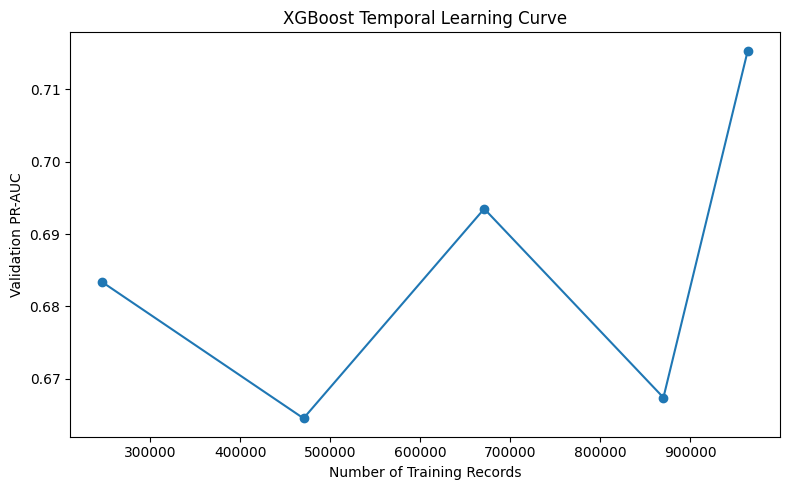

SECTION COMPLETE


In [79]:
# TEMPORAL LEARNING CURVE



print("TEMPORAL LEARNING CURVE")


# Use the dedicated Jan 21-24 validation split; the final test remains untouched.
train_flight_bounds = (
    strict_train_df.groupby("flight_id")["era5_time"]
    .agg(first_time="min", last_time="max")
    .reset_index()
)
X_val_curve = X_val_strict.copy()
y_val_curve = y_val_strict.copy()

print(f"\nValidation rows      : {len(strict_val_df):,}")
print(f"Validation flights   : {strict_val_df['flight_id'].nunique():,}")
print(f"Validation positives : {int(y_val_curve.sum()):,}")

# ------------------------------------------------------------
# 3. EXPANDING TRAINING WINDOWS
# ------------------------------------------------------------

training_end_dates = [
    pd.Timestamp("2022-01-07 00:00:00", tz="UTC"),
    pd.Timestamp("2022-01-11 00:00:00", tz="UTC"),
    pd.Timestamp("2022-01-15 00:00:00", tz="UTC"),
    pd.Timestamp("2022-01-19 00:00:00", tz="UTC"),
    pd.Timestamp("2022-01-21 00:00:00", tz="UTC")
]

learning_results = []

for train_end in training_end_dates:

    # Only flights completely before training cutoff
    eligible_flights = set(
        train_flight_bounds.loc[
            train_flight_bounds["last_time"] < train_end,
            "flight_id"
        ]
    )

    train_curve_df = (
        strict_train_df[
            strict_train_df["flight_id"].isin(
                eligible_flights
            )
        ]
        .copy()
    )

    X_curve = train_curve_df[FEATURES]
    y_curve = train_curve_df[TARGET]

    positives = int(y_curve.sum())
    negatives = int(
        len(y_curve) - positives
    )

    if positives == 0:
        print(
            f"Skipping {train_end.date()} - "
            "no positive cases."
        )
        continue

    scale_weight = (
        negatives / positives
    )

    model_curve = XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model_curve.fit(
        X_curve,
        y_curve
    )

    val_prob = model_curve.predict_proba(
        X_val_curve
    )[:, 1]

    roc = roc_auc_score(
        y_val_curve,
        val_prob
    )

    pr = average_precision_score(
        y_val_curve,
        val_prob
    )

    learning_results.append({
        "Training_End_Date":
            train_end.date(),

        "Training_Rows":
            len(train_curve_df),

        "Training_Flights":
            train_curve_df[
                "flight_id"
            ].nunique(),

        "Training_Positives":
            positives,

        "ROC_AUC":
            roc,

        "PR_AUC":
            pr
    })

    print(
        f"{train_end.date()} | "
        f"Rows={len(train_curve_df):,} | "
        f"Flights={train_curve_df['flight_id'].nunique():,} | "
        f"PR-AUC={pr:.4f} | "
        f"ROC-AUC={roc:.4f}"
    )

# ------------------------------------------------------------
# 4. RESULTS TABLE
# ------------------------------------------------------------

learning_curve_df = pd.DataFrame(
    learning_results
)

print("\nTEMPORAL LEARNING CURVE RESULTS")

display(
    learning_curve_df.round(4)
)

# ------------------------------------------------------------
# 5. LEARNING CURVE GRAPH - PR-AUC
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    learning_curve_df["Training_Rows"],
    learning_curve_df["PR_AUC"],
    marker="o"
)

plt.title(
    "XGBoost Temporal Learning Curve"
)

plt.xlabel(
    "Number of Training Records"
)

plt.ylabel(
    "Validation PR-AUC"
)

plt.tight_layout()
plt.show()

print("SECTION COMPLETE")


## SHAP Explainability


SHAP EXPLAINABILITY

SHAP sample rows : 10,000
Features         : 10

SHAP values calculated successfully.

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP,Importance_Percent
0,cloud_cover_fraction,3.395701,44.069946
1,waypoint_latitude,1.192514,15.476640
2,geopotential_height_m,0.833495,10.817237
3,wind_u_ms,0.472772,6.135717
4,cloud_ice_water_kgkg,0.468648,6.082189
5,wind_speed_ms,0.440910,5.722198
6,waypoint_longitude,0.392689,5.096378
7,wind_v_ms,0.264863,3.437434
8,pressure_level,0.194243,2.520911
9,time_match_error_min,0.049418,0.641353


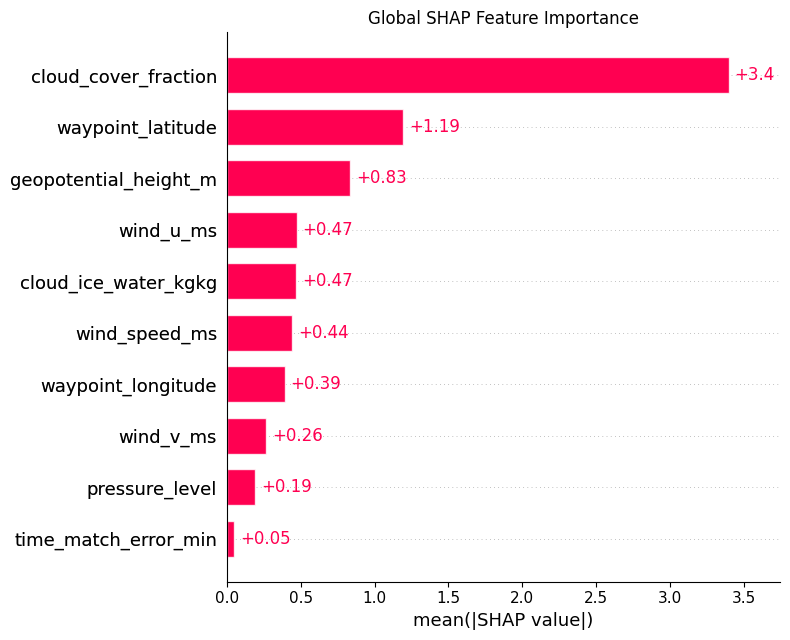

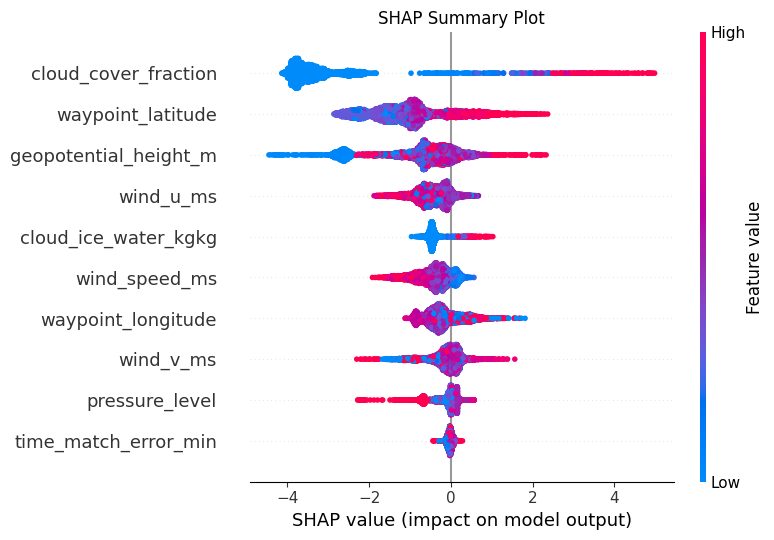

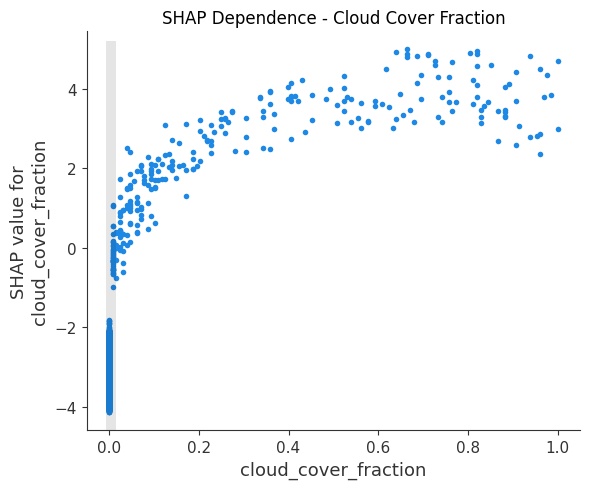

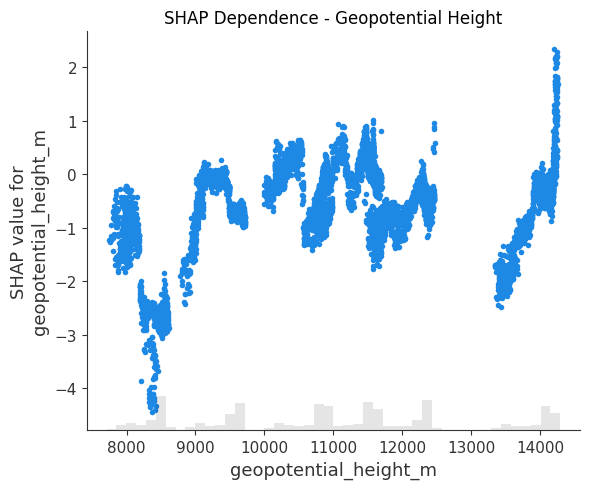

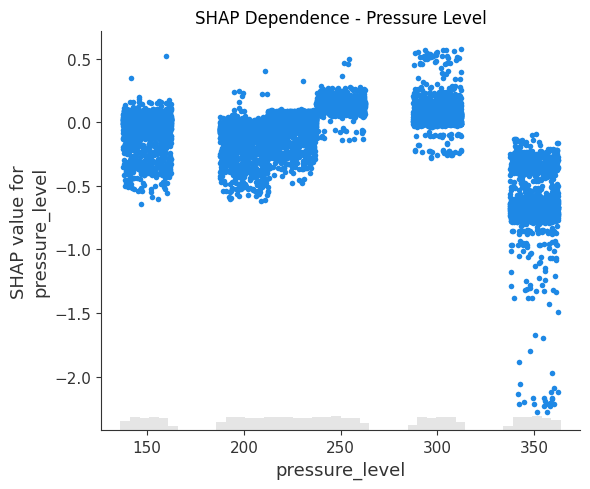


Highest predicted probability in SHAP sample: 0.995731


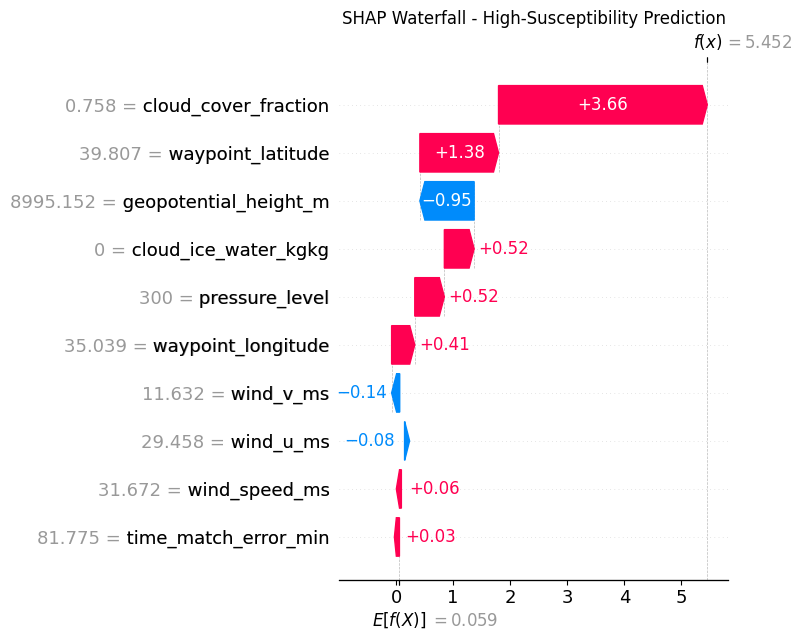

SECTION COMPLETE


In [80]:
# SHAP EXPLAINABILITY FOR FINAL XGBOOST MODEL


print("SHAP EXPLAINABILITY")


# ------------------------------------------------------------
# 1. FINAL MODEL
# ------------------------------------------------------------

final_xgb_model = strict_fitted_models["XGBoost"]

# ------------------------------------------------------------
# 2. SAMPLE STRICT TEST DATA
# ------------------------------------------------------------

SHAP_SAMPLE_SIZE = 10000

if len(X_test_strict) > SHAP_SAMPLE_SIZE:
    X_shap = X_test_strict.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=42
    )
else:
    X_shap = X_test_strict.copy()

print(f"\nSHAP sample rows : {len(X_shap):,}")
print(f"Features         : {X_shap.shape[1]}")

# ------------------------------------------------------------
# 3. CREATE TREE EXPLAINER
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    final_xgb_model
)

shap_values = explainer(
    X_shap
)

print("\nSHAP values calculated successfully.")

# ------------------------------------------------------------
# 4. GLOBAL SHAP IMPORTANCE TABLE
# ------------------------------------------------------------

mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_df[
    "Importance_Percent"
] = (
    shap_importance_df[
        "Mean_Absolute_SHAP"
    ]
    /
    shap_importance_df[
        "Mean_Absolute_SHAP"
    ].sum()
    * 100
)

print("\nGLOBAL SHAP FEATURE IMPORTANCE")

display(
    shap_importance_df.round(6)
)

# ------------------------------------------------------------
# 5. SHAP BAR PLOT
# ------------------------------------------------------------

plt.figure()

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. SHAP BEESWARM
# ------------------------------------------------------------

plt.figure()

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Summary Plot"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. DEPENDENCE - CLOUD COVER
# ------------------------------------------------------------

if "cloud_cover_fraction" in X_shap.columns:

    shap.plots.scatter(
        shap_values[
            :,
            "cloud_cover_fraction"
        ],
        show=False
    )

    plt.title(
        "SHAP Dependence - Cloud Cover Fraction"
    )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8. DEPENDENCE - GEOPOTENTIAL HEIGHT
# ------------------------------------------------------------

if "geopotential_height_m" in X_shap.columns:

    shap.plots.scatter(
        shap_values[
            :,
            "geopotential_height_m"
        ],
        show=False
    )

    plt.title(
        "SHAP Dependence - Geopotential Height"
    )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 9. DEPENDENCE - PRESSURE LEVEL
# ------------------------------------------------------------

if "pressure_level" in X_shap.columns:

    shap.plots.scatter(
        shap_values[
            :,
            "pressure_level"
        ],
        show=False
    )

    plt.title(
        "SHAP Dependence - Pressure Level"
    )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 10. INDIVIDUAL HIGH-RISK EXPLANATION
# ------------------------------------------------------------

shap_probabilities = final_xgb_model.predict_proba(
    X_shap
)[:, 1]

highest_risk_position = np.argmax(
    shap_probabilities
)

print(
    "\nHighest predicted probability in SHAP sample:",
    round(
        float(
            shap_probabilities[
                highest_risk_position
            ]
        ),
        6
    )
)

shap.plots.waterfall(
    shap_values[
        highest_risk_position
    ],
    max_display=10,
    show=False
)

plt.title(
    "SHAP Waterfall - High-Susceptibility Prediction"
)

plt.tight_layout()
plt.show()

print("SECTION COMPLETE")


 Save Final Model and Analytical Outputs


In [81]:
import os
import joblib
# SAVE FINAL MODEL AND ANALYTICAL OUTPUTS



print("SAVE FINAL MODEL AND ANALYTICAL OUTPUTS")

# ------------------------------------------------------------
# 1. OUTPUT FOLDER
# ------------------------------------------------------------

FINAL_RESULTS_DIR = (
    "/content/drive/MyDrive/Green aviation -Research/"
    "Final_Modelling/Final_Results"
)

os.makedirs(
    FINAL_RESULTS_DIR,
    exist_ok=True
)

print(
    f"\nOutput folder:\n{FINAL_RESULTS_DIR}"
)

# ------------------------------------------------------------
# 2. SAVE FINAL STRICT XGBOOST MODEL
# ------------------------------------------------------------

FINAL_MODEL_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "XGBoost_Strict_Temporal_Contrail_Model.joblib"
)

joblib.dump(
    strict_fitted_models["XGBoost"],
    FINAL_MODEL_FILE
)

print(
    f"\nModel saved:\n{FINAL_MODEL_FILE}"
)

# ------------------------------------------------------------
# 3. SAVE STRICT TEST PREDICTIONS
# ------------------------------------------------------------

xgb_final = strict_fitted_models["XGBoost"]

final_probabilities = xgb_final.predict_proba(
    X_test_strict
)[:, 1]

final_predictions = strict_test_df[
    [
        "flight_id",
        "era5_key_id",
        "timestamp_utc",
        "era5_time",
        TARGET
    ]
].copy()

final_predictions[
    "predicted_probability"
] = final_probabilities

final_predictions[
    "prediction_threshold_050"
] = (
    final_probabilities >= 0.50
).astype(int)

# Threshold selected on the validation period in Section 10E
final_predictions[
    "prediction_validation_selected_threshold"
] = (
    final_probabilities >= best_threshold
).astype(int)

FINAL_PREDICTIONS_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "XGBoost_Strict_Test_Predictions.parquet"
)

final_predictions.to_parquet(
    FINAL_PREDICTIONS_FILE,
    index=False
)

# ------------------------------------------------------------
# 4. SAVE MODEL PERFORMANCE
# ------------------------------------------------------------

STRICT_RESULTS_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Temporal_Validation_Model_Comparison.csv"
)

strict_results_df.to_csv(
    STRICT_RESULTS_FILE,
    index=False
)

FINAL_TEST_METRICS_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Final_Untouched_Test_Metrics.csv"
)
final_test_metrics_df.to_csv(FINAL_TEST_METRICS_FILE, index=False)

# ------------------------------------------------------------
# 5. SAVE FEATURE IMPORTANCE
# ------------------------------------------------------------

IMPORTANCE_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "XGBoost_Builtin_Feature_Importance.csv"
)

importance_df.to_csv(
    IMPORTANCE_FILE,
    index=False
)

PERMUTATION_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "XGBoost_Permutation_Importance.csv"
)

perm_df.to_csv(
    PERMUTATION_FILE,
    index=False
)

# ------------------------------------------------------------
# 6. SAVE ATMOSPHERIC PROFILE
# ------------------------------------------------------------

ATMOSPHERIC_PROFILE_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Susceptible_vs_NonSusceptible_Profile.csv"
)

comparison_df.to_csv(
    ATMOSPHERIC_PROFILE_FILE,
    index=False
)

PRESSURE_LEVEL_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Susceptibility_by_Pressure_Level.csv"
)

sus_level.to_csv(
    PRESSURE_LEVEL_FILE,
    index=False
)

# ------------------------------------------------------------
# 7. SAVE FLIGHT-LEVEL EXPOSURE
# ------------------------------------------------------------

FLIGHT_EXPOSURE_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Flight_Level_Contrail_Exposure.parquet"
)

flight_exposure_full.to_parquet(
    FLIGHT_EXPOSURE_FILE,
    index=False
)

AIRCRAFT_EXPOSURE_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Aircraft_Type_Exposure.csv"
)

aircraft_exposure_filtered.to_csv(
    AIRCRAFT_EXPOSURE_FILE,
    index=False
)

ROUTE_EXPOSURE_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Route_Exposure.csv"
)

route_exposure_filtered.to_csv(
    ROUTE_EXPOSURE_FILE,
    index=False
)

# ------------------------------------------------------------
# 8. SAVE TEMPORAL / SPATIAL RESULTS
# ------------------------------------------------------------

DAILY_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Daily_Susceptibility.csv"
)

daily_susceptibility.to_csv(
    DAILY_FILE,
    index=False
)

HOURLY_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Hourly_Susceptibility.csv"
)

hourly_susceptibility.to_csv(
    HOURLY_FILE,
    index=False
)

HOTSPOT_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Spatial_Hotspots.csv"
)

spatial_hotspots_filtered.to_csv(
    HOTSPOT_FILE,
    index=False
)

# ------------------------------------------------------------
# 9. SAVE FINAL MODEL METADATA
# ------------------------------------------------------------

final_metadata = {
    "study_period": "January 2022",
    "master_rows": int(len(df)),
    "flights": int(df["flight_id"].nunique()),
    "waypoints": int(df[["flight_id", "waypoint_number"]].drop_duplicates().shape[0]),
    "pressure_levels_hPa": [150, 200, 225, 250, 300, 350],
    "target": "persistent-contrail-susceptible atmospheric condition",
    "training_period": "2022-01-01 to 2022-01-20",
    "validation_period": "2022-01-21 to 2022-01-24",
    "untouched_test_period": "2022-01-25 to 2022-01-31",
    "train_rows": int(len(strict_train_df)),
    "validation_rows": int(len(strict_val_df)),
    "test_rows": int(len(strict_test_df)),
    "train_flights": int(strict_train_df["flight_id"].nunique()),
    "validation_flights": int(strict_val_df["flight_id"].nunique()),
    "test_flights": int(strict_test_df["flight_id"].nunique()),
    "flight_overlap": int(len(flight_overlap)),
    "era5_key_overlap": int(len(era5_overlap)),
    "final_model": "XGBoost",
    "test_roc_auc": float(roc_auc),
    "test_pr_auc": float(pr_auc),
    "default_threshold": 0.50,
    "validation_selected_threshold": float(best_threshold),
    "threshold_selection_note": "Threshold selected on validation data only; final metrics evaluated once on the untouched test period."
}
METADATA_FILE = os.path.join(
    FINAL_RESULTS_DIR,
    "Final_Model_Metadata.json"
)

with open(
    METADATA_FILE,
    "w"
) as f:

    json.dump(
        final_metadata,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 10. FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "-" * 105)
print("SAVED OUTPUTS")
print("-" * 105)

saved_files = [
    FINAL_MODEL_FILE,
    FINAL_PREDICTIONS_FILE,
    STRICT_RESULTS_FILE,
    FINAL_TEST_METRICS_FILE,
    IMPORTANCE_FILE,
    PERMUTATION_FILE,
    ATMOSPHERIC_PROFILE_FILE,
    PRESSURE_LEVEL_FILE,
    FLIGHT_EXPOSURE_FILE,
    AIRCRAFT_EXPOSURE_FILE,
    ROUTE_EXPOSURE_FILE,
    DAILY_FILE,
    HOURLY_FILE,
    HOTSPOT_FILE,
    METADATA_FILE
]

for file in saved_files:

    exists = os.path.exists(file)

    if exists:

        size_mb = (
            os.path.getsize(file)
            / (1024 ** 2)
        )

        print(
            f"\u2713 {os.path.basename(file):55s} "
            f"{size_mb:8.2f} MB"
        )

    else:

        print(
            f"\u2717 {os.path.basename(file)}"
        )

print("\nFINAL STATUS : MODEL AND RESULTS SAVED")

SAVE FINAL MODEL AND ANALYTICAL OUTPUTS

Output folder:
/content/drive/MyDrive/Green aviation -Research/Final_Modelling/Final_Results

Model saved:
/content/drive/MyDrive/Green aviation -Research/Final_Modelling/Final_Results/XGBoost_Strict_Temporal_Contrail_Model.joblib

---------------------------------------------------------------------------------------------------------
SAVED OUTPUTS
---------------------------------------------------------------------------------------------------------
✓ XGBoost_Strict_Temporal_Contrail_Model.joblib               0.50 MB
✓ XGBoost_Strict_Test_Predictions.parquet                     2.42 MB
✓ Temporal_Validation_Model_Comparison.csv                    0.00 MB
✓ Final_Untouched_Test_Metrics.csv                            0.00 MB
✓ XGBoost_Builtin_Feature_Importance.csv                      0.00 MB
✓ XGBoost_Permutation_Importance.csv                          0.00 MB
✓ Susceptible_vs_NonSusceptible_Profile.csv                   0.00 MB
✓ Susceptib